# Set Up 

In [ ]:
# Falls Keine Libarys vorhanden sind- Installation mit pip/conda nötig
%pip install matplotlib
%pip install spicy
%pip install dataframe_image

In [99]:
# nötige Bibblithekem importieren 
import pandas as pd
import os
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, levene
import seaborn as sns
import scipy.stats as stats
from collections import Counter
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
from sklearn.utils import resample
import numpy as np

In [16]:
# Data Set Pfade setzen um, ANalysen durchführen zu können 
######

experiment_path1 = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 1/EnclothedCognition/FullDS.csv'
experiment_path2 = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/FullDsFiltered.csv'

#######

bb_path = ""
js_path=""
es_path=""

#experiment = pd.read_csv(experiment_path)
#BB = pd.read_csv(bb_path)
#JS = pd.read_csv(js_path)
#ES = pd.read_csv(es_path)

#  Studie 2 - Data Merging


Kreuztabellen

In [31]:
import pandas as pd

# CSV-Datei laden (Pfad anpassen!)
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/FinalMergedFilteredOhneDoppelte.csv')

# Kreuztabelle erstellen
kreuztabelle = pd.crosstab(index=df["Style"], columns=df["Store"], margins=True, margins_name="sum")

# Optional: Achsenbeschriftungen für mehr Klarheit anpassen
kreuztabelle.index.name = "Style"
kreuztabelle.columns.name = "Gender"

# Excel-Datei speichern
output_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/KreutabelleStore.xlsx'
kreuztabelle.to_excel(output_path)

print(f"Kreuztabelle erfolgreich exportiert nach: {output_path}")


Kreuztabelle erfolgreich exportiert nach: /Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/KreutabelleStore.xlsx


In [46]:
import pandas as pd

# CSV laden – Pfad anpassen
df = pd.read_csv("/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/FinalMergedFiltered.csv")



# Spalte "Name" analysieren
df["Name_str"] = df["Name"].astype(str).str.strip()

# Klassifikation
df["is_numeric_name"] = df["Name_str"].str.match(r"^\d+$")

# Zählen
numeric_names = df[df["is_numeric_name"] == True]
non_numeric_names = df[df["is_numeric_name"] == False]

# Übersicht ausgeben
print(f"✅ Anzahl numerischer Namen (Matrikelnummern): {len(numeric_names)}")
print(f"✅ Anzahl nicht-numerischer Namen (z. B. Kürzel): {len(non_numeric_names)}")

# Optional: zur Kontrolle speichern
numeric_names.to_csv("Numerische_Namen.csv", index=False)
non_numeric_names.to_csv("Nicht_Numerische_Namen.csv", index=False)




✅ Anzahl numerischer Namen (Matrikelnummern): 1
✅ Anzahl nicht-numerischer Namen (z. B. Kürzel): 498


Preis Spalten hinzufügen 

In [166]:
import pandas as pd

# Datei laden
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/RenamedCAdded.csv')

# Preisdaten definieren
preise_beach = {
    "Chips": {"Neutral_1": 2.5, "Neutral_2": 3.5, "Glam": 3.0, "Hippie": 4.2},
    "Chocolate": {"Neutral_1": 1.3, "Neutral_2": 2.6, "Glam": 3.45, "Hippie": 4.95},
    "ChocolateRaisins": {"Neutral_1": 2.0, "Neutral_2": 3.0, "Glam": 2.99, "Hippie": 3.99},
    "Cracker": {"Neutral_1": 4.5, "Neutral_2": 6.5, "Glam": 6.5, "Hippie": 4.5},
    "Dates": {"Neutral_1": 2.0, "Neutral_2": 3.0, "Glam": 3.5, "Hippie": 5.0},
    "Fruit": {"Neutral_1": 3.0, "Neutral_2": 4.5, "Glam": 4.5, "Hippie": 3.0},
    "IceCream": {"Neutral_1": 4.0, "Neutral_2": 5.5, "Glam": 6.5, "Hippie": 4.5},
    "Popsicle": {"Neutral_1": 1.8, "Neutral_2": 2.3, "Glam": 2.2, "Hippie": 3.4},
    "ProteinBar": {"Neutral_1": 1.8, "Neutral_2": 2.5, "Glam": 3.8, "Hippie": 2.8},
}
preise_jewelry = {
    "Watch": (94.0, 180.0),
    "Pen1": (48.5, 64.0), "Pen2": (88.5, 134.0),
    "GlassesCase": (24.5, 39.5),
    "Keychain": (12.5, 19.5),
    "Ring1": (39.5, 54.5), "Ring2": (139.5, 208.5), "Ring3": (39.5, 54.5),
    "Necklace": (39.5, 54.5),
    "Bracelet": (45.5, 60.5)
}
preise_electronics = {
    "PhoneCase": (25.00, 39.50),
    "LaptopBag": (44.50, 58.00),
    "AirpodCase": (14.50, 20.00),
    "Popsocket": (8.99, 11.99)
}

# Preislogikfunktion
def get_price_general(spalte, row, preise_dict, store):
    if row["Store"] != store or str(row.get(spalte)).strip().lower() != "yes":
        return ""
    cond = row.get("Condition", "")
    for typ, values in preise_dict.items():
        if typ.lower() in spalte.lower():
            if isinstance(values, dict):  # BeachBar
                if "neutral" in spalte.lower():
                    return values["Neutral_1"] if "_1" in spalte else values["Neutral_2"]
                elif "hippie" in spalte.lower():
                    return values["Hippie"] if cond == "HippieHigh" else values["Glam"]
                elif "glam" in spalte.lower():
                    return values["Glam"] if cond == "GlamHigh" else values["Hippie"]
            else:  # Jewelry/Electronics
                low, high = values
                if "neutral" in spalte.lower():
                    return low if "_1" in spalte else high
                elif "hippie" in spalte.lower():
                    return high if cond == "HippieHigh" else low
                elif "glam" in spalte.lower():
                    return high if cond == "GlamHigh" else low
    return ""

# ChoiceType für neutrale Produkte
def get_neutral_choice_type(row, spalte):
    bn_val = row.get(f"{spalte}_bn", "")
    if bn_val != 1:
        return 2
    return 0 if "_1" in spalte else 1

# ChoiceType für Glam/Hippie-Produkte mit Preisvergleich
def get_gh_choice_type(row, spalte):
    bn_val = row.get(f"{spalte}_bn", "")
    if bn_val != 1:
        return 2
    cond = row.get("Condition", "")
    preis_dicts = [preise_beach, preise_jewelry, preise_electronics]

    for preise in preis_dicts:
        for produkt, werte in preise.items():
            if produkt.lower() in spalte.lower():
                if isinstance(werte, dict):
                    glam_preis = werte.get("Glam", 0)
                    hippie_preis = werte.get("Hippie", 0)
                else:
                    glam_preis = werte[1]
                    hippie_preis = werte[0]

                gekauft = row.get(f"{spalte}_price", "")
                if gekauft == "":
                    return 2

                teuer = max(glam_preis, hippie_preis)
                billig = min(glam_preis, hippie_preis)

                if float(gekauft) == teuer:
                    return 1
                elif float(gekauft) == billig:
                    return 0
                else:
                    return 2
    return 2


# Hilfsfunktion zur Erweiterung mit ChoiceType inkl. Glam/Hippie-Logik
def add_bin_price_choicetype_cols(df, spalten, preislogik, store_name):
    for spalte in spalten:
        if spalte in df.columns:
            bn_col = df[spalte].apply(lambda x: 1 if str(x).strip().lower() == "yes" else (0 if str(x).strip().lower() == "no" else ""))
            price_col = df.apply(lambda row: get_price_general(spalte, row, preislogik, store_name), axis=1)
            insert_pos = df.columns.get_loc(spalte) + 1
            df.insert(insert_pos, f"{spalte}_bn", bn_col)
            df.insert(insert_pos + 1, f"{spalte}_price", price_col)

            if "neutral" in spalte.lower():
                choice_col = df.apply(lambda row: get_neutral_choice_type(row, spalte), axis=1)
                df.insert(insert_pos + 2, f"{spalte}_ChoiceType", choice_col)
            elif "hippie" in spalte.lower() or "glam" in spalte.lower():
                choice_col = df.apply(lambda row: get_gh_choice_type(row, spalte), axis=1)
                df.insert(insert_pos + 2, f"{spalte}_ChoiceType", choice_col)

# Spalten bestimmen
beach_spalten = [f"{prod}_{var}" for prod in preise_beach.keys() for var in ["Neutral_1", "Neutral_2", "Glam", "Hippie"]]
jewelry_spalten = [col for col in df.columns if any(k in col for k in preise_jewelry.keys()) and any(x in col for x in ["Glam", "Hippie", "Neutral"])]
electronics_spalten = [col for col in df.columns if any(k in col for k in preise_electronics.keys())]

# Anwendung
add_bin_price_choicetype_cols(df, beach_spalten, preise_beach, "BeachBar")
add_bin_price_choicetype_cols(df, jewelry_spalten, preise_jewelry, "JewelryStore")
add_bin_price_choicetype_cols(df, electronics_spalten, preise_electronics, "ElectronicStore")

# Speichern
df.to_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/RenamedCAdded01Prices.csv', index=False)



/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/3375745651.py:107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(insert_pos + 1, f"{spalte}_price", price_col)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/3375745651.py:111: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(insert_pos + 2, f"{spalte}_ChoiceType", choice_col)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/3375745651.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the

In [167]:
import pandas as pd

# Datei laden
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/RenamedCAdded.csv')

# Preisdaten definieren
preise_beach = {
    "Chips": {"Neutral_1": 2.5, "Neutral_2": 3.5, "Glam": 3.0, "Hippie": 4.2},
    "Chocolate": {"Neutral_1": 1.3, "Neutral_2": 2.6, "Glam": 3.45, "Hippie": 4.95},
    "ChocolateRaisins": {"Neutral_1": 2.0, "Neutral_2": 3.0, "Glam": 2.99, "Hippie": 3.99},
    "Cracker": {"Neutral_1": 4.5, "Neutral_2": 6.5, "Glam": 6.5, "Hippie": 4.5},
    "Dates": {"Neutral_1": 2.0, "Neutral_2": 3.0, "Glam": 3.5, "Hippie": 5.0},
    "Fruit": {"Neutral_1": 3.0, "Neutral_2": 4.5, "Glam": 4.5, "Hippie": 30.0},
    "IceCream": {"Neutral_1": 4.0, "Neutral_2": 5.5, "Glam": 6.5, "Hippie": 4.5},
    "Popsicle": {"Neutral_1": 1.8, "Neutral_2": 2.3, "Glam": 2.2, "Hippie": 3.4},
    "ProteinBar": {"Neutral_1": 1.8, "Neutral_2": 2.5, "Glam": 3.8, "Hippie": 2.8},
}
preise_jewelry = {
    "Watch": (94.0, 180.0),
    "Pen1": (48.5, 64.0), "Pen2": (88.5, 134.0),
    "GlassesCase": (24.5, 39.5),
    "Keychain": (12.5, 19.5),
    "Ring1": (39.5, 54.5), "Ring2": (139.5, 208.5), "Ring3": (39.5, 54.5),
    "Necklace": (39.5, 54.5),
    "Bracelet": (45.5, 60.5)
}
preise_electronics = {
    "PhoneCase": (25.00, 39.50),
    "LaptopBag": (44.50, 58.00),
    "AirpodCase": (14.50, 20.00),
    "Popsocket": (8.99, 11.99)
}

# Preislogikfunktion
def get_price_general(spalte, row, preise_dict, store):
    if row["Store"] != store or str(row.get(spalte)).strip().lower() != "yes":
        return ""
    cond = row.get("Condition", "")
    for typ, values in preise_dict.items():
        if typ.lower() in spalte.lower():
            if isinstance(values, dict):  # BeachBar
                if "neutral" in spalte.lower():
                    return values["Neutral_1"] if "_1" in spalte else values["Neutral_2"]
                elif "hippie" in spalte.lower():
                    return values["Hippie"] if cond == "HippieHigh" else values["Glam"]
                elif "glam" in spalte.lower():
                    return values["Glam"] if cond == "GlamHigh" else values["Hippie"]
            else:  # Jewelry/Electronics
                low, high = values
                if "neutral" in spalte.lower():
                    return low if "_1" in spalte else high
                elif "hippie" in spalte.lower():
                    return high if cond == "HippieHigh" else low
                elif "glam" in spalte.lower():
                    return high if cond == "GlamHigh" else low
    return ""

# ChoiceType für neutrale Produkte
def get_neutral_choice_type(row, spalte):
    bn_val = row.get(f"{spalte}_bn", "")
    if bn_val != 1:
        return 2
    return 0 if "_1" in spalte else 1

# ChoiceType für Glam/Hippie-Produkte mit Preisvergleich
def get_gh_choice_type(row, spalte):
    bn_val = row.get(f"{spalte}_bn", "")
    if bn_val != 1:
        return 2
    cond = row.get("Condition", "")
    preis_dicts = [preise_beach, preise_jewelry, preise_electronics]

    for preise in preis_dicts:
        for produkt, werte in preise.items():
            if produkt.lower() in spalte.lower():
                if isinstance(werte, dict):
                    glam_preis = werte.get("Glam", 0)
                    hippie_preis = werte.get("Hippie", 0)
                else:
                    glam_preis = werte[1]
                    hippie_preis = werte[0]

                gekauft = row.get(f"{spalte}_price", "")
                if gekauft == "":
                    return 2

                teuer = max(glam_preis, hippie_preis)
                billig = min(glam_preis, hippie_preis)

                if float(gekauft) == teuer:
                    return 1
                elif float(gekauft) == billig:
                    return 0
                else:
                    return 2
    return 2

# Hilfsfunktion zur Erweiterung mit ChoiceType inkl. Glam/Hippie-Logik
def add_bin_price_choicetype_cols(df, spalten, preislogik, store_name):
    for spalte in spalten:
        if spalte in df.columns:
            bn_col = df[spalte].apply(lambda x: 1 if str(x).strip().lower() == "yes" else (0 if str(x).strip().lower() == "no" else ""))
            price_col = df.apply(lambda row: get_price_general(spalte, row, preislogik, store_name), axis=1)
            insert_pos = df.columns.get_loc(spalte) + 1
            df.insert(insert_pos, f"{spalte}_bn", bn_col)
            df.insert(insert_pos + 1, f"{spalte}_price", price_col)

            if "neutral" in spalte.lower():
                choice_col = df.apply(lambda row: get_neutral_choice_type(row, spalte), axis=1)
                df.insert(insert_pos + 2, f"{spalte}_ChoiceType", choice_col)
            elif "hippie" in spalte.lower() or "glam" in spalte.lower():
                choice_col = df.apply(lambda row: get_gh_choice_type(row, spalte), axis=1)
                df.insert(insert_pos + 2, f"{spalte}_ChoiceType", choice_col)

# Spalten bestimmen
beach_spalten = [f"{prod}_{var}" for prod in preise_beach.keys() for var in ["Neutral_1", "Neutral_2", "Glam", "Hippie"]]
jewelry_spalten = [col for col in df.columns if any(k in col for k in preise_jewelry.keys()) and any(x in col for x in ["Glam", "Hippie", "Neutral"])]
electronics_spalten = [col for col in df.columns if any(k in col for k in preise_electronics.keys())]

# Anwendung
add_bin_price_choicetype_cols(df, beach_spalten, preise_beach, "BeachBar")
add_bin_price_choicetype_cols(df, jewelry_spalten, preise_jewelry, "JewelryStore")
add_bin_price_choicetype_cols(df, electronics_spalten, preise_electronics, "ElectronicStore")

# Gesamtsummen und Zähler
price_cols = [col for col in df.columns if col.endswith("_price")]
bn_cols = [col for col in df.columns if col.endswith("_bn")]
df['total_price'] = df[price_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
df['productsBought'] = df[bn_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
df['availableProducts'] = df['Store'].map({"BeachBar": 9, "JewelryStore": 15, "ElectronicStore": 10})
df['purchaseRatio'] = df['productsBought'] / df['availableProducts']

# Speichern
df.to_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/RenamedCAdded01PricesTotals.csv', index=False)


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/49991060.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(insert_pos + 1, f"{spalte}_price", price_col)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/49991060.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(insert_pos + 2, f"{spalte}_ChoiceType", choice_col)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/49991060.py:105: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resul

In [12]:
import pandas as pd

# Daten laden
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/Merged.csv')



# Preisliste (wie aus deiner Präsentation bekannt)
preise_beachbar = {
    "Chips": {"Neutral_1": 2.5, "Neutral_2": 3.5, "Glam": 3.0, "Hippie": 4.2},
    "Chocolate": {"Neutral_1": 1.3, "Neutral_2": 2.6, "Glam": 3.45, "Hippie": 4.95},
    "ChocolateRaisins": {"Neutral_1": 2.0, "Neutral_2": 3.0, "Glam": 2.99, "Hippie": 3.99},
    "Cracker": {"Neutral_1": 4.5, "Neutral_2": 6.5, "Glam": 6.5, "Hippie": 4.5},
    "Dates": {"Neutral_1": 2.0, "Neutral_2": 3.0, "Glam": 3.5, "Hippie": 5.0},
    "Fruit": {"Neutral_1": 3.0, "Neutral_2": 4.5, "Glam": 4.5, "Hippie": 3.0},
    "IceCream": {"Neutral_1": 4.0, "Neutral_2": 5.5, "Glam": 6.5, "Hippie": 4.5},
    "Popsicle": {"Neutral_1": 1.8, "Neutral_2": 2.3, "Glam": 2.2, "Hippie": 3.4},
    "ProteinBar": {"Neutral_1": 1.8, "Neutral_2": 2.5, "Glam": 3.8, "Hippie": 2.8}
}

# Kombinationen aus Produkten und Design-Stilen
produkte = list(preise_beachbar.keys())
styles = ["Hippie", "Glam", "Neutral_1", "Neutral_2"]

# Spalten-Iterationen
for produkt in produkte:
    for stil in styles:
        basis = f"{produkt}_{stil}"
        if basis in df.columns:
            df[f"{basis}_bn"] = df[basis].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)

            def berechne_preis(row):
                if row[f"{basis}_bn"] != 1:
                    return ""
                condition = row["Condition"]
                preis_liste = preise_beachbar[produkt]

                if "Neutral_1" in basis:
                    return preis_liste["Neutral_1"]
                elif "Neutral_2" in basis:
                    return preis_liste["Neutral_2"]
                elif "Glam" in basis:
                    return preis_liste["Glam"] if condition == "GlamHigh" else preis_liste["Hippie"]
                elif "Hippie" in basis:
                    return preis_liste["Hippie"] if condition == "HippieHigh" else preis_liste["Glam"]

            df[f"{basis}_price"] = df.apply(berechne_preis, axis=1)




df.to_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/BbTest.csv')


In [13]:
# Datei erneut laden nach Kernel-Reset
import pandas as pd

# CSV-Datei einlesen
input_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/RenamedCAdded.csv'
df = pd.read_csv(input_path)

# Spaltenliste als String (bitte bei Bedarf kürzen oder erweitern)
spalten_raw = """Chips_Hippie Chips_Glam Chocolate_Glam Chocolate_Hippie ChocolateRaisins_Glam ChocolateRaisins_Hippie Cracker_Glam Cracker_Hippie Dates_Hippie Dates_Glam Fruit_Glam Fruit_Hippie IceCream_Glam IceCream_Hippie Popsicle_Glam Popsicle_Hippie ProteinBar_Glam ProteinBar_Hippie Watch1_Glam_Men Watch1_Hippie_Men Watch2_Hippie_Men Watch2_Glam_Men Watch3_Glam_Men Watch3_Hippie_Men Watch4_Glam_Men Watch4_Hippie_Men Pen1_Hippie_Men Pen1_Glam_Men Pen2_Glam_Men Pen2_Hippie_Men GlassesCase1_Hippie_Men GlassesCase1_Glam_Men GlassesCase2_Glam_Men GlassesCase2_Hippie_Men Keychain1_Glam_Men Keychain1_Hippie_Men Keychain2_Glam_Men Keychain2_Hippie_Men Keychain3_Hippie_Men Keychain3_Glam_Men Ring1_Hippie_Men Ring1_Glam_Men Ring2_Glam_Men Ring2_Hippie_Men Ring3_Glam_Men Ring3_Hippie_Men Necklace_Hippie_Men Necklace_Glam_Men Bracelet_Hippie_Men Bracelet_Glam_Men Watch1_Glam_Women Watch1_Hippie_Women Watch2_Hippie_Women Watch2_Glam_Women Watch3_Hippie_Women Watch3_Glam_Women Watch4_Glam_Women Watch4_Hippie_Women Pen1_Glam_Women Pen1_Hippie_Women Pen2_Hippie_Women Pen2_Glam_Women GlassesCase1_Glam_Women GlassesCase1_Hippie_Women GlassesCase2_Hippie_Women GlassesCase2_Glam_Women Keychain1_Hippie_Women Keychain1_Glam_Women Keychain2_Glam_Women Keychain2_Hippie_Women Keychain3_Glam_Women Keychain3_Hippie_Women Ring1_Hippie_Women Ring1_Glam_Women Ring2_Glam_Women Ring2_Hippie_Women Ring3_Glam_Women Ring3_Hippie_Women Necklace_Glam_Women Necklace_Hippie_Women Bracelet_Hippie_Women Bracelet_Glam_Women PhoneCase1_Neutral_1 PhoneCase1_Neutral_2 PhoneCase2_Neutral_1 PhoneCase2_Neutral_2 PhoneCase3_Neutral_1 PhoneCase3_Neutral_2 LaptopBag1_Neutral_2 LaptopBag1_Neutral_1 LaptopBag2_Neutral_1 LaptopBag2_Neutral_2 AirpodCase1_Neutral_1 AirpodCase1_Neutral_2 AirpodCase2_Neutral_2 AirpodCase2_Neutral_1 AirpodCase3_Neutral_Men_1 AirpodCase3_Neutral__Men2 Popsocket1_Neutral_Men_2 Popsocket1_Neutral_Men_1 Popsocket2_Neutral_2 Popsocket2_Neutral_1 PhoneCase1_Glam_Women PhoneCase1_Hippie_Women PhoneCase2_Glam_Women PhoneCase2_Hippie_Women PhoneCase3_Glam_Women PhoneCase3_Hippie_Women LaptopBag1_Hippie_Women LaptopBag1_Glam_Women LaptopBag2_Glam_Women LaptopBag2_Hippie_Women AirpodCase1_Glam_Women AirpodCase1_Hippie_Women AirpodCase2_Hippie_Women AirpodCase2_Glam_Women AirpodCase3_Hippie_Women AirpodCase3_Glam_Women Popsocket1_Glam_Women Popsocket1_Hippie_Women Popsocket2_Hippie_Women Popsocket2_Glam_Women PhoneCase1_Hippie_Men PhoneCase1_Glam_Men PhoneCase2_Glam_Men PhoneCase2_Hippie_Men PhoneCase3_Hippie_Men PhoneCase3_Glam_Men LaptopBag1_Hippie_Men LaptopBag1_Glam_Men LaptopBag2_Hippie_Men LaptopBag2_Glam_Men AirpodCase1_Hippie_Men AirpodCase1_Glam_Men AirpodCase2_Glam_Men AirpodCase2_Hippie_Men AirpodCase3_Glam_Men AirpodCase3_Hippie_Men Popsocket1_Hippie_Men Popsocket1_Glam_Men Popsocket2_Glam_Men Popsocket2_Hippie_Men AirpodCase3_Neutral_Women_1 AirpodCase3_Neutral_Women_2 Popsocket1_Neutral_Women_1 Popsocket1_Neutral_Women_2 Chips_Neutral_1 Chips_Neutral_2 Chocolate_Neutral_2 Chocolate_Neutral_1 ChocolateRaisins_Neutral_1 ChocolateRaisins_Neutral_2 Cracker_Neutral_1 Cracker_Neutral_2 Dates_Neutral_1 Dates_Neutral_2 Fruit_Neutral_2 Fruit_Neutral_1 IceCream_Neutral_1 IceCream_Neutral_2 Popsicle_Neutral_1 Popsicle_Neutral_2 ProteinBar_Neutral_1 ProteinBar_Neutral_2 Watch1_Neutral_Men_1 Watch1_Neutral_Men_2 Watch2_Neutral_Men_2 Watch2_Neutral_Men_1 Watch3_Neutral_Men_1 Watch3_Neutral_Men_2 Watch4_Neutral_Men_2 Watch4_Neutral_Men_1 Pen1_Neutral_1 Pen1_Neutral_2 Pen2_Neutral_1 Pen2_Neutral_2 GlassesCase1_Neutral_2 GlassesCase1_Neutral_1 GlassesCase2_Neutral_Men_2 GlassesCase2_Neutral_Men_1 Keychain1_Neutral_1 Keychain1_Neutral_2 Keychain2_Neutral_1 Keychain2_Neutral_2 Ring1_Neutral_Men_1 Ring1_Neutral_Men_2 Ring2_Neutral_2 Ring2_Neutral_1 Ring3_Neutral_1 Ring3_Neutral_2 Necklace_Neutral_Men_1 Necklace_Neutral_Men_2 Bracelet_Neutral_1 Bracelet_Neutral_2 Watch1_Neutral_Women_2 Watch1_Neutral_Women_1 Watch2_Neutral_Women_2 Watch2_Neutral_Women_1 Watch3_Neutral_Women_2 Watch3_Neutral_Women_1 Watch4_Neutral_Women_2 Watch4_Neutral_Women_1 GlassesCase2_Neutral_Women_2 GlassesCase2_Neutral_Women_1 Keychain3_Neutral_2 Keychain3_Neutral_1 Ring1_Neutral_Women_2 Ring1_Neutral_Women_1 Necklace_Neutral_Women_1 Necklace_Neutral_Women_2 AirpodCase3_Neutral__Men1"""

# Spaltenliste extrahieren
spaltenliste = spalten_raw.split()

# Binärspalten erstellen
for spalte in spaltenliste:
    if spalte in df.columns:
        df[f"{spalte}_bn"] = df[spalte].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)

# Neue CSV speichern
output_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/MergedBinary.csv' # z.B. '/Users/du/Desktop/MergedWithMeans_binär.csv'
df.to_csv(output_path, index=False)


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1683209573.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{spalte}_bn"] = df[spalte].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1683209573.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{spalte}_bn"] = df[spalte].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1683209573.py:17: Perform

Filtern

In [ ]:
# JS Store Spalten Anpassung 


#'/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-4_16.06.2025/MergedWithMeans.csv'

import pandas as pd

# CSV einlesen
input_path ='/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-4_16.06.2025/Datei_mit_Preisen.csv'


df = pd.read_csv(input_path)

# Alle relevanten Spalten (aus deiner Liste)
relevante_spalten = [
    "Watch1_Glam_Men", "Watch1_Hippie_Men", "Watch2_Hippie_Men", "Watch2_Glam_Men", "Watch3_Glam_Men", "Watch3_Hippie_Men",
    "Watch4_Glam_Men", "Watch4_Hippie_Men", "Pen1_Hippie_Men", "Pen1_Glam_Men", "Pen2_Glam_Men", "Pen2_Hippie_Men",
    "GlassesCase1_Hippie_Men", "GlassesCase1_Glam_Men", "GlassesCase2_Glam_Men", "GlassesCase2_Hippie_Men",
    "Keychain1_Glam_Men", "Keychain1_Hippie_Men", "Keychain2_Glam_Men", "Keychain2_Hippie_Men", "Keychain3_Hippie_Men", "Keychain3_Glam_Men",
    "Ring1_Hippie_Men", "Ring1_Glam_Men", "Ring2_Glam_Men", "Ring2_Hippie_Men", "Ring3_Glam_Men", "Ring3_Hippie_Men",
    "Necklace_Hippie_Men", "Necklace_Glam_Men", "Bracelet_Hippie_Men", "Bracelet_Glam_Men",
    "Watch1_Glam_Women", "Watch1_Hippie_Women", "Watch2_Hippie_Women", "Watch2_Glam_Women", "Watch3_Hippie_Women",
    "Watch3_Glam_Women", "Watch4_Glam_Women", "Watch4_Hippie_Women", "Pen1_Glam_Women", "Pen1_Hippie_Women",
    "Pen2_Hippie_Women", "Pen2_Glam_Women", "GlassesCase1_Glam_Women", "GlassesCase1_Hippie_Women",
    "GlassesCase2_Hippie_Women", "GlassesCase2_Glam_Women", "Keychain1_Hippie_Women", "Keychain1_Glam_Women",
    "Keychain2_Glam_Women", "Keychain2_Hippie_Women", "Keychain3_Glam_Women", "Keychain3_Hippie_Women",
    "Ring1_Hippie_Women", "Ring1_Glam_Women", "Ring2_Glam_Women", "Ring2_Hippie_Women", "Ring3_Glam_Women",
    "Ring3_Hippie_Women", "Necklace_Glam_Women", "Necklace_Hippie_Women", "Bracelet_Hippie_Women",
    "Watch1_Neutral_Women_2", "Watch1_Neutral_Women_1", "Watch2_Neutral_Women_2", "Watch2_Neutral_Women_1",
    "Watch3_Neutral_Women_2", "Watch3_Neutral_Women_1", "Watch4_Neutral_Women_2", "Watch4_Neutral_Women_1",
    "GlassesCase2_Neutral_Women_2", "GlassesCase2_Neutral_Women_1", "Keychain3_Neutral_2", "Keychain3_Neutral_1",
    "Ring1_Neutral_Women_2", "Ring1_Neutral_Women_1", "Necklace_Neutral_Women_1", "Necklace_Neutral_Women_2"
]

# Preisdefinitionen (niedrig und hoch)
preis_basis = {
    "Watch": (94.0, 180.0),
    "Pen1": (48.5, 64.0), "Pen2": (88.5, 134.0),
    "GlassesCase": (24.5, 39.5),
    "Keychain": (12.5, 19.5),
    "Ring1": (39.5, 54.5), "Ring2": (139.5, 208.5), "Ring3": (39.5, 54.5),
    "Necklace": (39.5, 54.5),
    "Bracelet": (45.5, 60.5)
}

# Preiszuordnung pro Zeile
def get_price(spalte, row):
    if str(row[spalte]).strip().lower() != "yes":
        return 0
    cond = row["Condition"]
    for key, (low, high) in preis_basis.items():
        if key in spalte:
            if "Hippie" in spalte:
                return high if cond == "HippieHigh" else low
            elif "Glam" in spalte:
                return high if cond == "GlamHigh" else low
            elif "Neutral" in spalte:
                return low if "_1" in spalte else high
    return 0  # falls kein Match gefunden

# Spalten erzeugen
for spalte in relevante_spalten:
    if spalte in df.columns:
        df[f"{spalte}_bn"] = df[spalte].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
        df[f"{spalte}_price"] = df.apply(lambda row: get_price(spalte, row) if row["Store"] == "JewelryStore" else 0, axis=1)

# Total price
price_cols = [f"{spalte}_price" for spalte in relevante_spalten if f"{spalte}_price" in df.columns]
df["total_price"] = df.apply(lambda row: sum(row[col] for col in price_cols) if row["Store"] == "JewelryStore" else None, axis=1)

# Zusätzliche Metriken
df["productOptionCount"] = df["Store"].apply(lambda s: 16 if s == "JewelryStore" else None)
df["productsBought"] = df.apply(lambda row: sum(str(row[spalte]).strip().lower() == "yes" for spalte in relevante_spalten) if row["Store"] == "JewelryStore" else None, axis=1)
df["purchaseRatio"] = df["productsBought"] / df["productOptionCount"]


# Export
output_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-4_16.06.2025//JS_BB_berechnet.csv'
df.to_csv(output_path, index=False)


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_1854/3597746263.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{spalte}_price"] = df.apply(lambda row: get_price(spalte, row) if row["Store"] == "JewelryStore" else 0, axis=1)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_1854/3597746263.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{spalte}_price"] = df.apply(lambda row: get_price(spalte, row) if row["Store"] == "JewelryStore" else 0, axis=1)
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm00

# Explorative data analysis

## Plots/ Graphs


###  Basic Distributions

In [ ]:
df = pd.read_csv(experiment_path1)

# Spaltennamen prüfen und ggf. anpassen
df.columns = [col.strip() for col in df.columns]  # Leerzeichen entfernen

# Alterskategorien definieren
bins = [0, 19, 26, 33, 40, 120]
labels = ["<20", "20-25", "25-30", "30-35", "35+"]

# Neue Spalte mit Altersgruppe erstellen
df['Altersgruppe'] = pd.cut(df['Age'].dropna().astype(int), bins=bins, labels=labels, right=True)


# Funktion zur Ausgabe von Häufigkeiten und Anteilen
def print_distribution(name, series):
    abs_counts = series.value_counts().sort_index()
    total = abs_counts.sum()
    rel_counts = (abs_counts / total * 100).round(2)

    print(f"\n{name}:")
    print("Kategorie\tAnzahl\tProzent")
    for idx in abs_counts.index:
        print(f"{idx}\t{abs_counts[idx]}\t{rel_counts[idx]}%")
    print(f"Gesamt\t{total}\t100.0%")

# Ausgaben
print_distribution("Altersverteilung (gruppiert)", df['Altersgruppe'])
print_distribution("Geschlechtsverteilung", df['Gender'].dropna())
print_distribution("Monatlich frei verfügbares Geld (Kosten_Monat)", df['Kosten_Monat'].dropna().astype(int))
print_distribution("Monatliche Ausgaben für Kleidung (Kosten_Kleidung)", df['Kosten_Kleidung'].dropna().astype(int))


PLOTS

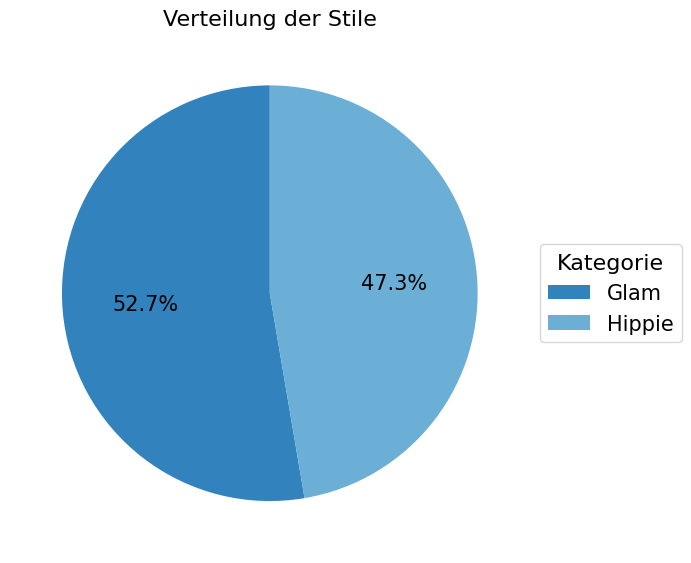

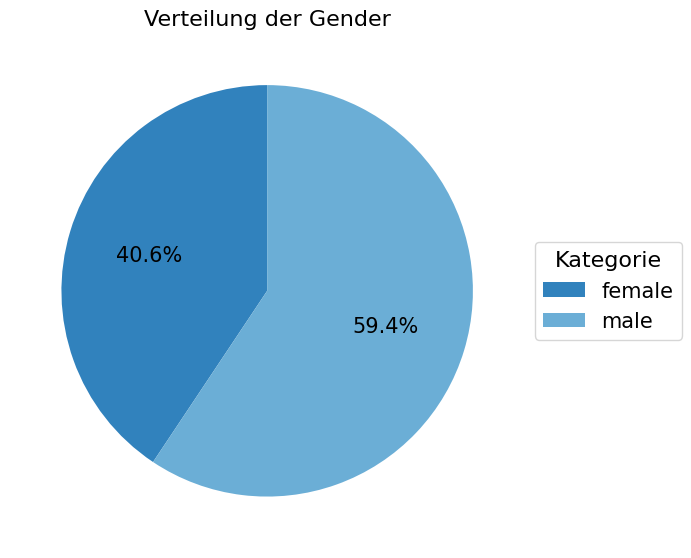

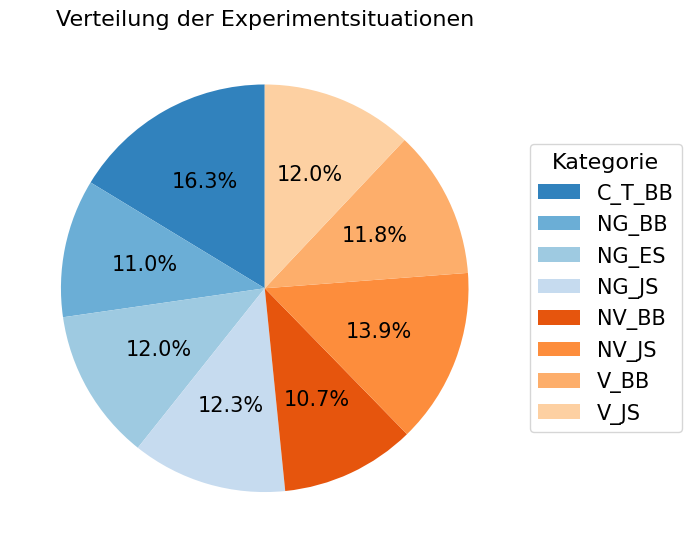

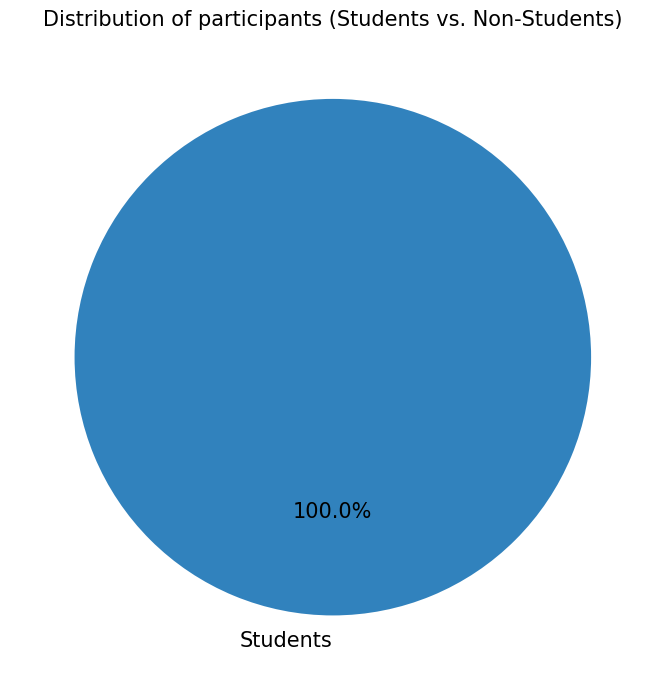

In [19]:
df = pd.read_csv(experiment_path1)
df.columns = df.columns.str.strip()  # Spaltennamen säubern

# Funktion für besser lesbare Pie-Charts
def plot_pie_with_legend(data_series, title):
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(
        data_series,
        labels=None,  # Labels nicht direkt in den Plot
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("tab20c"),
        textprops={'fontsize': 15}
    )
    
    plt.legend(
        wedges,
        data_series.index,
        title="Kategorie",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=15,
        title_fontsize=16
    )
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Anwendungsbeispiele
plot_pie_with_legend(df['Style'].value_counts().sort_index(), "Verteilung der Stile")
plot_pie_with_legend(df['Gender'].value_counts().sort_index(), "Verteilung der Gender")
plot_pie_with_legend(df['experiment'].value_counts().sort_index(), "Verteilung der Experimentsituationen")
#plot_pie_with_legend(df['Condition'].value_counts().sort_index(), "Distribution of Conditions")
#plot_pie_with_legend(df['Store'].value_counts().sort_index(), "Distribution of Stores")

# Matrikelnummern als Strings bereinigen
df["MatrikelNummer"] = df["MatrikelNummer"].astype(str).str.strip()

non_students = ["TE", "HP", "UL", "HK", "JS_N"]

# Gruppierung definieren
def classify_matrikel(m):
    return "Non-Students" if any(m.startswith(k) for k in non_students) else "Students"

df["Gruppe"] = df["MatrikelNummer"].apply(classify_matrikel)

# Zähle pro Gruppe
gruppe_counts = df["Gruppe"].value_counts()

# Plot
plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    gruppe_counts,
    labels=gruppe_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("tab20c"),
    textprops={'fontsize': 15}
)

plt.title("Distribution of participants (Students vs. Non-Students)", fontsize=15)
plt.tight_layout()
plt.show()

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/3352729419.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_distribution = df.groupby(["Style", "Alter_Cat"]).size().reset_index(name="n")


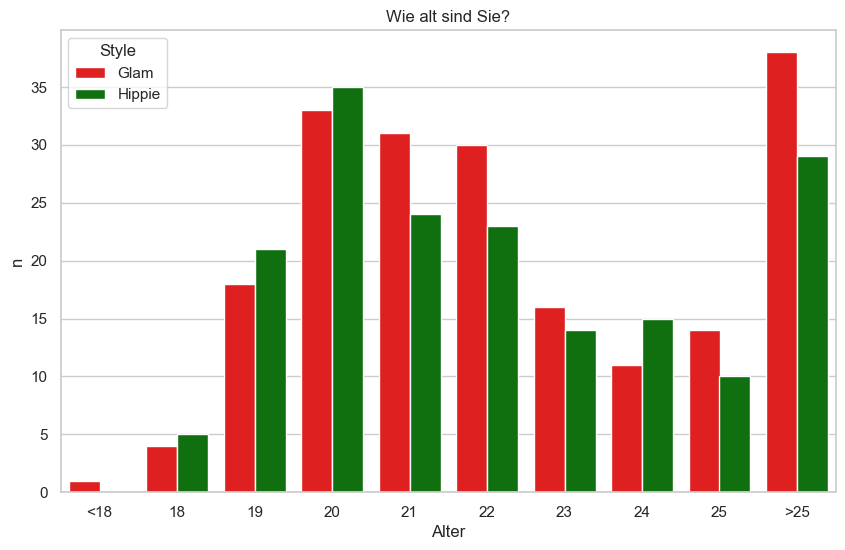

In [103]:
# Alterskategorien erstellen
df=pd.read_csv(experiment_path1)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Alter_Cat"] = pd.cut(
    df["Age"],
    bins=[-float('inf'), 17, 18, 19, 20, 21, 22, 23, 24, 25, float('inf')],
    labels=["<18", "18", "19", "20", "21", "22", "23", "24", "25", ">25"]
)

# Gruppieren der Daten nach Alter und Style
age_distribution = df.groupby(["Style", "Alter_Cat"]).size().reset_index(name="n")

# Barplot erstellen
plt.figure(figsize=(10, 6))
sns.barplot(
    data=age_distribution,
    x="Alter_Cat",
    y="n",
    hue="Style",
    palette={"Glam": "red", "Hippie": "green"}
)

# Achsenbeschriftungen und Titel
plt.xlabel("Alter")
plt.ylabel("n")
plt.title("Wie alt sind Sie?")
plt.legend(title="Style")
plt.show()

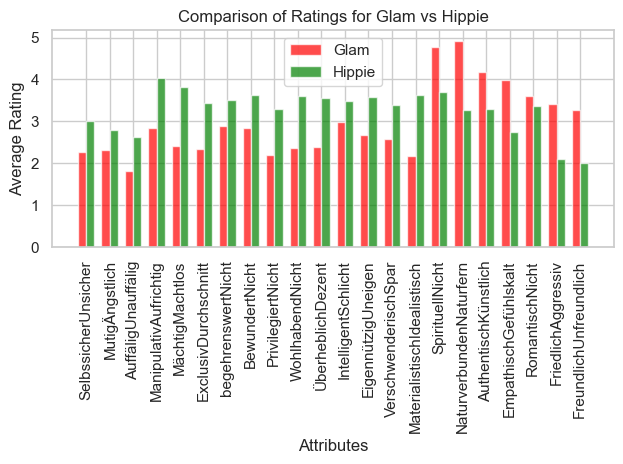

In [106]:
def plot_glam_vs_hippie_ratings(experiment_path, style_column, columns_to_plot):
    # Load the merged data
    df = pd.read_csv(experiment_path)

    # Filter rows for "glam" and "hippie"
    glam_df = df[df[style_column].str.contains("glam", case=False, na=False)]
    hippie_df = df[df[style_column].str.contains("hippie", case=False, na=False)]

    glam_means = glam_df[columns_to_plot].mean()
    hippie_means = hippie_df[columns_to_plot].mean()

    # Plot the data
    x = range(len(columns_to_plot))
    bar_width = 0.35

    plt.bar(x, glam_means, width=bar_width, label="Glam", color="red", alpha=0.7)
    plt.bar([pos + bar_width for pos in x], hippie_means, width=bar_width, label="Hippie", color="green", alpha=0.7)

    # Add labels and legend
    plt.xlabel("Attributes")
    plt.ylabel("Average Rating")
    plt.title("Comparison of Ratings for Glam vs Hippie")
    plt.xticks([pos + bar_width / 2 for pos in x], columns_to_plot, rotation=90)
    plt.legend()

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Example usage
#data_path = "/Users/caroline/Desktop/BaMarketing/15.11.Experiment/merged_data.csv"  
style_column = "Style"  
columns_to_plot = [
    "SelbssicherUnsicher", "MutigÄngstlich", "AuffäligUnauffälig", "ManipulativAufrichtig", 
    "MächtigMachtlos", "ExclusivDurchschnitt", "begehrenswertNicht", "BewundertNicht", 
    "PrivilegiertNicht", "WohlhabendNicht", "ÜberheblichDezent", "IntelligentSchlicht", 
    "EigennützigUneigen", "VerschwenderischSpar", "MaterialistischIdealistisch", 
    "SpirituellNicht", "NaturverbundenNaturfern", "AuthentischKünstlich", 
    "EmpathischGefühlskalt", "RomantischNicht", "FriedlichAggressiv", 
    "FreundlichUnfreundlich"
]
plot_glam_vs_hippie_ratings(experiment_path1, style_column, columns_to_plot)

In [ ]:
# Politische Einstellung Plot

# Gruppieren der Daten nach Style und Politischer Einstellung
politics_distribution = df.groupby(["Style", "PolitischeEinstellung1Links11Rechts"]).size().reset_index(name="n")

# Plot erstellen
plt.figure(figsize=(10, 6))
for style, group_data in politics_distribution.groupby("Style"):
    plt.plot(
        group_data["PolitischeEinstellung1LinksRechts"],
        group_data["n"],
        marker='o',
        label=style
    )

# Achsenbeschriftungen und Titel
plt.xlabel("(1=Links, 11=Rechts)")
plt.ylabel("n")
plt.title("Politische Einstellung")
plt.xticks(range(1, 12))  # Werte von 1 bis 11
plt.legend(title="Style", loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/571645503.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels_left)


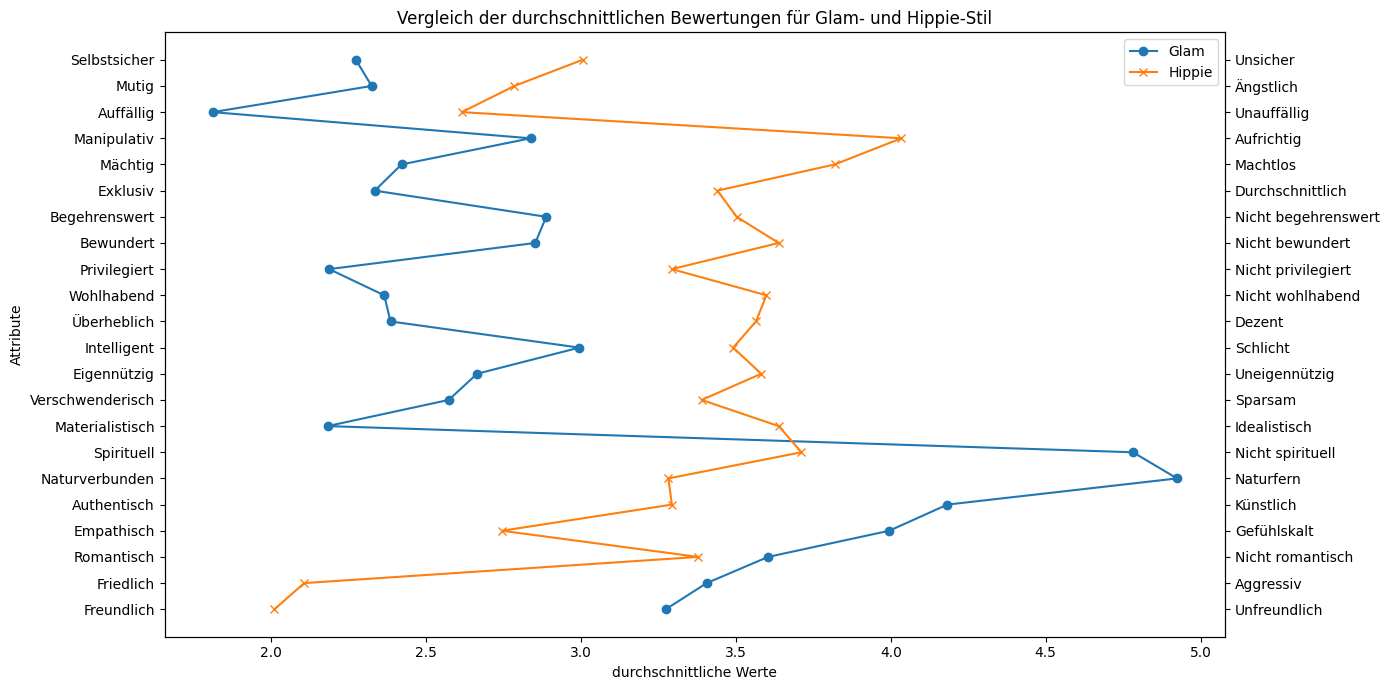

In [20]:
#Assoziationen
# Ensure the dataset is grouped by style and averages are calculated
df = pd.read_csv(experiment_path1)
asso_merged_df = df

# Definiere die Spalten, die gemittelt werden sollen
# Liste der Spalten, die gemittelt werden sollen
columns = [
    "SelbssicherUnsicher", "MutigÄngstlich", "AuffäligUnauffälig", "ManipulativAufrichtig", "MächtigMachtlos",
    "ExclusivDurchschnitt", "begehrenswertNicht", "BewundertNicht", "PrivilegiertNicht", "WohlhabendNicht",
    "ÜberheblichDezent", "IntelligentSchlicht", "EigennützigUneigen", "VerschwenderischSpar",
    "MaterialistischIdealistisch", "SpirituellNicht", "NaturverbundenNaturfern", "AuthentischKünstlich",
    "EmpathischGefühlskalt", "RomantischNicht", "FriedlichAggressiv", "FreundlichUnfreundlich"
]

# Mittelwerte pro Stil berechnen
mean_values = df.groupby('Style')[columns].mean().T

# Plot erstellen
plt.figure(figsize=(14, 7))
ax1 = plt.gca()

# Linien für jeden Stil plotten
for style in ['Glam', 'Hippie']:
    if style in mean_values.columns:
        ax1.plot(mean_values[style], mean_values.index, label=style, marker='o' if style == 'Glam' else 'x')

# Achsenbeschriftung
ax1.set_xlabel('durchschnittliche Werte')
ax1.set_ylabel('Attribute')
ax1.set_title('Vergleich der durchschnittlichen Bewertungen für Glam- und Hippie-Stil')

# Zweite Y-Achse
ax2 = ax1.twinx()
ax2.set_yticks(ax1.get_yticks())
ax2.set_yticklabels(ax1.get_yticklabels())

# Achsen umdrehen
ax1.invert_yaxis()
ax2.invert_yaxis()

# Linke und rechte Beschriftungen
labels_left = [
    "Selbstsicher", "Mutig", "Auffällig", "Manipulativ", "Mächtig",
    "Exklusiv", "Begehrenswert", "Bewundert", "Privilegiert", "Wohlhabend",
    "Überheblich", "Intelligent", "Eigennützig", "Verschwenderisch",
    "Materialistisch", "Spirituell", "Naturverbunden", "Authentisch",
    "Empathisch", "Romantisch", "Friedlich", "Freundlich"
]

labels_right = [
    "Unsicher", "Ängstlich", "Unauffällig", "Aufrichtig", "Machtlos",
    "Durchschnittlich", "Nicht begehrenswert", "Nicht bewundert", "Nicht privilegiert", "Nicht wohlhabend",
    "Dezent", "Schlicht", "Uneigennützig", "Sparsam",
    "Idealistisch", "Nicht spirituell", "Naturfern", "Künstlich",
    "Gefühlskalt", "Nicht romantisch", "Aggressiv", "Unfreundlich"
]

# Setze die Labels
ax1.set_yticklabels(labels_left)
ax2.set_yticklabels(labels_right)

# Achsenlimits synchronisieren
ax2.set_ylim(ax1.get_ylim())

# Legende und Layout
ax1.legend()
plt.tight_layout()
plt.show()


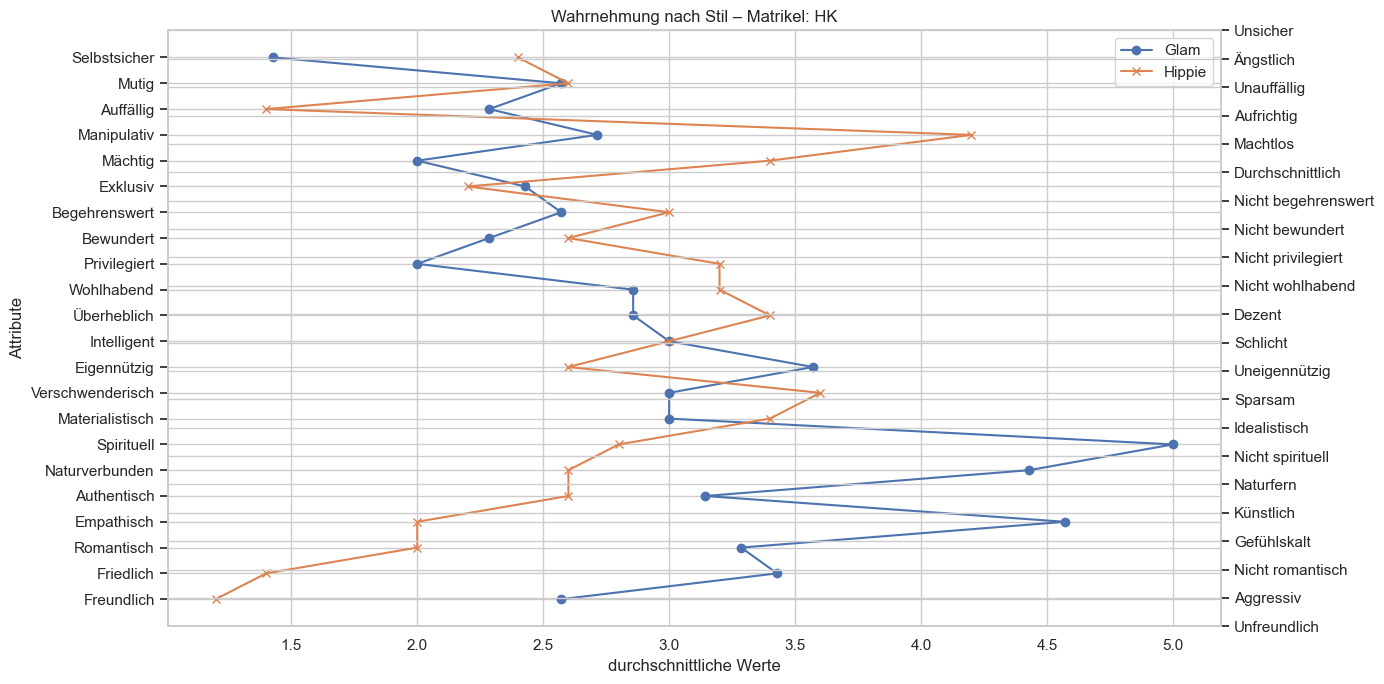

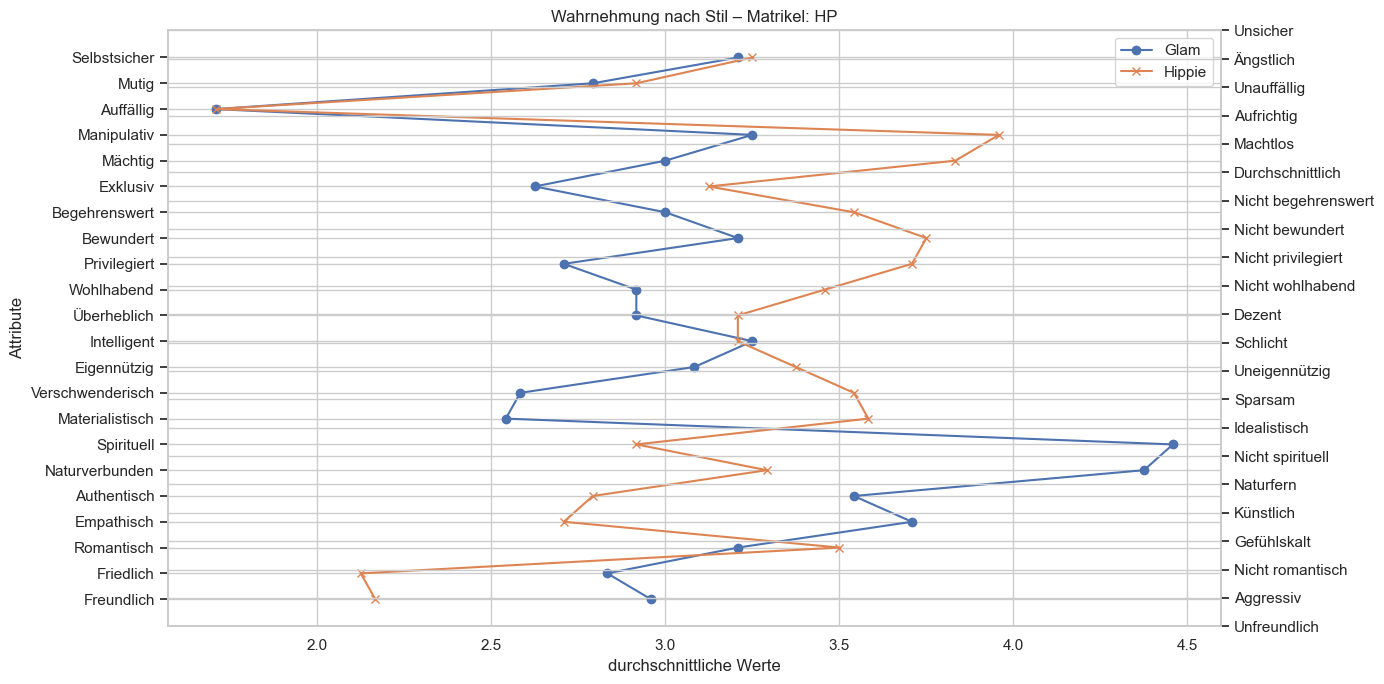

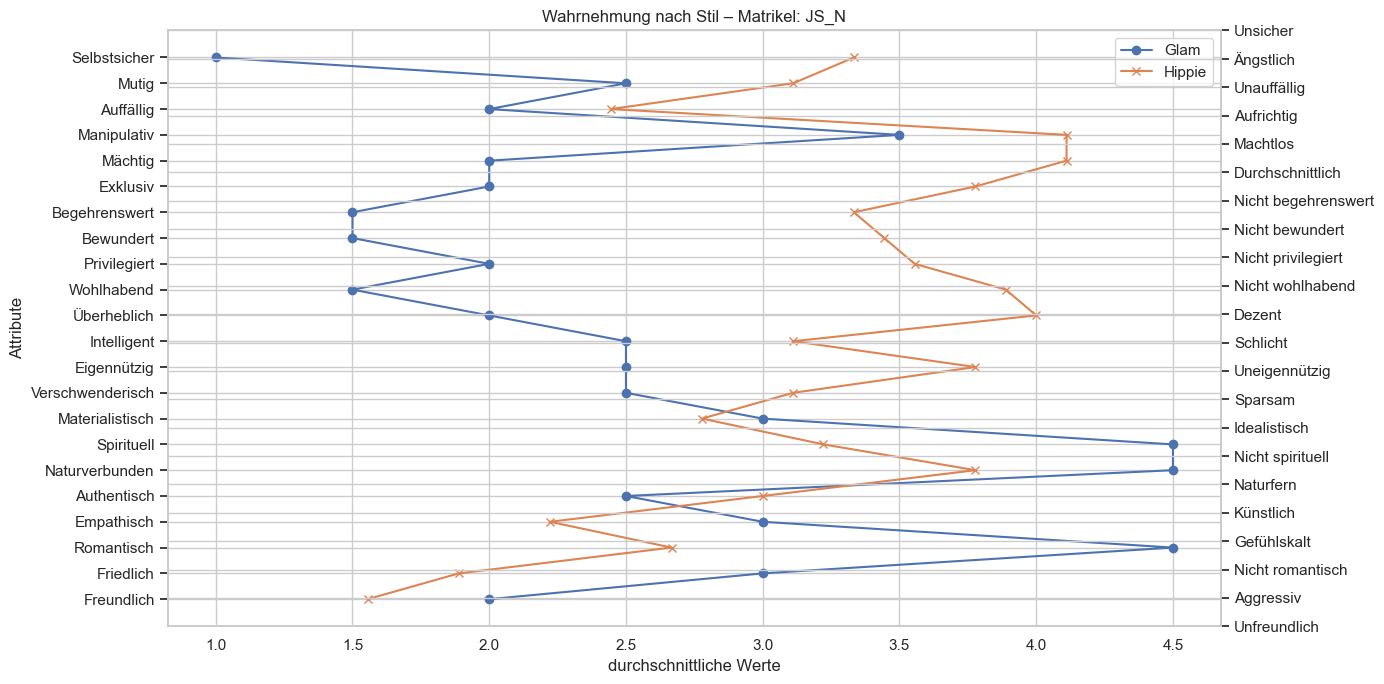

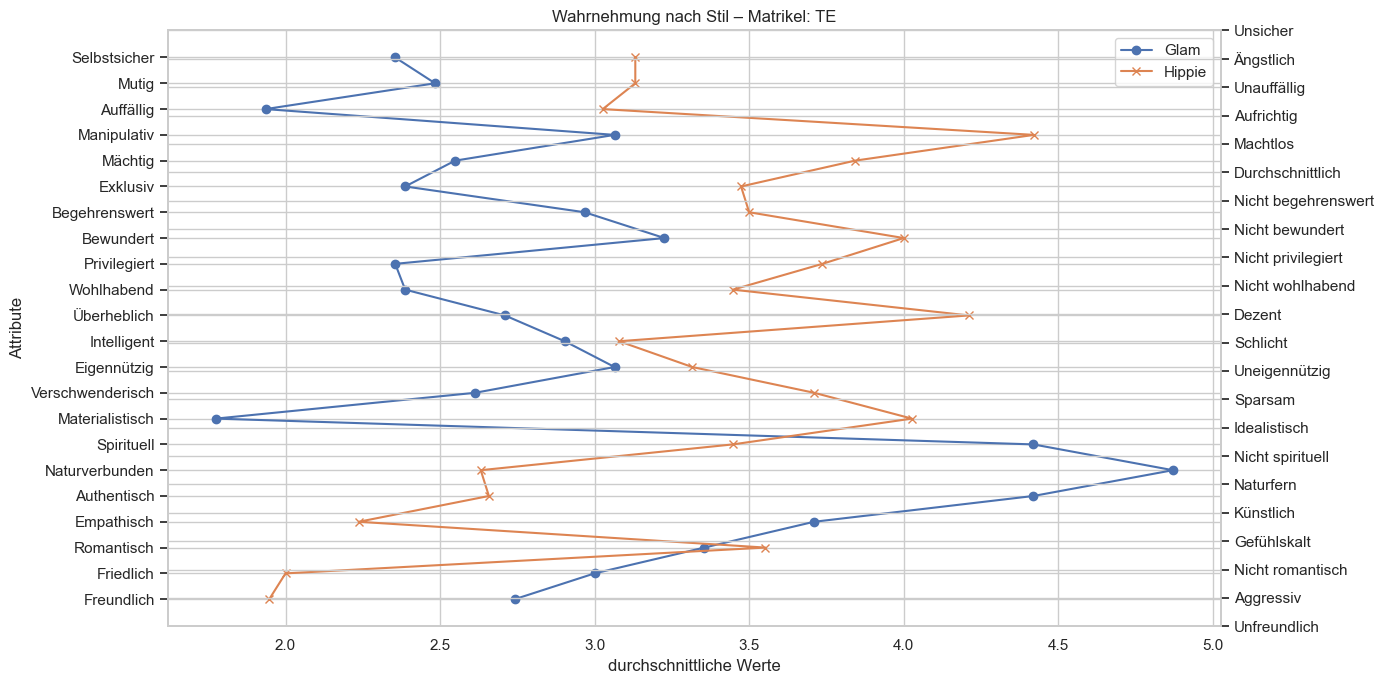

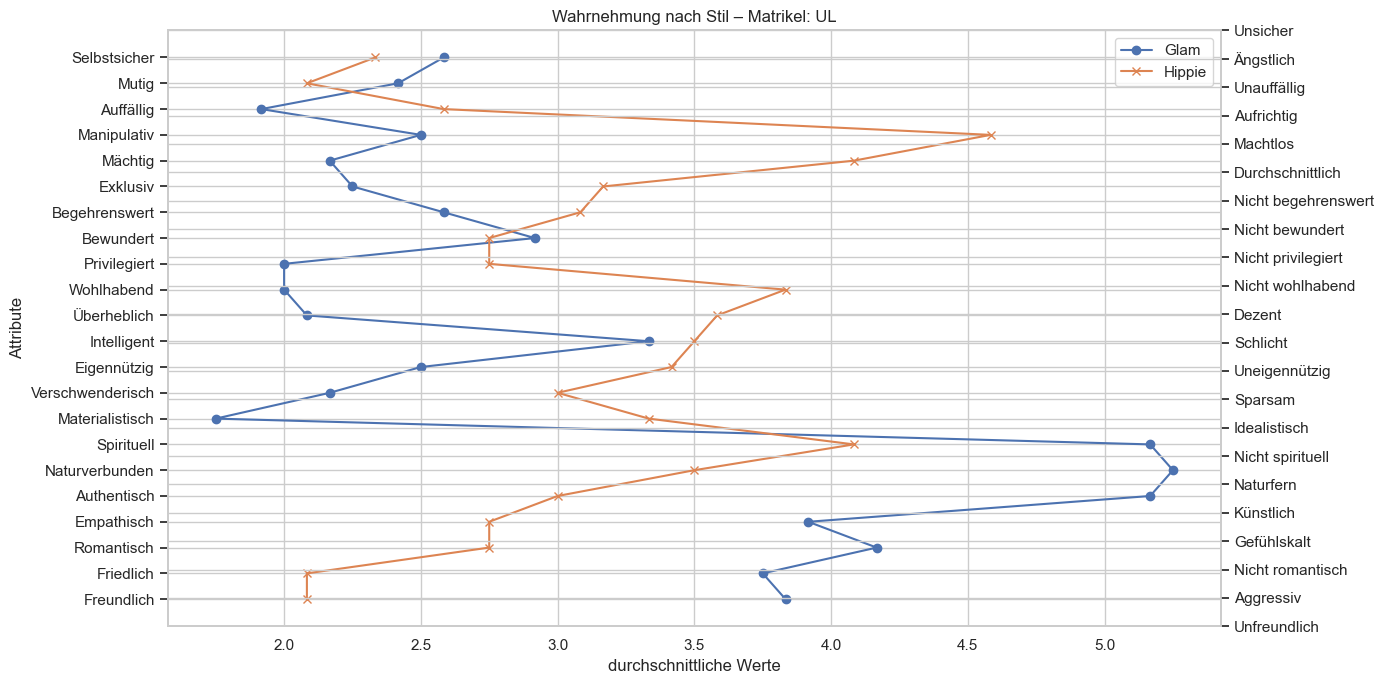

In [82]:
with open(experiment_path2) as f:
    lines = f.readlines()

header = lines[0].strip().split(",")
data = "".join(lines[1:])
df = pd.read_csv(StringIO(data), names=header)

# Relevante Spalten
columns = [
    "SelbssicherUnsicher", "MutigÄngstlich", "AuffäligUnauffälig", "ManipulativAufrichtig", "MächtigMachtlos",
    "ExclusivDurchschnitt", "begehrenswertNicht", "BewundertNicht", "PrivilegiertNicht", "WohlhabendNicht",
    "ÜberheblichDezent", "IntelligentSchlicht", "EigennützigUneigen", "VerschwenderischSpar",
    "MaterialistischIdealistisch", "SpirituellNicht", "NaturverbundenNaturfern", "AuthentischKünstlich",
    "EmpathischGefühlskalt", "RomantischNicht", "FriedlichAggressiv", "FreundlichUnfreundlich"
]

# Umwandlung der numerischen Werte

for col in columns:
    if df[col].dtype == "object":
        df[col] = pd.to_numeric(df[col].str.replace(",", "."), errors="coerce")
    else:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# Nur relevante Matrikelnummern filtern
patterns = ["UL", "HP", "TE", "HK", "JS_N"]
filtered_df = df[df["MatrikelNummer"].astype(str).str.startswith(tuple(patterns))]

# Plot pro Matrikelnummer
for matrikel, group in filtered_df.groupby("MatrikelNummer"):
    mean_values = group.groupby("Style")[columns].mean().T
    
    plt.figure(figsize=(14, 7))
    ax1 = plt.gca()

    for style in ['Glam', 'Hippie']:
        if style in mean_values.columns:
            ax1.plot(mean_values[style], mean_values.index, label=style, marker='o' if style == 'Glam' else 'x')

    ax1.set_xlabel('durchschnittliche Werte')
    ax1.set_ylabel('Attribute')
    ax1.set_title(f'Wahrnehmung nach Stil – Matrikel: {matrikel}')
    
    # Y-Achsen-Beschriftung
    ax1.set_yticks(range(len(columns)))
    ax1.set_yticklabels([
        "Selbstsicher", "Mutig", "Auffällig", "Manipulativ", "Mächtig",
        "Exklusiv", "Begehrenswert", "Bewundert", "Privilegiert", "Wohlhabend",
        "Überheblich", "Intelligent", "Eigennützig", "Verschwenderisch",
        "Materialistisch", "Spirituell", "Naturverbunden", "Authentisch",
        "Empathisch", "Romantisch", "Friedlich", "Freundlich"
    ])
    
    ax2 = ax1.twinx()
    ax2.set_yticks(range(len(columns)))
    ax2.set_yticklabels([
        "Unsicher", "Ängstlich", "Unauffällig", "Aufrichtig", "Machtlos",
        "Durchschnittlich", "Nicht begehrenswert", "Nicht bewundert", "Nicht privilegiert", "Nicht wohlhabend",
        "Dezent", "Schlicht", "Uneigennützig", "Sparsam",
        "Idealistisch", "Nicht spirituell", "Naturfern", "Künstlich",
        "Gefühlskalt", "Nicht romantisch", "Aggressiv", "Unfreundlich"
    ])
    
    ax1.invert_yaxis()
    ax2.invert_yaxis()
    ax1.legend()
    plt.tight_layout()
    plt.show()

In [ ]:


# Spaltennamen anpassen (ersetzen durch die tatsächlichen Spaltennamen)
column_name = "GeldProMonatKleidung"  # Ersetze dies durch die tatsächliche Spaltenüberschrift
df["Clothing_Expense_Category"] = df[column_name].map({
    0: "<100€",
    1: "101€-250€",
    2: "251€-500€",
    3: "501€-900€",
    4: ">900€"
})

# Gruppieren der Daten
clothing_expense_distribution = df.groupby(["Style", "GeldProMonatKleidung"]).size().reset_index(name="n")

# Plot erstellen
plt.figure(figsize=(10, 6))
for style, group_data in clothing_expense_distribution.groupby("Style"):
    plt.bar(
        group_data["GeldProMonatKleidung"],
        group_data["n"],
        label=style,
        alpha=0.7
    )

# Anpassung der Achsen und Titel
plt.xlabel("Geld")
plt.ylabel("n")
plt.title("Wie viel Geld geben Sie pro Monat für Kleidung aus?")
plt.xticks(rotation=45)
plt.legend(title="Style", loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Map column values (0-6) to categories
income_mapping = {
    0: "<249€",
    1: "250€-499€",
    2: "500€-999€",
    3: "1000€-1499€",
    4: "1500€-1999€",
    5: ">=2000€"
}

# Replace the values in the column with the mapped categories
df["Income_Cat"] = df["GeldProMonat"].map(income_mapping)

# Group data by Style and Income_Cat
income_distribution = df.groupby(["Style", "Income_Cat"]).size().reset_index(name="n")

# Plot the data
plt.figure(figsize=(10, 6))
for style in income_distribution["Style"].unique():
    style_data = income_distribution[income_distribution["Style"] == style]
    plt.bar(
        style_data["Income_Cat"],
        style_data["n"],
        label=style,
        alpha=0.7
        #palette={"Glam": "red", "Hippie": "green"}
    )

plt.title("Welchen Betrag haben Sie pro Monat zur freien Verfügung?")
plt.xlabel("Geld")
plt.ylabel("n")
plt.legend(title="Style")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/4218406684.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(


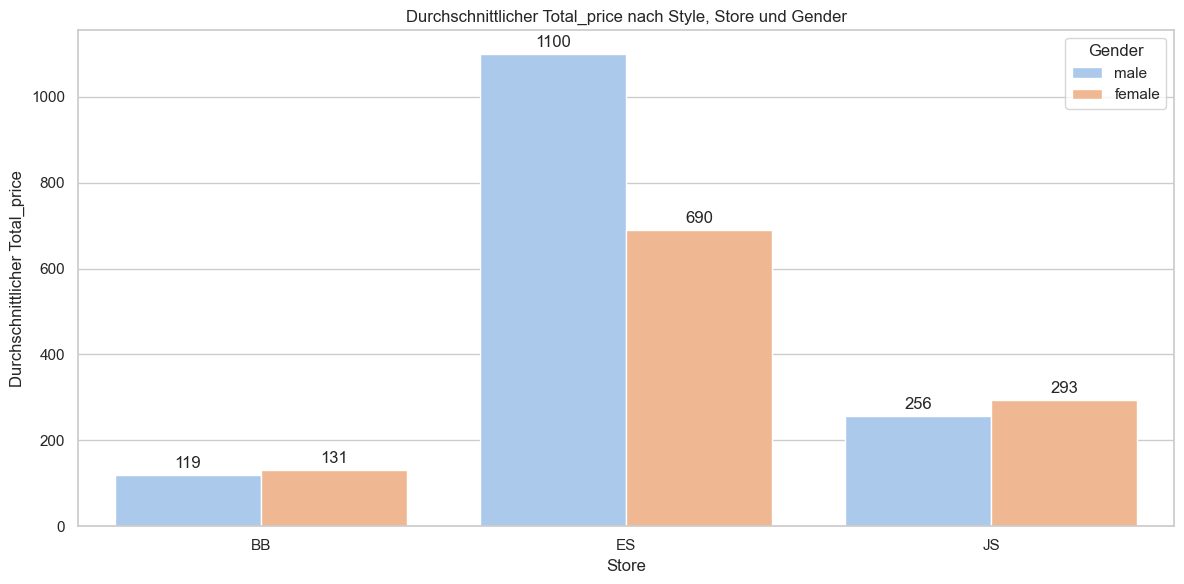

In [21]:
#data_path = "/Users/caroline/Downloads/Experiment Results-4/merged_data.csv"
df = pd.read_csv(experiment_path1)

# Store aus der Spalte 'experiment' ableiten
df["Store"] = df["experiment"].apply(
    lambda x: "BB" if "BB" in x else ("JS" if "JS" in x else ("ES" if "ES" in x else "Unknown"))
)
df = df[df["experiment_num"] != 2]
# Durchschnittlichen Total_price pro Style, Store, Gender berechnen
mean_prices = (
    df.groupby(["Style", "Store", "Gender"])["Total_price"]
    .mean()
    .reset_index()
    .rename(columns={"Total_price": "Average_Total_Price"})
)

# Plot erstellen
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

barplot = sns.barplot(
    data=mean_prices,
    x="Store",
    y="Average_Total_Price",
    hue="Gender",
    palette="pastel",
    ci=None,
    hue_order=["male", "female"],
)

# Balkenbeschriftungen
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.title("Durchschnittlicher Total_price nach Style, Store und Gender")
plt.xlabel("Store")
plt.ylabel("Durchschnittlicher Total_price")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

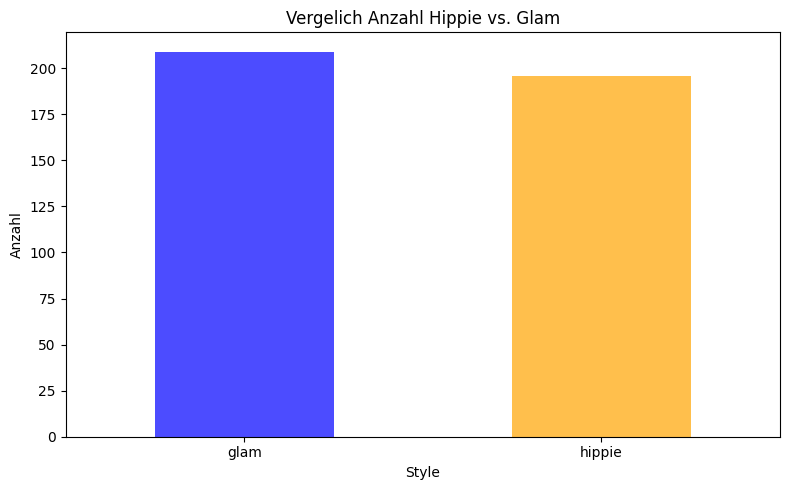

In [ ]:
#data_path = "/Users/caroline/Downloads/Experiment Results-4/merged_data.csv"
df = pd.read_csv(experiment_path1)

# Check if the Style column exists
style_column = "Style"
if style_column not in df.columns:
    raise ValueError(f"'{style_column}' column not found in the dataset.")

# Count the occurrences of each style (Glam and Hippie)
style_counts = df[style_column].str.lower().value_counts()

# Filter only for glam and hippie counts
style_counts = style_counts[['glam', 'hippie']] if {'glam', 'hippie'}.issubset(style_counts.index) else style_counts

# Plot the bar chart
plt.figure(figsize=(8, 5))
style_counts.plot(kind='bar', color=['blue', 'orange'], alpha=0.7)

# Add labels and title
plt.xlabel("Style")
plt.ylabel("Anzahl")
plt.title("Vergelich Anzahl Hippie vs. Glam")
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

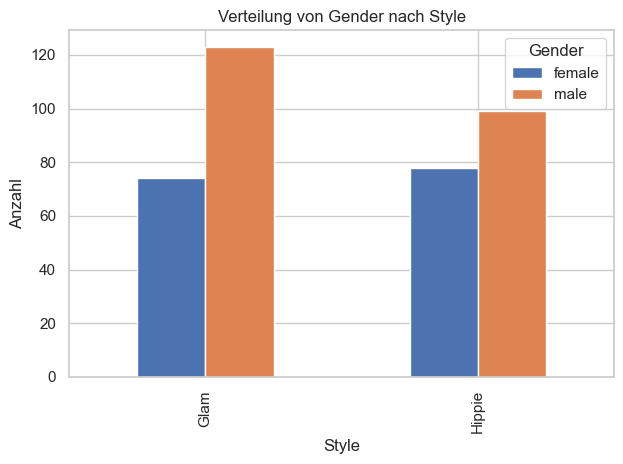

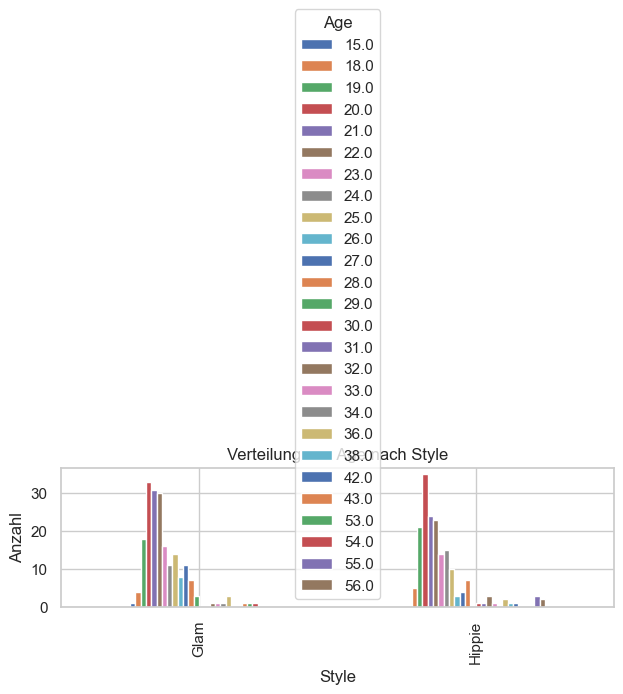

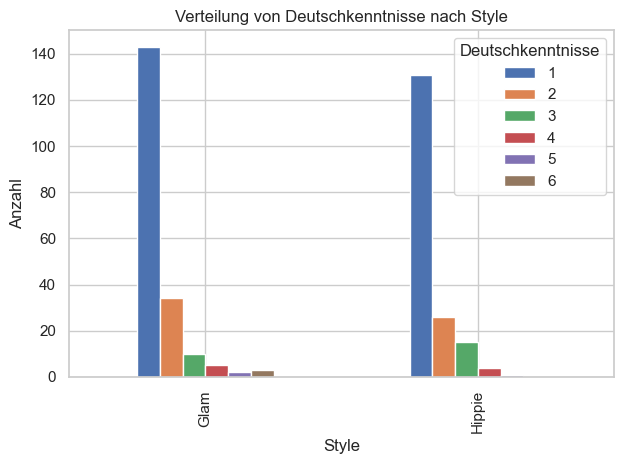

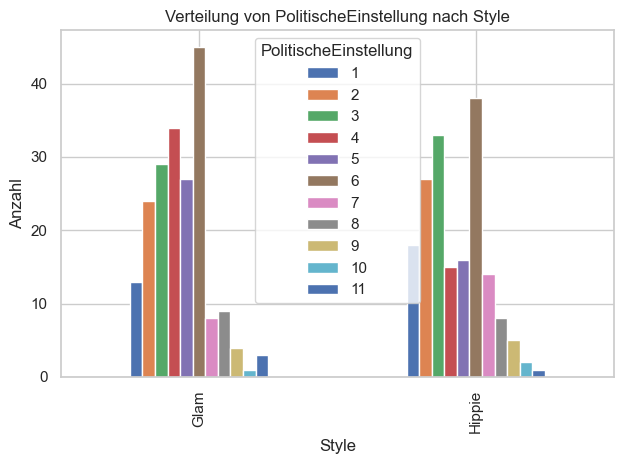

In [22]:
df = pd.read_csv(experiment_path1)

# Definition der Variablen für die Kreuztabellen
variablen = ['Gender', 'Age', 'Deutschkenntnisse', 'PolitischeEinstellung']
ziel_kategorie = 'Style'  # z.B. 'Style' = Glam / Hippie

# Plot-Funktion
def plot_crosstable(df, feature, ziel_kategorie):
    crosstab = pd.crosstab(df[ziel_kategorie], df[feature])
    crosstab.plot(kind='bar', stacked=False)
    plt.title(f'Verteilung von {feature} nach {ziel_kategorie}')
    plt.ylabel('Anzahl')
    plt.xlabel(ziel_kategorie)
    plt.legend(title=feature)
    plt.tight_layout()
    plt.show()

# Heatmap-Alternative
def plot_heatmap(df, feature, ziel_kategorie):
    crosstab = pd.crosstab(df[ziel_kategorie], df[feature])
    plt.figure(figsize=(6, 4))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Heatmap: {feature} vs. {ziel_kategorie}')
    plt.xlabel(feature)
    plt.ylabel(ziel_kategorie)
    plt.tight_layout()
    plt.show()

# Alle Variablen plotten
for var in variablen:
    plot_crosstable(df, var, ziel_kategorie)
    # plot_heatmap(df, var, ziel_kategorie)  # Optional alternative


### Studie 1 - spezifische Plots

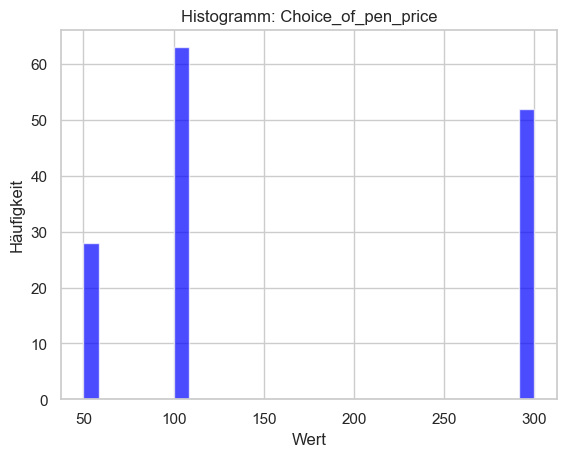

Welch's T-Test Ergebnis:
t-statistic = 2.9092912972468405
p-value (one-sided) = 0.9978947206894111
95% confidence interval: (16.282830506842465, 83.521091061785)
mean in group 0 = 186.66666666666666, mean in group 1 = 136.76470588235293


In [26]:
df = pd.read_csv(experiment_path1)
df_cleaned = df[df['Choice_of_pen_price'] != '.']

import matplotlib.pyplot as plt

# Beispiel: Spalte "Platzwahl_Geld"
plt.hist(df_cleaned["Choice_of_pen_price"].dropna(), bins=30, alpha=0.7, color='blue')
plt.title("Histogramm: Choice_of_pen_price")
plt.xlabel("Wert")
plt.ylabel("Häufigkeit")
plt.show()


# Filter die Werte für die Gruppen
group_0 = df[df['Style_new'] == 0]['Choice_of_pen_price']
group_1 = df[df['Style_new'] == 1]['Choice_of_pen_price']

# Konvertiere die Daten in numerische Werte und entferne NaN-Werte
group_0 = pd.to_numeric(group_0, errors='coerce').dropna()
group_1 = pd.to_numeric(group_1, errors='coerce').dropna()

# Welch-T-Test durchführen (einseitig, alternative="less")
t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

# Da der Welch-Test in Python standardmäßig zweiseitig ist, halbiere den p-Wert für eine einseitige Hypothese
p_value_one_sided = p_value / 2 if t_stat < 0 else 1 - (p_value / 2)

# Ergebnisse anzeigen
print(f"Welch's T-Test Ergebnis:")
print(f"t-statistic = {t_stat}")
print(f"p-value (one-sided) = {p_value_one_sided}")

# Berechnung des 95%-Konfidenzintervalls für den Unterschied der Mittelwerte
mean_diff = np.mean(group_0) - np.mean(group_1)
std_err = np.sqrt(np.var(group_0, ddof=1) / len(group_0) + np.var(group_1, ddof=1) / len(group_1))
ci_lower = mean_diff - 1.96 * std_err
ci_upper = mean_diff + 1.96 * std_err

print(f"95% confidence interval: ({ci_lower}, {ci_upper})")
print(f"mean in group 0 = {np.mean(group_0)}, mean in group 1 = {np.mean(group_1)}")

### Studie 2 - Produkt spezifisch 

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1426625759.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kosten_counts.index, y=kosten_counts.values, palette="viridis")


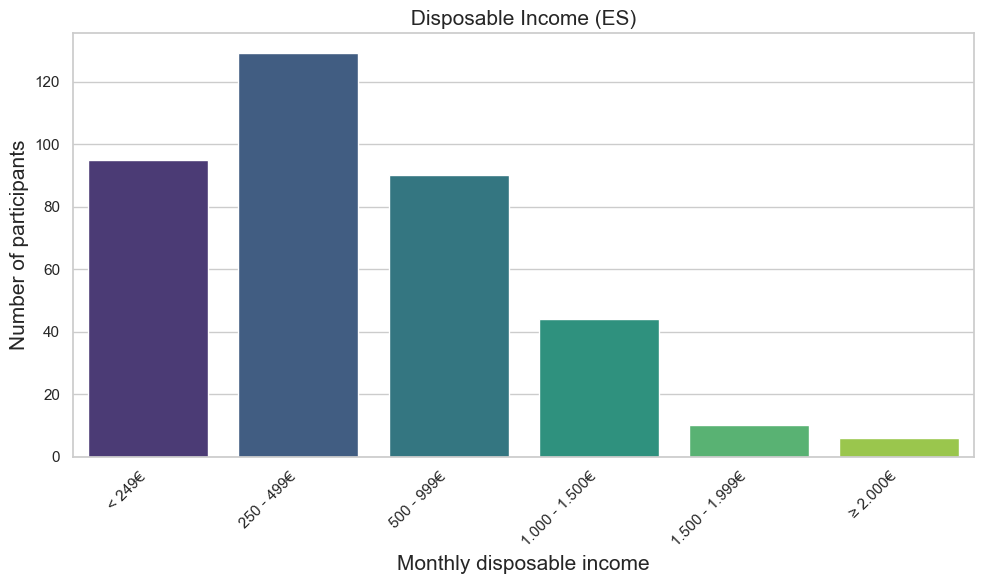

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV laden – Pfad anpassen
df = pd.read_csv(experiment_path1)

df.columns = df.columns.str.strip()

# Mapping definieren
kosten_mapping = {
    1: "< 249€",
    2: "250 - 499€",
    3: "500 - 999€",
    4: "1.000 - 1.500€",
    5: "1.500 - 1.999€",
    6: "≥ 2.000€"
}
#kosten_mapping = {
 #   1: "< 100€",
  #  2: "101 - 250€",
   # 3: "251 - 500€",
    #4: "501 - 900€",
    #5: ">= 900€",
#}
# Mapping anwenden
df["Kosten_Monat_Kategorie"] = df["Kosten_Monat"].map(kosten_mapping)

# Häufigkeiten zählen
kosten_counts = df["Kosten_Monat_Kategorie"].value_counts().reindex(kosten_mapping.values())

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=kosten_counts.index, y=kosten_counts.values, palette="viridis")
# Achsenbeschriftungen und Titel
plt.xlabel("Monthly disposable income", fontsize=15)
plt.ylabel("Number of participants", fontsize=15)
plt.title(" Disposable Income (ES) ", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


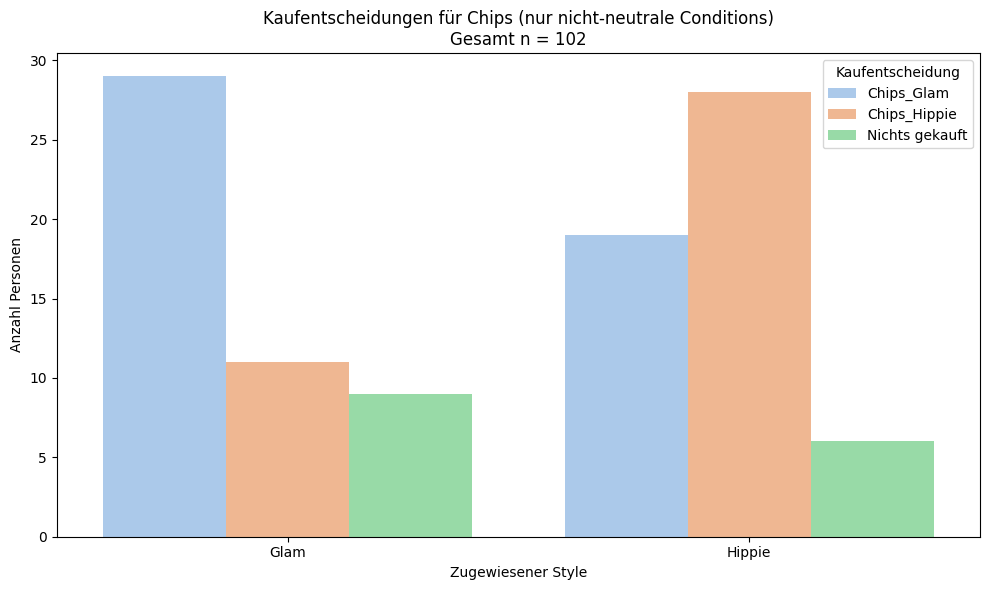

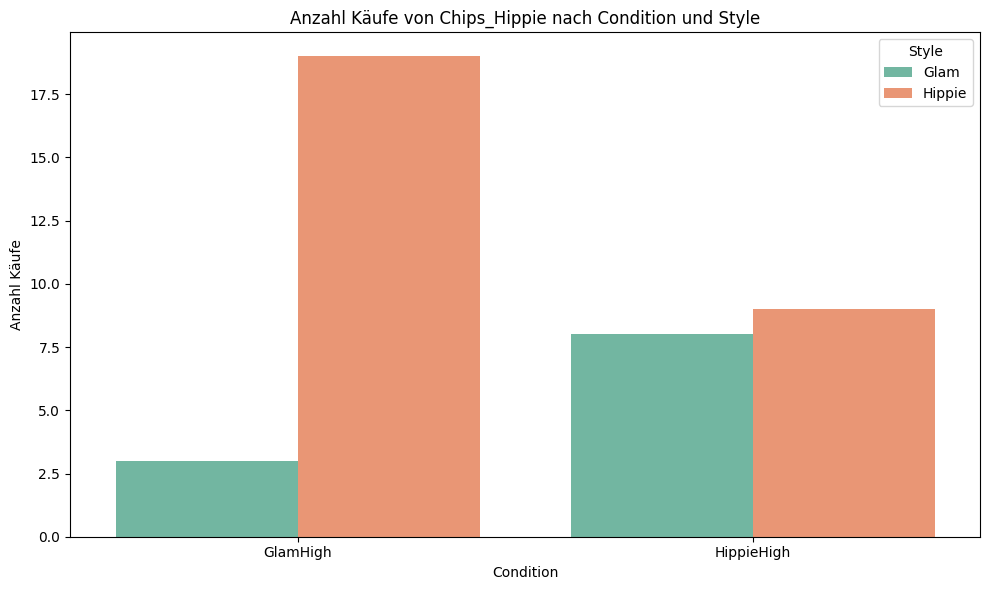

In [92]:
# Teilnehmer mit Condition != Neutral filtern
df= pd.read_csv(experiment_path2)
df_filtered = df[df['Condition'].str.contains('Neutral') == False].copy()

# Neue Spalte für Kaufentscheidung
def chips_kaufkategorie(row):
    if row['Chips_Hippie'] == 1:
        return 'Chips_Hippie'
    elif row['Chips_Glam'] == 1:
        return 'Chips_Glam'
    else:
        return 'Nichts gekauft'

df_filtered['Kaufentscheidung'] = df_filtered.apply(chips_kaufkategorie, axis=1)

# Gruppierung nach Style und Kaufentscheidung
kauf_counts = df_filtered.groupby(['Style', 'Kaufentscheidung']).size().reset_index(name='Anzahl')

# Gesamte Anzahl Teilnehmende für die Legende
gesamt_anzahl = len(df_filtered)

# Plot erstellen
plt.figure(figsize=(10, 6))
sns.barplot(data=kauf_counts, x='Style', y='Anzahl', hue='Kaufentscheidung', palette="pastel")
plt.title(f'Kaufentscheidungen für Chips (nur nicht-neutrale Conditions)\nGesamt n = {gesamt_anzahl}')
plt.ylabel('Anzahl Personen')
plt.xlabel('Zugewiesener Style')
plt.legend(title='Kaufentscheidung')
plt.tight_layout()
plt.show()


# Filter auf Fälle mit Chips_Hippie-Kauf und nicht-neutraler Condition
df_hippie = df[(df['Chips_Hippie'] == 1) & (df['Condition'].str.contains('Neutral') == False)].copy()

# Gruppieren nach Style und Condition
hippie_counts = df_hippie.groupby(['Style', 'Condition']).size().reset_index(name='Anzahl')

# Plot erstellen
plt.figure(figsize=(10, 6))
sns.barplot(data=hippie_counts, x='Condition', y='Anzahl', hue='Style', palette='Set2')
plt.title('Anzahl Käufe von Chips_Hippie nach Condition und Style')
plt.ylabel('Anzahl Käufe')
plt.xlabel('Condition')
plt.tight_layout()
plt.show()



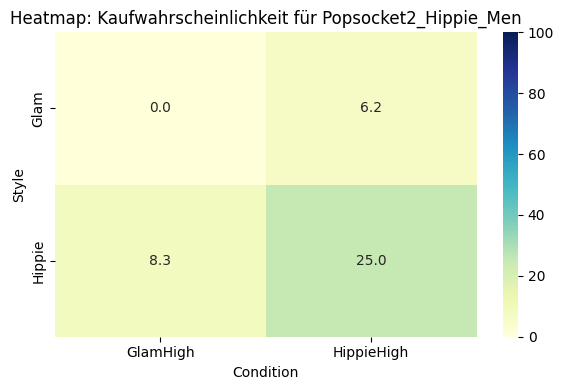

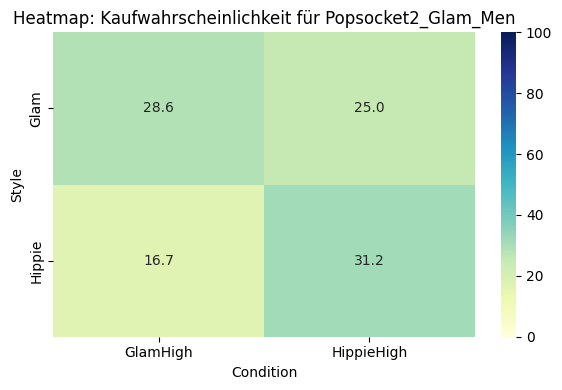

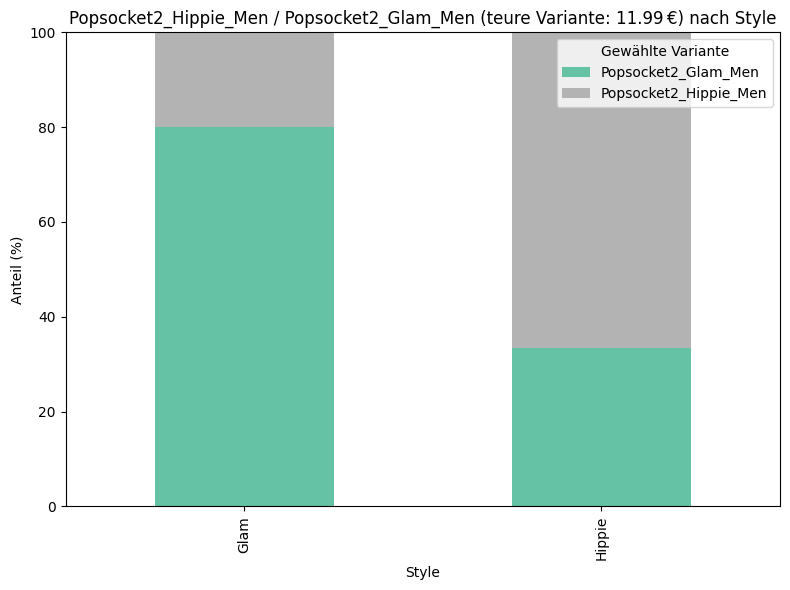

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/2704503314.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=preis_df, x='Preis (€)', y='Prozent', palette='Blues')


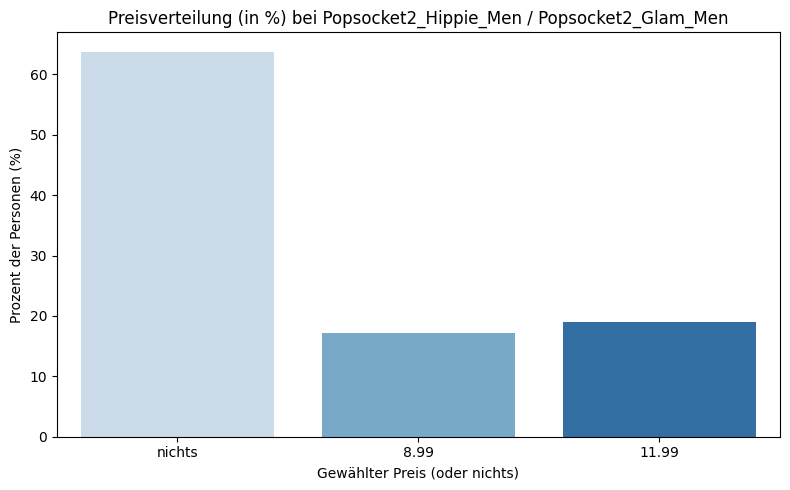

                       Kategorie  Anzahl     Prozent
0                         Gesamt      58  100.000000
1  Popsocket2_Hippie_Men gekauft       6   10.344828
2    Popsocket2_Glam_Men gekauft      15   25.862069
3                      Kein Kauf      37   63.793103


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/2704503314.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Kategorie', y='Prozent', palette='Set2')


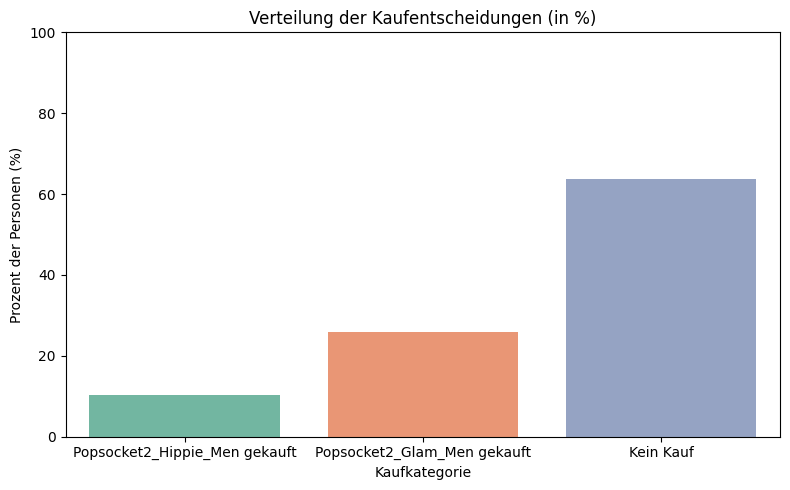

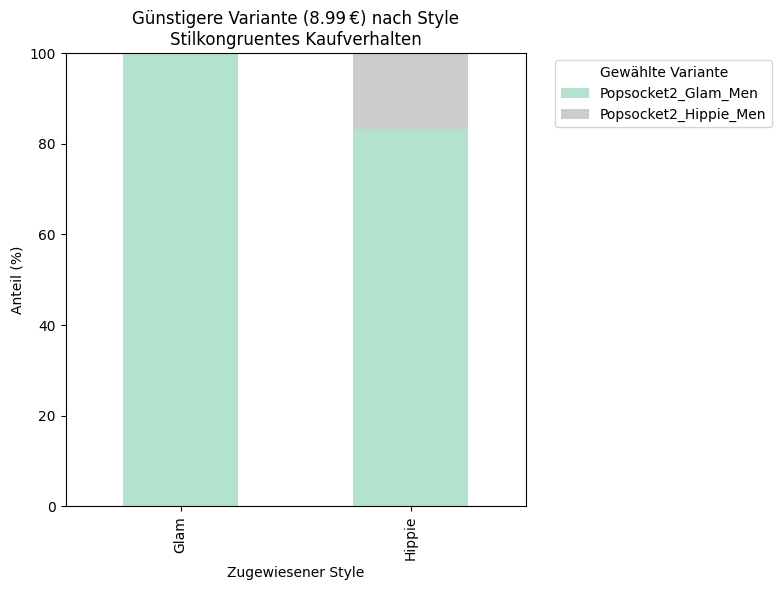

In [377]:
df = pd.read_csv(experiment_path2)
def produktanalyse_manuell(df, hippie_col: str, glam_col: str, teuer_preis: float):
    hippie_price_col = f"{hippie_col}_price"
    glam_price_col = f"{glam_col}_price"

    df = df[df['Condition'].str.contains('Neutral') == False].copy()
    df = df[['Style', 'Condition', hippie_col, glam_col, hippie_price_col, glam_price_col]].copy()
    df = df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

    # Heatmaps
    for spalte in [hippie_col, glam_col]:
        df['kauf'] = df[spalte]
        gruppiert = df.groupby(['Style', 'Condition'])['kauf'].agg(['sum', 'count']).reset_index()
        gruppiert['Anteil (%)'] = 100 * gruppiert['sum'] / gruppiert['count']
        pivot = gruppiert.pivot(index='Style', columns='Condition', values='Anteil (%)')
        plt.figure(figsize=(6, 4))
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap='YlGnBu', vmin=0, vmax=100)
        plt.title(f'Heatmap: Kaufwahrscheinlichkeit für {spalte}')
        plt.tight_layout()
        plt.show()

    # Teurer Preis
    df_teuer = df[
        ((df[hippie_col] == 1) & (df[hippie_price_col] == teuer_preis)) |
        ((df[glam_col] == 1) & (df[glam_price_col] == teuer_preis))
    ].copy()

    def gewaehlte_variante(row):
        if row[hippie_col] == 1:
            return hippie_col
        elif row[glam_col] == 1:
            return glam_col
        else:
            return 'keine'

    df_teuer['Gewählte Variante'] = df_teuer.apply(gewaehlte_variante, axis=1)

    auswertung = df_teuer.groupby(['Style', 'Gewählte Variante']).size().reset_index(name='Anzahl')
    gesamt = df_teuer.groupby('Style').size().reset_index(name='Gesamt')
    merged = pd.merge(auswertung, gesamt, on='Style')
    merged['Anteil (%)'] = 100 * merged['Anzahl'] / merged['Gesamt']
    pivot = merged.pivot(index='Style', columns='Gewählte Variante', values='Anteil (%)')

    pivot.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Set2')
    plt.title(f'{hippie_col} / {glam_col} (teure Variante: {teuer_preis} €) nach Style')
    plt.ylabel('Anteil (%)')
    plt.xlabel('Style')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

    # Preiszählung
    preise = []
    for _, row in df.iterrows():
        if row[hippie_col] == 1:
            preise.append(row[hippie_price_col])
        elif row[glam_col] == 1:
            preise.append(row[glam_price_col])
        elif(row[glam_col] == 0 or row[hippie_col] == 0):
            preise.append('nichts')

    # Zähle die Preisverteilungen
    #print(preise)
    preis_counter = Counter(preise)
    gesamt = sum(preis_counter.values())  # Gesamtanzahl aller Personen

    # Erstelle DataFrame mit Prozentangaben
    preis_df = pd.DataFrame.from_dict(preis_counter, orient='index').reset_index()
    preis_df.columns = ['Preis (€)', 'Anzahl']
    preis_df['Prozent'] = 100 * preis_df['Anzahl'] / gesamt
    preis_df['Preis (€)'] = preis_df['Preis (€)'].astype(str)

    # Sortiere ggf. numerisch (wenn sinnvoll)
    try:
        preis_df['sort_key'] = preis_df['Preis (€)'].replace('nichts', -1).astype(float)
        preis_df = preis_df.sort_values(by='sort_key')
    except:
        pass

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(data=preis_df, x='Preis (€)', y='Prozent', palette='Blues')
    plt.title(f'Preisverteilung (in %) bei {hippie_col} / {glam_col}')
    plt.ylabel('Prozent der Personen (%)')
    plt.xlabel('Gewählter Preis (oder nichts)')
    plt.tight_layout()
    plt.show()

    hippie_käufe = df[df[hippie_col] == 1].shape[0]
    glam_käufe = df[df[glam_col] == 1].shape[0]
    kein_kauf = df[(df[hippie_col] == 0) & (df[glam_col] == 0)].shape[0]

    # Berechne die Gesamtanzahl als Summe der drei Kategorien
    gesamt = hippie_käufe + glam_käufe + kein_kauf

    # Erstelle die Zusammenfassung
    summary = pd.DataFrame({
        'Kategorie': ['Gesamt', f'{hippie_col} gekauft', f'{glam_col} gekauft', 'Kein Kauf'],
        'Anzahl': [gesamt, hippie_käufe, glam_käufe, kein_kauf]
    })

    # Prozentanteile berechnen
    summary['Prozent'] = 100 * summary['Anzahl'] / summary.loc[0, 'Anzahl']

    print(summary)
    # Filtere "Gesamt" aus, da es nicht im Plot dargestellt werden soll
    plot_df = summary[summary['Kategorie'] != 'Gesamt'].copy()

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x='Kategorie', y='Prozent', palette='Set2')
    plt.title('Verteilung der Kaufentscheidungen (in %)')
    plt.ylabel('Prozent der Personen (%)')
    plt.xlabel('Kaufkategorie')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# Zusatzfunktion für günstige Preis-Analyse (manuell)
def analyse_guenstig_produkt_manuell(df, hippie_col: str, glam_col: str, guenstig_preis: float):
    hippie_price_col = f"{hippie_col}_price"
    glam_price_col = f"{glam_col}_price"

    df = df[df['Condition'].str.contains('Neutral') == False].copy()
    df = df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

    df_guenstig = df[
        ((df[hippie_col] == 1) & (df[hippie_price_col] == guenstig_preis)) |
        ((df[glam_col] == 1) & (df[glam_price_col] == guenstig_preis))
    ].copy()

    if df_guenstig.empty:
        print(f"⚠️ Keine Daten für günstige Käufe zu {guenstig_preis} € gefunden.")
        return

    def gewaehlte_variante(row):
        if row[hippie_col] == 1:
            return hippie_col
        elif row[glam_col] == 1:
            return glam_col
        else:
            return 'keine'

    df_guenstig['Gewählte Variante'] = df_guenstig.apply(gewaehlte_variante, axis=1)

    auswertung = df_guenstig.groupby(['Style', 'Gewählte Variante']).size().reset_index(name='Anzahl')
    gesamt = df_guenstig.groupby('Style').size().reset_index(name='Gesamt')
    merged = pd.merge(auswertung, gesamt, on='Style')
    merged['Anteil (%)'] = 100 * merged['Anzahl'] / merged['Gesamt']
    pivot = merged.pivot(index='Style', columns='Gewählte Variante', values='Anteil (%)')

    pivot.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Pastel2')
    plt.title(f'Günstigere Variante ({guenstig_preis} €) nach Style\nStilkongruentes Kaufverhalten')
    plt.ylabel('Anteil (%)')
    plt.xlabel('Zugewiesener Style')
    plt.ylim(0, 100)
    plt.legend(title='Gewählte Variante', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

produktanalyse_manuell(
    df,
    hippie_col="Popsocket2_Hippie_Men",
    glam_col="Popsocket2_Glam_Men",
    teuer_preis=11.99
)
analyse_guenstig_produkt_manuell(
    df,
    hippie_col="Popsocket2_Hippie_Men",
    glam_col="Popsocket2_Glam_Men",
    guenstig_preis=8.99
)
#analyse_guenstig_produkt_manuell(
 #   df,
  #  hippie_col="Popsocket2_Hippie_Women",
   # glam_col="Popsocket2_Glam_Women",
    #guenstig_preis=8.99
#)

#analyse_guenstig_produkt_manuell(
 #   df,
  #  hippie_col="PhoneCase3_Hippie_Men",
   # glam_col="PhoneCase3_Glam_Men",
    #guenstig_preis=25.00
#)

#LaptopBag1_Hippie_Women
#produktanalyse_manuell(
  # df,
  # hippie_col="LaptopBag2_Hippie_Men",
  #  glam_col="LaptopBag2_Glam_Men",
   # teuer_preis=58.0
#)

#analyse_guenstig_produkt_manuell(
    #df,
   # hippie_col="LaptopBag2_Hippie_Men",
    #glam_col="LaptopBag2_Glam_Men",
    #guenstig_preis=44.5
#)

#produktanalyse_manuell(
 #  df,
  # hippie_col="Popsocket1_Hippie_Men",
   # glam_col="Popsocket1_Glam_Men",
    #teuer_preis=11.9
#)

#analyse_guenstig_produkt_manuell(
 #   df,
  #  hippie_col="Popsocket1_Hippie_Men",
   # glam_col="Popsocket1_Glam_Men",
    #guenstig_preis=8.99
#)

#produktanalyse_manuell(
 #   df,
  #  hippie_col="Pen2_Hippie_Women",
   # glam_col="Pen2_Glam_Women",
    #teuer_preis=134
#)

#analyse_guenstig_produkt_manuell(
 #   df,
  #  hippie_col="Watch4_Hippie_Women",
   # glam_col="Watch4_Glam_Women",
    #guenstig_preis=94
#)

#produktanalyse_manuell(
 #   df,
  #  hippie_col="Pen2_Hippie_Women",
   # glam_col="Pen2_Glam_Women",
    #teuer_preis=134
#)

#analyse_guenstig_produkt_manuell(
 #   df,
  #  hippie_col="Pen2_Hippie_Women",
   # glam_col="Pen2_Glam_Women",
    #guenstig_preis=88.5
#)

#produktanalyse_manuell(
 #   df,
  #  hippie_col="GlassesCase2_Hippie_Women",
   # glam_col="GlassesCase2_Glam_Women",
    #teuer_preis=39.5
#)

#analyse_guenstig_produkt_manuell(
 #   df,
  ##  hippie_col="GlassesCase2_Hippie_Women",
    #glam_col="GlassesCase2_Glam_Women",
    #guenstig_preis=24.5
#)

#produktanalyse_manuell(
 #   df,
  #  hippie_col="Bracelet_Hippie_Men",
   # glam_col="Bracelet_Glam_Men",
 #   teuer_preis=60.5
#)#

#analyse_guenstig_produkt_manuell(
 #   df,
  #  hippie_col="Bracelet_Hippie_Men",
   # glam_col="Bracelet_Glam_Men",
    #guenstig_preis=45.5
#)



/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_53219/2363184684.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Kategorie', y='Anzahl', palette='Set2')


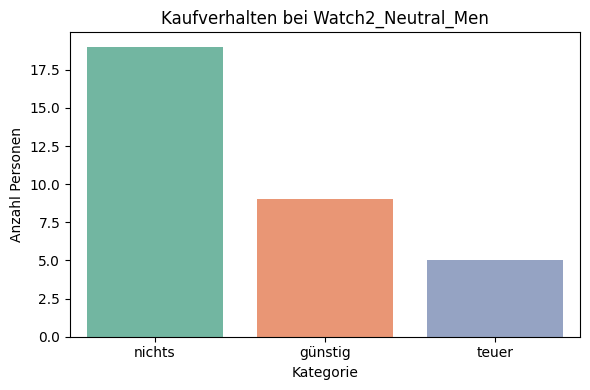

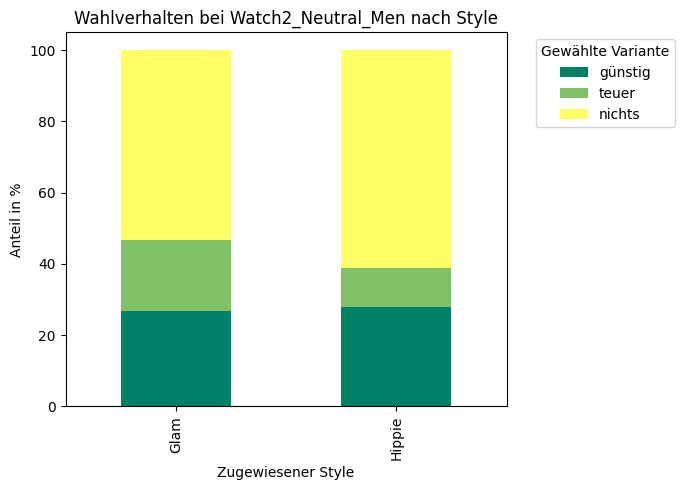

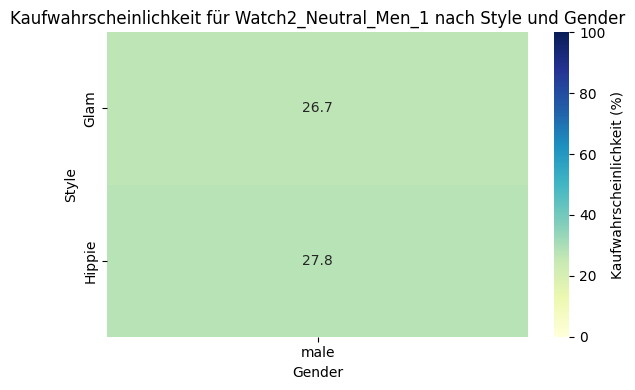

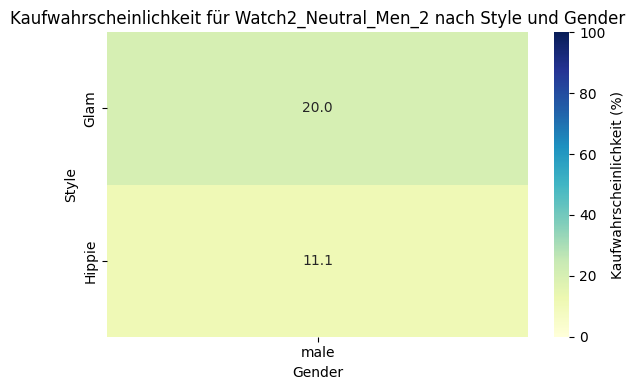

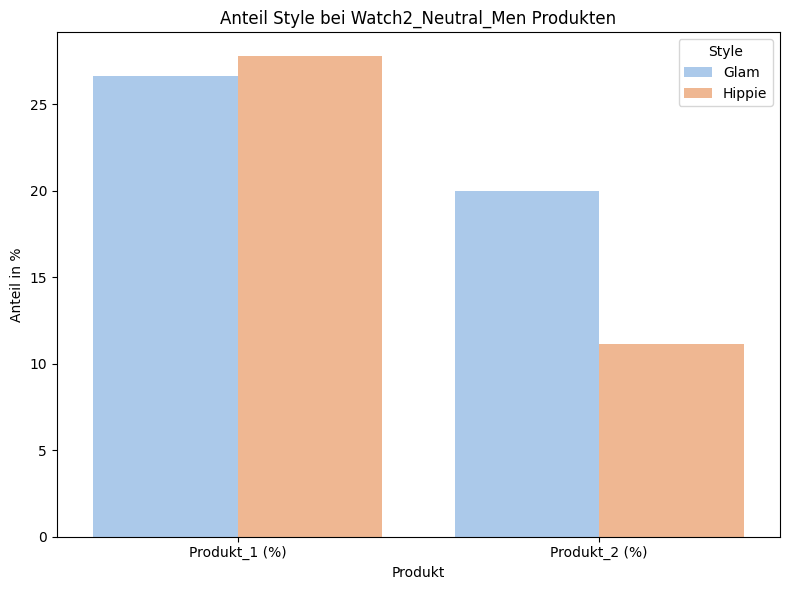

(  Kategorie  Anzahl    Prozent
 0    nichts      19  57.575758
 1   günstig       9  27.272727
 2     teuer       5  15.151515,
     Style  n_günstig  %_günstig
 0  Hippie          5  27.777778
 1    Glam          4  26.666667,
     Style  n_teuer    %_teuer
 0    Glam        3  20.000000
 1  Hippie        2  11.111111)

In [406]:
def analyse_neutral_produkt(df, produktname, guenstig_preis, teuer_preis):
    col1 = f"{produktname}_1"
    col2 = f"{produktname}_2"

    df = df.copy()

    # Nur Fälle, bei denen mindestens eins der beiden Produkte verfügbar war
    df = df[df[[col1, col2]].notna().any(axis=1)]

    # Entscheidungsverhalten kodieren
    def kaufkategorie(row):
        if row[col1] in [1, 'yes', 'Yes']:
            return 'günstig'
        elif row[col2] in [1, 'yes', 'Yes']:
            return 'teuer'
        else:
            return 'nichts'

    df['Kaufkategorie'] = df.apply(kaufkategorie, axis=1)

    # Kachel 1: Übersicht der Kaufentscheidungen
    summary = df['Kaufkategorie'].value_counts(dropna=False).reset_index()
    summary.columns = ['Kategorie', 'Anzahl']
    summary['Prozent'] = 100 * summary['Anzahl'] / summary['Anzahl'].sum()

    # Kachel 2: Einfluss des Styles auf günstige Wahl
    guenstig_df = df[df['Kaufkategorie'] == 'günstig']
    guenstig_by_style = guenstig_df['Style'].value_counts().reset_index()
    guenstig_by_style.columns = ['Style', 'n_günstig']
    guenstig_by_style['%_günstig'] = 100 * guenstig_by_style['n_günstig'] / df['Style'].value_counts().loc[guenstig_by_style['Style']].values

    # Kachel 3: Einfluss des Styles auf teure Wahl
    teuer_df = df[df['Kaufkategorie'] == 'teuer']
    teuer_by_style = teuer_df['Style'].value_counts().reset_index()
    teuer_by_style.columns = ['Style', 'n_teuer']
    teuer_by_style['%_teuer'] = 100 * teuer_by_style['n_teuer'] / df['Style'].value_counts().loc[teuer_by_style['Style']].values

    # Kachel 4: Überblicksplot gestapelt
    verhalten = df.groupby('Style')['Kaufkategorie'].value_counts(normalize=True).unstack().fillna(0) * 100
    for cat in ['günstig', 'teuer', 'nichts']:
        if cat not in verhalten.columns:
            verhalten[cat] = 0
    verhalten = verhalten[['günstig', 'teuer', 'nichts']]

    # Plot 1: Häufigkeit der Entscheidungen
    plt.figure(figsize=(6, 4))
    sns.barplot(data=summary, x='Kategorie', y='Anzahl', palette='Set2')
    plt.title(f'Kaufverhalten bei {produktname}')
    plt.ylabel('Anzahl Personen')
    plt.tight_layout()
    plt.show()

    # Plot 2: Überblick gestapelt nach Style
    verhalten.plot(kind='bar', stacked=True, colormap='summer', figsize=(7, 5))
    plt.title(f'Wahlverhalten bei {produktname} nach Style')
    plt.ylabel('Anteil in %')
    plt.xlabel('Zugewiesener Style')
    plt.legend(title='Gewählte Variante', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Heatmaps für _1 und _2 separat
    for col in [col1, col2]:
        df['Gekauft'] = df[col].isin([1, 'yes', 'Yes']).astype(int)
        heatmap_df = df.groupby(['Style', 'Gender'])['Gekauft'].agg(['sum', 'count']).reset_index()
        heatmap_df['Kaufwahrscheinlichkeit (%)'] = 100 * heatmap_df['sum'] / heatmap_df['count']
        heat_pivot = heatmap_df.pivot(index='Style', columns='Gender', values='Kaufwahrscheinlichkeit (%)')

        plt.figure(figsize=(6, 4))
        sns.heatmap(heat_pivot, annot=True, fmt=".1f", cmap='YlGnBu', vmin=0, vmax=100,
                    cbar_kws={'label': 'Kaufwahrscheinlichkeit (%)'})
        plt.title(f'Kaufwahrscheinlichkeit für {col} nach Style und Gender')
        plt.ylabel('Style')
        plt.xlabel('Gender')
        plt.tight_layout()
        plt.show()

    # Plot 5: Anteile beider Produkte nach Style
    df_filtered = df[['Style', col1, col2]].copy()
    df_filtered[col1] = df_filtered[col1].replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})
    df_filtered[col2] = df_filtered[col2].replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

    gruppe_1 = df_filtered.groupby('Style')[col1].sum().reset_index(name='Produkt_1')
    gruppe_2 = df_filtered.groupby('Style')[col2].sum().reset_index(name='Produkt_2')
    df_summary = pd.merge(gruppe_1, gruppe_2, on='Style')
    df_summary_total = df_filtered.groupby('Style').size().reset_index(name='Gesamt')
    df_summary = pd.merge(df_summary, df_summary_total, on='Style')
    df_summary['Produkt_1 (%)'] = 100 * df_summary['Produkt_1'] / df_summary['Gesamt']
    df_summary['Produkt_2 (%)'] = 100 * df_summary['Produkt_2'] / df_summary['Gesamt']
    df_plot = df_summary[['Style', 'Produkt_1 (%)', 'Produkt_2 (%)']].melt(id_vars='Style', var_name='Produkt', value_name='Anteil in %')

    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_plot, x='Produkt', y='Anteil in %', hue='Style', palette='pastel')
    plt.title(f'Anteil Style bei {produktname} Produkten')
    plt.ylabel('Anteil in %')
    plt.tight_layout()
    plt.show()

    return summary, guenstig_by_style, teuer_by_style
analyse_neutral_produkt(
    df,
    produktname="Watch2_Neutral_Men",
    guenstig_preis=94,
    teuer_preis=180
)

In [ ]:
df= pd.read_csv(experiment_path2)
# === FUNKTION: PRODUKTANALYSE (TEURER PREIS) ===
def produktanalyse_manuell(df, hippie_col: str, glam_col: str, teuer_preis: float):
    hippie_price_col = f"{hippie_col}_price"
    glam_price_col = f"{glam_col}_price"

    df = df[df['Condition'].str.contains('Neutral') == False].copy()
    df = df[['Style', 'Condition', hippie_col, glam_col, hippie_price_col, glam_price_col]].copy()
    df = df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

    for spalte in [hippie_col, glam_col]:
        df['kauf'] = df[spalte]
        gruppiert = df.groupby(['Style', 'Condition'])['kauf'].agg(['sum', 'count']).reset_index()
        gruppiert['Anteil (%)'] = 100 * gruppiert['sum'] / gruppiert['count']
        pivot = gruppiert.pivot(index='Style', columns='Condition', values='Anteil (%)')
        plt.figure(figsize=(6, 4))
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap='YlGnBu', vmin=0, vmax=100)
        plt.title(f'Heatmap: Kaufwahrscheinlichkeit für {spalte}')
        plt.tight_layout()
        plt.show()

    df_teuer = df[
        ((df[hippie_col] == 1) & (df[hippie_price_col] == teuer_preis)) |
        ((df[glam_col] == 1) & (df[glam_price_col] == teuer_preis))
    ].copy()

    def gewaehlte_variante(row):
        if row[hippie_col] == 1:
            return hippie_col
        elif row[glam_col] == 1:
            return glam_col
        else:
            return 'keine'

    df_teuer['Gewählte Variante'] = df_teuer.apply(gewaehlte_variante, axis=1)

    auswertung = df_teuer.groupby(['Style', 'Gewählte Variante']).size().reset_index(name='Anzahl')
    gesamt = df_teuer.groupby('Style').size().reset_index(name='Gesamt')
    merged = pd.merge(auswertung, gesamt, on='Style')
    merged['Anteil (%)'] = 100 * merged['Anzahl'] / merged['Gesamt']
    pivot = merged.pivot(index='Style', columns='Gewählte Variante', values='Anteil (%)')

    pivot.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Set2')
    plt.title(f'{hippie_col} / {glam_col} (teure Variante: {teuer_preis} €) nach Style')
    plt.ylabel('Anteil (%)')
    plt.xlabel('Style')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

    preise = []
    for _, row in df.iterrows():
        if row[hippie_col] == 1:
            preise.append(row[hippie_price_col])
        elif row[glam_col] == 1:
            preise.append(row[glam_price_col])
        else:
            preise.append('nichts')

    preis_counter = Counter(preise)
    preis_df = pd.DataFrame.from_dict(preis_counter, orient='index').reset_index()
    preis_df.columns = ['Preis (€)', 'Anzahl']
    preis_df['Preis (€)'] = preis_df['Preis (€)'].astype(str)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=preis_df, x='Preis (€)', y='Anzahl', palette='Blues')
    plt.title(f'Preisverteilung bei {hippie_col} / {glam_col}')
    plt.ylabel('Anzahl Personen')
    plt.xlabel('Gewählter Preis (oder nichts)')
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame({
        'Kategorie': ['Gesamt', hippie_col + ' gekauft', glam_col + ' gekauft', 'Kein Kauf'],
        'Anzahl': [
            len(df),
            df[df[hippie_col] == 1].shape[0],
            df[df[glam_col] == 1].shape[0],
            df[(df[hippie_col] == 0) & (df[glam_col] == 0)].shape[0]
        ]
    })
    summary['Prozent'] = 100 * summary['Anzahl'] / summary['Anzahl'][0]
    print(summary)

# === FUNKTION: PRODUKTANALYSE (GÜNSTIGER PREIS) ===
def analyse_guenstig_produkt_manuell(df, hippie_col: str, glam_col: str, guenstig_preis: float):
    hippie_price_col = f"{hippie_col}_price"
    glam_price_col = f"{glam_col}_price"

    df = df[df['Condition'].str.contains('Neutral') == False].copy()
    df = df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

    df_guenstig = df[
        ((df[hippie_col] == 1) & (df[hippie_price_col] == guenstig_preis)) |
        ((df[glam_col] == 1) & (df[glam_price_col] == guenstig_preis))
    ].copy()

    if df_guenstig.empty:
        print(f"⚠️ Keine Daten für günstige Käufe zu {guenstig_preis} € gefunden.")
        return

    def gewaehlte_variante(row):
        if row[hippie_col] == 1:
            return hippie_col
        elif row[glam_col] == 1:
            return glam_col
        else:
            return 'keine'

    df_guenstig['Gewählte Variante'] = df_guenstig.apply(gewaehlte_variante, axis=1)

    auswertung = df_guenstig.groupby(['Style', 'Gewählte Variante']).size().reset_index(name='Anzahl')
    gesamt = df_guenstig.groupby('Style').size().reset_index(name='Gesamt')
    merged = pd.merge(auswertung, gesamt, on='Style')
    merged['Anteil (%)'] = 100 * merged['Anzahl'] / merged['Gesamt']
    pivot = merged.pivot(index='Style', columns='Gewählte Variante', values='Anteil (%)')

    pivot.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Pastel2')
    plt.title(f'Günstigere Variante ({guenstig_preis} €) nach Style\nStilkongruentes Kaufverhalten')
    plt.ylabel('Anteil (%)')
    plt.xlabel('Zugewiesener Style')
    plt.ylim(0, 100)
    plt.legend(title='Gewählte Variante', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


    # Beispielhafte Funktionsaufrufe basierend auf den Spalten in 'JewelryStore.csv'

# Beispiel 1: Kettenanalyse
produktanalyse_manuell(
    df,
    hippie_col="Necklace_Hippie_Women",
    glam_col="Necklace_Glam_Women",
    teuer_preis=89.0
)

analyse_guenstig_produkt_manuell(
    df,
    hippie_col="Necklace_Hippie_Women",
    glam_col="Necklace_Glam_Women",
    guenstig_preis=59.0
)



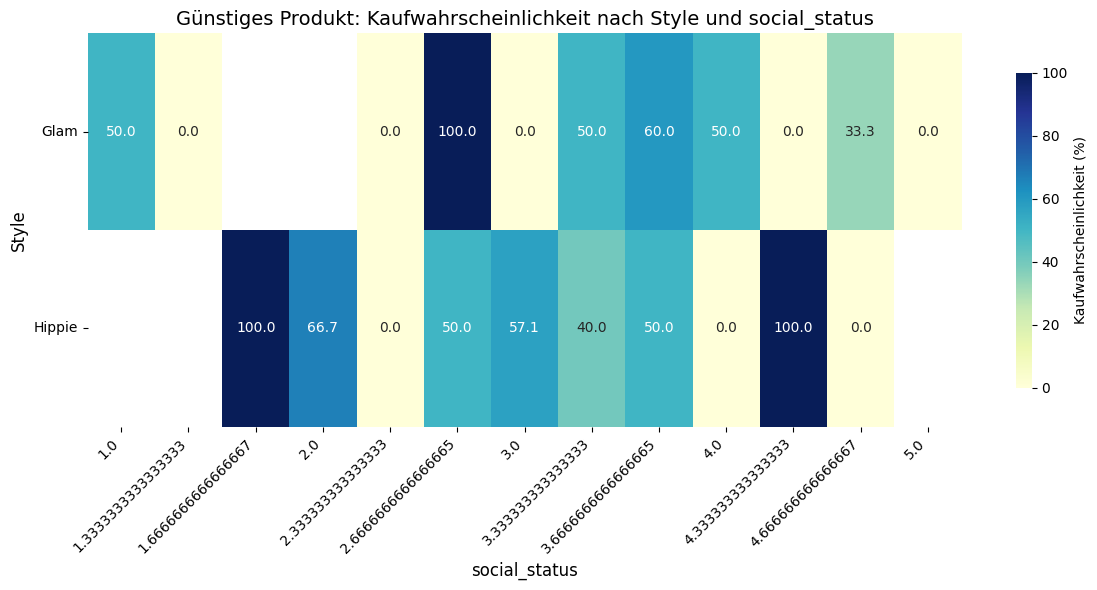

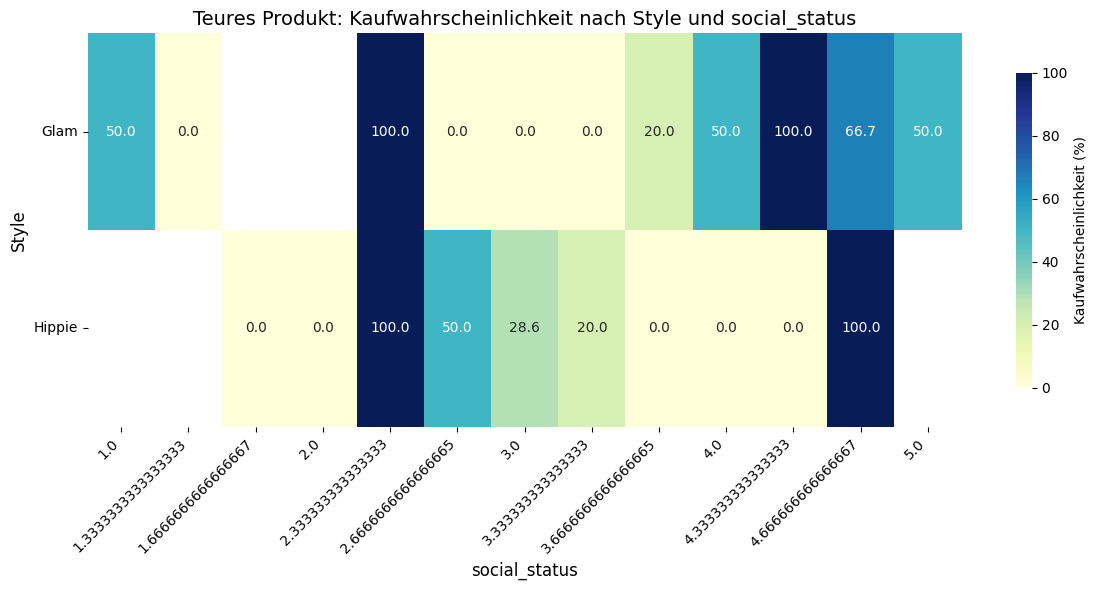

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datensatz laden
df = pd.read_csv(experiment_path2)
df.columns = df.columns.str.strip()

def analyse_neutral_produkt_modular(df, produktname, guenstig_preis, teuer_preis, heatmap_x='Gender'):
    col1 = f"{produktname}_Neutral_1"
    col2 = f"{produktname}_Neutral_2"

    df = df.copy()
    df = df[df[[col1, col2]].notna().any(axis=1)]

    # Entscheidungsverhalten
    def kaufkategorie(row):
        if row[col1] in [1, 'yes', 'Yes']:
            return 'günstig'
        elif row[col2] in [1, 'yes', 'Yes']:
            return 'teuer'
        else:
            return 'nichts'

    df['Kaufkategorie'] = df.apply(kaufkategorie, axis=1)

    # Heatmaps getrennt für günstig & teuer
    for col, label in zip([col1, col2], ['Günstiges', 'Teures']):
        df['Gekauft'] = df[col].isin([1, 'yes', 'Yes']).astype(int)

        heatmap_df = df.groupby(['Style', heatmap_x])['Gekauft'].agg(['sum', 'count']).reset_index()
        heatmap_df['Kaufwahrscheinlichkeit (%)'] = 100 * heatmap_df['sum'] / heatmap_df['count']
        heat_pivot = heatmap_df.pivot(index='Style', columns=heatmap_x, values='Kaufwahrscheinlichkeit (%)')

        # Verbesserte Heatmap
        plt.figure(figsize=(12, 6))
        sns.heatmap(
            heat_pivot,
            annot=True,
            fmt=".1f",
            cmap='YlGnBu',
            vmin=0,
            vmax=100,
            annot_kws={'size': 10},
            cbar_kws={'label': 'Kaufwahrscheinlichkeit (%)', 'shrink': 0.8}
        )
        plt.title(f'{label} Produkt: Kaufwahrscheinlichkeit nach Style und {heatmap_x}', fontsize=14)
        plt.ylabel('Style', fontsize=12)
        plt.xlabel(heatmap_x, fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

# 👉 Funktion aufrufen: Beispiel mit "social_status" oder "Gender" oder z. B. "Materialism_1"
analyse_neutral_produkt_modular(
    df,
    produktname="Fruit",
    guenstig_preis=3,
    teuer_preis=4.5,
    heatmap_x="social_status"  # oder "Gender", "Materialism_1" etc.
)


Untersuchung BB - Greeting Error - keine besondere VIP behandlung

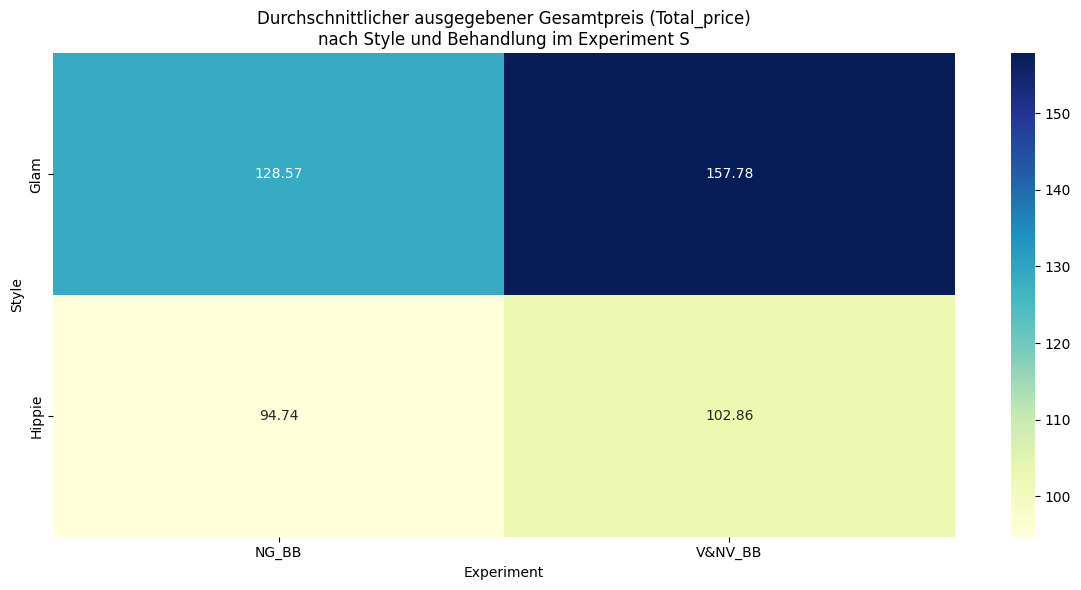

In [6]:
df= pd.read_csv(experiment_path2)
# Neue Bereinigung mit 'Total_price' anstelle von 'total_price_products'
#df["experiment"] = "NG_ES"
df_relevant_alt = df[['Style', 'experiment', 'Total_price']].copy()
global_mean_price = df_relevant_alt['Total_price'].mean()

# Mittelwerte der Total_price pro Style × Experiment Kombination (ohne Prozentänderung)
mean_absolute_prices = df_relevant_alt.dropna(subset=['Total_price']).groupby(['Style', 'experiment'])['Total_price'].mean().unstack()

# Heatmap mit absoluten Mittelwerten zeichnen
plt.figure(figsize=(12, 6))
sns.heatmap(mean_absolute_prices, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Durchschnittlicher ausgegebener Gesamtpreis (Total_price)\nnach Style und Behandlung im Experiment S")
plt.xlabel("Experiment")
plt.ylabel("Style")
plt.tight_layout()
plt.show()

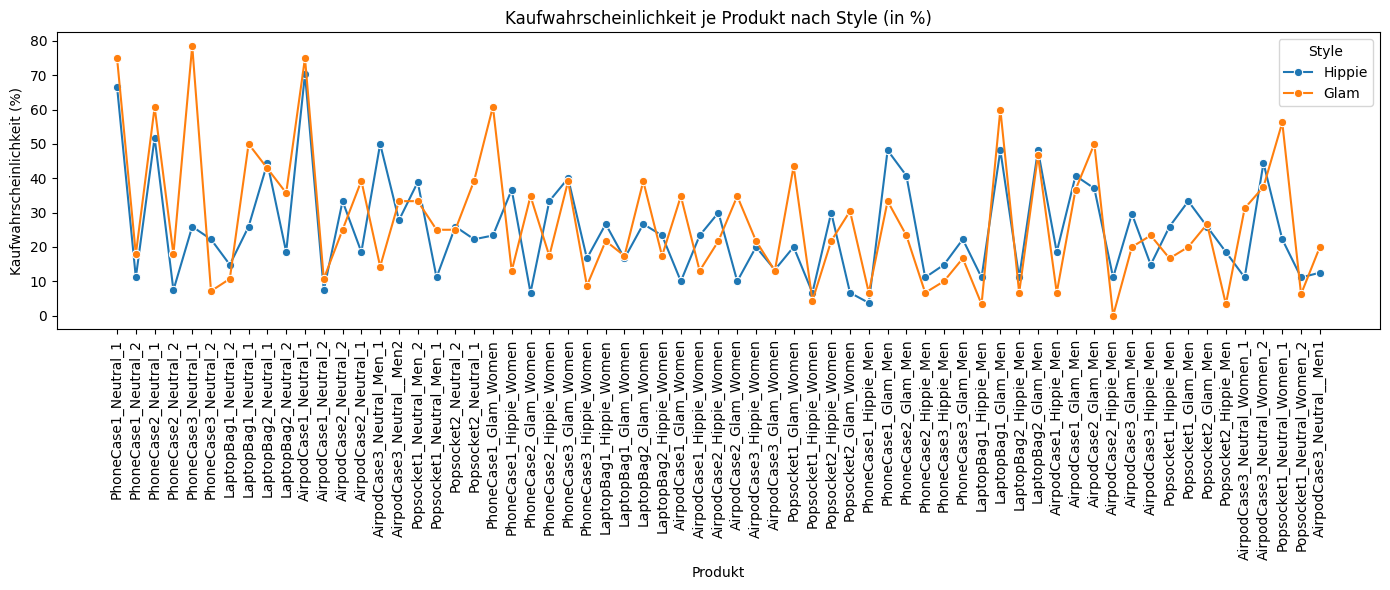

In [15]:
# Ziel: Kaufwahrscheinlichkeit für jedes Produkt (prozentualer Anteil der Personen, die es gekauft haben) nach Style

# Nur binäre Spalten (Kauf = 1, Nichtkauf = 0) extrahieren
df_new= pd.read_csv(experiment_path2)
binary_columns = [col for col in df_new.columns if col.endswith('_bn')  and df_new[col].sum() > 0]

style_col = 'Style_new'

# Aggregation vorbereiten: Anteil Käufe pro Style
prob_by_style = df_new[[style_col] + binary_columns].copy()

# Gruppieren nach Style und Mittelwerte = Kaufwahrscheinlichkeit
prob_by_style_grouped = prob_by_style.groupby(style_col).mean().transpose() * 100  # in %

# Spaltennamen für bessere Lesbarkeit
prob_by_style_grouped.columns = ['Hippie', 'Glam'] if sorted(prob_by_style[style_col].unique()) == [0.0, 1.0] else prob_by_style.columns

# X-Achse als Produktnamen kürzen
prob_by_style_grouped['Produkt'] = prob_by_style_grouped.index.str.replace('_bn', '', regex=False)

# Umstrukturieren für Plot
plot_data = prob_by_style_grouped.reset_index(drop=True).melt(id_vars='Produkt', var_name='Style', value_name='Kaufwahrscheinlichkeit (%)')

# Linienplot
plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_data, x="Produkt", y="Kaufwahrscheinlichkeit (%)", hue="Style", marker="o")
plt.title("Kaufwahrscheinlichkeit je Produkt nach Style (in %)")
plt.xlabel("Produkt")
plt.ylabel("Kaufwahrscheinlichkeit (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

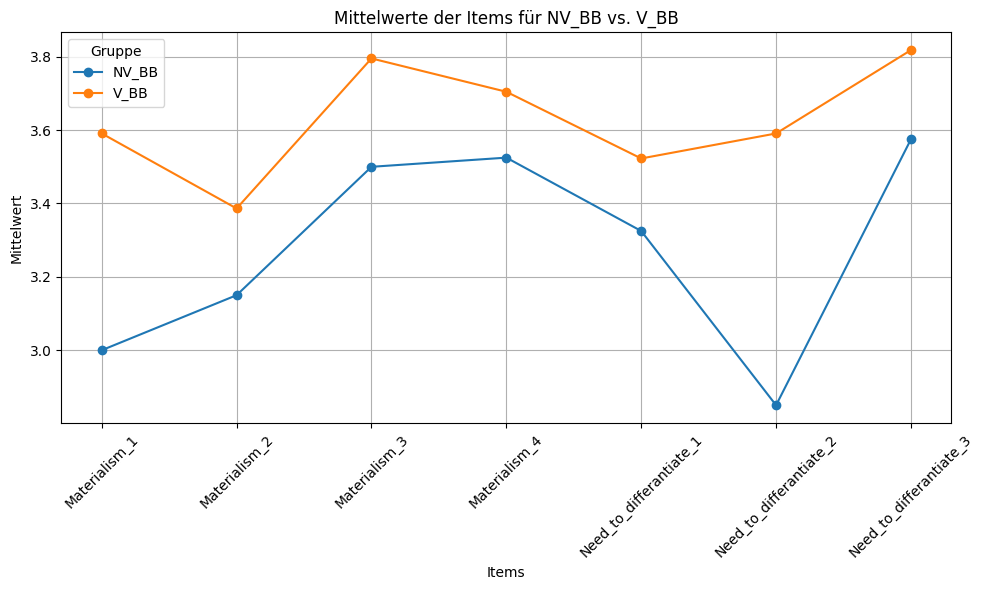

In [16]:
df = pd.read_csv(experiment_path1)

# Relevante Spalten definieren
columns_of_interest = [
    'experiment',
    'Materialism_1', 'Materialism_2', 'Materialism_3', 'Materialism_4',
    'Need_to_differantiate_1', 'Need_to_differantiate_2', 'Need_to_differantiate_3'
]

# Daten filtern
df_filtered = df[columns_of_interest]

# Gruppieren und Mittelwerte berechnen
group_means = df_filtered.groupby('experiment').mean()

# Nur die gewünschten Gruppen extrahieren
group_means = group_means.loc[['NV_BB', 'V_BB']]

# Plot erstellen
plt.figure(figsize=(10, 6))
for group in group_means.index:
    plt.plot(group_means.columns, group_means.loc[group], marker='o', label=group)

plt.title('Mittelwerte der Items für NV_BB vs. V_BB')
plt.xlabel('Items')
plt.ylabel('Mittelwert')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Gruppe')
plt.tight_layout()

# Plot anzeigen
plt.show()

In [ ]:
df_new = pd.read_csv(experiment_path2)

# Sicherstellen, dass numerisch
df_new["total_price"] = pd.to_numeric(df_new["total_price"], errors="coerce")
df_new["productsBought"] = pd.to_numeric(df_new["productsBought"], errors="coerce")

# Alle Stores durchlaufen
stores = df_new["Store"].dropna().unique()

for store in stores:
    store_data = df_new[df_new["Store"] == store]

    # Plot-Vorbereitung: gruppierte Mittelwerte
    grouped_means = (
        store_data.groupby("Condition")[["total_price", "productsBought"]]
        .mean()
        .reset_index()
    )

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{store}: Durchschnittlicher total_price und productsBought nach Condition", fontsize=14)

    for i, var in enumerate(["total_price", "productsBought"]):
        sns.barplot(
            data=grouped_means,
            x="Condition",
            y=var,
            palette="pastel",
            order=["Neutral", "GlamHigh", "HippieHigh"] if "Neutral" in grouped_means["Condition"].values else None,
            ax=axes[i]
        )
        axes[i].set_title(f"Durchschnittlicher {var}")
        axes[i].set_ylabel(var)
        axes[i].set_xlabel("Condition")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Signifikanztest: GlamHigh vs. Neutral, HippieHigh vs. Neutral
    print(f"\nSignifikanztests für {store}:")

    for var in ["total_price", "productsBought"]:
        print(f"\n  Variable: {var}")
        neutral = store_data[store_data["Condition"] == "Neutral"][var].dropna()
        glam = store_data[store_data["Condition"] == "GlamHigh"][var].dropna()
        hippie = store_data[store_data["Condition"] == "HippieHigh"][var].dropna()

        if len(neutral) > 1 and len(glam) > 1:
            t1, p1 = ttest_ind(glam, neutral, equal_var=False)
            print(f"    GlamHigh vs. Neutral: t = {t1:.3f}, p = {p1:.4f} → {'Signifikant' if p1 < 0.05 else 'Nicht signifikant'}")
        else:
            print("    GlamHigh vs. Neutral: Daten unzureichend.")

        if len(neutral) > 1 and len(hippie) > 1:
            t2, p2 = ttest_ind(hippie, neutral, equal_var=False)
            print(f"    HippieHigh vs. Neutral: t = {t2:.3f}, p = {p2:.4f} → {'Signifikant' if p2 < 0.05 else 'Nicht signifikant'}")
        else:
            print("    HippieHigh vs. Neutral: Daten unzureichend.")


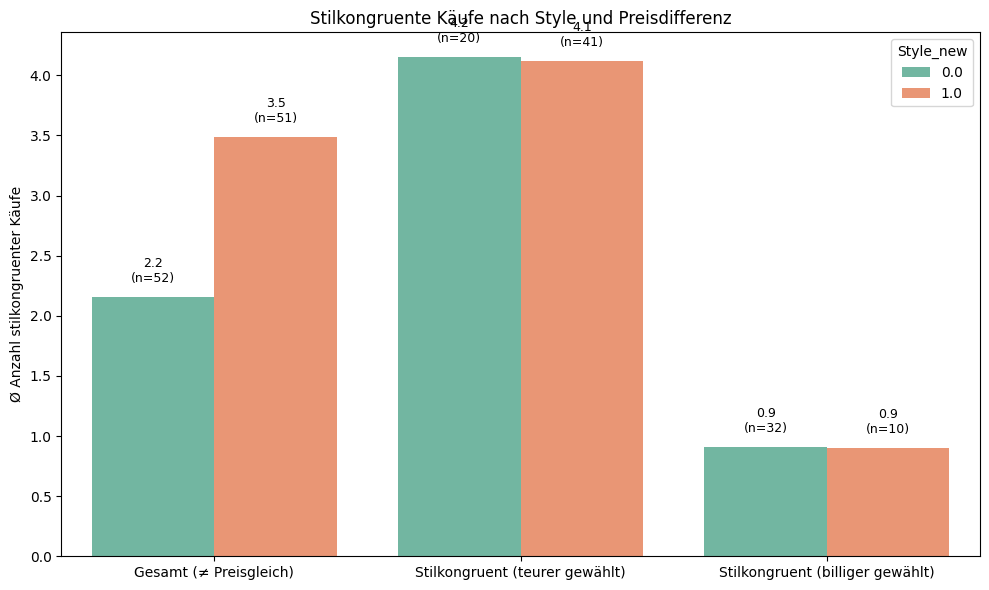


T-Tests zwischen Glam vs. Hippie für stilkongruente Käufe (≠ Preisgleich):

Gesamt (≠ Preisgleich):
  N Glam = 51, M Glam = 3.49
  N Hippie = 52, M Hippie = 2.15
  t = 2.880, p = 0.0049
  → Signifikant

Teurer gewählt:
  N Glam = 41, M Glam = 4.12
  N Hippie = 20, M Hippie = 4.15
  t = -0.054, p = 0.9570
  → Nicht signifikant

Billiger gewählt:
  N Glam = 10, M Glam = 0.90
  N Hippie = 32, M Hippie = 0.91
  t = -0.017, p = 0.9870
  → Nicht signifikant



In [11]:
df = pd.read_csv(experiment_path2)

# === Nur Nicht-Neutral-Bedingungen und relevante Spalten ===
df_plot = df[df['Condition'] != 'Neutral']
df_plot = df_plot[["Style_new", "congruent_count", "congruence_price_diff"]].dropna()

# === Basisdaten: nur ungleichpreisige stilkongruente Entscheidungen ===
df_ungleich = df_plot[df_plot["congruence_price_diff"] != 0]
teurer = df_ungleich[df_ungleich["congruence_price_diff"] > 0]
billiger = df_ungleich[df_ungleich["congruence_price_diff"] < 0]

# === Mittelwerte berechnen ===
gesamt = df_ungleich.groupby("Style_new")["congruent_count"].mean().reset_index(name="avg_congruent_count")
teurer_m = teurer.groupby("Style_new")["congruent_count"].mean().reset_index(name="avg_congruent_teuer")
billiger_m = billiger.groupby("Style_new")["congruent_count"].mean().reset_index(name="avg_congruent_billig")

# === Gruppengrößen berechnen für Beschriftung ===
n_gesamt = df_ungleich.groupby("Style_new").size().reset_index(name="n_gesamt")
n_teurer = teurer.groupby("Style_new").size().reset_index(name="n_teuer")
n_billiger = billiger.groupby("Style_new").size().reset_index(name="n_billig")

# === Merge aller Daten ===
merged = gesamt.merge(teurer_m, on="Style_new", how="outer") \
               .merge(billiger_m, on="Style_new", how="outer") \
               .merge(n_gesamt, on="Style_new", how="outer") \
               .merge(n_teurer, on="Style_new", how="outer") \
               .merge(n_billiger, on="Style_new", how="outer")

# === Langes Format für den Plot ===
plot_df = pd.melt(
    merged,
    id_vars="Style_new",
    value_vars=["avg_congruent_count", "avg_congruent_teuer", "avg_congruent_billig"],
    var_name="Kategorie",
    value_name="Durchschnittliche stilkongruente Käufe"
)

# === Gruppengrößen (n) auch ins lange Format ===
n_map = {
    "avg_congruent_count": "n_gesamt",
    "avg_congruent_teuer": "n_teuer",
    "avg_congruent_billig": "n_billig"
}

plot_df["n"] = plot_df.apply(
    lambda row: merged.loc[merged["Style_new"] == row["Style_new"], n_map[row["Kategorie"]]].values[0],
    axis=1
)

# === Achsenbeschriftung bereinigen ===
plot_df["Kategorie"] = plot_df["Kategorie"].map({
    "avg_congruent_count": "Gesamt (≠ Preisgleich)",
    "avg_congruent_teuer": "Stilkongruent (teurer gewählt)",
    "avg_congruent_billig": "Stilkongruent (billiger gewählt)"
})

# === Plot erstellen ===
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_df,
    x="Kategorie",
    y="Durchschnittliche stilkongruente Käufe",
    hue="Style_new",
    palette="Set2"
)

# Balkenbeschriftungen (Mittelwert + n)
for bar, (_, row) in zip(ax.containers[0], plot_df[plot_df["Style_new"] == 0.0].iterrows()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f"{height:.1f}\n(n={int(row['n'])})", 
            ha='center', va='bottom', fontsize=9)

for bar, (_, row) in zip(ax.containers[1], plot_df[plot_df["Style_new"] == 1.0].iterrows()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f"{height:.1f}\n(n={int(row['n'])})", 
            ha='center', va='bottom', fontsize=9)

plt.title("Stilkongruente Käufe nach Style und Preisdifferenz")
plt.xlabel("")
plt.ylabel("Ø Anzahl stilkongruenter Käufe")
plt.legend(title="Style_new")
plt.tight_layout()
plt.show()

# === T-Tests ===
print("\nT-Tests zwischen Glam vs. Hippie für stilkongruente Käufe (≠ Preisgleich):\n")

def test_and_print(group_df, label):
    glam = group_df[group_df["Style_new"] == 1]["congruent_count"].dropna()
    hippie = group_df[group_df["Style_new"] == 0]["congruent_count"].dropna()

    print(f"{label}:")
    print(f"  N Glam = {len(glam)}, M Glam = {glam.mean():.2f}")
    print(f"  N Hippie = {len(hippie)}, M Hippie = {hippie.mean():.2f}")

    if len(glam) > 1 and len(hippie) > 1 and glam.nunique() > 1 and hippie.nunique() > 1:
        t_stat, p_val = ttest_ind(glam, hippie, equal_var=False)
        print(f"  t = {t_stat:.3f}, p = {p_val:.4f}")
        print("  → Signifikant\n" if p_val < 0.05 else "  → Nicht signifikant\n")
    else:
        print("  ⚠️ Zu wenige oder identische Werte für t-Test.\n")

test_and_print(df_ungleich, "Gesamt (≠ Preisgleich)")
test_and_print(teurer, "Teurer gewählt")
test_and_print(billiger, "Billiger gewählt")


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2085256671.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby(['Style', 'Condition'])['total_price'].agg(['mean', 'count', 'std']).reset_index()
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2085256671.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(


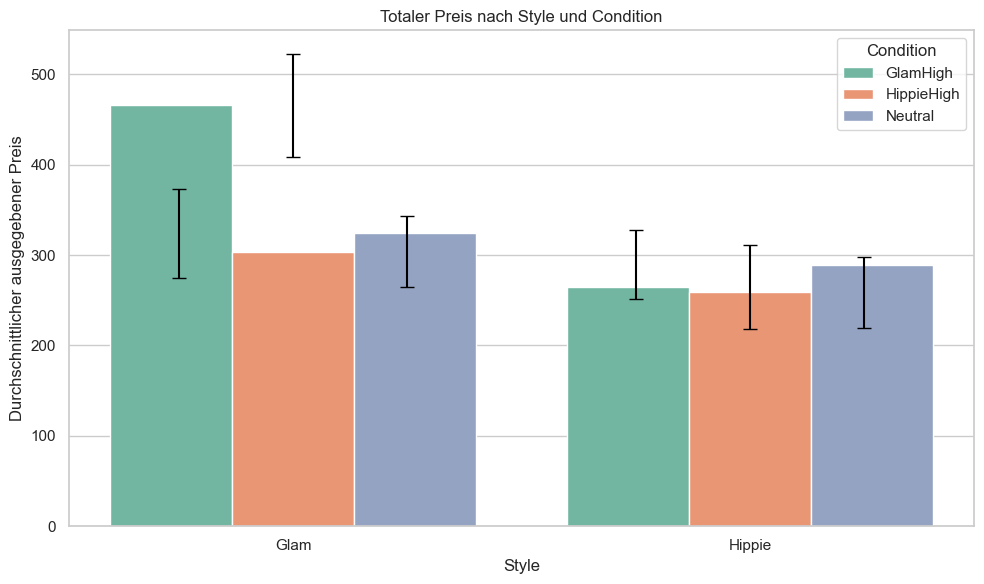

In [30]:
df = pd.read_csv(experiment_path2)

valid_conditions = ['Neutral', 'GlamHigh', 'HippieHigh']
df_filtered = df[df['Condition'].isin(valid_conditions)][['Style', 'Condition', 'total_price']].dropna()

#  Kategorische Variablen
df_filtered['Style'] = df_filtered['Style'].astype('category')
df_filtered['Condition'] = df_filtered['Condition'].astype('category')

# Gruppierte Mittelwerte + SEM berechnen
grouped = df_filtered.groupby(['Style', 'Condition'])['total_price'].agg(['mean', 'count', 'std']).reset_index()
grouped['sem'] = grouped['std'] / grouped['count']**0.5

# Balkendiagramm mit Fehlerbalken
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x='Style',
    y='mean',
    hue='Condition',
    data=grouped,
    ci=None,
    palette='Set2'
)

# Fehlerbalken manuell hinzufügen
offsets = {'Neutral': -0.25, 'GlamHigh': 0.0, 'HippieHigh': 0.25}
for i, row in grouped.iterrows():
    x_base = list(df_filtered['Style'].cat.categories).index(row['Style'])
    x = x_base + offsets[row['Condition']]
    plt.errorbar(x=x, y=row['mean'], yerr=row['sem'], fmt='none', c='black', capsize=5)

# Achsen und Layout
plt.title("Totaler Preis nach Style und Condition")
plt.ylabel("Durchschnittlicher ausgegebener Preis")
plt.xlabel("Style")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

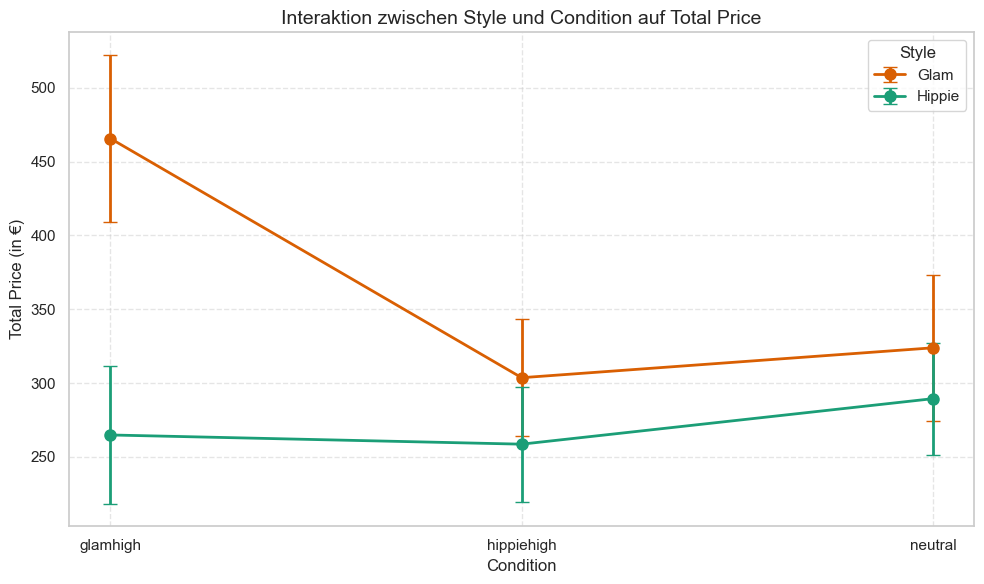

In [31]:
#style condition Interkationsgraph 
df = pd.read_csv(experiment_path2)

df['Condition'] = df['Condition'].astype(str).str.strip().str.lower()
df['Style'] = df['Style'].astype(str).str.strip().str.lower()
df = df[df['Condition'].isin(['glamhigh', 'hippiehigh', 'neutral'])]
df = df[df['Style'].isin(['glam', 'hippie'])]
df = df[['Condition', 'Style', 'total_price']].dropna()

# Gruppieren: Mittelwert und Standardfehler berechnen
grouped = df.groupby(['Condition', 'Style']).agg(
    mean_price=('total_price', 'mean'),
    count=('total_price', 'count'),
    std=('total_price', 'std')
).reset_index()
grouped['se'] = grouped['std'] / grouped['count']**0.5

# Plot erstellen
plt.figure(figsize=(10, 6))
palette = {'glam': '#d95f02', 'hippie': '#1b9e77'}

for style in grouped['Style'].unique():
    subset = grouped[grouped['Style'] == style]
    plt.errorbar(
        subset['Condition'],
        subset['mean_price'],
        yerr=subset['se'],
        label=f'{style.capitalize()}',
        fmt='-o',
        capsize=5,
        linewidth=2,
        markersize=8,
        color=palette[style]
    )

# 🧭 Achsen & Titel
plt.title('Interaktion zwischen Style und Condition auf Total Price', fontsize=14)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Total Price (in €)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Style')
plt.tight_layout()
plt.show()

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1646626556.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1646626556.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


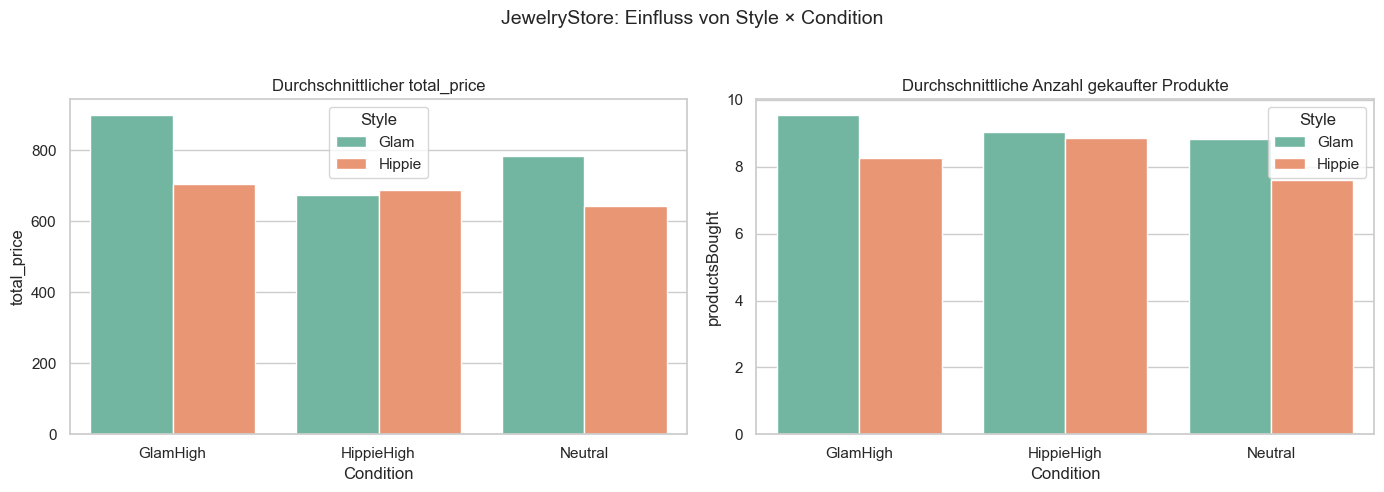


T-Tests für JewelryStore (Glam vs. Hippie) innerhalb jeder Condition:

  Condition = GlamHigh, Variable = total_price
    t = 1.451, p = 0.1546, Glam M = 898.71, Hippie M = 705.02
    → Nicht signifikant

  Condition = GlamHigh, Variable = productsBought
    t = 0.891, p = 0.3783, Glam M = 9.54, Hippie M = 8.27
    → Nicht signifikant

  Condition = HippieHigh, Variable = total_price
    t = -0.145, p = 0.8851, Glam M = 673.01, Hippie M = 687.46
    → Nicht signifikant

  Condition = HippieHigh, Variable = productsBought
    t = 0.146, p = 0.8848, Glam M = 9.06, Hippie M = 8.88
    → Nicht signifikant

  Condition = Neutral, Variable = total_price
    t = 1.183, p = 0.2443, Glam M = 784.20, Hippie M = 642.21
    → Nicht signifikant

  Condition = Neutral, Variable = productsBought
    t = 0.931, p = 0.3573, Glam M = 8.83, Hippie M = 7.61
    → Nicht signifikant



/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1646626556.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1646626556.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


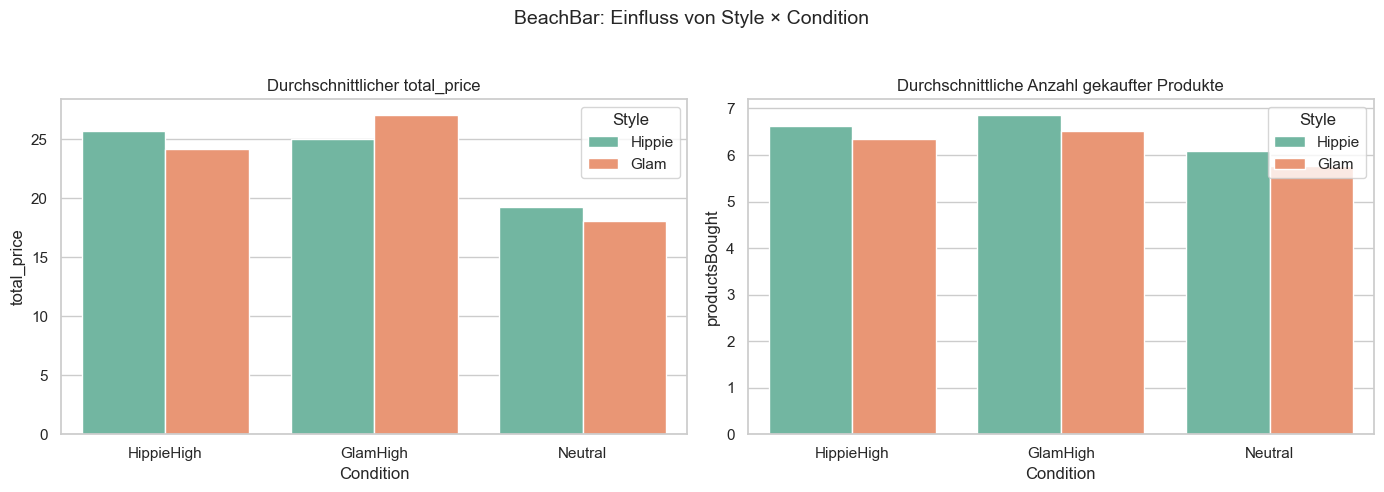


T-Tests für BeachBar (Glam vs. Hippie) innerhalb jeder Condition:

  Condition = GlamHigh, Variable = total_price
    t = 0.697, p = 0.4892, Glam M = 27.04, Hippie M = 25.01
    → Nicht signifikant

  Condition = GlamHigh, Variable = productsBought
    t = -0.456, p = 0.6504, Glam M = 6.52, Hippie M = 6.85
    → Nicht signifikant

  Condition = HippieHigh, Variable = total_price
    t = -0.640, p = 0.5249, Glam M = 24.21, Hippie M = 25.73
    → Nicht signifikant

  Condition = HippieHigh, Variable = productsBought
    t = -0.457, p = 0.6500, Glam M = 6.35, Hippie M = 6.62
    → Nicht signifikant

  Condition = Neutral, Variable = total_price
    t = -0.492, p = 0.6254, Glam M = 18.12, Hippie M = 19.24
    → Nicht signifikant

  Condition = Neutral, Variable = productsBought
    t = -0.423, p = 0.6740, Glam M = 5.77, Hippie M = 6.08
    → Nicht signifikant



/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1646626556.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1646626556.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


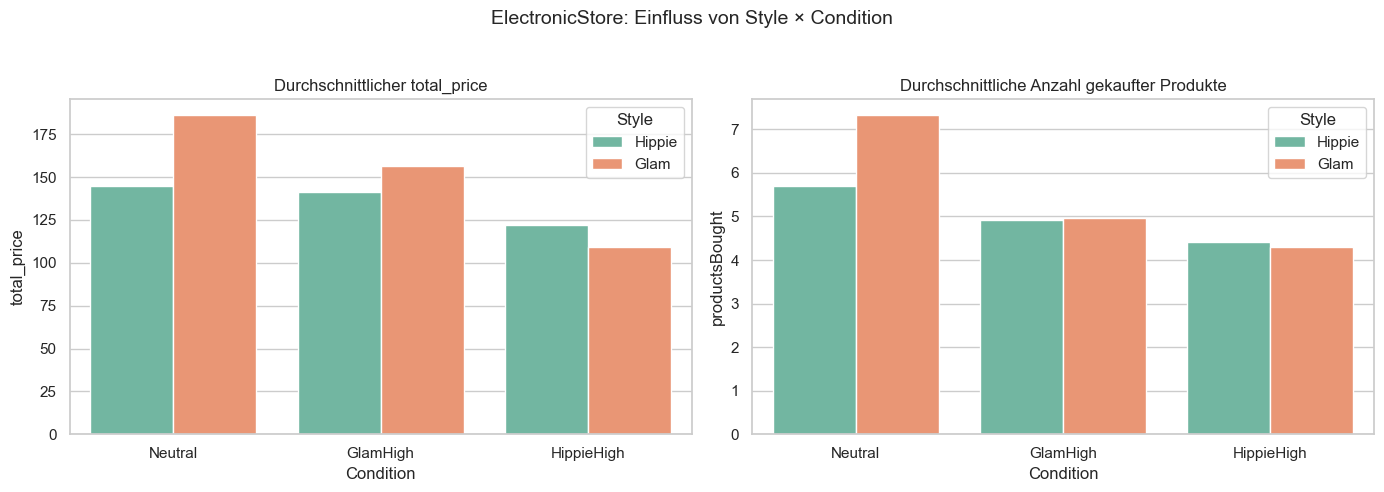


T-Tests für ElectronicStore (Glam vs. Hippie) innerhalb jeder Condition:

  Condition = GlamHigh, Variable = total_price
    t = 0.529, p = 0.5995, Glam M = 156.45, Hippie M = 141.38
    → Nicht signifikant

  Condition = GlamHigh, Variable = productsBought
    t = 0.034, p = 0.9728, Glam M = 4.95, Hippie M = 4.92
    → Nicht signifikant

  Condition = HippieHigh, Variable = total_price
    t = -0.658, p = 0.5129, Glam M = 108.98, Hippie M = 121.86
    → Nicht signifikant

  Condition = HippieHigh, Variable = productsBought
    t = -0.174, p = 0.8625, Glam M = 4.29, Hippie M = 4.42
    → Nicht signifikant

  Condition = Neutral, Variable = total_price
    t = 2.096, p = 0.0410, Glam M = 185.95, Hippie M = 144.51
    → Signifikant

  Condition = Neutral, Variable = productsBought
    t = 2.083, p = 0.0422, Glam M = 7.32, Hippie M = 5.70
    → Signifikant



In [32]:
df_new = pd.read_csv(experiment_path2)
# Numerisch sicherstellen
df_new["total_price"] = pd.to_numeric(df_new["total_price"], errors="coerce")
df_new["productsBought"] = pd.to_numeric(df_new["productsBought"], errors="coerce")

# Liste aller Stores
stores = df_new["Store"].dropna().unique()

# Iteration über alle Stores
for store in stores:
    store_data = df_new[df_new["Store"] == store]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(f"{store}: Einfluss von Style × Condition", fontsize=14)

    # Plot 1: total_price
    sns.barplot(
        data=store_data,
        x="Condition",
        y="total_price",
        hue="Style",
        ci=None,
        palette="Set2",
        ax=axes[0]
    )
    axes[0].set_title("Durchschnittlicher total_price")
    axes[0].set_ylabel("total_price")
    axes[0].set_xlabel("Condition")

    # Plot 2: productsBought
    sns.barplot(
        data=store_data,
        x="Condition",
        y="productsBought",
        hue="Style",
        ci=None,
        palette="Set2",
        ax=axes[1]
    )
    axes[1].set_title("Durchschnittliche Anzahl gekaufter Produkte")
    axes[1].set_ylabel("productsBought")
    axes[1].set_xlabel("Condition")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # === T-Tests innerhalb jeder Condition im Store ===
    print(f"\nT-Tests für {store} (Glam vs. Hippie) innerhalb jeder Condition:\n")

    for condition in sorted(store_data["Condition"].dropna().unique()):
        sub = store_data[store_data["Condition"] == condition]

        for variable in ["total_price", "productsBought"]:
            glam = sub[sub["Style"] == "Glam"][variable].dropna()
            hippie = sub[sub["Style"] == "Hippie"][variable].dropna()

            if glam.nunique() > 1 and hippie.nunique() > 1 and len(glam) > 1 and len(hippie) > 1:
                t_stat, p_val = ttest_ind(glam, hippie, equal_var=False)
            else:
                t_stat, p_val = float("nan"), float("nan")

            print(f"  Condition = {condition}, Variable = {variable}")
            print(f"    t = {t_stat:.3f}, p = {p_val:.4f}, Glam M = {glam.mean():.2f}, Hippie M = {hippie.mean():.2f}")
            print("    → Signifikant\n" if p_val < 0.05 else "    → Nicht signifikant\n")


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2222605711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2222605711.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


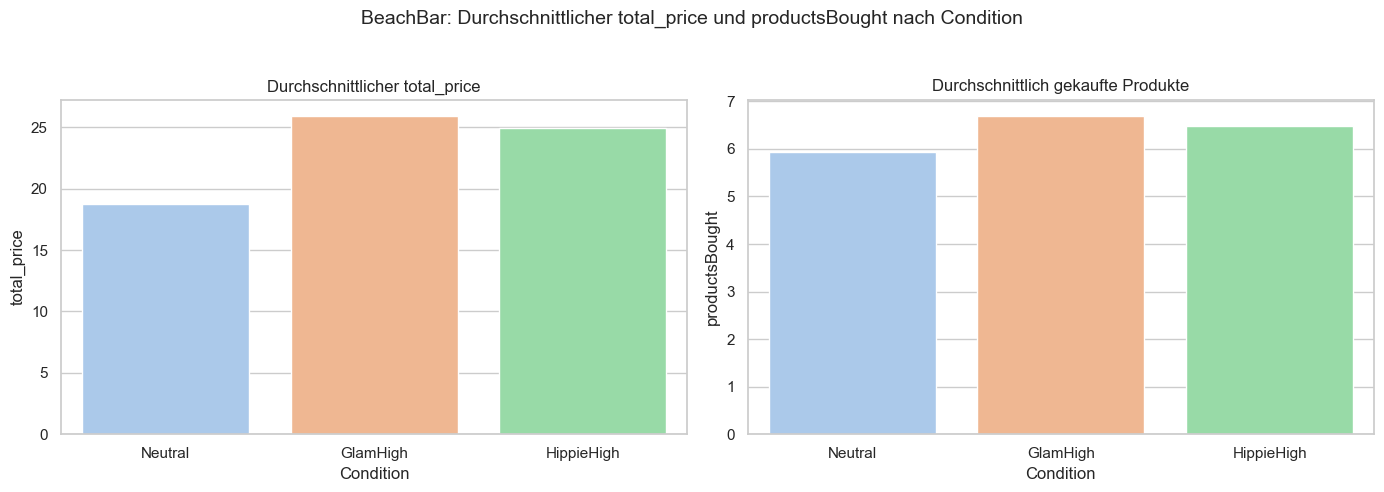

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2222605711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2222605711.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


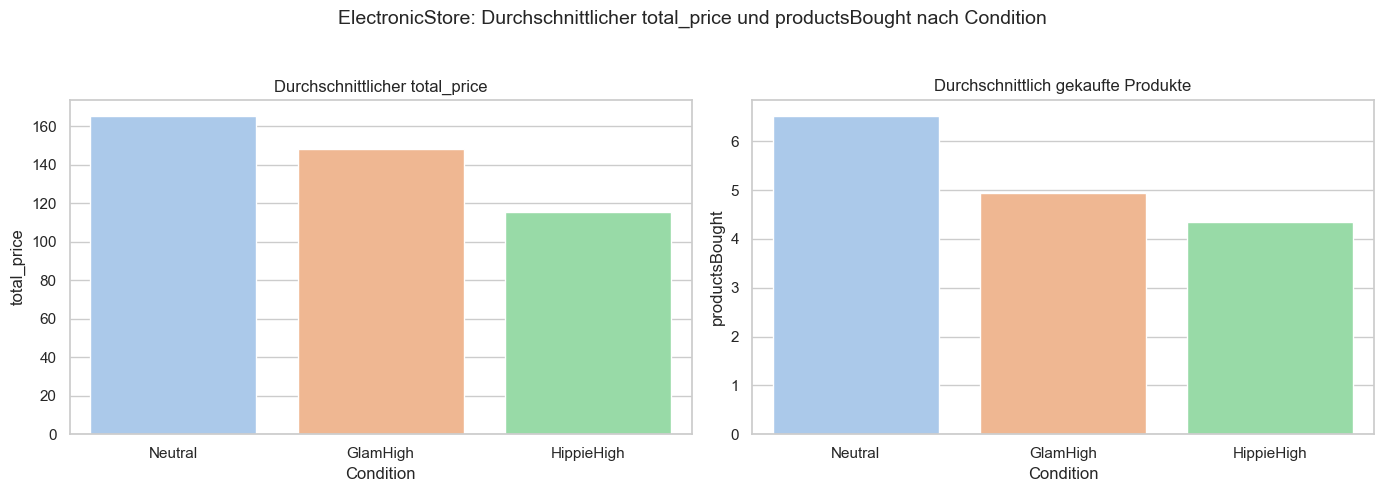

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2222605711.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/2222605711.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


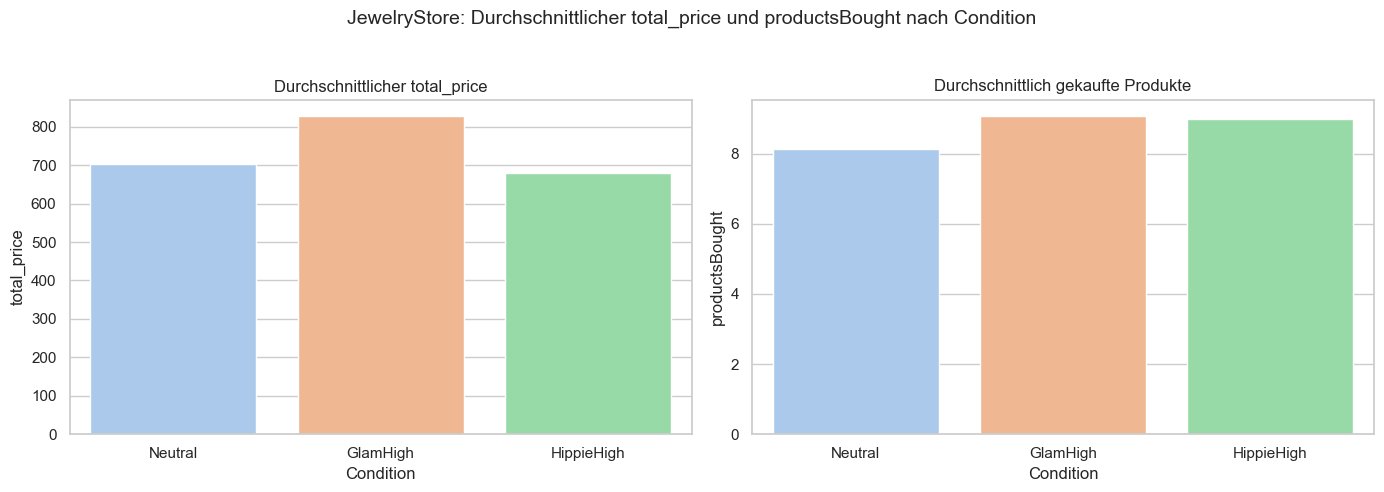

In [34]:
df_new = pd.read_csv(experiment_path2)
grouped_means = (
    df_new.groupby(["Store", "Condition"])[["total_price", "productsBought"]]
    .mean()
    .reset_index()
)

# Für jeden Store zwei Barplots: total_price und productsBought
stores = grouped_means["Store"].unique()

for store in stores:
    store_data = grouped_means[grouped_means["Store"] == store]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{store}: Durchschnittlicher total_price und productsBought nach Condition", fontsize=14)

    # total_price
    sns.barplot(
        data=store_data,
        x="Condition",
        y="total_price",
        palette="pastel",
        order=["Neutral", "GlamHigh", "HippieHigh"] if "Neutral" in store_data["Condition"].values else None,
        ax=axes[0]
    )
    axes[0].set_title("Durchschnittlicher total_price")
    axes[0].set_ylabel("total_price")
    axes[0].set_xlabel("Condition")

    # productsBought
    sns.barplot(
        data=store_data,
        x="Condition",
        y="productsBought",
        palette="pastel",
        order=["Neutral", "GlamHigh", "HippieHigh"] if "Neutral" in store_data["Condition"].values else None,
        ax=axes[1]
    )
    axes[1].set_title("Durchschnittlich gekaufte Produkte")
    axes[1].set_ylabel("productsBought")
    axes[1].set_xlabel("Condition")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


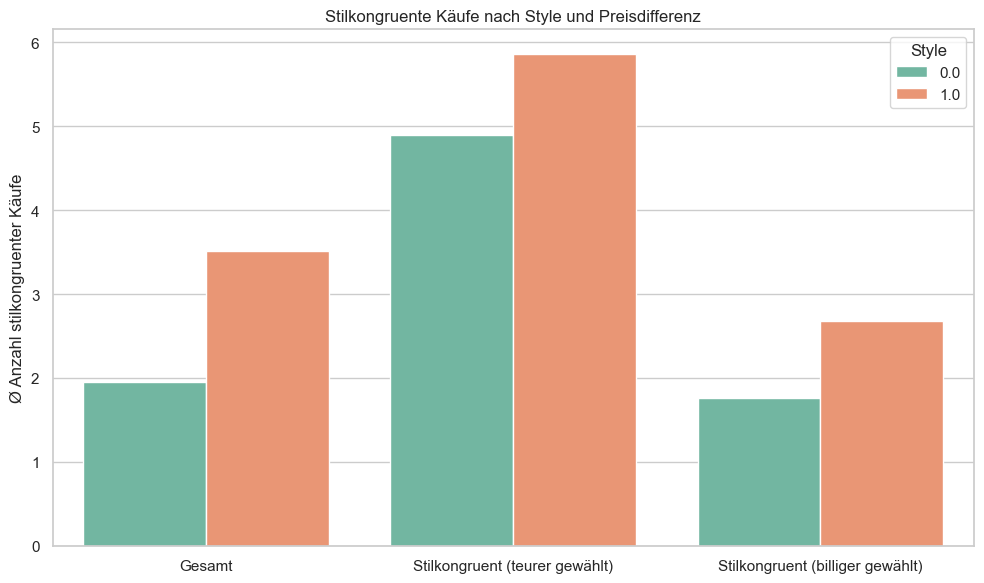

In [35]:
df_plot = pd.read_csv(experiment_path2)
df_plot = df_new[["Style_new", "congruent_count", "congruence_price_diff"]].dropna()

# Bedingungen für teurere vs. billigere stilkongruente Produkte
teurer = df_plot[df_plot["congruence_price_diff"] > 0]
billiger = df_plot[df_plot["congruence_price_diff"] < 0]

# Aggregation: Mittelwert stilkongruenter Käufe pro Gruppe
gesamt = df_plot.groupby("Style_new")["congruent_count"].mean().reset_index(name="avg_congruent_count")
teurer_m = teurer.groupby("Style_new")["congruent_count"].mean().reset_index(name="avg_congruent_teuer")
billiger_m = billiger.groupby("Style_new")["congruent_count"].mean().reset_index(name="avg_congruent_billig")

# Zusammenführen in ein gemeinsames Format
merged = gesamt.merge(teurer_m, on="Style_new").merge(billiger_m, on="Style_new")

# Daten für den Plot in langes Format bringen
plot_df = pd.melt(
    merged,
    id_vars="Style_new",
    value_vars=["avg_congruent_count", "avg_congruent_teuer", "avg_congruent_billig"],
    var_name="Kategorie",
    value_name="Durchschnittliche stilkongruente Käufe"
)

# Umbenennen für bessere Lesbarkeit
plot_df["Kategorie"] = plot_df["Kategorie"].map({
    "avg_congruent_count": "Gesamt",
    "avg_congruent_teuer": "Stilkongruent (teurer gewählt)",
    "avg_congruent_billig": "Stilkongruent (billiger gewählt)"
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Kategorie", y="Durchschnittliche stilkongruente Käufe", hue="Style_new", palette="Set2")
plt.title("Stilkongruente Käufe nach Style und Preisdifferenz")
plt.xlabel("")
plt.ylabel("Ø Anzahl stilkongruenter Käufe")
plt.legend(title="Style")
plt.tight_layout()
plt.show()


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1881550910.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1881550910.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


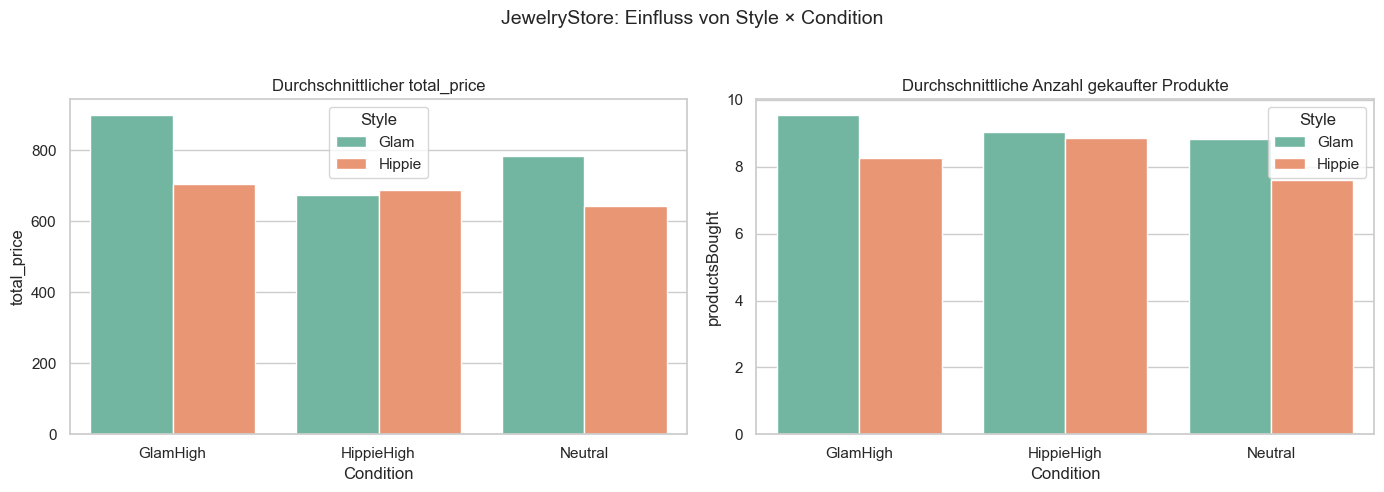

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1881550910.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1881550910.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


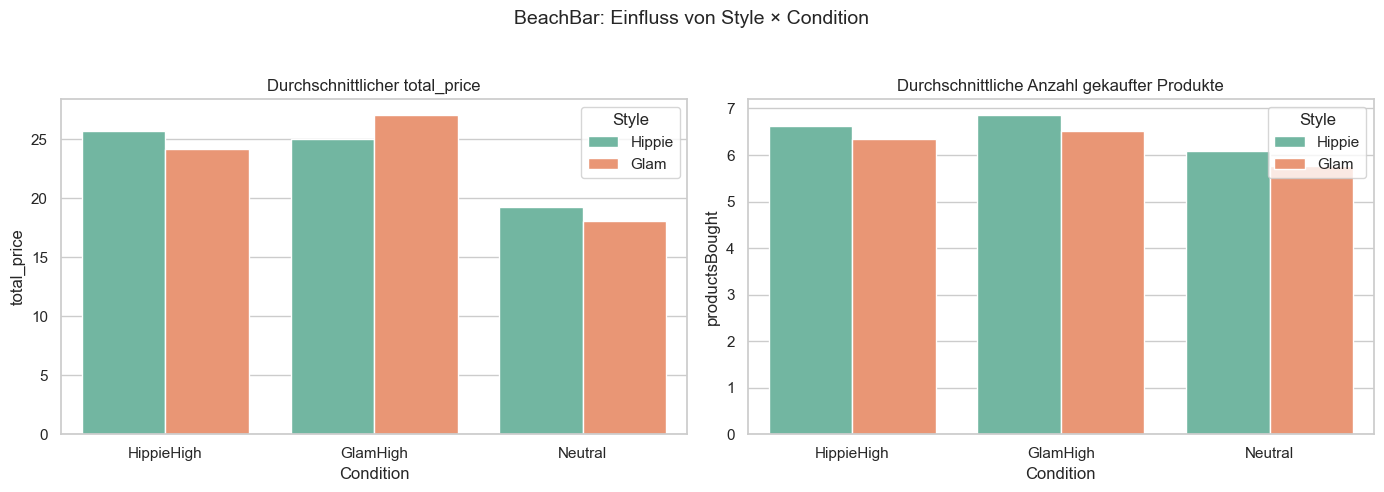

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1881550910.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/1881550910.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


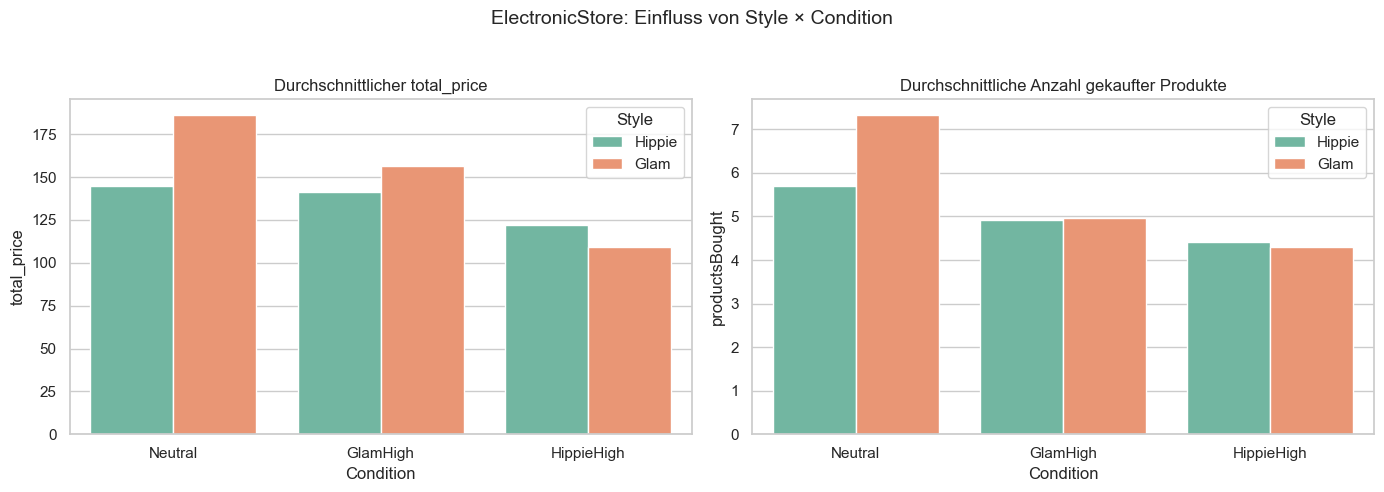

In [36]:
df_new = pd.read_csv(experiment_path2)
# Sicherstellen, dass total_price und productsBought numerisch sind
df_new["total_price"] = pd.to_numeric(df_new["total_price"], errors="coerce")
df_new["productsBought"] = pd.to_numeric(df_new["productsBought"], errors="coerce")

# Liste aller Stores für die Erstellung je Store
stores = df_new["Store"].dropna().unique()

# Für jeden Store zwei Plots: einer für total_price, einer für productsBought
for store in stores:
    store_data = df_new[df_new["Store"] == store]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(f"{store}: Einfluss von Style × Condition", fontsize=14)

    # Plot 1: total_price
    sns.barplot(
        data=store_data,
        x="Condition",
        y="total_price",
        hue="Style",
        ci=None,
        palette="Set2",
        ax=axes[0]
    )
    axes[0].set_title("Durchschnittlicher total_price")
    axes[0].set_ylabel("total_price")
    axes[0].set_xlabel("Condition")

    # Plot 2: productsBought
    sns.barplot(
        data=store_data,
        x="Condition",
        y="productsBought",
        hue="Style",
        ci=None,
        palette="Set2",
        ax=axes[1]
    )
    axes[1].set_title("Durchschnittliche Anzahl gekaufter Produkte")
    axes[1].set_ylabel("productsBought")
    axes[1].set_xlabel("Condition")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

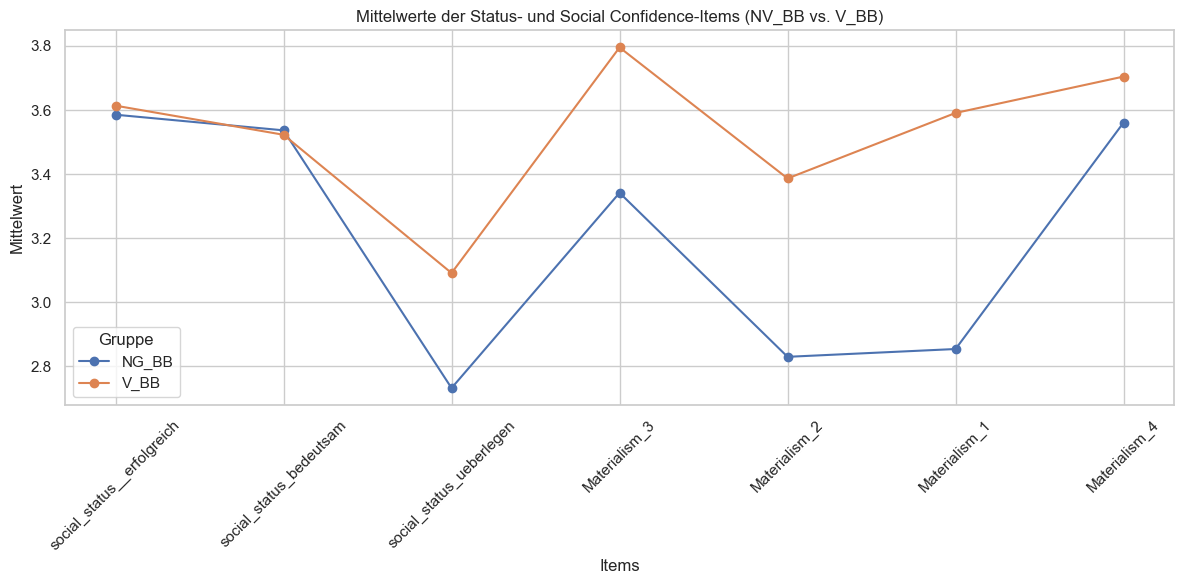

In [38]:
df = pd.read_csv(experiment_path1)

# Relevante Spalten für den zweiten Plot
columns_of_interest_2 = [
    'experiment',
    'social_status__erfolgreich', 'social_status_bedeutsam', 'social_status_ueberlegen', 'Materialism_3',	'Materialism_2',	'Materialism_1',	'Materialism_4'
   
]

# Daten filtern
df_filtered_2 = df[columns_of_interest_2]

# Gruppieren und Mittelwerte berechnen
group_means_2 = df_filtered_2.groupby('experiment').mean()

# Nur die gewünschten Gruppen extrahieren
group_means_2 = group_means_2.loc[['NG_BB', 'V_BB']]

# Plot erstellen
plt.figure(figsize=(12, 6))
for group in group_means_2.index:
    plt.plot(group_means_2.columns, group_means_2.loc[group], marker='o', label=group)

plt.title('Mittelwerte der Status- und Social Confidence-Items (NV_BB vs. V_BB)')
plt.xlabel('Items')
plt.ylabel('Mittelwert')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Gruppe')
plt.tight_layout()

# Plot anzeigen
plt.show()

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/966734180.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(


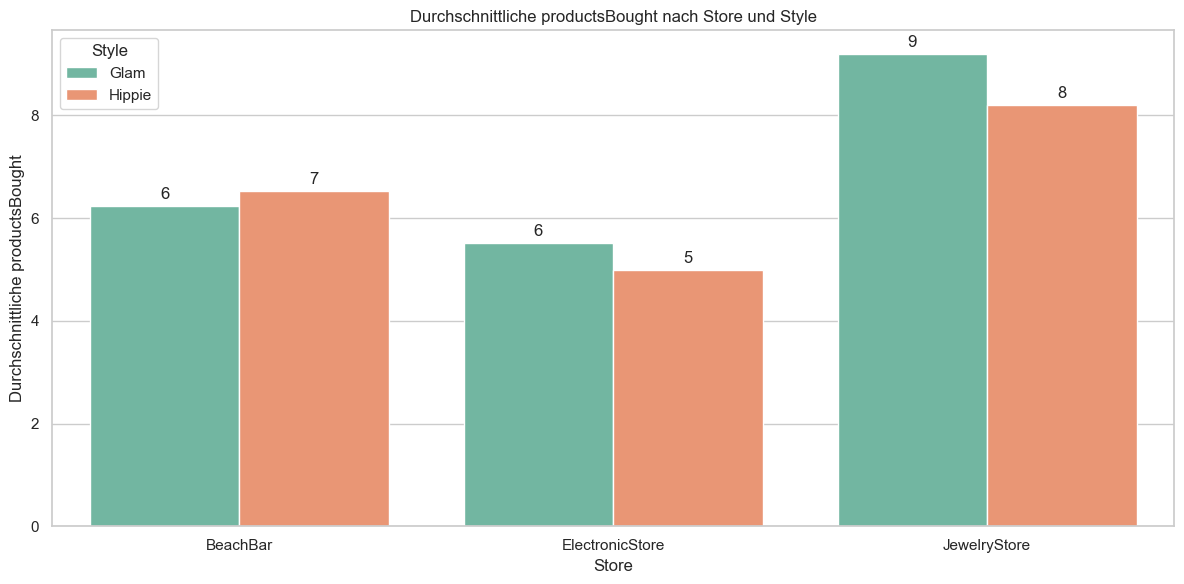

T-Tests (Glam vs. Hippie) für 'productsBought' pro Store:

BeachBar:
  t = -0.756, p = 0.4506, Glam M = 6.23, Hippie M = 6.52
  → Nicht signifikant

ElectronicStore:
  t = 1.093, p = 0.2760, Glam M = 5.52, Hippie M = 4.99
  → Nicht signifikant

JewelryStore:
  t = 1.373, p = 0.1716, Glam M = 9.19, Hippie M = 8.19
  → Nicht signifikant



In [39]:
df = pd.read_csv(experiment_path2)

# Gruppierung: Mittelwerte für den Plot
mean_prices_by_style = (
    df.groupby(["Style", "Store"])["productsBought"]
    .mean()
    .reset_index()
)

# === Visualisierung ===
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=mean_prices_by_style,
    x="Store",
    y="productsBought",
    hue="Style",
    palette="Set2",
    ci=None
)

# Balkenbeschriftungen
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.title("Durchschnittliche productsBought nach Store und Style")
plt.xlabel("Store")
plt.ylabel("Durchschnittliche productsBought")
plt.legend(title="Style")
plt.tight_layout()
plt.show()

# === T-Tests für productsBought je Store ===
print("T-Tests (Glam vs. Hippie) für 'productsBought' pro Store:\n")

for store in sorted(df["Store"].dropna().unique()):
    sub = df[df["Store"] == store]
    glam = sub[sub["Style"] == "Glam"]["productsBought"].dropna()
    hippie = sub[sub["Style"] == "Hippie"]["productsBought"].dropna()
    
    if glam.nunique() > 1 and hippie.nunique() > 1:
        t_stat, p_val = ttest_ind(glam, hippie, equal_var=False)
    else:
        t_stat, p_val = float("nan"), float("nan")

    print(f"{store}:")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}, Glam M = {glam.mean():.2f}, Hippie M = {hippie.mean():.2f}")
    print("  → Signifikant\n" if p_val < 0.05 else "  → Nicht signifikant\n")


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/127991789.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(


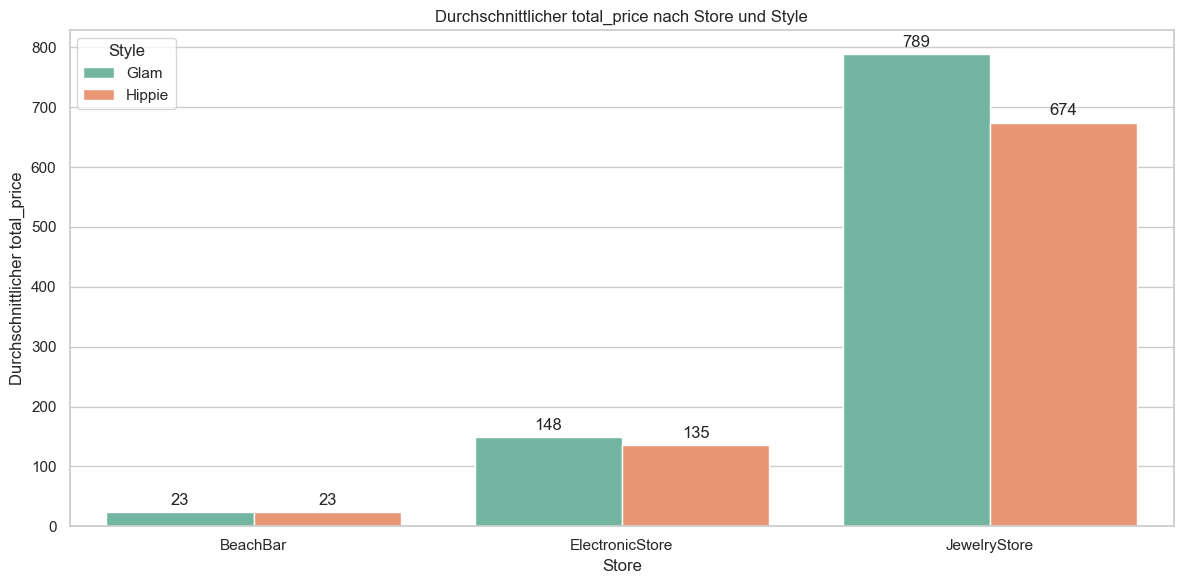

T-Tests (Glam vs. Hippie) für 'total_price' pro Store:

BeachBar:
  t = -0.073, p = 0.9419, Glam M = 23.24, Hippie M = 23.35
  → Nicht signifikant

ElectronicStore:
  t = 1.004, p = 0.3168, Glam M = 148.48, Hippie M = 135.18
  → Nicht signifikant

JewelryStore:
  t = 1.767, p = 0.0790, Glam M = 788.92, Hippie M = 674.26
  → Nicht signifikant



In [40]:
df = pd.read_csv(experiment_path2)

# === Gruppierung für Plot ===
mean_prices_by_style = (
    df.groupby(["Style", "Store"])["total_price"]
    .mean()
    .reset_index()
)

# === Visualisierung ===
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=mean_prices_by_style,
    x="Store",
    y="total_price",
    hue="Style",
    palette="Set2",
    ci=None  # Kein Konfidenzintervall
)

# Balkenbeschriftung
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.title("Durchschnittlicher total_price nach Store und Style")
plt.xlabel("Store")
plt.ylabel("Durchschnittlicher total_price")
plt.legend(title="Style")
plt.tight_layout()
plt.show()

# === T-Tests für total_price je Store ===
print("T-Tests (Glam vs. Hippie) für 'total_price' pro Store:\n")

for store in sorted(df["Store"].dropna().unique()):
    sub = df[df["Store"] == store]
    glam = sub[sub["Style"] == "Glam"]["total_price"].dropna()
    hippie = sub[sub["Style"] == "Hippie"]["total_price"].dropna()
    
    if glam.nunique() > 1 and hippie.nunique() > 1:
        t_stat, p_val = ttest_ind(glam, hippie, equal_var=False)
    else:
        t_stat, p_val = float("nan"), float("nan")

    print(f"{store}:")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}, Glam M = {glam.mean():.2f}, Hippie M = {hippie.mean():.2f}")
    print("  → Signifikant\n" if p_val < 0.05 else "  → Nicht signifikant\n")

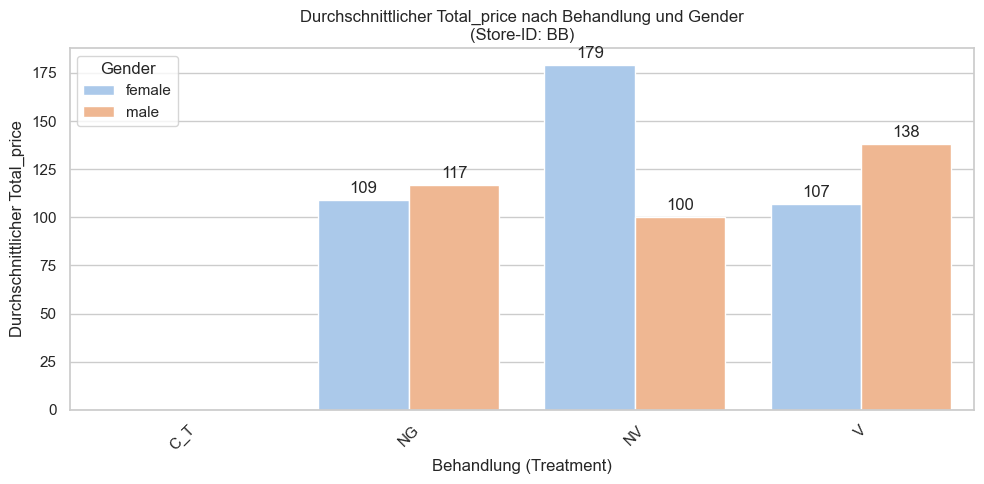

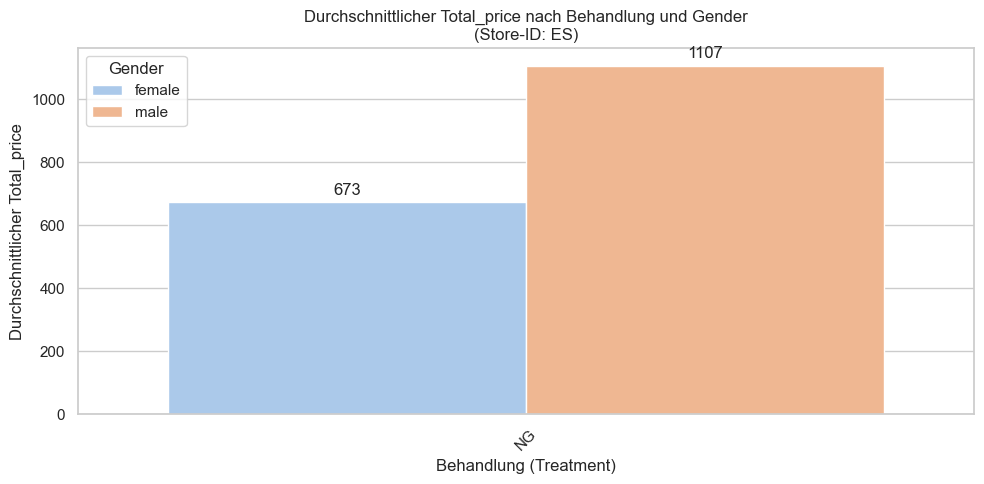

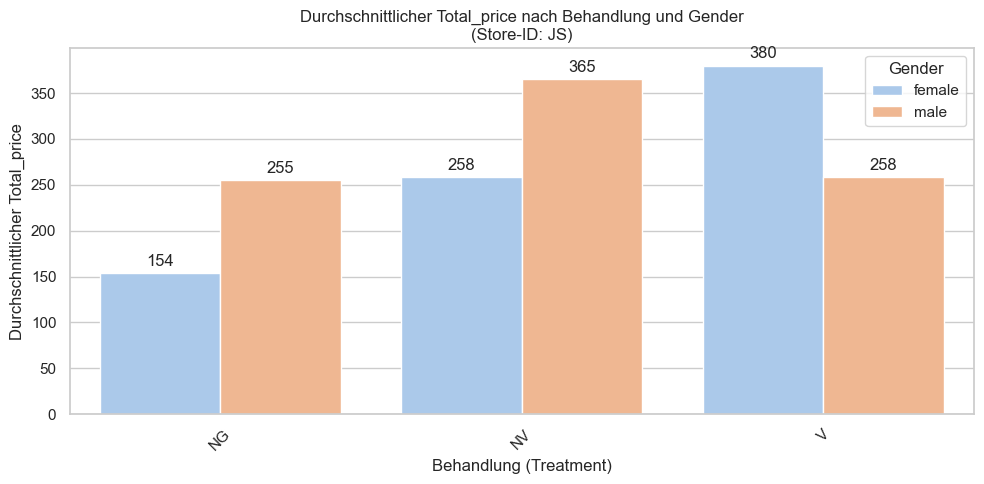

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daten laden
df = pd.read_csv(experiment_path1)

# Spalten extrahieren: Treatment = alle Zeichen vor den letzten 3, Store_ID = letzte 2 Zeichen
df["Treatment"] = df["experiment"].astype(str).str[:-3]
df["Store_ID"] = df["experiment"].astype(str).str[-2:]

# Alle eindeutigen Store-IDs durchgehen und je ein Plot erstellen
for store in sorted(df["Store_ID"].unique()):
    df_store = df[df["Store_ID"] == store]

    # Gruppierung: Treatment × Gender
    mean_prices = (
        df_store.groupby(["Treatment", "Gender"])["Total_price"]
        .mean()
        .reset_index()
        .rename(columns={"Total_price": "Average_Total_Price"})
    )

    # Plot
    plt.figure(figsize=(10, 5))
    barplot = sns.barplot(
        data=mean_prices,
        x="Treatment",
        y="Average_Total_Price",
        hue="Gender",
        palette="pastel",
        hue_order=["female", "male"],
        errorbar=None
    )

    # Balkenbeschriftungen
    for container in barplot.containers:
        barplot.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

    plt.title(f"Durchschnittlicher Total_price nach Behandlung und Gender\n(Store-ID: {store})")
    plt.xlabel("Behandlung (Treatment)")
    plt.ylabel("Durchschnittlicher Total_price")
    plt.legend(title="Gender")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

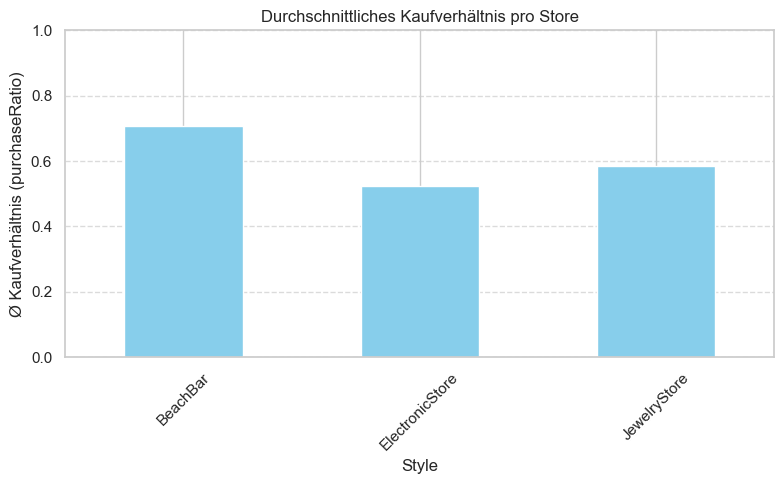

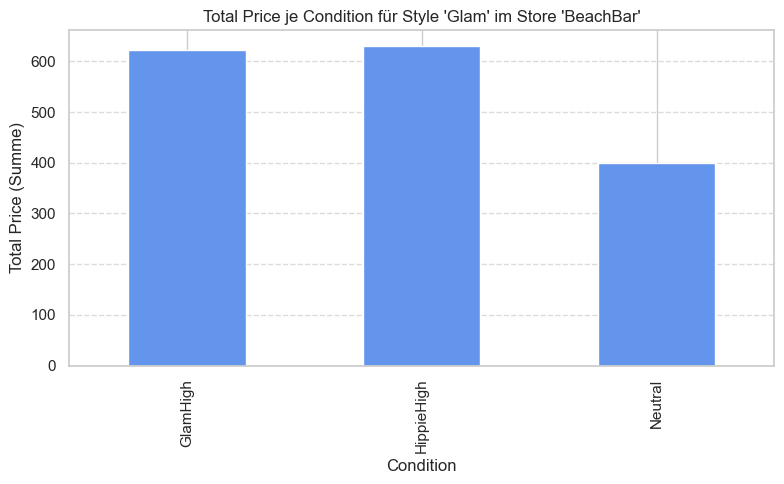

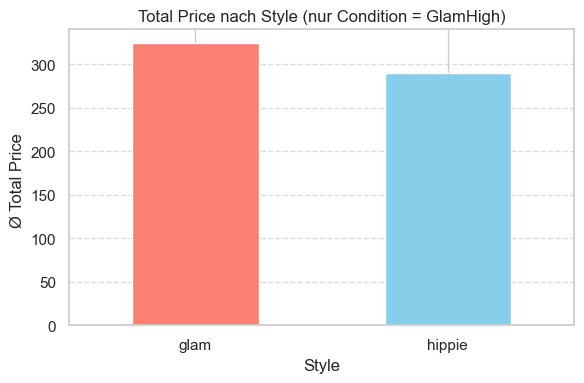

In [45]:
df = pd.read_csv(experiment_path2)

# Durchschnittliches Kaufverhältnis (purchaseRatio) je Store
mean_ratios = df.groupby("Store")["purchaseRatio"].mean()

# Balkendiagramm erzeugen
plt.figure(figsize=(8, 5))
mean_ratios.plot(kind='bar', color='skyblue')
plt.title("Durchschnittliches Kaufverhältnis pro Store")
plt.ylabel("Ø Kaufverhältnis (purchaseRatio)")
plt.xlabel("Style")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



store_filter = "BeachBar"          # z. B. "JewelryStore" oder "ElectronicStore"
style_filter = "glam"              # "glam" oder "hippie" (wird lowercase verglichen)


# === Filtern ===
filtered_df = df[
    (df["Store"] == store_filter) &
    (df["Style"].str.lower() == style_filter.lower())
]

# === Gruppieren und Summieren ===
grouped = filtered_df.groupby("Condition")["total_price"].sum()

# === Plot erstellen ===
plt.figure(figsize=(8, 5))
grouped.plot(kind="bar", color="cornflowerblue")
plt.title(f"Total Price je Condition für Style '{style_filter.capitalize()}' im Store '{store_filter}'")
plt.xlabel("Condition")
plt.ylabel("Total Price (Summe)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



# === Filter: Nur Condition = Neutral ===
neutral_df = df[df["Condition"] == "Neutral"]

# === Gruppieren nach Style und total_price summieren ===
grouped = neutral_df.groupby(df["Style"].str.lower())["total_price"].mean()

# === Plot erstellen ===
plt.figure(figsize=(6, 4))
grouped.plot(kind="bar", color=["salmon", "skyblue"])
plt.title("Total Price nach Style (nur Condition = GlamHigh)")
plt.xlabel("Style")
plt.ylabel("Ø Total Price ")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()




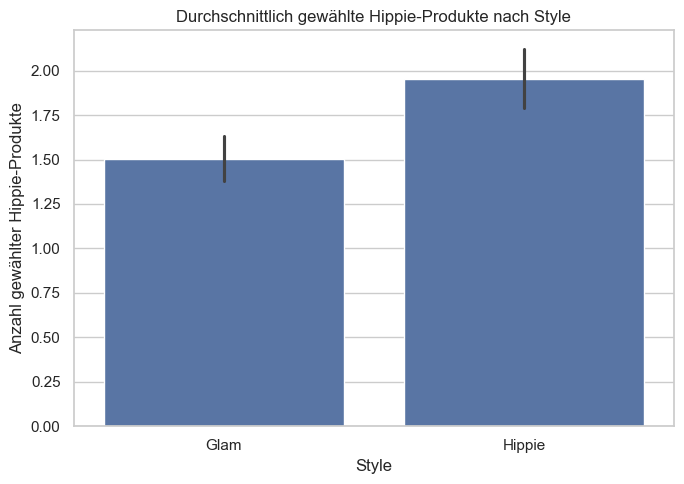

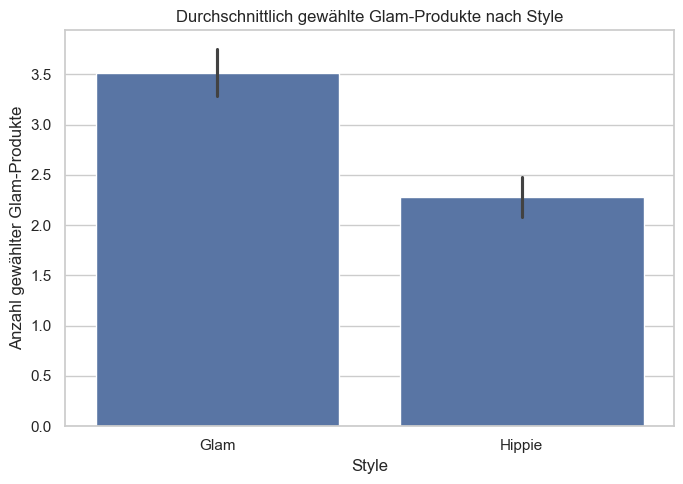

In [46]:
f = pd.read_csv(experiment_path2)

# Spaltennamen bereinigen
df.columns = df.columns.str.strip()

# hippie_choices dynamisch berechnen aus allen Spalten mit "Hippie" im Namen und "yes" als Wert
hippie_spalten = [col for col in df.columns if "hippie" in col.lower()]
df["hippie_choices"] = df[hippie_spalten].apply(lambda row: sum(str(val).strip().lower() == "yes" for val in row), axis=1)

# Style-Spalte prüfen und Plot erstellen
if "Style" in df.columns and "hippie_choices" in df.columns:
    plt.figure(figsize=(7, 5))
    sns.barplot(data=df, x="Style", y="hippie_choices", estimator="mean", errorbar="se")
    plt.title("Durchschnittlich gewählte Hippie-Produkte nach Style")
    plt.ylabel("Anzahl gewählter Hippie-Produkte")
    plt.xlabel("Style")
    plt.tight_layout()
    plt.show()
else:
    print("Benötigte Spalten ('Style' und 'hippie_choices') sind nicht vorhanden.")

glam_spalten = [col for col in df.columns if "glam" in col.lower()]
df["glam_choices"] = df[glam_spalten].apply(lambda row: sum(str(val).strip().lower() == "yes" for val in row), axis=1)

# Style-Spalte prüfen und Plot erstellen
if "Style" in df.columns and "glam_choices" in df.columns:
    plt.figure(figsize=(7, 5))
    sns.barplot(data=df, x="Style", y="glam_choices", estimator="mean", errorbar="se")
    plt.title("Durchschnittlich gewählte Glam-Produkte nach Style")
    plt.ylabel("Anzahl gewählter Glam-Produkte")
    plt.xlabel("Style")
    plt.tight_layout()
    plt.show()
else:
    print("Benötigte Spalten ('Style' und 'glam_choices') sind nicht vorhanden.")


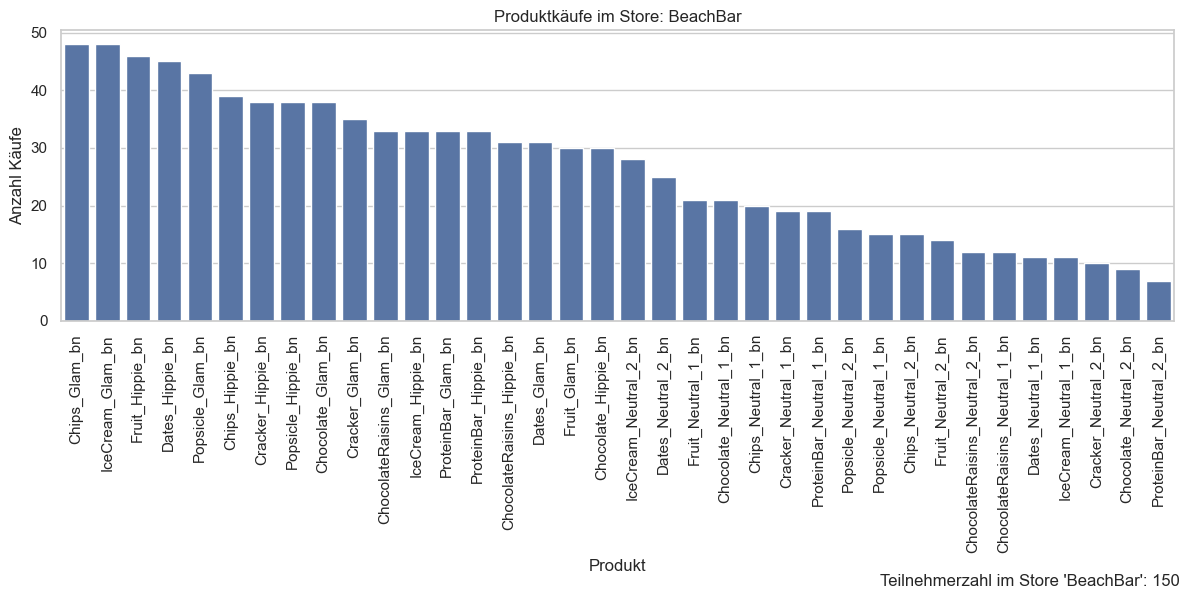

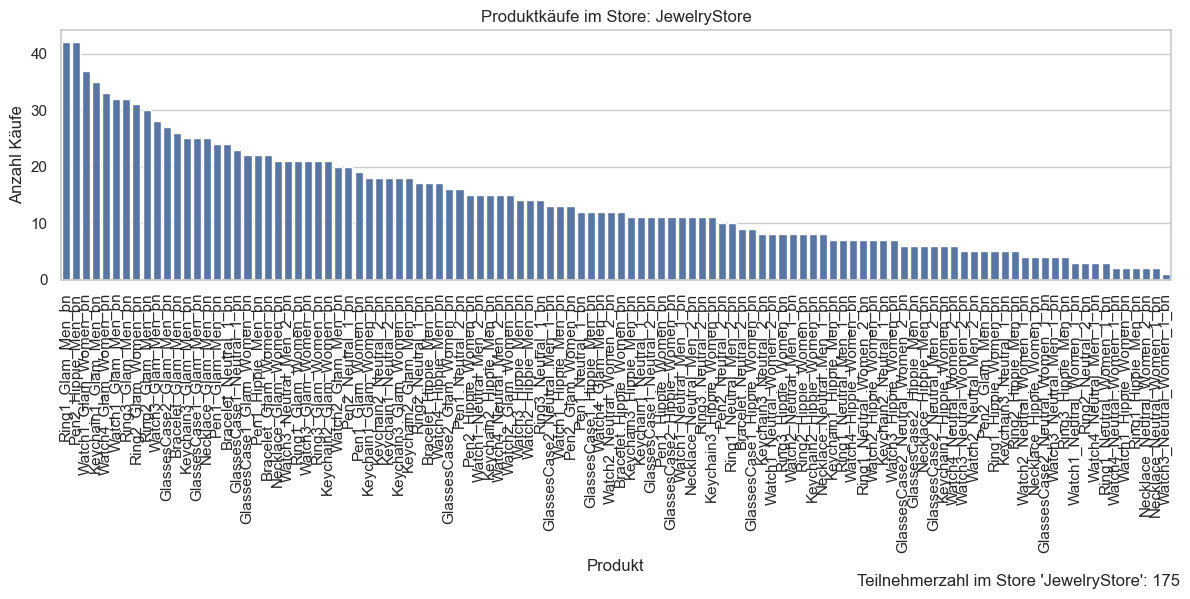

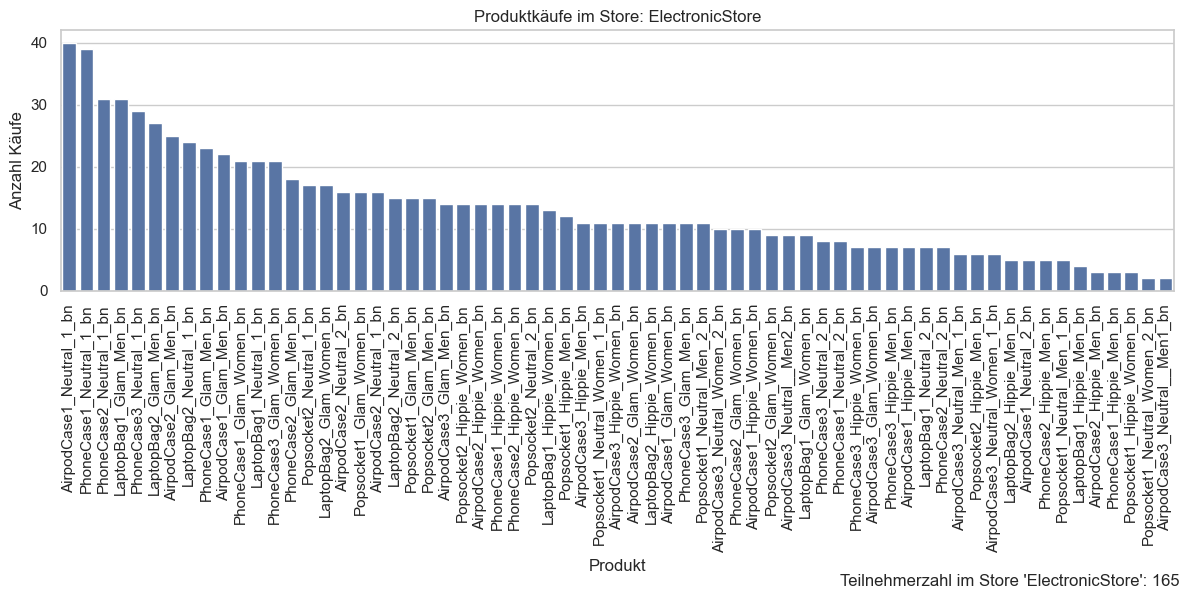

In [47]:
df = pd.read_csv(experiment_path2)

# Alle *_bn Spalten identifizieren
bn_columns = [col for col in df.columns if col.endswith("_bn")]

# Melt der Daten für Zählung
df_melted = df.melt(id_vars=["Store"], value_vars=bn_columns,
                    var_name="Produkt", value_name="Gekauft")

# Nur gekaufte Produkte (1) berücksichtigen
df_gekauft = df_melted[df_melted["Gekauft"] == 1]

# Plot pro Store erstellen
unique_stores = df_gekauft["Store"].unique()
for store in unique_stores:
    # Teilnehmerzahl **innerhalb** der Schleife bestimmen
    teilnehmer_anzahl = df[df["Store"] == store].shape[0]

    plt.figure(figsize=(12, 6))
    store_data = df_gekauft[df_gekauft["Store"] == store]
    product_counts = store_data["Produkt"].value_counts().sort_values(ascending=False)

    sns.barplot(x=product_counts.index, y=product_counts.values)
    plt.title(f"Produktkäufe im Store: {store}")
    plt.ylabel("Anzahl Käufe")
    plt.xticks(rotation=90)
    plt.figtext(0.99, 0.01, f"Teilnehmerzahl im Store '{store}': {teilnehmer_anzahl}", horizontalalignment='right')
    plt.tight_layout()
    plt.show()



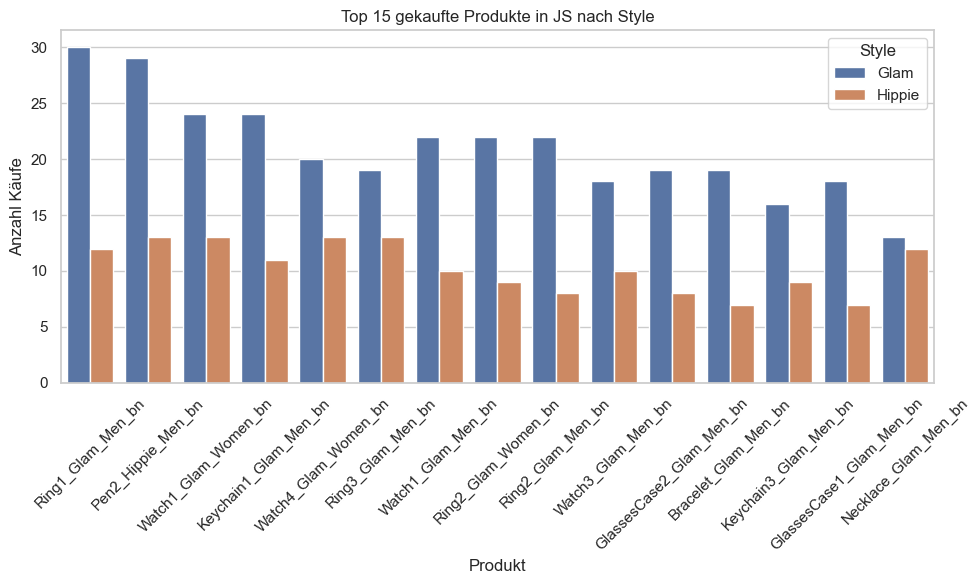

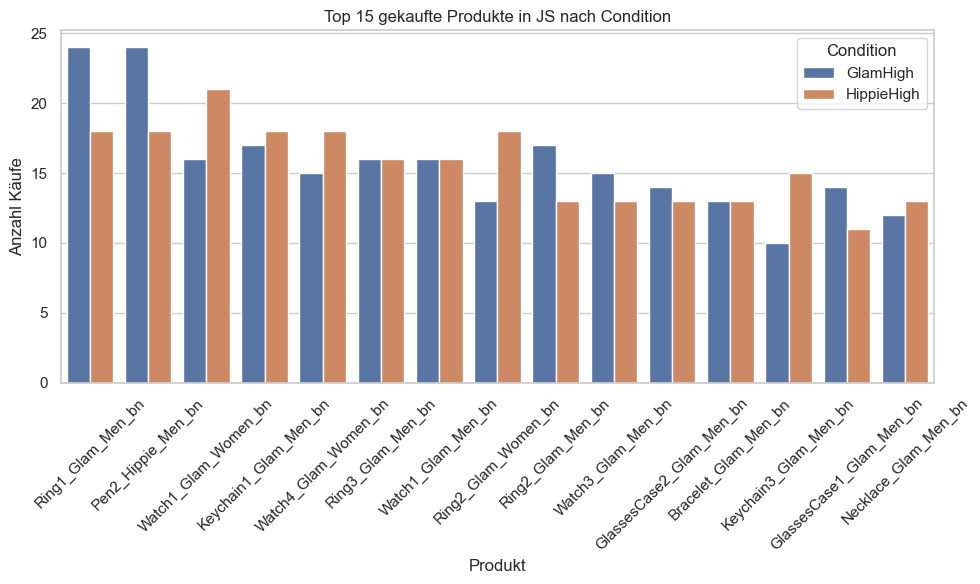

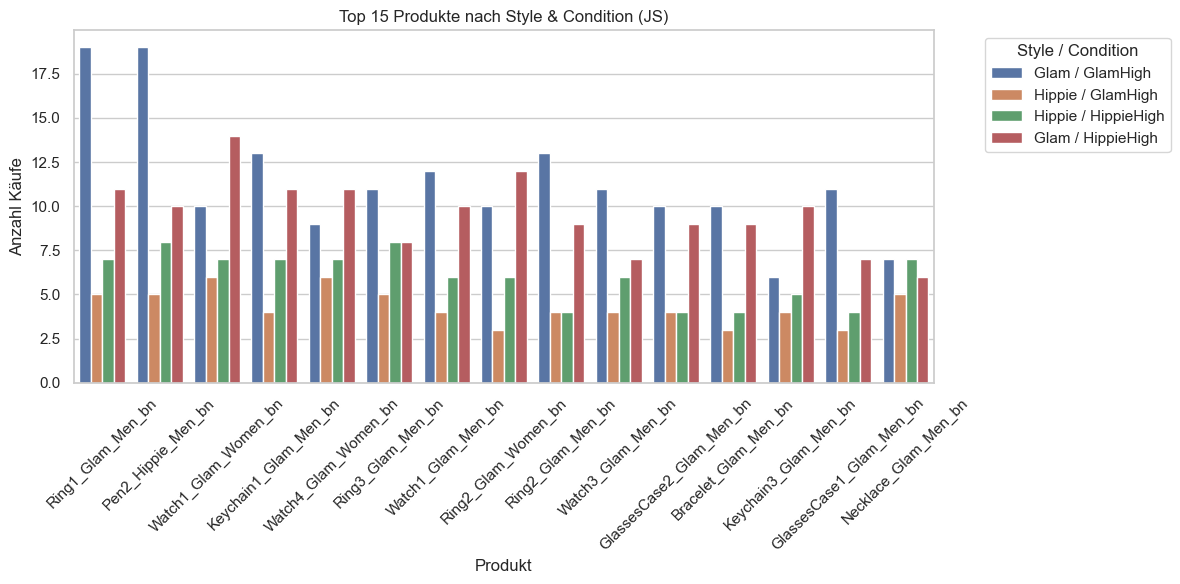

In [48]:
df = pd.read_csv(experiment_path2)


# Nur BeachBar-Daten
df_bb = df[df["Store"] == "JewelryStore"]

# Nur *_bn Spalten (binary Kaufentscheidungen)
bn_cols = [col for col in df_bb.columns if col.endswith("_bn")]

# Zähle, wie oft jedes Produkt gekauft wurde
top5 = df_bb[bn_cols].sum().sort_values(ascending=False).head(15).index.tolist()

# Top-5-Daten ins Long-Format bringen
df_long = df_bb.melt(id_vars=["Style", "Condition"], value_vars=top5,
                     var_name="Produkt", value_name="Gekauft")
df_long = df_long[df_long["Gekauft"] == 1]


plt.figure(figsize=(10, 6))
sns.countplot(data=df_long, x="Produkt", hue="Style")
plt.title("Top 15 gekaufte Produkte in Ful DS nach Style")
plt.ylabel("Anzahl Käufe")
plt.xlabel("Produkt")
plt.legend(title="Style")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.countplot(data=df_long, x="Produkt", hue="Condition")
plt.title("Top 15 gekaufte Produkte in Full DS nach Condition")
plt.ylabel("Anzahl Käufe")
plt.xlabel("Produkt")
plt.legend(title="Condition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Kombination aus Style & Condition
df_long["Style_Condition"] = df_long["Style"] + " / " + df_long["Condition"]

# Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df_long, x="Produkt", hue="Style_Condition")
plt.title("Top 15 Produkte nach Style & Condition (Full DS)")
plt.ylabel("Anzahl Käufe")
plt.xticks(rotation=45)
plt.legend(title="Style / Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



T-Tests (Gender-Effekt auf Total_price pro Store):

Beachbar:
  t = 0.415, p = 0.6789, female (n=56), male (n=64)
  Mittelwert female: 132.14, Mittelwert male: 121.88

Electronic Store:
  t = -2.723, p = 0.0095, female (n=19), male (n=26)
  Mittelwert female: 672.68, Mittelwert male: 1106.69

Jewelry Store:
  t = 1.130, p = 0.2608, female (n=54), male (n=89)
  Mittelwert female: 175.93, Mittelwert male: 155.06



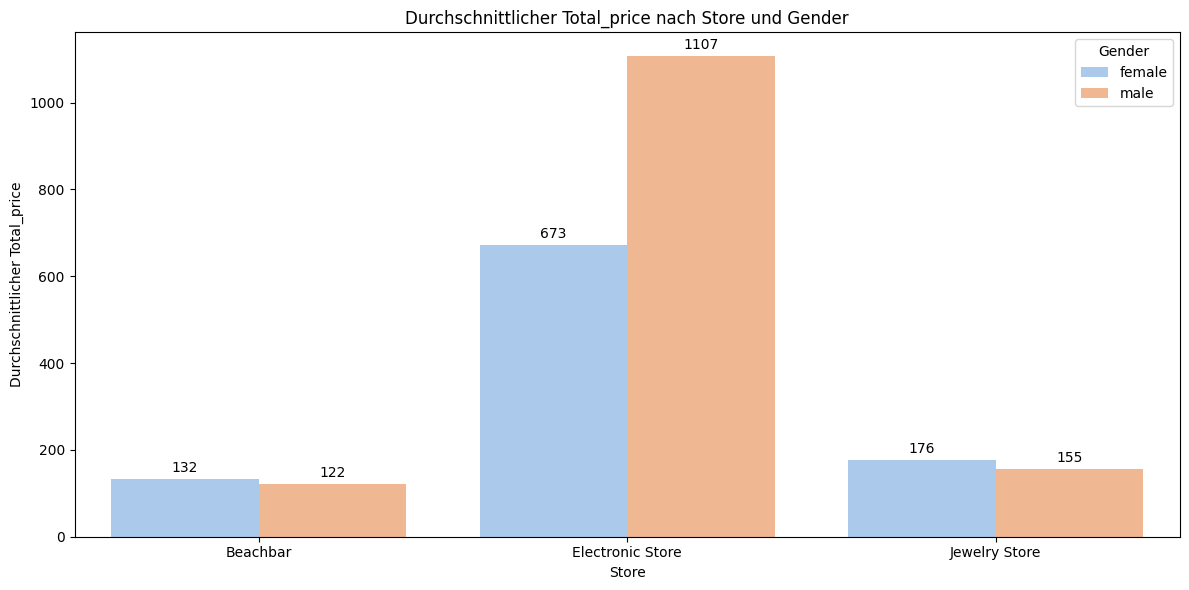

In [ ]:
df = pd.read_csv(experiment_path1)

# Zeile mit experiment = "C_T_BB" ausschließen
df = df[df["experiment"] != "C_T_BB"]

# Store-Spalte extrahieren
def extract_store(exp_str):
    if "BB" in exp_str:
        return "Beachbar"
    elif "JS" in exp_str:
        return "Jewelry Store"
    elif "ES" in exp_str:
        return "Electronic Store"
    else:
        return "Unbekannt"

df["Store"] = df["experiment"].apply(extract_store)

# T-Test: female vs. male für jede Store-Bedingung
print("T-Tests (Gender-Effekt auf Total_price pro Store):\n")
for store in df["Store"].unique():
    subset = df[df["Store"] == store]
    female = subset[subset["Gender"] == "female"]["Total_price"].dropna()
    male = subset[subset["Gender"] == "male"]["Total_price"].dropna()

    if female.nunique() > 1 and male.nunique() > 1 and len(female) > 1 and len(male) > 1:
        t_stat, p_val = ttest_ind(female, male, equal_var=False)
    else:
        t_stat, p_val = float("nan"), float("nan")

    print(f"{store}:")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}, female (n={len(female)}), male (n={len(male)})")
    print(f"  Mittelwert female: {female.mean():.2f}, Mittelwert male: {male.mean():.2f}\n")

# Gruppierung für Plot
mean_prices = (
    df.groupby(["Store", "Gender"])["Total_price"]
    .mean()
    .reset_index()
    .rename(columns={"Total_price": "Average_Total_Price"})
)

# Plot
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=mean_prices,
    x="Store",
    y="Average_Total_Price",
    hue="Gender",
    palette="pastel",
    errorbar=None,
    hue_order=["female", "male"]
)

# Balkenbeschriftung
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.title("Durchschnittlicher Total_price nach Store und Gender")
plt.xlabel("Store")
plt.ylabel("Durchschnittlicher Total_price")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()



T-Tests (Style Glam vs. Hippie je Experiment):

Experiment BB:
  t = 1.987, p = 0.0493, Glam (n=66), Hippie (n=54)
  Mittelwert Glam: 148.48, Mittelwert Hippie: 100.00



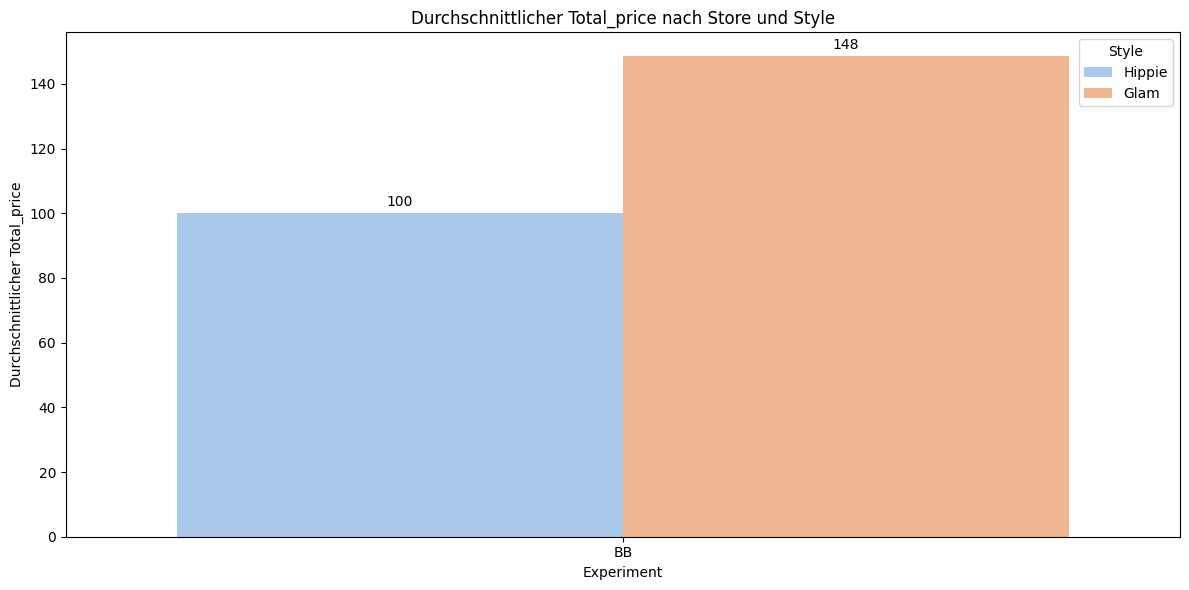

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Daten einlesen
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 1/EnclothedCognition/V&NV_BBMerged.csv')

# Neue Spalte mit letzten zwei Zeichen der 'experiment'-Bezeichnung
df["experiment_short"] = df["experiment"].astype(str).str[-2:]

# Gruppierung für den Plot
mean_prices = (
    df.groupby(["Style", "experiment_short"])["Total_price"]
    .mean()
    .reset_index()
    .rename(columns={"Total_price": "Average_Total_Price"})
)

# t-Test für jede experiment_short-Gruppe
print("T-Tests (Style Glam vs. Hippie je Experiment):\n")
for short in df["experiment_short"].unique():
    group = df[df["experiment_short"] == short]
    glam = group[group["Style"] == "Glam"]["Total_price"].dropna()
    hippie = group[group["Style"] == "Hippie"]["Total_price"].dropna()

    if glam.nunique() > 1 and hippie.nunique() > 1 and len(glam) > 1 and len(hippie) > 1:
        t_stat, p_val = ttest_ind(glam, hippie, equal_var=False)
    else:
        t_stat, p_val = float("nan"), float("nan")

    print(f"Experiment {short}:")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}, Glam (n={len(glam)}), Hippie (n={len(hippie)})")
    print(f"  Mittelwert Glam: {glam.mean():.2f}, Mittelwert Hippie: {hippie.mean():.2f}\n")

# Plot erzeugen
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=mean_prices,
    x="experiment_short",
    y="Average_Total_Price",
    hue="Style",
    palette="pastel",
    errorbar=None,
    hue_order=["Hippie", "Glam"]
)

# Balkenbeschriftung
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.title("Durchschnittlicher Total_price nach Store und Style")
plt.xlabel("Experiment")
plt.ylabel("Durchschnittlicher Total_price")
plt.legend(title="Style")
plt.tight_layout()
plt.show()



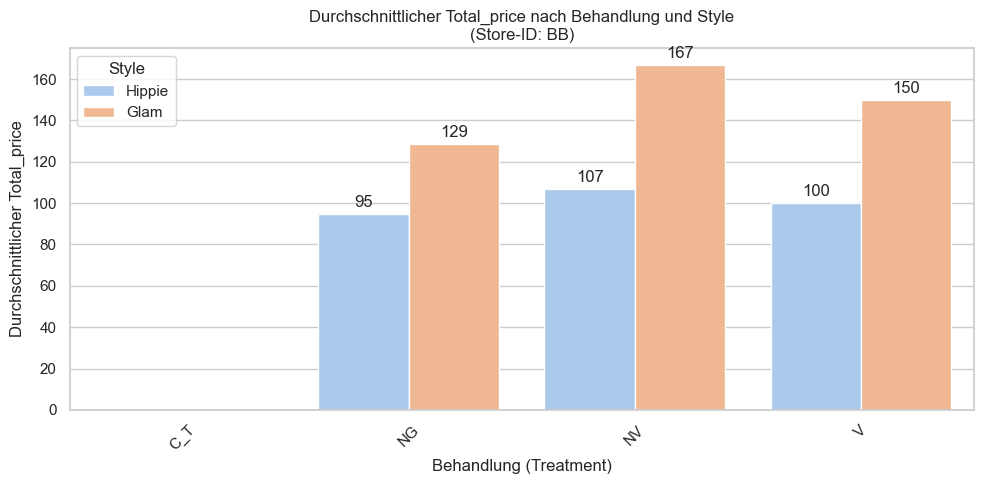

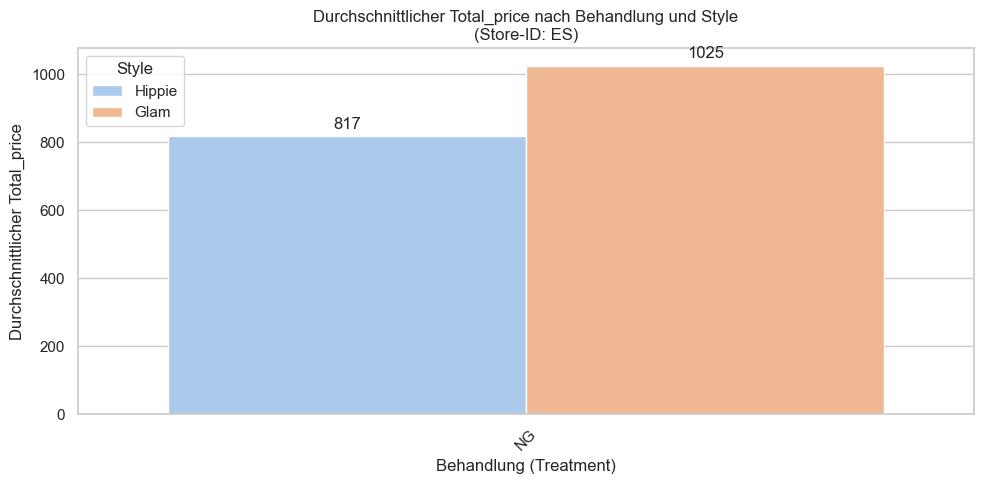

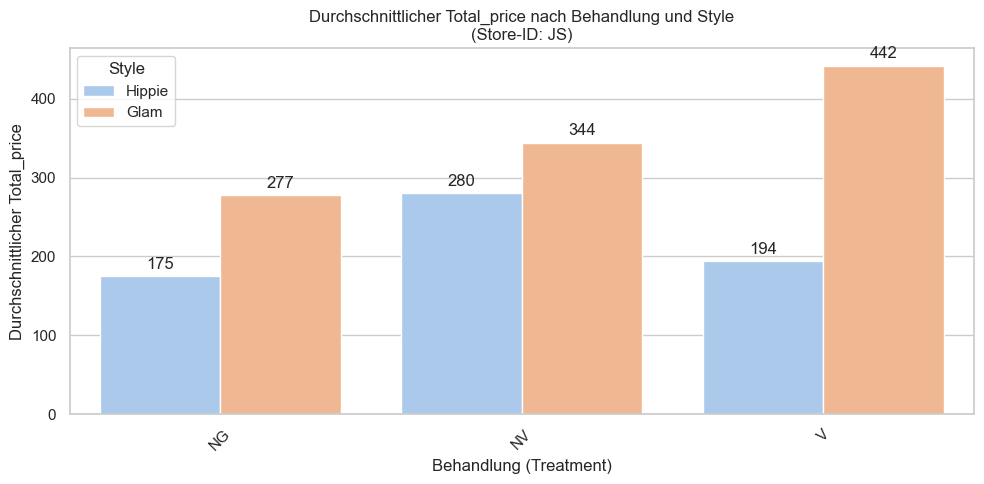

In [50]:
df = pd.read_csv(experiment_path1)

# Neue Spalten: Treatment (vorletzte 3 Zeichen entfernen) und Store-ID (letzte 2 Zeichen)
df["Treatment"] = df["experiment"].astype(str).str[:-3]
df["Store_ID"] = df["experiment"].astype(str).str[-2:]

# Für jeden Store ein separates Diagramm
store_ids = df["Store_ID"].unique()

for store in sorted(store_ids):
    df_store = df[df["Store_ID"] == store]

    # Gruppierung Treatment x Style für diesen Store
    mean_prices = (
        df_store.groupby(["Treatment", "Style"])["Total_price"]
        .mean()
        .reset_index()
        .rename(columns={"Total_price": "Average_Total_Price"})
    )

    # Plot
    plt.figure(figsize=(10, 5))
    barplot = sns.barplot(
        data=mean_prices,
        x="Treatment",
        y="Average_Total_Price",
        hue="Style",
        palette="pastel",
        hue_order=["Hippie", "Glam"],
        errorbar=None
    )

    for container in barplot.containers:
        barplot.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

    plt.title(f"Durchschnittlicher Total_price nach Behandlung und Style\n(Store-ID: {store})")
    plt.xlabel("Behandlung (Treatment)")
    plt.ylabel("Durchschnittlicher Total_price")
    plt.legend(title="Style")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Nachhaltigkeit

T-Tests (Style = Glam vs. Hippie) für Umwelt- und Umweltwert-Skalen:

GreenValues_umweltbewusst:
  t = -0.835, p = 0.4075, Glam (M=3.11), Hippie (M=3.32)
  → Nicht signifikant

GreenValues_sorgen:
  t = -0.608, p = 0.5457, Glam (M=3.64), Hippie (M=3.80)
  → Nicht signifikant

GreenValues_schaedigen:
  t = -0.445, p = 0.6583, Glam (M=3.36), Hippie (M=3.48)
  → Nicht signifikant

GreenValues_kaufverhalten:
  t = -1.148, p = 0.2561, Glam (M=3.03), Hippie (M=3.36)
  → Nicht signifikant

GreenValues_Umweltauswirkungen:
  t = -0.923, p = 0.3612, Glam (M=3.03), Hippie (M=3.28)
  → Nicht signifikant

GreenValues_Massnahmen:
  t = -1.281, p = 0.2058, Glam (M=3.08), Hippie (M=3.40)
  → Nicht signifikant

EnvironmentalConcern_1:
  t = -1.466, p = 0.1482, Glam (M=3.94), Hippie (M=4.32)
  → Nicht signifikant

EnvironmentalConcern_2:
  t = -1.352, p = 0.1818, Glam (M=3.53), Hippie (M=3.84)
  → Nicht signifikant

EnvironmentalConcern_3:
  t = -1.026, p = 0.3092, Glam (M=3.78), Hippie (M=4.04)
  → Nic

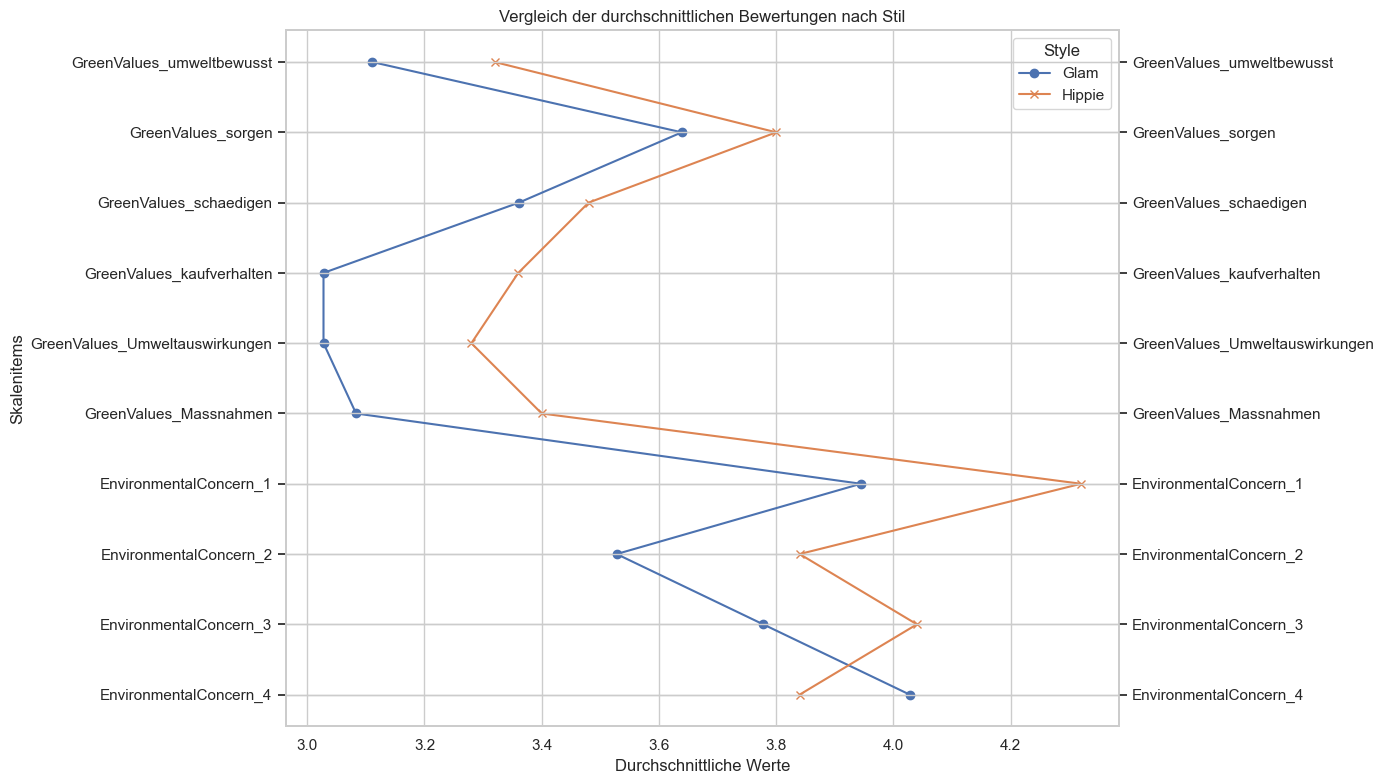

In [53]:
df = pd.read_csv(experiment_path1)

# === Relevante Skalenitems ===
columns_env = [
    "GreenValues_umweltbewusst", "GreenValues_sorgen", "GreenValues_schaedigen", "GreenValues_kaufverhalten",
    "GreenValues_Umweltauswirkungen", "GreenValues_Massnahmen", 
    "EnvironmentalConcern_1", "EnvironmentalConcern_2", "EnvironmentalConcern_3",
    "EnvironmentalConcern_4"
]

# === T-Tests zwischen Glam und Hippie pro Item ===
print("T-Tests (Style = Glam vs. Hippie) für Umwelt- und Umweltwert-Skalen:\n")
for col in columns_env:
    glam = df[df["Style"] == "Glam"][col].dropna()
    hippie = df[df["Style"] == "Hippie"][col].dropna()
    
    if glam.nunique() > 1 and hippie.nunique() > 1:
        t_stat, p_val = ttest_ind(glam, hippie, equal_var=False)
    else:
        t_stat, p_val = float("nan"), float("nan")

    print(f"{col}:")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}, Glam (M={glam.mean():.2f}), Hippie (M={hippie.mean():.2f})")
    if p_val < 0.05:
        print("  → Signifikant!\n")
    else:
        print("  → Nicht signifikant\n")

# === Mittelwerte für Plot berechnen ===
mean_values_env = df.groupby('Style')[columns_env].mean().T

# === Plot ===
plt.figure(figsize=(14, 8))
ax1 = plt.gca()

# Linien pro Stil
for style in mean_values_env.columns:
    ax1.plot(mean_values_env[style], mean_values_env.index, label=style, marker='o' if style == 'Glam' else 'x')

# Achsenformatierung
ax1.set_xlabel('Durchschnittliche Werte')
ax1.set_ylabel('Skalenitems')
ax1.set_title('Vergleich der durchschnittlichen Bewertungen nach Stil')

# Sekundärachse (Y) für Symmetrie
ax2 = ax1.twinx()
ax2.set_yticks(ax1.get_yticks())
ax2.set_yticklabels(ax1.get_yticklabels())

# Achsen umdrehen und synchronisieren
ax1.invert_yaxis()
ax2.invert_yaxis()
ax2.set_ylim(ax1.get_ylim())

# Legende und Anzeige
ax1.legend(title="Style")
plt.tight_layout()
plt.show()


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/3454333465.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_bb['Scale_clean_up'] = pd.to_numeric(subset_bb['Scale_clean_up'], errors='coerce')
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/3454333465.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_bb['time_amount'] = pd.to_numeric(subset_bb['time_amount'], errors='coerce')
/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_30193/3454333465.py:15:

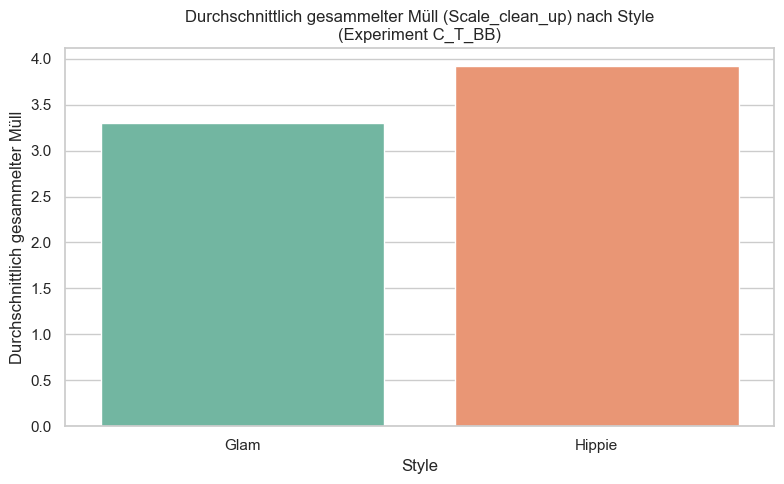

Signifikanztest: Einfluss von Style auf Scale_clean_up und time_amount

Scale_clean_up:
t = -2.232, p = 0.0295, Glam M = 3.31, Hippie M = 3.92
→ Signifikant 

time_amount:
t = -1.337, p = 0.1882, Glam M = 22.81, Hippie M = 29.36
→ Nicht signifikant


In [54]:
df = pd.read_csv(experiment_path1)

# Nur relevante Zeilen behalten
subset_bb = df[(df['experiment'] == 'C_T_BB') & (df['Scale_clean_up'].notna()) & (df['time_amount'].notna())]

# Numerisch sicherstellen
subset_bb['Scale_clean_up'] = pd.to_numeric(subset_bb['Scale_clean_up'], errors='coerce')
subset_bb['time_amount'] = pd.to_numeric(subset_bb['time_amount'], errors='coerce')

# Mittelwerte für Plot
grouped_time = subset_bb.groupby('Style')['Scale_clean_up'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=grouped_time, x='Style', y='Scale_clean_up', palette='Set2')
plt.title("Durchschnittlich gesammelter Müll (Scale_clean_up) nach Style\n(Experiment C_T_BB)")
plt.ylabel("Durchschnittlich gesammelter Müll")
plt.xlabel("Style")
plt.tight_layout()
plt.show()

# === T-Tests ===
print("Signifikanztest: Einfluss von Style auf Scale_clean_up und time_amount\n")

# Scale_clean_up
glam_cleanup = subset_bb[subset_bb["Style"] == "Glam"]["Scale_clean_up"].dropna()
hippie_cleanup = subset_bb[subset_bb["Style"] == "Hippie"]["Scale_clean_up"].dropna()

t1, p1 = ttest_ind(glam_cleanup, hippie_cleanup, equal_var=False)
print(f"Scale_clean_up:\nt = {t1:.3f}, p = {p1:.4f}, Glam M = {glam_cleanup.mean():.2f}, Hippie M = {hippie_cleanup.mean():.2f}")
print("→ Signifikant" if p1 < 0.05 else "→ Nicht signifikant", "\n")

# time_amount
glam_time = subset_bb[subset_bb["Style"] == "Glam"]["time_amount"].dropna()
hippie_time = subset_bb[subset_bb["Style"] == "Hippie"]["time_amount"].dropna()

t2, p2 = ttest_ind(glam_time, hippie_time, equal_var=False)
print(f"time_amount:\nt = {t2:.3f}, p = {p2:.4f}, Glam M = {glam_time.mean():.2f}, Hippie M = {hippie_time.mean():.2f}")
print("→ Signifikant" if p2 < 0.05 else "→ Nicht signifikant")

## Skalen Konsistenz

In [102]:
import pandas as pd
import numpy as np

# Function to calculate Cronbach's alpha
def calculate_cronbach_alpha(data):

    item_variances = data.var(axis=0, ddof=1)
    total_variance = data.sum(axis=1).var(ddof=1)
    n_items = data.shape[1]
    
    cronbach_alpha = (n_items / (n_items - 1)) * (1 - (item_variances.sum() / total_variance))
    return cronbach_alpha


data = pd.read_csv(experiment_path2)

# Defining the scales and their corresponding items
scales = {
    "Social Status": [
        'social_status__erfolgreich', 
        'social_status_bedeutsam', 
        'social_status_ueberlegen'
    ],
    "Social Confidence": [
        'socialConfidence_produkt',
        'socialConfidence_marke',
        'socialConfidence_beeindrucken',
        'socialConfidence_geschenk',
        'socialConfidence_kompliment'
    ],
    "Materialism": [
        'Materialism_1',
        'Materialism_2',
        'Materialism_3',
        'Materialism_4'
    ],
    "Need to Differentiate": [
        'Need_to_differantiate_1',
        'Need_to_differantiate_2',
        'Need_to_differantiate_3'
    ],
    'Environmental Concern':[
    'EnvironmentalConcern_1',
    'EnvironmentalConcern_2',
    'EnvironmentalConcern_3'
    ],
    'GreenValues':[
        'GreenValues_schaedigen',
        'GreenValues_kaufverhalten',
        'GreenValues_Massnahmen',
        'GreenValues_sorgen',
        'GreenValues_umweltbewusst'
        'GreenValues_Umweltauswirkungen'
    ]
    


    
}

# Clean data: Convert all scale-related columns to numeric and handle invalid entries
for scale_name, items in scales.items():
    for item in items:
        if item in data.columns:
            # Attempt to convert to numeric; set errors='coerce' to replace invalid values with NaN
            data[item] = pd.to_numeric(data[item], errors='coerce')

# Recalculate Cronbach's Alpha for the scales
cronbach_alpha_results_cleaned = {}
for scale_name, items in scales.items():
    if all(item in data.columns for item in items):
        scale_data = data[items].dropna()  # Drop rows with missing values
        alpha = calculate_cronbach_alpha(scale_data)
        cronbach_alpha_results_cleaned[scale_name] = alpha
    else:
        cronbach_alpha_results_cleaned[scale_name] = "Missing items in dataset"

# Display the results
for scale, alpha in cronbach_alpha_results_cleaned.items():
    print(f"Scale: {scale}, Cronbach's Alpha: {alpha}")

Scale: Social Status, Cronbach's Alpha: Missing items in dataset
Scale: Social Confidence, Cronbach's Alpha: 0.6910186288288671
Scale: Materialism, Cronbach's Alpha: 0.758785077319161
Scale: Need to Differentiate, Cronbach's Alpha: 0.7750513647534208
Scale: Environmental Concern, Cronbach's Alpha: 0.6935059944925495
Scale: GreenValues, Cronbach's Alpha: Missing items in dataset


## Korrelationen

Korrelationsmatrix zwischen Charaktereigenschaften und Outcomes:
                             social_status  Materialism  green_values  \
SelbssicherUnsicher                  -0.25        -0.17          0.23   
MutigÄngstlich                       -0.27        -0.20          0.16   
AuffäligUnauffälig                   -0.18        -0.16          0.33   
ManipulativAufrichtig                -0.27        -0.28          0.03   
MächtigMachtlos                      -0.37        -0.27          0.12   
ExclusivDurchschnitt                 -0.28        -0.22          0.38   
begehrenswertNicht                   -0.20        -0.12          0.12   
BewundertNicht                       -0.30        -0.21          0.13   
PrivilegiertNicht                    -0.41        -0.24          0.09   
WohlhabendNicht                      -0.38        -0.29          0.18   
ÜberheblichDezent                    -0.30        -0.27          0.07   
IntelligentSchlicht                  -0.08        -0.00    

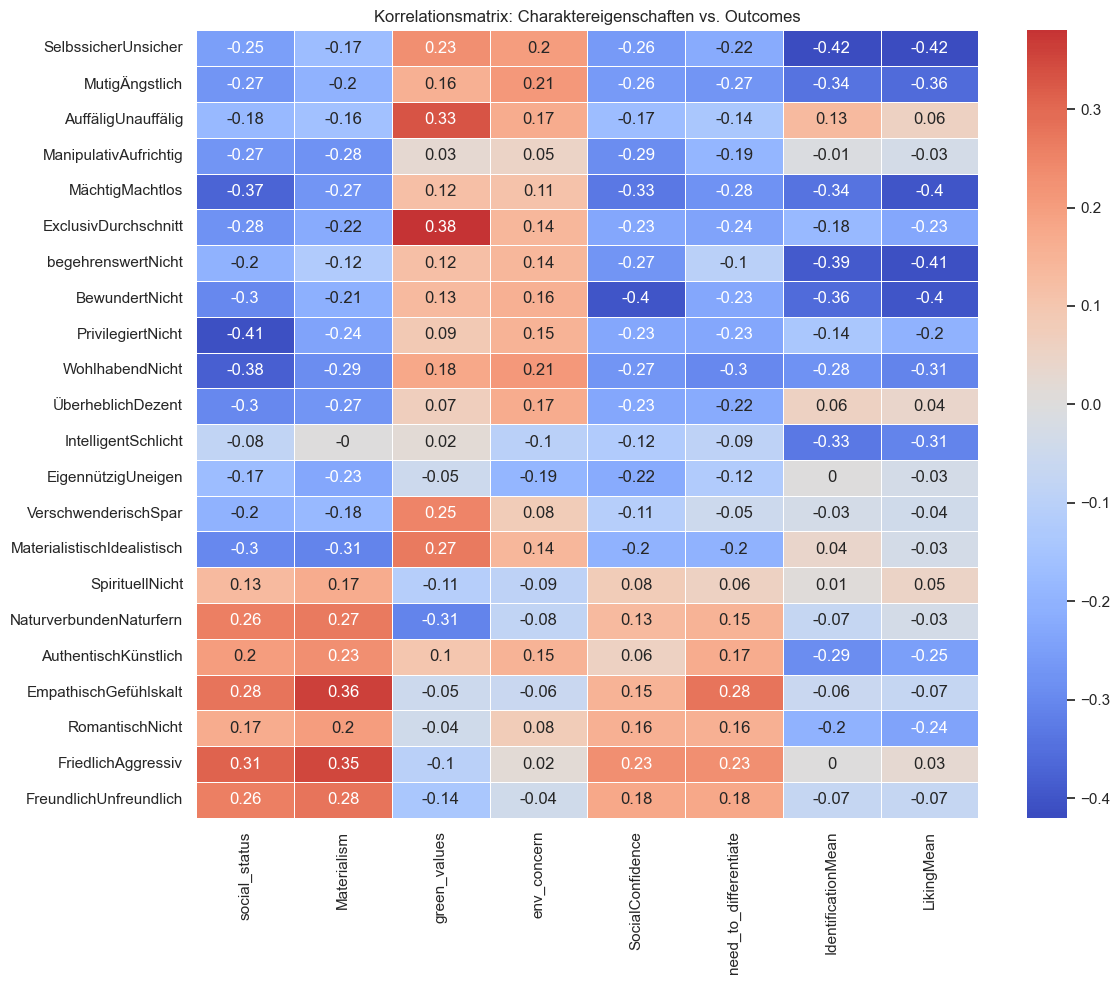

In [57]:
df = pd.read_csv(experiment_path1) 

# Charaktereigenschaften / assoziationen 
character_traits = [
    'SelbssicherUnsicher', 'MutigÄngstlich', 'AuffäligUnauffälig', 'ManipulativAufrichtig',
    'MächtigMachtlos', 'ExclusivDurchschnitt', 'begehrenswertNicht', 'BewundertNicht',
    'PrivilegiertNicht', 'WohlhabendNicht', 'ÜberheblichDezent', 'IntelligentSchlicht',
    'EigennützigUneigen', 'VerschwenderischSpar', 'MaterialistischIdealistisch',
    'SpirituellNicht', 'NaturverbundenNaturfern', 'AuthentischKünstlich',
    'EmpathischGefühlskalt', 'RomantischNicht', 'FriedlichAggressiv', 'FreundlichUnfreundlich'
]

# Skalenmittelwerte berechnen
df['green_values'] = df[
    ['GreenValues_Massnahmen', 'GreenValues_kaufverhalten', 'GreenValues_sorgen',
     'GreenValues_schaedigen', 'GreenValues_Umweltauswirkungen']
].mean(axis=1)

df['env_concern'] = df[
    ['EnvironmentalConcern_1', 'EnvironmentalConcern_2', 'EnvironmentalConcern_3', 'EnvironmentalConcern_4']
].mean(axis=1)

#df['altruism'] = df[['Alturism_1', 'Alturism_2', 'Alturism_3', 'Alturism_4']].mean(axis=1)

df['need_to_differentiate'] = df[
    ['Need_to_differantiate_1', 'Need_to_differantiate_2', 'Need_to_differantiate_3']
].mean(axis=1)

# Alle relevanten Outcomes
outcomes = [
    'social_status', 'Materialism', 'green_values', 'env_concern', 'SocialConfidence',
    'need_to_differentiate', 'IdentificationMean', 'LikingMean'
]

# Korrelationsmatrix berechnen
corr_matrix = df[character_traits + outcomes].corr().loc[character_traits, outcomes].round(2)

# Ausgabe
print("Korrelationsmatrix zwischen Charaktereigenschaften und Outcomes:")
print(corr_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Korrelationsmatrix: Charaktereigenschaften vs. Outcomes")
plt.tight_layout()
plt.show()


3.875
nan


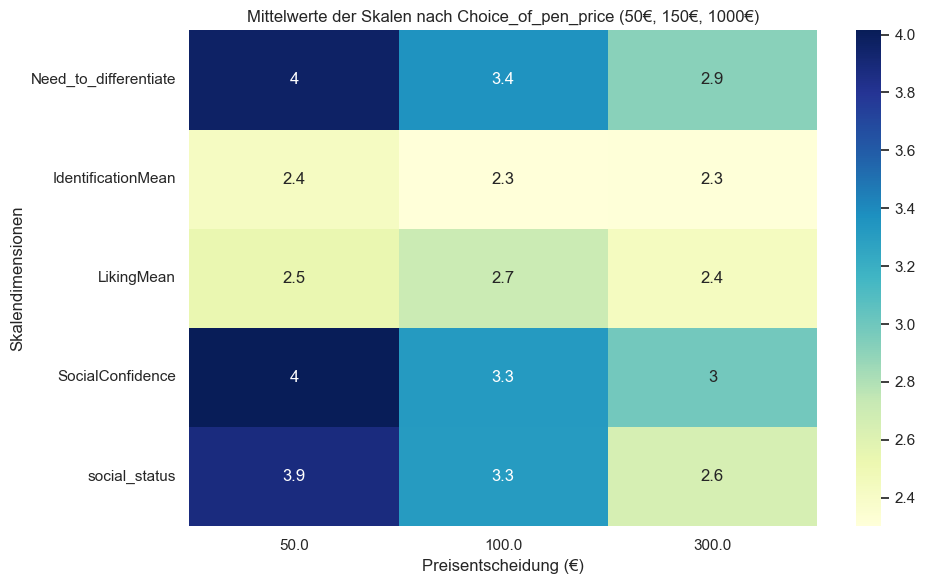

In [59]:
df = pd.read_csv(experiment_path1)
# Mittelwert von 'social_status' für Fälle mit 'Choice_of_pen_price' == 50
mean_social_status_50 = df[df['Choice_of_pen_price'] == 50]['social_status'].mean()
print(mean_social_status_50)

mean_social_status_300 = df[df['Choice_of_pen_price'] == 1000]['social_status'].mean()
print(mean_social_status_300)
# Nur gültige Choice_of_pen_price-Werte behalten
df = df[df['Choice_of_pen_price'].notna() & (df['Choice_of_pen_price'] != 0)]

# Zielkategorien
target_categories = [50, 300, 100]

# Nur gewünschte Kategorien berücksichtigen
df = df[df['Choice_of_pen_price'].isin(target_categories)]

# Skalenliste
scales = [
    #'social_status__erfolgreich','social_status_bedeutsam','social_status_ueberlegen',
    #'Materialism_1','Materialism_2','Materialism_3','Materialism_4',
    #'Need_to_differantiate_1','Need_to_differantiate_2','Need_to_differantiate_3','socialConfidence_geschenk',
    'Need_to_differentiate','IdentificationMean',
    'LikingMean','SocialConfidence','social_status'
]

# Mittelwerte je Preiskategorie berechnen
group_means = df.groupby('Choice_of_pen_price')[scales].mean().T

# Heatmap anzeigen
plt.figure(figsize=(10, 6))
sns.heatmap(group_means, annot=True, cmap='YlGnBu', )
plt.title("Mittelwerte der Skalen nach Choice_of_pen_price (50€, 150€, 1000€)")
plt.xlabel("Preisentscheidung (€)")
plt.ylabel("Skalendimensionen")
plt.tight_layout()
plt.show()




nan
3.9922480620155043


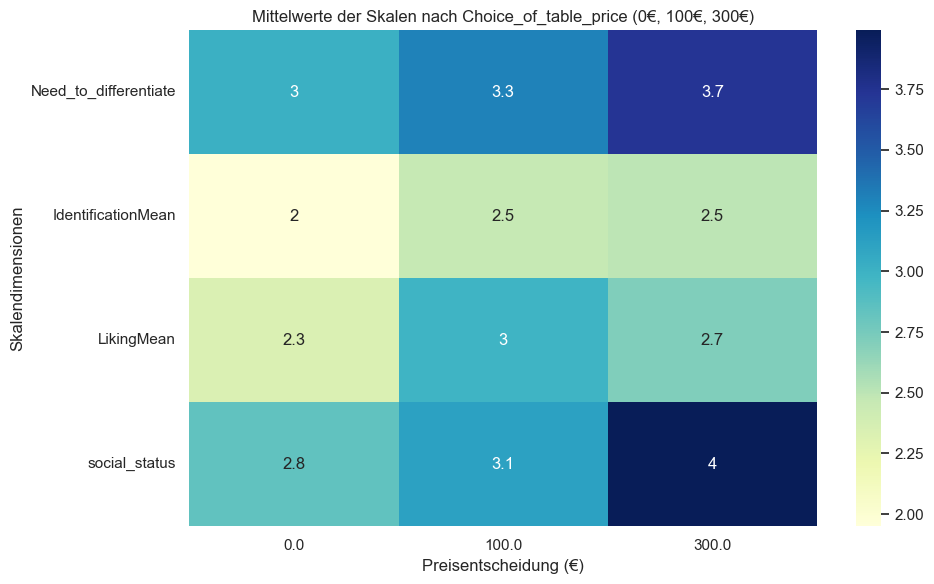

In [60]:
df = pd.read_csv(experiment_path1)
# Mittelwert von 'social_status' für Fälle mit 'Choice_of_pen_price' == 50
mean_social_status_50 = df[df['Choice_of_table_price'] == 50]['social_status'].mean()
print(mean_social_status_50)

mean_social_status_300 = df[df['Choice_of_table_price'] == 300]['social_status'].mean()
print(mean_social_status_300)
# Nur gültige Choice_of_pen_price-Werte behalten
df = df[df['Choice_of_table_price'].notna() ]

# Zielkategorien
target_categories = [0, 100, 300]

# Nur gewünschte Kategorien berücksichtigen
df = df[df['Choice_of_table_price'].isin(target_categories)]

# Skalenliste
scales = [
    #'social_status__erfolgreich','social_status_bedeutsam','social_status_ueberlegen',
    #'Materialism_1','Materialism_2','Materialism_3','Materialism_4',
    #'Need_to_differantiate_1','Need_to_differantiate_2','Need_to_differantiate_3','socialConfidence_geschenk',
    'Need_to_differentiate','IdentificationMean',
    'LikingMean','social_status'
]

# Mittelwerte je Preiskategorie berechnen
group_means = df.groupby('Choice_of_table_price')[scales].mean().T

# Heatmap anzeigen
plt.figure(figsize=(10, 6))
sns.heatmap(group_means, annot=True, cmap='YlGnBu', )
plt.title("Mittelwerte der Skalen nach Choice_of_table_price (0€, 100€, 300€)")
plt.xlabel("Preisentscheidung (€)")
plt.ylabel("Skalendimensionen")
plt.tight_layout()
plt.show()

nan
nan


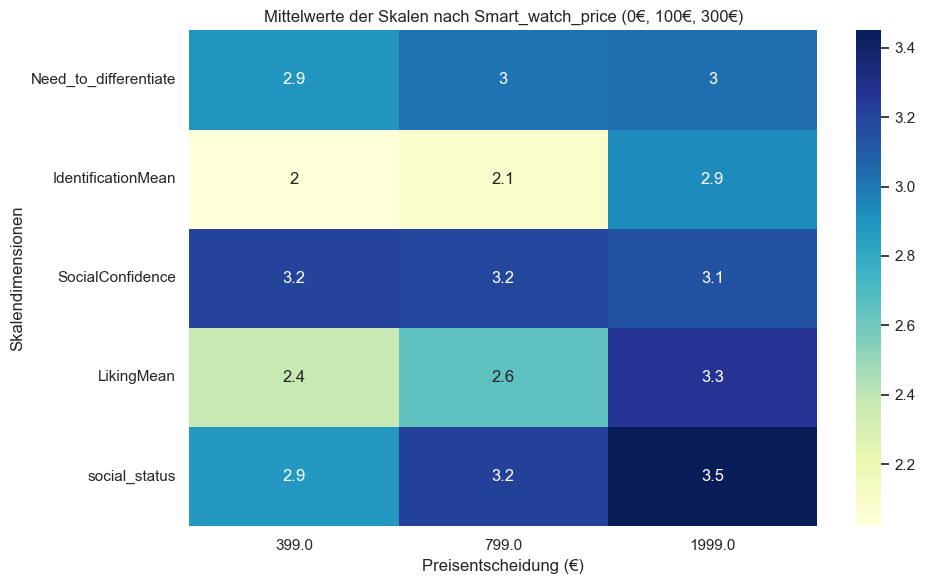

In [61]:
df = pd.read_csv(experiment_path1)
# Mittelwert von 'social_status' für Fälle mit 'Choice_of_pen_price' == 50
mean_social_status_50 = df[df['Smart_watch_price'] == 50]['social_status'].mean()
print(mean_social_status_50)

mean_social_status_300 = df[df['Smart_watch_price'] == 300]['social_status'].mean()
print(mean_social_status_300)
# Nur gültige Choice_of_pen_price-Werte behalten
df = df[df['Smart_watch_price'].notna()& (df['Choice_of_pen_price'] != 0)]

# Zielkategorien
target_categories = [399, 799, 1999]

# Nur gewünschte Kategorien berücksichtigen
df = df[df['Smart_watch_price'].isin(target_categories)]
df['IdentificationMean'] = df[['IdentifikationPasst', 'IdentifikationIdentifizieren', 'IdentifikationMir']].mean(axis=1)
#f['IdentificationMean'].mean()
df['LikingMean'] = df[['LikingAn',	'LikingSchön',	'LikingGefällt']].mean(axis=1)
# Skalenliste
scales = [
    #'social_status__erfolgreich','social_status_bedeutsam','social_status_ueberlegen',
    #'Materialism_1','Materialism_2','Materialism_3','Materialism_4',
    #'Need_to_differantiate_1','Need_to_differantiate_2','Need_to_differantiate_3','socialConfidence_geschenk',
    'Need_to_differentiate','IdentificationMean','SocialConfidence',
    'LikingMean','social_status'
]

# Mittelwerte je Preiskategorie berechnen
group_means = df.groupby('Smart_watch_price')[scales].mean().T

# Heatmap anzeigen
plt.figure(figsize=(10, 6))
sns.heatmap(group_means, annot=True, cmap='YlGnBu', )
plt.title("Mittelwerte der Skalen nach Smart_watch_price (0€, 100€, 300€)")
plt.xlabel("Preisentscheidung (€)")
plt.ylabel("Skalendimensionen")
plt.tight_layout()
plt.show()

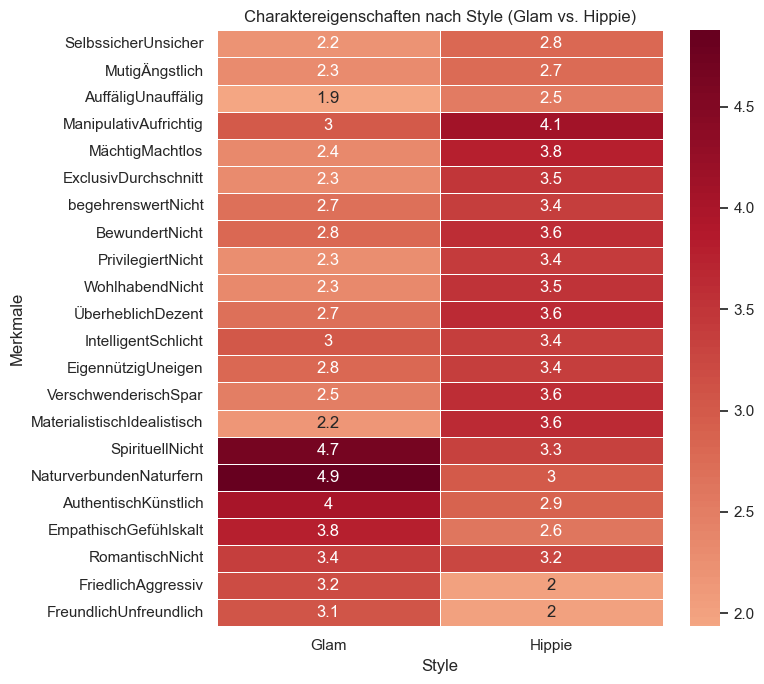

In [62]:
df = pd.read_csv(experiment_path2)
# Nur Daten mit Style 'Glam' oder 'Hippie' auswählen
style_filtered_df = df[df['Style'].isin(['Glam', 'Hippie'])]

# Liste psychologischer Skalen (z. B. wie in der Heatmap-Abbildung)
traits = [
    'SelbssicherUnsicher', 'MutigÄngstlich', 'AuffäligUnauffälig',
    'ManipulativAufrichtig', 'MächtigMachtlos', 'ExclusivDurchschnitt',
    'begehrenswertNicht', 'BewundertNicht', 'PrivilegiertNicht',
    'WohlhabendNicht', 'ÜberheblichDezent', 'IntelligentSchlicht',
    'EigennützigUneigen', 'VerschwenderischSpar', 'MaterialistischIdealistisch',
    'SpirituellNicht', 'NaturverbundenNaturfern', 'AuthentischKünstlich',
    'EmpathischGefühlskalt', 'RomantischNicht', 'FriedlichAggressiv',
    'FreundlichUnfreundlich'
]

# Mittelwerte der Merkmale gruppiert nach Style
trait_means_by_style = style_filtered_df.groupby('Style')[traits].mean().T

# Heatmap plotten
plt.figure(figsize=(8, 7))
sns.heatmap(trait_means_by_style, annot=True, cmap='RdBu_r', center=0, linewidths=0.5)
plt.title("Charaktereigenschaften nach Style (Glam vs. Hippie)")
plt.xlabel("Style")
plt.ylabel("Merkmale")
plt.tight_layout()
plt.show()




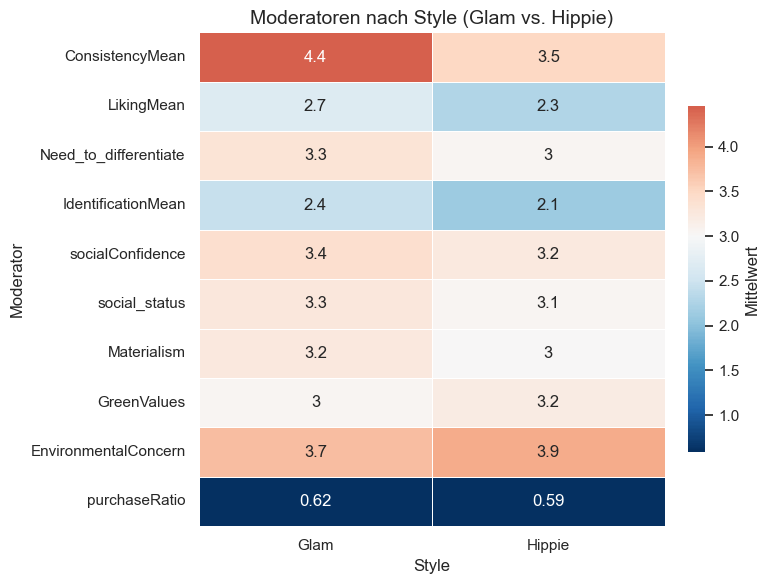

In [63]:
# Mittelwerte der Moderatoren gruppiert nach Style
df= pd.read_csv(experiment_path2)
moderators = [
    'ConsistencyMean',
        "LikingMean", 
    "Need_to_differentiate", 
    "IdentificationMean", 

    "socialConfidence", 
    "social_status",
    #'Altruism',
    'Materialism',
    'GreenValues',
    'EnvironmentalConcern',
    'purchaseRatio'
]

moderator_means_by_style = df[df['Style'].isin(['Glam', 'Hippie'])].groupby('Style')[moderators].mean().T

# Heatmap erzeugen
plt.figure(figsize=(8, 6))
sns.heatmap(
    moderator_means_by_style,
    annot=True,
    cmap='RdBu_r',
    center=3.0,
    linewidths=0.5,
    cbar_kws={"label": "Mittelwert", "shrink": 0.7, "pad": 0.04}
)
plt.title("Moderatoren nach Style (Glam vs. Hippie)", fontsize=14)
plt.xlabel("Style")
plt.ylabel("Moderator")
plt.tight_layout()
plt.show()


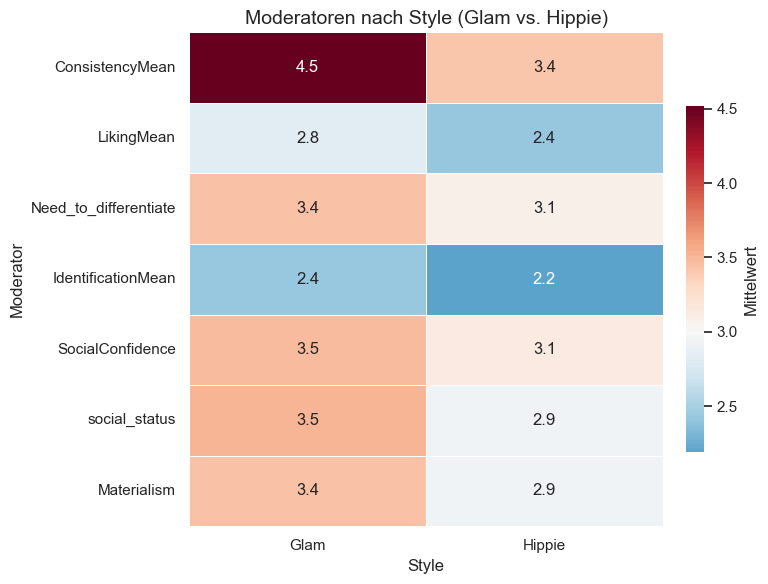

In [64]:
df= pd.read_csv(experiment_path1)
df['IdentificationMean'] = df[['IdentifikationPasst', 'IdentifikationIdentifizieren', 'IdentifikationMir']].mean(axis=1)
#f['IdentificationMean'].mean()
df['LikingMean'] = df[['LikingAn',	'LikingSchön',	'LikingGefällt']].mean(axis=1)
moderators = [
    'ConsistencyMean',
        "LikingMean", 
    "Need_to_differentiate", 
    "IdentificationMean", 
    "SocialConfidence", 
    "social_status",

    'Materialism',

    #'Scale_clean_up',

]
  

moderator_means_by_style = df[df['Style'].isin(['Glam', 'Hippie'])].groupby('Style')[moderators].mean().T

# Heatmap erzeugen
plt.figure(figsize=(8, 6))
sns.heatmap(
    moderator_means_by_style,
    annot=True,
    cmap='RdBu_r',
    center=3.0,
    linewidths=0.5,
    cbar_kws={"label": "Mittelwert", "shrink": 0.7, "pad": 0.04}
)
plt.title("Moderatoren nach Style (Glam vs. Hippie)", fontsize=14)
plt.xlabel("Style")
plt.ylabel("Moderator")
plt.tight_layout()
plt.show()
#'time_amount',  'collectedObjects',


## Proportions/ Verteilungstests

In [67]:
import pandas as pd
from scipy.stats import kstest, shapiro

# === Datei laden ===
file_path = experiment_path2
df = pd.read_csv(file_path)

# === Ergebnisse vorbereiten ===
normality_results = []

for column in df.columns:
    try:
        # In numerische Werte umwandeln, NaNs bleiben erhalten
        df[column] = pd.to_numeric(df[column], errors='coerce')
        data = df[column].dropna()

        # Nur testen, wenn mindestens 10 gültige Werte vorhanden sind
        if len(data) >= 5:
            # K-S-Test auf Normalverteilung mit Mittelwert und SD der Spalte
            ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))
            # Shapiro-Wilk-Test
            shapiro_stat, shapiro_p = shapiro(data)

            # Wenn einer der Tests p > 0.05 ergibt, dann aufnehmen
            if ks_p > 0.05 or shapiro_p > 0.05:
                normality_results.append({
                    'Variable': column,
                    'KolmogorovS': round(ks_p, 4),
                    'ShapiroW': round(shapiro_p, 4),
                    'Anzahl gültiger Werte': len(data)
                })

    except Exception as e:
        print(f"⚠️ Fehler bei Spalte {column}: {e}")
        continue

# === Ergebnisse als DataFrame anzeigen ===
results_df = pd.DataFrame(normality_results)

if not results_df.empty:
    print("\n Normalverteilte Variablen (p > 0.05 bei mind. einem Test):")
    print(results_df.sort_values(by="ShapiroW", ascending=False).reset_index(drop=True))
else:
    print("⚠️ Keine normalverteilten Variablen gefunden (p > 0.05).")



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/stats/_distn_infrastructure.py:2071: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)



 Normalverteilte Variablen (p > 0.05 bei mind. einem Test):
               Variable  KolmogorovS  ShapiroW  Anzahl gültiger Werte
0  Manipulation_check_4          NaN    1.0000                    490
1            Unnamed: 0       0.5595    0.0001                    150
2                    id       0.0761    0.0000                    490


# Deskriptive Statistik (central tendencys; measures of variance)

## Verhältnisse


In [ ]:
df = pd.read_csv(experiment_path1)

# Ergebnis-Datenframe erstellen
ergebnisse = []

# Kategorische Variablen
variablen = [ 'Deutschkenntnisse', 'PolitischeEinstellung']

for var in variablen:
    verteilung = df[var].value_counts(dropna=False).head(5).to_dict()
    ergebnisse.append({
        'Variable': var,
        'Typ': 'metrisch',
        'Mittelwert': round(df[var].mean(), 2),
        'Standardabweichung': round(df[var].std(), 2),
        'Verteilung':  ', '.join([f"{k}: {v}" for k, v in verteilung.items()])
    })

# In DataFrame umwandeln und anzeigen
statistik_df = pd.DataFrame(ergebnisse)
print(statistik_df)

In [ ]:
df_KT = pd.read_csv(experiment_path1)

# Funktion zur Anzeige der Kreuztabellen
def erstelle_kreuztabelle(df_KT, variable, ziel='Style'):
    kreuztabelle = pd.crosstab(df_KT[ziel], df_KT[variable], margins=True, margins_name='Total')
    print(f"\nKreuztabelle: {variable} vs. {ziel}; JS")
    print(kreuztabelle)

# Liste der Variablen, die ausgewertet werden sollen
variablen = ['Gender', 'Age', 'Deutschkenntnisse', 'PolitischeEinstellung']

# Schleife über alle Variablen
for var in variablen:
    erstelle_kreuztabelle(df_KT, var)

In [ ]:
df = pd.read_csv(experiment_path1)


# Nur diese Variablen sollen einbezogen werden
relevante_variablen = [
    "SelbssicherUnsicher", "MutigÄngstlich", "AuffäligUnauffälig", "ManipulativAufrichtig",
    "MächtigMachtlos", "ExclusivDurchschnitt", "begehrenswertNicht", "BewundertNicht",
    "PrivilegiertNicht", "WohlhabendNicht", "ÜberheblichDezent", "IntelligentSchlicht",
    "EigennützigUneigen", "VerschwenderischSpar", "MaterialistischIdealistisch",
    "SpirituellNicht", "NaturverbundenNaturfern", "AuthentischKünstlich", "EmpathischGefühlskalt",
    "RomantischNicht", "FriedlichAggressiv", "FreundlichUnfreundlich", "Scale_clean_up",
    "time_amount", "EnvironmentalConcern_3", "EnvironmentalConcern_2", "EnvironmentalConcern_1",
    "EnvironmentalConcern_4", "Alturism_3", "Alturism_2", "Alturism_1", "Alturism_4",
    "GreenValues_schaedigen", "GreenValues_kaufverhalten", "GreenValues_Massnahmen",
    "GreenValues_sorgen", "GreenValues_umweltbewusst", "GreenValues_Umweltauswirkungen",
    "Consistency_Uneinheitlich", "Consistency_Unharmonisch", "Manipulation_check_4",
    "IdentifikationPasst", "IdentifikationIdentifizieren", "IdentifikationMir",
    "LikingAn", "LikingSchön", "LikingGefällt", "HipHop", "RockMetal", "HippieBohoFestival",
    "Glam", "MCEnclothedCognition", "Kosten_Monat", "Kosten_Kleidung", "Deutschkenntnisse",
    "PolitischeEinstellung", "Age", "Choice_of_table_bar", "Choice_of_table_platz",
    "Choice_of_table_vip", "Choice_of_table_price", "Total_price", "social_status",
    "Materialism", "Need_to_differentiate", "IdentificationMean", "LikingMean",
    "ConsistencyMean", "Choice_of_table_numeric", "social_status_bedeutsam",
    "social_status_ueberlegen", "social_status__erfolgreich", "Materialism_3", "Materialism_2",
    "Materialism_1", "Materialism_4", "Need_to_differantiate_1", "Need_to_differantiate_2",
    "Need_to_differantiate_3", "EnvironmentalConcern", "Altruism", "GreenValues"
]



# Nur relevante Spalten selektieren (und vorhandene)
vorhandene_variablen = [var for var in relevante_variablen if var in df.columns]
df_subset = df[vorhandene_variablen]

# Deskriptive Statistiken berechnen
desc = df_subset.describe().T[["count", "mean", "std", "min", "max"]]
desc = desc.round(5)
desc.rename(columns={
    "count": "Obs",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "max": "Max"
}, inplace=True)

# Index als Spalte "Variable"
desc.reset_index(inplace=True)
desc.rename(columns={"index": "Variable"}, inplace=True)



# Export nach Excel
output_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025//deskriptive_statistikenES.xlsx'
desc.to_excel(output_path, index=False)

print(f"✅ Deskriptive Statistik gespeichert unter: {output_path}")

In [77]:
df = pd.read_csv(experiment_path2)

# Sicherstellen, dass number_of_items als numerisch erkannt wird
df["total_price"] = pd.to_numeric(df["total_price"], errors="coerce")

# Pivot-Tabelle: Durchschnittliche Anzahl an gekauften Items je Style × Condition × Store
pivot = df.pivot_table(
    values="total_price",
    index=["Style", "Condition"],
    columns="Store",
    aggfunc="mean"
)
# Ausgabe prüfen
print(pivot)

# Optional: in Excel exportieren
output_path = "/Users/caroline/Desktop/mean_number_of_items_per_group.xlsx"
pivot.to_excel(output_path)
print(f"Ergebnis gespeichert unter: {output_path}")

Store               BeachBar  ElectronicStore  JewelryStore
Style  Condition                                           
Glam   GlamHigh    27.036087       156.446364    898.705128
       HippieHigh  24.207692       108.975806    673.013889
       Neutral     18.118182       185.951786    784.195652
Hippie GlamHigh    25.013333       141.376154    705.022727
       HippieHigh  25.733462       121.862903    687.458333
       Neutral     19.238462       144.509259    642.209677
✅ Ergebnis gespeichert unter: /Users/caroline/Desktop/mean_number_of_items_per_group.xlsx


In [ ]:
import pandas as pd

# CSV-Datei laden (Pfad ggf. anpassen)
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/jsTotalPrice.csv')

# Sicherstellen, dass total_price als numerisch erkannt wird
df["total_price"] = pd.to_numeric(df["total_price"], errors="coerce")

# Gruppieren nach Style, Condition und Store und Mittelwert berechnen
grouped = df.groupby(["Style", "Condition", "Store"])["total_price"].mean().reset_index()

# Nach Store sortieren (optional auch nach Style/Condition, falls gewünscht)
grouped = grouped.sort_values(by=["Store", "Style", "Condition"])

# Ausgabe prüfen
print(grouped)

print(f"✅ Ergebnis gespeichert unter: {output_path}")
#  Glam  HippieHigh         BeachBar    43.900000 bei ihm 27,88; HH 28,13
#      Glam  HippieHigh     JewelryStore   661.680556 ; bei ihm 831

    Style   Condition         Store  total_price
0    Glam    GlamHigh  JewelryStore   864.756410
1    Glam  HippieHigh  JewelryStore   661.680556
2    Glam     Neutral  JewelryStore   715.586957
3  Hippie    GlamHigh  JewelryStore   677.022727
4  Hippie  HippieHigh  JewelryStore   676.875000
5  Hippie     Neutral  JewelryStore   598.274194
✅ Ergebnis gespeichert unter: /Users/caroline/Desktop/mean_number_of_items_per_group.xlsx


In [78]:
df = pd.read_csv(experiment_path2)

# Nur Preis-Spalten behalten
preis_spalten = [col for col in df.columns if col.endswith("_price")]

# Relevante Spalten extrahieren
df_filtered = df[["Condition"] + preis_spalten].copy()

# DataFrame in long-format bringen
df_long = df_filtered.melt(id_vars="Condition", var_name="Produkt", value_name="Preis")

# Mittelwert pro Produkt und Condition berechnen
produktpreise = df_long.groupby(["Produkt", "Condition"])["Preis"].mean().reset_index()

produktpreise

,Produkt,Condition,Preis
0,AirpodCase1_Glam_Men_price,GlamHigh,2.571429
1,AirpodCase1_Glam_Men_price,HippieHigh,2.582192
2,AirpodCase1_Glam_Men_price,Neutral,0.000000
3,AirpodCase1_Glam_Women_price,GlamHigh,0.937500
4,AirpodCase1_Glam_Women_price,HippieHigh,1.705882
...,...,...,...
637,non_congruent_price,HippieHigh,120.270977
638,non_congruent_price,Neutral,0.000000
639,total_price,GlamHigh,370.910629
640,total_price,HippieHigh,282.655000


Total Preise nach Conditions

In [79]:
df = pd.read_csv(experiment_path2)

# Sicherstellen, dass total_price als numerisch erkannt wird
df["total_price"] = pd.to_numeric(df["total_price"], errors="coerce")

# Gruppieren nach Style, Condition und Store und Mittelwert berechnen
grouped = df.groupby(["Style", "Condition", "Store"])["total_price", ].mean().reset_index()

# Nach Store sortieren (optional auch nach Style/Condition, falls gewünscht)
grouped = grouped.sort_values(by=["Store", "Style", "Condition"])

# Ausgabe prüfen
print(grouped)

     Style   Condition            Store  total_price
0     Glam    GlamHigh         BeachBar    27.036087
3     Glam  HippieHigh         BeachBar    24.207692
6     Glam     Neutral         BeachBar    18.118182
9   Hippie    GlamHigh         BeachBar    25.013333
12  Hippie  HippieHigh         BeachBar    25.733462
15  Hippie     Neutral         BeachBar    19.238462
1     Glam    GlamHigh  ElectronicStore   156.446364
4     Glam  HippieHigh  ElectronicStore   108.975806
7     Glam     Neutral  ElectronicStore   185.951786
10  Hippie    GlamHigh  ElectronicStore   141.376154
13  Hippie  HippieHigh  ElectronicStore   121.862903
16  Hippie     Neutral  ElectronicStore   144.509259
2     Glam    GlamHigh     JewelryStore   898.705128
5     Glam  HippieHigh     JewelryStore   673.013889
8     Glam     Neutral     JewelryStore   784.195652
11  Hippie    GlamHigh     JewelryStore   705.022727
14  Hippie  HippieHigh     JewelryStore   687.458333
17  Hippie     Neutral     JewelryStore   642.

# T Tests - Chi 2 test 

In [ ]:
df = pd.read_csv(experiment_path1)
df_cleaned = df[df['Total_price'] != '.']

# Konvertiere die Spalte Platzwahl_Geld in numerische Werte und ignoriere weitere Fehler
df_cleaned['Choice_of_pen_price'] = pd.to_numeric(df_cleaned['Choice_of_pen_price'], errors='coerce')

# Überprüfe, wie viele Werte nach der Konvertierung NaN sind
nan_count = df_cleaned['Choice_of_pen_price'].isna().sum()
print(f"Anzahl der NaN-Werte in Platzwahl_Geld nach Bereinigung: {nan_count}")

# Entferne verbleibende NaN-Werte
df_cleaned = df_cleaned.dropna(subset=['Choice_of_pen_price'])

# Gruppierung und deskriptive Statistik
grouped_stats = df_cleaned.groupby('Style_new')['Choice_of_pen_price'].describe()
print("Deskriptive Statistik nach StyleNummer:")
print(grouped_stats)

# Welch's T-Test durchführen
from scipy.stats import ttest_ind

# Werte für jede Gruppe
group_0 = df_cleaned[df_cleaned['Style_new'] == 0]['Choice_of_pen_price']
group_1 = df_cleaned[df_cleaned['Style_new'] == 1]['Choice_of_pen_price']

# Welch's T-Test
t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)
print(f"Welch's T-Test Ergebnis: t-statistic = {t_stat}, p-value = {p_value}")

2 Stichproben T Test für normal Verteilte Variablen 

In [ ]:
file_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-4_18.06.2025/ElectronicStore.csv'
data = pd.read_csv(file_path)

# === 2. T-Test-Funktion definieren ===
def perform_t_test(data, group_col, value_col, group1, group2):
    # Nur numerische Werte betrachten
    data = data[pd.to_numeric(data[value_col], errors='coerce').notnull()]

    # Daten pro Gruppe extrahieren
    group1_data = data[data[group_col] == group1][value_col].astype(float).dropna()
    group2_data = data[data[group_col] == group2][value_col].astype(float).dropna()

    # Optional: Levene-Test zur Prüfung auf Varianzhomogenität
    levene_stat, levene_p = levene(group1_data, group2_data)

    # Welch’s t-Test (robust bei ungleichen Varianzen)
    t_stat, p_value = ttest_ind(group1_data, group2_data, equal_var=False)

    return {
        f'{group1} Mean': group1_data.mean(),
        f'{group2} Mean': group2_data.mean(),
        'T-Statistic': t_stat,
        'P-Value': p_value,
        'Levene p': levene_p  # nur zur Info
    }

# === 3. Variablen definieren, die getestet werden sollen ===
columns_to_test = [
    'social_status', 
    'Need_to_differentiate', 
    'IdentificationMean',
    'LikingMean',
    'ConsistencyMean',
    'EnvironmentalConcern',
    'Materialism',
    'GreenValues',
    'socialConfidence'

]

# === 4. T-Tests durchführen und Ergebnisse sammeln ===
results = {
    col: perform_t_test(data, 'Style', col, 'Glam', 'Hippie')
    for col in columns_to_test
}

# === 5. Ergebnisse als DataFrame anzeigen ===
results_df = pd.DataFrame(results).T
results_df


,Glam Mean,Hippie Mean,T-Statistic,P-Value,Levene p
social_status,3.094017,3.122807,-0.239749,0.810858,0.040807
Need_to_differentiate,3.205128,3.043860,0.994138,0.321738,0.332356
IdentificationMean,2.354701,2.039474,1.881945,0.061841,0.006161
LikingMean,2.910256,2.478070,2.342236,0.020503,0.018456
ConsistencyMean,4.423077,3.585526,3.790752,0.000216,0.808916
EnvironmentalConcern,3.842949,3.805921,0.286793,0.774662,0.896798
Materialism,3.163462,3.046053,0.793690,0.428613,0.743605
GreenValues,3.104701,3.190789,-0.579364,0.563225,0.162519
socialConfidence,3.379487,3.336842,0.370053,0.711859,0.512773


In [83]:
file_path = experiment_path2
data = pd.read_csv(file_path)

# === 2. T-Test-Funktion definieren ===
def perform_t_test(data, group_col, value_col, group1, group2):
    # Nur numerische Werte betrachten
    data = data[pd.to_numeric(data[value_col], errors='coerce').notnull()]

    # Daten pro Gruppe extrahieren
    group1_data = data[data[group_col] == group1][value_col].astype(float).dropna()
    group2_data = data[data[group_col] == group2][value_col].astype(float).dropna()

    # Levene-Test zur Prüfung auf Varianzhomogenität
    levene_stat, levene_p = levene(group1_data, group2_data)

    # Welch’s t-Test
    t_stat, p_value = ttest_ind(group1_data, group2_data, equal_var=False)

    return {
        f'{group1} Mean': group1_data.mean(),
        f'{group2} Mean': group2_data.mean(),
        'T-Statistic': t_stat,
        'P-Value': p_value,
        'Levene p': levene_p
    }

# === 3. Allgemeine Variablen testen ===
columns_to_test = [
    'social_status', 
    'Need_to_differentiate', 
    'IdentificationMean',
    'LikingMean',
    'ConsistencyMean',
    'EnvironmentalConcern',
    'Materialism',
    'GreenValues',
    'socialConfidence'
]

results = {
    col: perform_t_test(data, 'Style', col, 'Glam', 'Hippie')
    for col in columns_to_test
}

results_df = pd.DataFrame(results).T
print("\n=== Allgemeiner Vergleich (Glam vs Hippie) ===")
print(results_df)

# === 4. SPEZIFISCHE Hypothese: total_price in Neutral-Condition ===
print("\n=== Spezifischer T-Test: total_price in Neutral-Condition ===")

df_neutral = data[data["Condition"] == "Neutral"]
glam = df_neutral[df_neutral["Style"] == "Glam"]["total_price"].astype(float).dropna()
hippie = df_neutral[df_neutral["Style"] == "Hippie"]["total_price"].astype(float).dropna()

t_stat, p_val = ttest_ind(glam, hippie, equal_var=False)

print(f"Glam Mean: {glam.mean():.2f}, Hippie Mean: {hippie.mean():.2f}")
print(f"T-Statistic = {t_stat:.4f}, P-Value = {p_val:.4f}")



=== Allgemeiner Vergleich (Glam vs Hippie) ===
                       Glam Mean  Hippie Mean  T-Statistic       P-Value  \
social_status           3.269333     3.052778     3.096249  2.075007e-03   
Need_to_differentiate   3.321333     3.043056     3.145085  1.761881e-03   
IdentificationMean      2.437333     2.118056     3.202194  1.453910e-03   
LikingMean              2.664000     2.279167     3.443331  6.243802e-04   
ConsistencyMean         4.448000     3.497917     7.411078  5.578671e-13   
EnvironmentalConcern    3.730000     3.882292    -2.117751  3.470704e-02   
Materialism             3.246000     3.001042     2.958730  3.239721e-03   
GreenValues             3.045333     3.194444    -1.879088  6.082820e-02   
socialConfidence        3.400800     3.240000     2.430301  1.544584e-02   

                       Levene p  
social_status          0.006953  
Need_to_differentiate  0.422219  
IdentificationMean     0.003097  
LikingMean             0.000776  
ConsistencyMean      

In [ ]:
# Reload necessary libraries and dataset after reset
import pandas as pd

# Load the dataset again
# Einlesen der CSV-Datei
file_path = "/Users/caroline/Downloads/Experiment Results-7/BB_Merged_C_T_BB.csv"
data = pd.read_csv(file_path)

import pandas as pd
from scipy.stats import ttest_ind

def perform_t_test(data, group_col, value_col, group1, group2):
    data = data[pd.to_numeric(data[value_col], errors='coerce').notnull()]

    group1_data = data[data[group_col] == group1][value_col].astype(float).dropna()
    group2_data = data[data[group_col] == group2][value_col].astype(float).dropna()

    t_stat, p_value = ttest_ind(group1_data, group2_data, equal_var=False)  # Welch's t-test

    return {
        f'{group1} Mean': group1_data.mean(),
        f'{group2} Mean': group2_data.mean(),
        'T-Statistic': t_stat,
        'P-Value': p_value
    }

# Filter rows where study == "new"
#filtered_data = data[data['study'] == 'new']

# Columns to analyze
columns_to_test = [

  'Scale_clean_up',
    'Materialism', 
    'SocialConfidence', 
    'time_amount',
    'Alturism_1',
    'GreenValues_umweltbewusst',

   

]
# Perform t-tests for each column
results = {}
for column in columns_to_test:
    results[column] = perform_t_test(data, 'Style', column, 'Glam', 'Hippie')

# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(results).T

results_df

,Glam Mean,Hippie Mean,T-Statistic,P-Value
Scale_clean_up,3.305556,3.807692,-1.716178,0.091611
Materialism,NaN,NaN,NaN,NaN
SocialConfidence,NaN,NaN,NaN,NaN
time_amount,22.805556,28.230769,-1.106966,0.274153
Alturism_1,2.388889,2.423077,-0.101742,0.919383
GreenValues_umweltbewusst,3.111111,3.384615,-1.083719,0.283646


In [ ]:
data = pd.read_csv(experiment_path1)

# Relevante Variablen definieren
group_col = 'Style'  # Spalte mit den Gruppen (Glam vs. Hippie)
columns_to_test = ['Scale_clean_up', 'time_amount', 'GreenValues_umweltbewusst', 
                   'Materialism', 'SocialConfidence']
moderator_variables = ['Need_to_differentiate', 'Materialism']  # Potenzielle Moderatoren

#  Funktion zur Durchführung des T-Tests
def perform_t_test(data, group_col, value_col, group1, group2):
    # Konvertiere die Spalte in numerische Werte und entferne NaN-Werte
    data = data[pd.to_numeric(data[value_col], errors='coerce').notnull()]
    
    group1_data = data[data[group_col] == group1][value_col].astype(float).dropna()
    group2_data = data[data[group_col] == group2][value_col].astype(float).dropna()
    
    #  Welch's T-Test (berücksichtigt ungleiche Varianzen)
    t_stat, p_value = ttest_ind(group1_data, group2_data, equal_var=False)  
    
    #  Einseitiger Test (nur falls Differenz negativ)
    one_sided_p_value = p_value / 2 if t_stat < 0 else 1 - (p_value / 2)

    return {
        f'{group1} Mean': group1_data.mean(),
        f'{group2} Mean': group2_data.mean(),
        'T-Statistic': t_stat,
        'P-Value (Zweiseitig)': p_value,
        'P-Value (Einseitig)': one_sided_p_value
    }

#  T-Tests für alle relevanten Spalten durchführen
results = {}
for column in columns_to_test:
    results[column] = perform_t_test(data, group_col, column, 'Glam', 'Hippie')

# Ergebnisse als DataFrame anzeigen
results_df = pd.DataFrame(results).T
print("\n=== T-TEST ERGEBNISSE ===\n")
print(results_df)

#  Gruppenverteilung und Stichproben-Check
print("\n=== Gruppenverteilung ===\n")
print(data[group_col].value_counts())

for col in columns_to_test:
    print(f"\n=== Deskriptive Statistiken für {col} ===\n")
    print(data[col].describe())

#  Moderationseffekte testen mit Regressionen
print("\n=== Moderationsanalysen ===\n")
for moderator in moderator_variables:
    print(f"\n----- Moderationseffekt: {moderator} -----\n")
    formula = f"Scale_clean_up ~ Style * {moderator}"  # Interaktionsmodell
    model = smf.ols(formula, data=data).fit()
    print(model.summary())


Whitney Mann Test for all experiment types 


In [89]:
from scipy.stats import mannwhitneyu
data = pd.read_csv(experiment_path1)

# Columns to exclude
columns_to_exclude = [
    'id', 'N', #'SocialConfidence', 'Materialism', 'Zubehör_19_combined'
]

# Get the remaining columns
remaining_columns = [col for col in data.columns if col not in columns_to_exclude]

# !!!!!
# Display the remaining columns => to define variables for the tests 
print(remaining_columns)

# Variables to test
variables_to_test = [
 'experiment', 'date', 'MatrikelNummer', 'Gender', 'Name', 'Style', 'HairColor', 'SkinTone', 'AssignedAvatar', 'Situation1Decision', 'SelbssicherUnsicher', 'MutigÄngstlich', 'AuffäligUnauffälig', 'ManipulativAufrichtig', 'MächtigMachtlos', 'ExclusivDurchschnitt', 'begehrenswertNicht', 'BewundertNicht', 'PrivilegiertNicht', 'WohlhabendNicht', 'ÜberheblichDezent', 'IntelligentSchlicht', 'EigennützigUneigen', 'VerschwenderischSpar', 'MaterialistischIdealistisch', 'SpirituellNicht', 'NaturverbundenNaturfern', 'AuthentischKünstlich', 'EmpathischGefühlskalt', 'RomantischNicht', 'FriedlichAggressiv', 'FreundlichUnfreundlich', 'MessageFriendShoppingOrVacation', 'Scale_Perceived_social_status_Question_2_Ich_fühle_mich_erfolgreich', 'Scale_Perceived_social_status_Question_3_Ich_fühle_mich_bedeutsam', 'Scale_Perceived_social_status_Question_1_Ich_fühle_mich_anderen_überlegen', 'Scale_Self-Congruity_Question_3_Menschen_die_sich_so_kleiden_würden_dieses_Stück_wählen', 'Scale_Self-Congruity_Question_1_Passt_dazu_wie_ich_mich_im_Outfit_sehe', 'Scale_Self-Congruity_Question_5_Menschen_die_sich_so_kleiden_würden_dieses_Stück_wählen', 'Scale_Self-Congruity_Question_2_Spiegelt_wieder_wer_ich_in_der_Kleidung_bin', 'Scale_Self-Congruity_Question_4_Menschen_die_sich_so_kleiden_würden_dieses_Stück_wählen ', 'Scale_Materialism_1', 'Scale_Materialism_2', 'Scale_Materialism_3', 'Scale_Materialism_4', 'Scale_Need_to_differantiate_1', 'Scale_Need_to_differantiate_2', 'Scale_Need_to_differantiate_3', 'WieWirktOutfitAufSieUneinheitlichEinheitlich', 'WieWirktOutfitAufSieHarmonischUnharmonisch', 'KlickenSieDie4An', 'StilDesOutfitsPasstZuMir', 'IdentifikationMitStilDesOutfits', 'OutfitWecktAssoziationenDieZuMirPassen', 'OutfitSprichtMichAn', 'IchFindeOutfitSchön', 'StilDesOutfitsGefälltMir', 'StilPasstZuHipHop', 'StilPasstZuPunkRockMetal', 'StilPasstZuHippieBohoFestival', 'StilPasstZuGlam', 'WieSchwerInDiesemOutfitVorzustellen', 'GeldProMonat', 'GeldProMonatKleidung', 'DeutschkenntnisseGutSchlecht', 'PolitischeEinstellung1Links11Rechts', 'Age', 'Unnamed: 65', 'Unnamed: 64'
]
# Filter data for the groups
group1 = data[data['Style'] == 'Glam']
group2 = data[data['Style'] == 'Hippie']

# Perform Mann-Whitney-U test for each variable
results = []
for variable in variables_to_test:
    # Ensure the data for the variable is numeric and drop NA values
    try:
        group1_data = pd.to_numeric(group1[variable], errors='coerce').dropna()
        group2_data = pd.to_numeric(group2[variable], errors='coerce').dropna()

        # Perform the Mann-Whitney U test
        stat, p = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
        results.append({
            'Variable': variable,
            #'Glam Median': group1_data.median(),
            #'Hippie Median': group2_data.median(),
            'U-Statistic': stat,
            'P-Value': p
        })
    except Exception as e:
        # Handle any errors (e.g., if data cannot be compared)
        results.append({
            'Variable': variable,
            #'Error': str(e)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)



# Setze die Pandas-Optionen für die Anzeige
pd.set_option('display.max_rows', None)  # Zeigt alle Zeilen an
pd.set_option('display.max_columns', None)  # Zeigt alle Spalten an
pd.set_option('display.width', None)  # Entfernt die Begrenzung der Spaltenbreite
pd.set_option('display.max_colwidth', None)  # Zeigt Inhalte in voller Länge

# DataFrame ausgeben
print(results_df)

# (Optional) Zurücksetzen der Optionen nach der Anzeige
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')



['study', 'experiment', 'MatrikelNummer', 'Gender', 'Name', 'Style', 'HairColor', 'SkinTone', 'AssignedAvatar', 'HairLength', 'BeardLength', 'AvatarGLB', 'Choice_of_table', 'SelbssicherUnsicher', 'MutigÄngstlich', 'AuffäligUnauffälig', 'ManipulativAufrichtig', 'MächtigMachtlos', 'ExclusivDurchschnitt', 'begehrenswertNicht', 'BewundertNicht', 'PrivilegiertNicht', 'WohlhabendNicht', 'ÜberheblichDezent', 'IntelligentSchlicht', 'EigennützigUneigen', 'VerschwenderischSpar', 'MaterialistischIdealistisch', 'SpirituellNicht', 'NaturverbundenNaturfern', 'AuthentischKünstlich', 'EmpathischGefühlskalt', 'RomantischNicht', 'FriedlichAggressiv', 'FreundlichUnfreundlich', 'Scale_clean_up', 'time_amount', 'EnvironmentalConcern_3', 'EnvironmentalConcern_2', 'EnvironmentalConcern_1', 'EnvironmentalConcern_4', 'Alturism_3', 'Alturism_2', 'Alturism_1', 'Alturism_4', 'GreenValues_schaedigen', 'GreenValues_kaufverhalten', 'GreenValues_Massnahmen', 'GreenValues_sorgen', 'GreenValues_umweltbewusst', 'GreenVa

Beach  Bar preliminary

In [ ]:
# Entferne Zeilen, in denen ein Punkt (.) in der Spalte Platzwahl_Geld vorkommt
df_cleaned = df[df['Choice_of_table_price'] != '.']

# Konvertiere die Spalte Platzwahl_Geld in numerische Werte und ignoriere weitere Fehler
df_cleaned['Choice_of_table_price'] = pd.to_numeric(df_cleaned['Choice_of_table_price'], errors='coerce')

# Überprüfe, wie viele Werte nach der Konvertierung NaN sind
nan_count = df_cleaned['Choice_of_table_price'].isna().sum()
print(f"Anzahl der NaN-Werte in Platzwahl_Geld nach Bereinigung: {nan_count}")

# Entferne verbleibende NaN-Werte
df_cleaned = df_cleaned.dropna(subset=['Choice_of_table_price'])

# Gruppierung und deskriptive Statistik
grouped_stats = df_cleaned.groupby('Style_new')['Choice_of_table_price'].describe()
print("Deskriptive Statistik nach StyleNummer:")
print(grouped_stats)

# Welch's T-Test durchführen
from scipy.stats import ttest_ind

# Werte für jede Gruppe
group_0 = df_cleaned[df_cleaned['Style_new'] == 0]['Choice_of_table_price']
group_1 = df_cleaned[df_cleaned['Style_new'] == 1]['Choice_of_table_price']

# Welch's T-Test
t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)
print(f"Welch's T-Test Ergebnis: t-statistic = {t_stat}, p-value = {p_value}")



Anzahl der NaN-Werte in Platzwahl_Geld nach Bereinigung: 0
Deskriptive Statistik nach StyleNummer:
           count        mean         std  min  25%    50%    75%     max
Style_new                                                               
0.0        107.0   86.915888  187.377186  0.0  0.0    0.0  100.0  1000.0
1.0        130.0  283.076923  367.716284  0.0  0.0  100.0  300.0  1000.0
Welch's T-Test Ergebnis: t-statistic = -5.303101997249277, p-value = 3.0138570543139776e-07


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_1258/154906591.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Choice_of_table_price'] = pd.to_numeric(df_cleaned['Choice_of_table_price'], errors='coerce')


In [ ]:
import scipy.stats as stats
import numpy as np

# Annahme: df ist der DataFrame mit den Spalten 'Platzwahl_Geld' und 'StyleNummer'

# Filter die Werte für die Gruppen
group_0 = df[df['Style_new'] == 0]['Choice_of_table_price']
group_1 = df[df['Style_new'] == 1]['Choice_of_table_price']

# Konvertiere die Daten in numerische Werte und entferne NaN-Werte
group_0 = pd.to_numeric(group_0, errors='coerce').dropna()
group_1 = pd.to_numeric(group_1, errors='coerce').dropna()

# Welch-T-Test durchführen (einseitig, alternative="less")
t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

# Da der Welch-Test in Python standardmäßig zweiseitig ist, halbiere den p-Wert für eine einseitige Hypothese
p_value_one_sided = p_value / 2 if t_stat < 0 else 1 - (p_value / 2)

# Ergebnisse anzeigen
print(f"Welch's T-Test Ergebnis:")
print(f"t-statistic = {t_stat}")
print(f"p-value (one-sided) = {p_value_one_sided}")

# Berechnung des 95%-Konfidenzintervalls für den Unterschied der Mittelwerte
mean_diff = np.mean(group_0) - np.mean(group_1)
std_err = np.sqrt(np.var(group_0, ddof=1) / len(group_0) + np.var(group_1, ddof=1) / len(group_1))
ci_lower = mean_diff - 1.96 * std_err
ci_upper = mean_diff + 1.96 * std_err

print(f"95% confidence interval: ({ci_lower}, {ci_upper})")
print(f"mean in group 0 = {np.mean(group_0)}, mean in group 1 = {np.mean(group_1)}")


Welch's T-Test Ergebnis:
t-statistic = -5.303101997249277
p-value (one-sided) = 1.5069285271569888e-07
95% confidence interval: (-268.66117368188833, -123.66089677102326)
mean in group 0 = 86.91588785046729, mean in group 1 = 283.0769230769231


In [91]:
data = pd.read_csv(experiment_path1)

# Define the function to calculate chi-square statistics and prepare the result table
def chi_square_analysis(data, feature_col, group_col):
    results = []
    choices = data[feature_col].dropna().unique()
    
    for choice in choices:
        # Create a contingency table for the given choice
        contingency_table = pd.crosstab(data[feature_col] == choice, data[group_col])
        
        # Perform the chi-square test
        chi2, p, _, _ = chi2_contingency(contingency_table)
        
        # Gather the results
        glam_count = contingency_table.loc[True, 'Glam'] if 'Glam' in contingency_table.columns else 0
        hippie_count = contingency_table.loc[True, 'Hippie'] if 'Hippie' in contingency_table.columns else 0
        total = glam_count + hippie_count
        glam_percentage = round(glam_count / total * 100, 1) if total > 0 else 0
        hippie_percentage = round(hippie_count / total * 100, 1) if total > 0 else 0
        
        results.append({
            "Feature": feature_col,
            "Choice": choice,
            "Glam (Count, %)": f"{glam_count} ({glam_percentage}%)",
            "Hippie (Count, %)": f"{hippie_count} ({hippie_percentage}%)",
            "Total (Count, %)": f"{total} ({round(total / len(data) * 100, 1)}%)",
            "Chi-Square Statistic": round(chi2, 3),
            "p": round(p, 3)
        })
    
    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)
    return results_df

# Perform chi-square analysis for 'Choice_of_table_price' grouped by 'Style'
# Ensure column names match the dataset


# Filter the dataset to include only rows where experiment == 'V_JS'
#filtered_data = data[data['study'] == 'new']

# Perform chi-square analysis for 'Choice_of_pen' grouped by 'Style_new' on the filtered data
filtered_result_table = chi_square_analysis(data, 'Smart_watch_decision', 'Style')

# Display the resulting table
filtered_result_table

,Feature,Choice,"Glam (Count, %)","Hippie (Count, %)","Total (Count, %)",Chi-Square Statistic,p
0,Smart_watch_decision,1.0,12 (63.2%),7 (36.8%),19 (5.1%),0.495,0.482
1,Smart_watch_decision,2.0,6 (60.0%),4 (40.0%),10 (2.7%),0.022,0.881
2,Smart_watch_decision,0.0,5 (31.2%),11 (68.8%),16 (4.3%),2.245,0.134


In [ ]:
df = pd.read_csv(experiment_path1)
#df = df[df["study"] == "new"]

# Ergebnisse des Kolmogorov-Smirnov-Tests speichern
normality_results = {}

# Iteration durch alle numerischen Spalten
for column in df.columns:
    try:
        # Konvertiere die Spalte in numerische Werte
        df[column] = pd.to_numeric(df[column], errors='coerce')
        
        # Filtere nur die Zeilen, bei denen "study" == "new"
        
        data = df[column].dropna()
        
        if len(data) > 1:  # Test nur für Spalten mit genügend Werten
            # Kolmogorov-Smirnov-Test
            stat, p = kstest(data, 'norm', args=(data.mean(), data.std()))
            normality_results[column] = {"Teststatistik": stat, "p-Wert": p}
    except Exception as e:
        normality_results[column] = {"Fehler": str(e)}

# Konvertiere die Ergebnisse in einen DataFrame
result_df = pd.DataFrame(normality_results).T

# Setze die Pandas-Optionen für die Anzeige
pd.set_option('display.max_rows', None)  # Zeigt alle Zeilen an
pd.set_option('display.max_columns', None)  # Zeigt alle Spalten an
pd.set_option('display.width', None)  # Entfernt die Begrenzung der Spaltenbreite
pd.set_option('display.max_colwidth', None)  # Zeigt Inhalte in voller Länge

# DataFrame ausgeben
print(result_df)

# (Optional) Zurücksetzen der Optionen nach der Anzeige
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

                                  Teststatistik        p-Wert
id                                     0.059706  6.245915e-01
N                                      0.088632  1.701396e-01
MatrikelNummer                         0.524408  1.846351e-39
HairColor                              0.200995  6.793419e-06
SkinTone                               0.315380  5.013822e-14
SelbssicherUnsicher                    0.256884  2.165135e-09
MutigÄngstlich                         0.256428  2.331381e-09
AuffäligUnauffälig                     0.230139  1.318311e-07
ManipulativAufrichtig                  0.196592  1.174564e-05
MächtigMachtlos                        0.175831  1.313456e-04
ExclusivDurchschnitt                   0.179725  8.528770e-05
begehrenswertNicht                     0.192010  2.049370e-05
BewundertNicht                         0.186068  4.134175e-05
PrivilegiertNicht                      0.204228  4.507698e-06
WohlhabendNicht                        0.186413  3.971391e-05
Überhebl

# Regression

Multiple Linear Regression analysis with controls


binomial regression on buying descisions => Beach Bar on Table options

In [98]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv(experiment_path1)

#  Sicherstellen, dass Kaufvariablen für alle Tischtypen binär sind (0/1)
tisch_variablen = ['Choice_of_table_bar', 'Choice_of_table_platz', 'Choice_of_table_vip']  # Kaufentscheidungen für die 3 Tischtypen
df[tisch_variablen] = df[tisch_variablen].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=tisch_variablen)  # Fehlende Werte entfernen

#  Unabhängige Variablen für das Modell
independent_vars = ['LikingMean', 'Age', 'Kosten_Monat', 'Kosten_Kleidung', 'PolitischeEinstellung']

#Kontrollvariablen hinzufügen
control_vars = ['Gender_new', 'Deutschkenntnisse', 'IdentificationMean']
independent_vars_with_controls = independent_vars + control_vars

# Ergebnisse speichern
results = []

# Logistische Regression für jeden Tischtyp
for tisch in tisch_variablen:
    print(f"\n===== Logistische Regression für {tisch} =====\n")
    
    # Definiere X und y
    X = df[independent_vars_with_controls]
    X = sm.add_constant(X)  # Intercept hinzufügen
    y = df[tisch]
    
    #  Modell fitten
    logit_model = sm.Logit(y, X).fit()
    
    # Ergebnisse ausgeben
    print(logit_model.summary())
    
    # Odds Ratios berechnen
    odds_ratios = np.exp(logit_model.params)
    print("\nOdds Ratios:")
    print(odds_ratios)
    
    # Modellbewertung: Konfusionsmatrix und Genauigkeit
    y_pred = logit_model.predict(X) > 0.5  # Schwellenwert = 0.5
    print("\nKonfusionsmatrix:")
    print(confusion_matrix(y, y_pred))
    print("\nKlassifikationsbericht:")
    print(classification_report(y, y_pred))
    
    #AIC/BIC & ROC-AUC berechnen
    y_pred_probs = logit_model.predict(X)
    auc = roc_auc_score(y, y_pred_probs)
    
    print(f"AIC: {logit_model.aic}, BIC: {logit_model.bic}")
    print(f"ROC AUC: {auc:.3f}")
    
    # Ergebnisse speichern
    results.append({
        'Tischtyp': tisch,
        'AIC': logit_model.aic,
        'BIC': logit_model.bic,
        'ROC AUC': auc,
        'Pseudo R²': logit_model.prsquared
    })

# Ergebnisse als DataFrame anzeigen
results_df = pd.DataFrame(results)
print("\n===== Modellvergleich =====")
print(results_df)



===== Logistische Regression für Choice_of_table_bar =====

Optimization terminated successfully.
         Current function value: 0.539557
         Iterations 6
                            Logit Regression Results                           
Dep. Variable:     Choice_of_table_bar   No. Observations:                  186
Model:                           Logit   Df Residuals:                      177
Method:                            MLE   Df Model:                            8
Date:                 Mon, 11 Aug 2025   Pseudo R-squ.:                  0.1044
Time:                         23:23:25   Log-Likelihood:                -100.36
converged:                        True   LL-Null:                       -112.05
Covariance Type:             nonrobust   LLR p-value:                  0.002895
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const            

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

binomial regression on buying descisions => Jewelery Store on Watch options

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv(experiment_path1)
#  Sicherstellen, dass Kaufvariablen binär sind (0/1)
kauf_variablen = ['Smart_Watch_basic', 'Smart_Watch_premium', 'Smart_Watch_hermes']
df[kauf_variablen] = df[kauf_variablen].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=kauf_variablen)  # Fehlende Werte entfernen

# Unabhängige Variablen für das Modell
independent_vars = ['LikingMean', 'Age', 'Kosten_Monat', 'Kosten_Kleidung', 'PolitischeEinstellung']
control_vars = ['Gender_new', 'Deutschkenntnisse', 'IdentificationMean']

existing_columns = df.columns.tolist()
independent_vars_with_controls = [col for col in (independent_vars + control_vars) if col in existing_columns]

print(f"Verwendete unabhängige Variablen: {independent_vars_with_controls}")

results = []

# logistische Regression für jeden Produkttyp
for watch in kauf_variablen:
    print(f"\n===== Logistische Regression für {watch} =====\n")
    
    # Sicherstellen, dass die Zielvariable numerisch ist
    df[watch] = pd.to_numeric(df[watch], errors='coerce')
    df = df.dropna(subset=[watch])

    if len(independent_vars_with_controls) == 0:
        print(f"⚠️ Keine gültigen unabhängigen Variablen für {watch}. Überspringe diese Analyse.")
        continue

    # Definiere X und y
    X = df[independent_vars_with_controls]
    X = sm.add_constant(X)  # Intercept hinzufügen
    y = df[watch]

    
    #print("\nÜberprüfung auf fehlende oder unendliche Werte in X:")
    #print(X.isnull().sum())
    
    # Bereinigung: Entferne NaN- und Inf-Werte
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    y = y.loc[X.index]  # `y` auf dieselben Zeilen wie `X` setzen

    try:
        # Modell fitten
        logit_model = sm.Logit(y, X).fit()
        
        # Ergebnisse ausgeben
        print(logit_model.summary())
        
        # Odds Ratios berechnen
        odds_ratios = np.exp(logit_model.params)
        print("\nOdds Ratios:")
        print(odds_ratios)
        
        # Modellbewertung: Konfusionsmatrix und Genauigkeit
        y_pred = logit_model.predict(X) > 0.5
        print("\nKonfusionsmatrix:")
        print(confusion_matrix(y, y_pred))
        print("\nKlassifikationsbericht:")
        print(classification_report(y, y_pred))
        
        # AIC/BIC & ROC-AUC berechnen
        y_pred_probs = logit_model.predict(X)
        auc = roc_auc_score(y, y_pred_probs)
        
        print(f"AIC: {logit_model.aic}, BIC: {logit_model.bic}")
        print(f"ROC AUC: {auc:.3f}")
        
        #  Ergebnisse speichern
        results.append({
            'Produkttyp': watch,
            'AIC': logit_model.aic,
            'BIC': logit_model.bic,
            'ROC AUC': auc,
            'Pseudo R²': logit_model.prsquared
        })
    
    except Exception as e:
        print(f"⚠️ Fehler bei der Analyse von {watch}: {e}")

# Ergebnisse als DataFrame anzeigen
results_df = pd.DataFrame(results)
print("\n===== Modellvergleich =====")
print(results_df)


Verwendete unabhängige Variablen: ['LikingMean', 'Age', 'Kosten_Monat', 'Kosten_Kleidung', 'PolitischeEinstellung', 'Gender_new', 'Deutschkenntnisse', 'IdentificationMean']

===== Logistische Regression für Smart_Watch_basic =====

Optimization terminated successfully.
         Current function value: 0.529975
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:      Smart_Watch_basic   No. Observations:                   44
Model:                          Logit   Df Residuals:                       35
Method:                           MLE   Df Model:                            8
Date:                Sat, 01 Feb 2025   Pseudo R-squ.:                  0.1915
Time:                        13:18:50   Log-Likelihood:                -23.319
converged:                       True   LL-Null:                       -28.841
Covariance Type:            nonrobust   LLR p-value:                    0.1992
                            coef  

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Daten laden
df = pd.read_csv(experiment_path1)

# Sicherstellen, dass Kaufvariablen binär sind (0/1)
kauf_variablen = ['pen_basic', 'pen_premium', 'pen_hermes']
df[kauf_variablen] = df[kauf_variablen].apply(pd.to_numeric, errors='coerce')

# Unabhängige Variablen für das Modell
independent_vars = ['LikingMean', 'Age', 'GeldProMonat', 'GeldProMonatKleidung', 'PolitischeEinstellung1Links11Rechts']
control_vars = ['Gender_new', 'DeutschkenntnisseGutSchlecht', 'IdentificationMean']

# Überprüfen, ob Spalten existieren
existing_columns = df.columns.tolist()
independent_vars_with_controls = [col for col in (independent_vars + control_vars) if col in existing_columns]

print(f"✅Verwendete unabhängige Variablen: {independent_vars_with_controls}")

#  Sicherstellen, dass alle unabhängigen Variablen numerisch sind
df[independent_vars_with_controls] = df[independent_vars_with_controls].apply(pd.to_numeric, errors='coerce')

# Ergebnisse speichern
results = []

#  Logistische Regression für jeden Produkttyp
for pen in kauf_variablen:
    print(f"\n===== Logistische Regression für {pen} =====\n")
    
    # Zielvariable numerisch setzen & fehlende Werte entfernen
    df[pen] = pd.to_numeric(df[pen], errors='coerce')
    df = df.dropna(subset=[pen])

    if len(independent_vars_with_controls) == 0:
        print(f"⚠️ Keine gültigen unabhängigen Variablen für {pen}. Überspringe diese Analyse.")
        continue

    #  Definiere X und y
    X = df[independent_vars_with_controls].copy()
    X = sm.add_constant(X)  # Intercept hinzufügen
    y = df[pen]

    # Überprüfung: Falls nur eine Klasse in y vorhanden ist -> Kein Modell möglich
    if y.nunique() < 2:
        print(f"⚠️ Nur eine Klasse vorhanden in {pen} - Regression nicht möglich.")
        continue

    #  Bereinigung: Entferne NaN- und Inf-Werte
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    y = y.loc[X.index]  # `y` auf dieselben Zeilen wie `X` setzen

    try:
        #  Modell fitten
        logit_model = sm.Logit(y, X).fit()
        
        # Ergebnisse ausgeben
        print(logit_model.summary())
        
        # Odds Ratios berechnen
        odds_ratios = np.exp(logit_model.params)
        print("\n Odds Ratios:")
        print(odds_ratios)
        
        # Modellbewertung: Konfusionsmatrix und Genauigkeit
        y_pred = logit_model.predict(X) > 0.5
        print("\n Konfusionsmatrix:")
        print(confusion_matrix(y, y_pred))
        print("\n Klassifikationsbericht:")
        print(classification_report(y, y_pred))
        
        # AIC/BIC & ROC-AUC berechnen
        y_pred_probs = logit_model.predict(X)
        auc = roc_auc_score(y, y_pred_probs)
        
        print(f" AIC: {logit_model.aic}, BIC: {logit_model.bic}")
        print(f" ROC AUC: {auc:.3f}")
        
        # Ergebnisse speichern
        results.append({
            'Produkttyp': pen,
            'AIC': logit_model.aic,
            'BIC': logit_model.bic,
            'ROC AUC': auc,
            'Pseudo R²': logit_model.prsquared
        })
    
    except Exception as e:
        print(f"⚠️ Fehler bei der Analyse von {pen}: {e}")

# Ergebnisse als DataFrame anzeigen
results_df = pd.DataFrame(results)
print("\n=====  Modellvergleich =====")
print(results_df)



✅ Verwendete unabhängige Variablen: ['LikingMean', 'Age', 'GeldProMonat', 'GeldProMonatKleidung', 'PolitischeEinstellung1Links11Rechts', 'Gender_new', 'DeutschkenntnisseGutSchlecht', 'IdentificationMean']

===== Logistische Regression für pen_basic =====

Optimization terminated successfully.
         Current function value: 0.558037
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              pen_basic   No. Observations:                  143
Model:                          Logit   Df Residuals:                      134
Method:                           MLE   Df Model:                            8
Date:                Mon, 03 Feb 2025   Pseudo R-squ.:                  0.1434
Time:                        12:17:30   Log-Likelihood:                -79.799
converged:                       True   LL-Null:                       -93.159
Covariance Type:            nonrobust   LLR p-value:                 0.0007903
          

In [ ]:
# Studie 2
df = pd.read_csv(experiment_path2)

# Funktion zur Durchführung einer Moderationsanalyse
def run_moderation_analysis(store, condition, gender=None, style=None):
    # Subsetting nach Store und Condition
    subset = df[(df['Store'] == store) & (df['Condition'] == condition)]

    if gender is not None:
        subset = subset[subset['Gender_new'] == gender]  # 1 = männlich, 0 = weiblich

    if style is not None:
        subset = subset[subset['Style_new'] == style]    # 1 = Glam, 0 = Hippie

    print(f"\nAnalyse für Store: {store}, Condition: {condition}, Gender: {gender}, Style: {style}")

    # Regression: Interaktion total_price * Style
    try:
        model = smf.ols('productsBought ~ total_price * Style_new', data=subset).fit()
        print(model.summary())
    except Exception as e:
        print(f"Fehler bei der Modellschätzung: {e}")

# Beispielaufrufe:
# 1. Moderation per Store per Condition
run_moderation_analysis('BeachBar', 'Neutral')

# 2. Moderation per Store per Condition per Gender
run_moderation_analysis('ElectronicStore', 'GlamHigh', gender=1)  # nur Männer

# 3. Moderation per Store per Condition per Style
df['Style_new'] = df['Style_new'].fillna(0)  # sicherstellen, dass Style_new vorhanden ist
run_moderation_analysis('JewelryStore', 'HippieHigh', style=0)     # nur Hippie

# Optional: Kongruenz-Indizes vorberechnen (Platzhalter, falls Spalten existieren)
# df['congruence_diff_price'] = df['congruent_price'] - df['noncongruent_price']
# df['congruence_diff_products'] = df['congruent_products'] - df['noncongruent_products']

In [ ]:

from pathlib import Path
from itertools import product
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------------------
# 1) Pfad zur Quelldatei anpassen, falls nötig
# ------------------------------------------------------------
DATA_PATH = Path('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/ESCongruent.csv')      # <–– hier ggf. Pfad anpassen
OUT_PATH  = Path('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/ESModerationn.csv')

# ------------------------------------------------------------
# 2) Daten laden & aufbereiten
# ------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
for col in ["Condition", "Style", "Gender"]:
    df[col] = df[col].astype(str).str.strip()

gender_map = {"female": 0.0, "male": 1.0}

# ----------------------------------------------------------------------
# 3) Analyse-Funktion (Dummy-Regression mit HC3-SE)
# ----------------------------------------------------------------------
def summarize(mask: pd.Series,
              condition: str,
              moderator: str,
              subgruppe: str,
              dv: str) -> dict:
    """
    mask      – bool-Series (True = Teilstichprobe)
    dv        – Zielvariable (total_price, productsBought, congruent_price)
    """
    D = mask.astype(float).rename("Group")
    X = sm.add_constant(D)
    model  = sm.OLS(df[dv], X).fit()
    robust = model.get_robustcov_results("HC3")  # Welch-äquivalent

    return {
        "Condition": condition,
        "Moderator": moderator,
        "Subgruppe": subgruppe,
        "DV": dv,
        "R2": round(model.rsquared, 6),
        "coef": robust.params[1],   # Δ-Mittelwert (Originaleinheit)
        "p":    robust.pvalues[1],
        "n":    int(mask.sum()),
        # Kontext: Mittelwerte (optional, gern erweitern / kürzen)
        "mean_total_price":     df.loc[mask, "total_price"].mean(),
        "mean_productsBought":  df.loc[mask, "productsBought"].mean(),
        "mean_congruent_price": df.loc[mask, "congruent_price"].mean()
    }

# ----------------------------------------------------------------------
# 4) Alle Kombinationen durchlaufen
# ----------------------------------------------------------------------
conditions = ["GlamHigh", "HippieHigh", "Neutral"]
genders    = ["female", "male"]
styles     = ["Glam", "Hippie"]
DVS        = ["total_price", "productsBought", "congruent_price", 'congruent_count']

results = []

for dv in DVS:
    # ---------------- Einzeleffekte -----------------
    for cond in conditions:
        results.append(summarize(df["Condition"] == cond,
                                 cond, "-", "-", dv))
    for g in genders:
        results.append(summarize(df["Gender"] == g,
                                 "-", "Gender", f"Gender {gender_map[g]:.1f}", dv))
    for st in styles:
        results.append(summarize(df["Style"] == st,
                                 "-", "Style", f"Style {st}", dv))

    # ------------- Zweifach-Kombinationen -----------
    for cond, g in product(conditions, genders):
        mask = (df["Condition"] == cond) & (df["Gender"] == g)
        results.append(summarize(mask, cond, "Gender",
                                 f"Gender {gender_map[g]:.1f}", dv))

    for cond, st in product(conditions, styles):
        mask = (df["Condition"] == cond) & (df["Style"] == st)
        results.append(summarize(mask, cond, "Style",
                                 f"Style {st}", dv))

    # ------------- Dreifach-Kombinationen -----------
    for cond, g, st in product(conditions, genders, styles):
        mask = (
            (df["Condition"] == cond) &
            (df["Gender"]    == g)   &
            (df["Style"]     == st)
        )
        results.append(summarize(mask, cond, "Gender+Style",
                                 f"Gender {gender_map[g]:.1f}, Style {st}", dv))

# ----------------------------------------------------------------------
# 5) Ergebnis‐DataFrame bauen & speichern
# ----------------------------------------------------------------------
results_df = pd.DataFrame(results)


cols = ["Condition", "Moderator", "Subgruppe", "DV",
        "R2", "coef", "p", "n",
        "mean_total_price", "mean_productsBought", "mean_congruent_price"]
results_df = results_df[cols]
results_df["signifikant"] = (results_df["p"] < 0.05).map({True: "Yes", False: "No"})

results_df.to_csv(OUT_PATH, index=False)
print(f"✅ Analyse fertig – Ergebnisse in '{OUT_PATH}' gespeichert.")
print(results_df.head())


# Mediation Analysis

Model 4 mit manuellem Bootstrapping

In [ ]:
def run_multiple_mediation_analyses(file_path, mediators, dvs, controls=None):
    results = []

    # Load and prepare data
    data = pd.read_csv(file_path)
    data["Style_new"] = data["Style"].map({"Glam": 1, "Hippie": 0})

    # Ensure numeric format
    columns = ["Style_new"] + mediators + dvs + (controls if controls else [])
    for col in columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # Clean invalid controls
    valid_controls = []
    if controls:
        for ctrl in controls:
            if data[ctrl].notna().sum() > 0:
                valid_controls.append(ctrl)

    # Perform mediation for each combination
    for mediator in mediators:
        for dv in dvs:
            required_cols = ["Style_new", mediator, dv] + valid_controls
            data_clean = data.dropna(subset=required_cols)
            n = len(data_clean)
            if n < 10:
                continue

            control_str = " + " + " + ".join(valid_controls) if valid_controls else ""

            # Path a
            a_model = ols(f"{mediator} ~ Style_new{control_str}", data=data_clean).fit()
            a = a_model.params["Style_new"]
            p_a = a_model.pvalues["Style_new"]

            # Path b and c'
            b_model = ols(f"{dv} ~ Style_new + {mediator}{control_str}", data=data_clean).fit()
            b = b_model.params[mediator]
            p_b = b_model.pvalues[mediator]
            c_prime = b_model.params["Style_new"]
            p_c_prime = b_model.pvalues["Style_new"]

            # Path c
            c_model = ols(f"{dv} ~ Style_new{control_str}", data=data_clean).fit()
            c = c_model.params["Style_new"]
            p_c = c_model.pvalues["Style_new"]

            ab = a * b

            # Bootstrapping for indirect effect
            ab_samples = []
            for _ in range(1000):
                sample = resample(data_clean)
                try:
                    a_s = ols(f"{mediator} ~ Style_new{control_str}", data=sample).fit().params["Style_new"]
                    b_s = ols(f"{dv} ~ Style_new + {mediator}{control_str}", data=sample).fit().params[mediator]
                    ab_samples.append(a_s * b_s)
                except:
                    continue

            ab_ci = np.percentile(ab_samples, [2.5, 97.5])
            p_ab = (np.sum(np.array(ab_samples) < 0) if ab > 0 else np.sum(np.array(ab_samples) > 0)) / len(ab_samples) * 2

            # Collect results
            results.append({
                "Mediator": mediator,
                "DV": dv,
                "n": n,
                "a": a, "p-value a": p_a,
                "b": b, "p-value b": p_b,
                "c'": c_prime, "p-value c'": p_c_prime,
                "c": c, "p-value c": p_c,
                "a*b": ab, "p-value a*b": p_ab,
                "BootLLCI": ab_ci[0],
                "BootULCI": ab_ci[1]
            })

    return pd.DataFrame(results)

def color_pval(val):
    try:
        val = float(val)
    except:
        return ''
    
    if val < 0.001:
        return 'background-color: #00cc00'   # kräftiges grün
    elif val < 0.01:
        return 'background-color: #33cc33'   # grün
    elif val < 0.05:
        return 'background-color: #ccffcc'   # hellgrün
    elif val < 0.1:
        return 'background-color: #fff2cc'   # gelblich
    elif val < 0.2:
        return 'background-color: #f4cccc'   # leicht rot
    else:
        return 'background-color: #dddddd'   # grau

# Example call (not executed here, function ready to use)
# run_multiple_mediation_analyses("your_path.csv", mediators=["M1", "M2"], dvs=["DV1", "DV2"], controls=["Age", "Gender"])



#run_mediation_analysis(
   # file_path="/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 1/EnclothedCognition/v_js_nv_js_ng_js_Updated.csv",
   # mediators=["SocialConfidence", 'social_status'],
   # dv="Choice_of_pen_numeric",
   # controls=['Gender_new', 'Age', 'Deutschkenntnisse', 'Kosten_Monat','Kosten_Kleidung', 'LikingMean', 'ConsistencyMean']
#)
df_results = run_multiple_mediation_analyses(
    file_path=experiment_path1,
    #mediators=[ "social_status", 'Materialism', 'Need_to_differentiate', 'IdentificationMean', 'Altruism', 'GreenValues', 'EnvironmentalConcern'],
    mediators=[ "social_status", 'Materialism', 'Need_to_differentiate', 'IdentificationMean', 'GreenValues', 'EnvironmentalConcern', 'socialConfidence'],
    #mediators=[ "social_status", 'Materialism', 'Need_to_differentiate'],
    #dvs=["Choice_of_pen_numeric",'Total_price'],
    #dvs=["Choice_of_table_numeric",'Total_price'],
    dvs=['total_price', 'productsBought', 'purchaseRatio'],
    #controls=['Gender_new', 'Age', 'Deutschkenntnisse', 'Kosten_Monat','Kosten_Kleidung', 'LikingMean', 'ConsistencyMean']
    controls=['Age', 'Deutschkenntnisse', 'Kosten_Monat','Kosten_Kleidung',  'ConsistencyMean', 'LikingMean']
)



pval_columns = [col for col in df_results.columns if 'p-value' in col.lower()]

# Anwenden des Stylings
styled_df = df_results.style.applymap(color_pval, subset=pval_columns)
display(styled_df)



/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_32567/3259721552.py:140: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df_results.style.applymap(color_pval, subset=pval_columns)


,Mediator,DV,n,a,p-value a,b,p-value b,c',p-value c',c,p-value c,a*b,p-value a*b,BootLLCI,BootULCI
0,social_status,total_price,153,0.073361,0.602456,-0.493751,0.615284,-0.641488,0.699843,-0.677710,0.682737,-0.036222,0.792000,-0.497471,0.263119
1,social_status,productsBought,153,0.073361,0.602456,-0.062881,0.793283,-0.379959,0.350550,-0.384572,0.342738,-0.004613,0.888000,-0.089071,0.066137
2,social_status,purchaseRatio,153,0.073361,0.602456,-0.006987,0.793283,-0.042218,0.350550,-0.042730,0.342738,-0.000513,0.864000,-0.010262,0.009096
3,Materialism,total_price,153,0.120248,0.468596,0.123728,0.882166,-0.692588,0.677756,-0.677710,0.682737,0.014878,0.954000,-0.349375,0.429940
4,Materialism,productsBought,153,0.120248,0.468596,-0.005632,0.977953,-0.383895,0.346134,-0.384572,0.342738,-0.000677,0.948000,-0.096341,0.083942
5,Materialism,purchaseRatio,153,0.120248,0.468596,-0.000626,0.977953,-0.042655,0.346134,-0.042730,0.342738,-0.000075,1.050000,-0.009613,0.010124
6,Need_to_differentiate,total_price,153,0.202902,0.230371,-0.234515,0.774852,-0.630126,0.706205,-0.677710,0.682737,-0.047584,0.804000,-0.633883,0.371510
7,Need_to_differentiate,productsBought,153,0.202902,0.230371,-0.053226,0.790324,-0.373772,0.360358,-0.384572,0.342738,-0.010800,0.772000,-0.130968,0.074767
8,Need_to_differentiate,purchaseRatio,153,0.202902,0.230371,-0.005914,0.790324,-0.041530,0.360358,-0.042730,0.342738,-0.001200,0.798000,-0.014609,0.009948
9,IdentificationMean,total_price,153,0.071714,0.499058,0.635767,0.626080,-0.723303,0.664019,-0.677710,0.682737,0.045593,0.900000,-0.317574,0.376027


In [ ]:
def run_multiple_mediation_analyses(file_path, mediators, dvs, controls=None):
    results = []

    # Load and prepare data
    data = pd.read_csv(file_path)
    data["Style_new"] = data["Style"].map({"Glam": 1, "Hippie": 0})

    # Ensure numeric format
    columns = ["Style_new"] + mediators + dvs + (controls if controls else [])
    for col in columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # Clean invalid controls
    valid_controls = []
    if controls:
        for ctrl in controls:
            if data[ctrl].notna().sum() > 0:
                valid_controls.append(ctrl)

    # Perform mediation for each combination
    for mediator in mediators:
        for dv in dvs:
            required_cols = ["Style_new", mediator, dv] + valid_controls
            data_clean = data.dropna(subset=required_cols)
            n = len(data_clean)
            if n < 10:
                continue

            control_str = " + " + " + ".join(valid_controls) if valid_controls else ""

            # Path a
            a_model = ols(f"{mediator} ~ Style_new{control_str}", data=data_clean).fit()
            a = a_model.params["Style_new"]
            p_a = a_model.pvalues["Style_new"]

            # Path b and c'
            b_model = ols(f"{dv} ~ Style_new + {mediator}{control_str}", data=data_clean).fit()
            b = b_model.params[mediator]
            p_b = b_model.pvalues[mediator]
            c_prime = b_model.params["Style_new"]
            p_c_prime = b_model.pvalues["Style_new"]

            # Path c
            c_model = ols(f"{dv} ~ Style_new{control_str}", data=data_clean).fit()
            c = c_model.params["Style_new"]
            p_c = c_model.pvalues["Style_new"]

            ab = a * b

            # Bootstrapping for indirect effect
            ab_samples = []
            for _ in range(1000):
                sample = resample(data_clean)
                try:
                    a_s = ols(f"{mediator} ~ Style_new{control_str}", data=sample).fit().params["Style_new"]
                    b_s = ols(f"{dv} ~ Style_new + {mediator}{control_str}", data=sample).fit().params[mediator]
                    ab_samples.append(a_s * b_s)
                except:
                    continue

            ab_ci = np.percentile(ab_samples, [2.5, 97.5])
            p_ab = (np.sum(np.array(ab_samples) < 0) if ab > 0 else np.sum(np.array(ab_samples) > 0)) / len(ab_samples) * 2

            # Collect results
            results.append({
                "Mediator": mediator,
                "DV": dv,
                "n": n,
                "a": a, "p-value a": p_a,
                "b": b, "p-value b": p_b,
                "c'": c_prime, "p-value c'": p_c_prime,
                "c": c, "p-value c": p_c,
                "a*b": ab, "p-value a*b": p_ab,
                "BootLLCI": ab_ci[0],
                "BootULCI": ab_ci[1]
            })

    return pd.DataFrame(results)


def color_pval(val):
    try:
        val = float(val)
    except:
        return ''

    if val < 0.001:
        return 'background-color: #00cc00'   # kräftiges grün
    elif val < 0.01:
        return 'background-color: #33cc33'   # grün
    elif val < 0.05:
        return 'background-color: #ccffcc'   # hellgrün
    elif val < 0.1:
        return 'background-color: #fff2cc'   # gelblich
    elif val < 0.2:
        return 'background-color: #f4cccc'   # leicht rot
    else:
        return 'background-color: #dddddd'   # grau

# Beispielhafte Anwendung:
df_results = run_multiple_mediation_analyses(
    file_path=experiment_path1,
    mediators=["social_status", 'Materialism', 'Need_to_differentiate', 'IdentificationMean', 'GreenValues', 'EnvironmentalConcern', 'socialConfidence'],
    dvs=['total_price', 'productsBought', 'purchaseRatio'],
    controls=['Age', 'Deutschkenntnisse', 'Kosten_Monat','Kosten_Kleidung', 'ConsistencyMean', 'LikingMean']
)


# Optionales Styling für Anzeige
pval_columns = [col for col in df_results.columns if 'p-value' in col.lower()]
styled_df = df_results.style.applymap(color_pval, subset=pval_columns)
display(styled_df)


Ergebnisse gespeichert unter: /Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/ESMediarion.csv


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_1177/2999195227.py:122: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df_results.style.applymap(color_pval, subset=pval_columns)


,Mediator,DV,n,a,p-value a,b,p-value b,c',p-value c',c,p-value c,a*b,p-value a*b,BootLLCI,BootULCI
0,social_status,total_price,163,-0.047581,0.708629,13.229675,0.124999,13.406018,0.324979,12.776541,0.350046,-0.629477,0.814000,-3.916725,4.490463
1,social_status,productsBought,163,-0.047581,0.708629,0.341432,0.279741,0.513367,0.304481,0.497121,0.320035,-0.016246,0.942000,-0.111393,0.138137
2,social_status,purchaseRatio,163,-0.047581,0.708629,0.034143,0.279741,0.051337,0.304481,0.049712,0.320035,-0.001625,0.870000,-0.014209,0.013891
3,Materialism,total_price,163,0.103790,0.486297,14.124876,0.054745,11.310513,0.404569,12.776541,0.350046,1.466027,0.468000,-2.299781,8.356486
4,Materialism,productsBought,163,0.103790,0.486297,0.373721,0.165686,0.458332,0.358446,0.497121,0.320035,0.038789,0.548000,-0.097711,0.238035
5,Materialism,purchaseRatio,163,0.103790,0.486297,0.037372,0.165686,0.045833,0.358446,0.049712,0.320035,0.003879,0.564000,-0.008818,0.024760
6,Need_to_differentiate,total_price,163,0.220589,0.172087,-4.913304,0.472326,13.860362,0.314481,12.776541,0.350046,-1.083821,0.568000,-5.069420,2.766203
7,Need_to_differentiate,productsBought,163,0.220589,0.172087,-0.306076,0.219968,0.564638,0.261018,0.497121,0.320035,-0.067517,0.404000,-0.260740,0.072032
8,Need_to_differentiate,purchaseRatio,163,0.220589,0.172087,-0.030608,0.219968,0.056464,0.261018,0.049712,0.320035,-0.006752,0.382000,-0.025527,0.006758
9,IdentificationMean,total_price,163,-0.033256,0.770222,1.106920,0.908955,12.813352,0.350340,12.776541,0.350046,-0.036811,0.932000,-2.446075,1.800221


1.2. Mediation for Jewelery Store - mit Pyprocessmacro

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.utils import resample
import numpy as np

def run_multiple_mediation_analyses_per_condition(file_path, mediators, dvs, controls=None):
    results = []

    # 1. Daten laden
    data = pd.read_csv(file_path)
    data["Style_new"] = data["Style"].map({"Glam": 1, "Hippie": 0})

    # 2. Stelle sicher, dass alle benötigten Spalten numerisch sind
    columns = ["Style_new"] + mediators + dvs + (controls if controls else [])
    for col in columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # 3. Gültige Controls (ohne NaNs)
    valid_controls = []
    if controls:
        for ctrl in controls:
            if data[ctrl].notna().sum() > 0:
                valid_controls.append(ctrl)

    # 4. Schleife über jede Condition
    for condition, subset in data.groupby("experiment"):
        for mediator in mediators:
            for dv in dvs:
                required_cols = ["Style_new", mediator, dv] + valid_controls
                df_clean = subset.dropna(subset=required_cols)
                n = len(df_clean)
                if n < 10:
                    continue  # zu wenige Daten

                control_str = " + " + " + ".join(valid_controls) if valid_controls else ""

                try:
                    # Pfad a
                    a_model = ols(f"{mediator} ~ Style_new{control_str}", data=df_clean).fit()
                    a = a_model.params["Style_new"]
                    p_a = a_model.pvalues["Style_new"]

                    # Pfad b & c'
                    b_model = ols(f"{dv} ~ Style_new + {mediator}{control_str}", data=df_clean).fit()
                    b = b_model.params[mediator]
                    p_b = b_model.pvalues[mediator]
                    c_prime = b_model.params["Style_new"]
                    p_c_prime = b_model.pvalues["Style_new"]

                    # Pfad c
                    c_model = ols(f"{dv} ~ Style_new{control_str}", data=df_clean).fit()
                    c = c_model.params["Style_new"]
                    p_c = c_model.pvalues["Style_new"]

                    ab = a * b

                    # Bootstrap für indirekten Effekt
                    ab_samples = []
                    for _ in range(1000):
                        sample = resample(df_clean)
                        try:
                            a_s = ols(f"{mediator} ~ Style_new{control_str}", data=sample).fit().params["Style_new"]
                            b_s = ols(f"{dv} ~ Style_new + {mediator}{control_str}", data=sample).fit().params[mediator]
                            ab_samples.append(a_s * b_s)
                        except:
                            continue

                    ab_ci = np.percentile(ab_samples, [2.5, 97.5])
                    p_ab = (np.sum(np.array(ab_samples) < 0) if ab > 0 else np.sum(np.array(ab_samples) > 0)) / len(ab_samples) * 2

                    # Ergebnisse speichern
                    results.append({
                        "Condition": condition,
                        "Mediator": mediator,
                        "DV": dv,
                        "n": n,
                        "a": a, "p-value a": p_a,
                        "b": b, "p-value b": p_b,
                        "c'": c_prime, "p-value c'": p_c_prime,
                        "c": c, "p-value c": p_c,
                        "a*b": ab, "p-value a*b": p_ab,
                        "BootLLCI": ab_ci[0],
                        "BootULCI": ab_ci[1]
                    })
                except Exception as e:
                    print(f"Fehler bei {condition}, {mediator}, {dv}: {e}")
                    continue

    return pd.DataFrame(results)


def color_pval(val):
    try:
        val = float(val)
    except:
        return ''
    
    if val < 0.001:
        return 'background-color: #00cc00'
    elif val < 0.01:
        return 'background-color: #33cc33'
    elif val < 0.05:
        return 'background-color: #ccffcc'
    elif val < 0.1:
        return 'background-color: #fff2cc'
    elif val < 0.2:
        return 'background-color: #f4cccc'
    else:
        return 'background-color: #dddddd'


# Beispiel JewelryStore
results_jewelry = run_multiple_mediation_analyses_per_condition(
    file_path='/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 1/EnclothedCognition/FullDS_JS.csv',
    mediators=["social_status", 'Materialism', 'Need_to_differentiate', 'IdentificationMean' ],
    dvs=['Total_price','Choice_of_pen_numeric'],
    controls=['Age', 'Deutschkenntnisse', 'Kosten_Monat','Kosten_Kleidung', 'ConsistencyMean', 'LikingMean']
)

# Ergebnis visualisieren
pval_cols = [c for c in results_jewelry.columns if "p-value" in c]
styled = results_jewelry.style.applymap(color_pval, subset=pval_cols)
display(styled)


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_26705/3107877218.py:123: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = results_jewelry.style.applymap(color_pval, subset=pval_cols)


,Condition,Mediator,DV,n,a,p-value a,b,p-value b,c',p-value c',c,p-value c,a*b,p-value a*b,BootLLCI,BootULCI
0,NG_JS,social_status,Total_price,45,0.558175,0.105324,34.898279,0.607159,148.493797,0.304770,167.973148,0.225356,19.479351,0.602000,-75.103577,132.447736
1,NG_JS,social_status,Choice_of_pen_numeric,45,0.558175,0.105324,-0.268493,0.055371,0.022600,0.937766,-0.127266,0.661174,-0.149866,0.186000,-0.497022,0.055917
2,NG_JS,Materialism,Total_price,45,0.630390,0.176825,86.794891,0.075580,113.258554,0.408569,167.973148,0.225356,54.714594,0.180000,-19.592988,173.186808
3,NG_JS,Materialism,Choice_of_pen_numeric,45,0.630390,0.176825,-0.239517,0.018369,0.023723,0.932187,-0.127266,0.661174,-0.150989,0.160000,-0.404001,0.073165
4,NG_JS,Need_to_differentiate,Total_price,45,0.575616,0.209563,77.741532,0.118982,123.223861,0.372227,167.973148,0.225356,44.749287,0.232000,-23.607204,175.323489
5,NG_JS,Need_to_differentiate,Choice_of_pen_numeric,45,0.575616,0.209563,-0.216863,0.037113,-0.002436,0.993123,-0.127266,0.661174,-0.124830,0.208000,-0.428499,0.070620
6,NG_JS,IdentificationMean,Total_price,45,0.018111,0.958257,1.533761,0.981606,167.945369,0.231907,167.973148,0.225356,0.027778,0.820000,-51.143052,100.265277
7,NG_JS,IdentificationMean,Choice_of_pen_numeric,45,0.018111,0.958257,0.040177,0.775025,-0.127994,0.663421,-0.127266,0.661174,0.000728,1.224000,-0.208429,0.089488
8,NV_JS,social_status,Total_price,52,0.174737,0.645243,209.150830,0.000036,-4.941749,0.965542,31.604648,0.818743,36.546397,0.724000,-136.867202,258.118639
9,NV_JS,social_status,Choice_of_pen_numeric,52,0.174737,0.645243,-0.358557,0.000352,-0.078319,0.736833,-0.140972,0.597903,-0.062653,0.628000,-0.415022,0.205047


Model 4 mit PyprocessMacro

In [ ]:
import pandas as pd
from pyprocessmacro import Process

# === DATENPFAD & LADEN ===
data_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/BBNeutral.csv'
df = pd.read_csv(data_path)

# === KONTROLLVARIABLEN ===
controls = [
    "Gender_new", "Age", "Deutschkenntnisse",
    "Kosten_Kleidung", "Kosten_Monat",
    "IdentificationMean", "LikingMean"
]

# === NUMERISCHE SPALTEN BEREINIGEN ===
numeric_columns = ['Style_new', 'total_price'] + controls
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(0, inplace=True)
    else:
        print(f"Spalte '{col}' fehlt im Datensatz.")

# === MEDIATOREN ===
mediators = [
    "Materialism", "social_status", "socialConfidence", "GreenValues",
    "EnvironmentalConcern", "Need_to_differentiate", "IdentificationMean"
]

# === ERGEBNISSE SAMMELN ===
results = []

# === LOOP DURCH MEDIATOREN ===
for mediator in mediators:
    if mediator not in df.columns:
        print(f"\u26a0\ufe0f Mediator '{mediator}' nicht gefunden – übersprungen.")
        continue

    df_temp = df.dropna(subset=['Style_new', 'total_price', mediator])

    # Varianzprüfung zur Fehlervermeidung
    if df_temp[mediator].nunique() <= 1:
        print(f"\u26a0\ufe0f Keine ausreichende Varianz in Mediator '{mediator}' – übersprungen.")
        continue

    try:
        model = Process(
            data=df_temp,
            model=4,
            x='Style_new',
            y='total_price',
            m=[mediator],
            controls=controls,
            quantile=False,
            n_boot=5000,
            seed=42
        )
        summary = model.summary()

        if summary is None or not isinstance(summary, dict):
            raise ValueError("Leeres oder ungültiges summary-Objekt")

        result_row = {
            'Mediator': mediator,
            'DV': 'total_price',
            'n': len(df_temp),
            'a': summary.get('a', None),
            'p-value a': summary.get('p a', None),
            'b': summary.get('b', None),
            'p-value b': summary.get('p b', None),
            "c'": summary.get("c'", None),
            "p-value c'": summary.get("p c'", None),
            'c': summary.get('c', None),
            'p-value c': summary.get('p c', None),
            'a*b': summary.get('ab', None),
            'p-value a*b': summary.get('p ab', None),
            'BootLLCI': summary.get('bootllci', None),
            'BootULCI': summary.get('bootulci', None)
        }
        results.append(result_row)

    except Exception as e:
        print(f"❌ Fehler bei Mediator {mediator}: {e}")

# === ERGEBNISTABELLE ERSTELLEN ===
if results:
    df_results = pd.DataFrame(results)
    output_path = "/mnt/data/Mediation_Summary_Table.csv"
    df_results.to_csv(output_path, index=False)
    print("✅ Ergebnisse gespeichert unter:", output_path)
    print(df_results)
else:
    print("⚠️ Keine Ergebnisse generiert.")


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 4

Variables:
    Cons = Cons
    x = Style_new
    y = total_price
    m1 = Materialism
Statistical Controls:
 Gender_new, Age, Deutschkenntnisse, Kosten_Kleidung, Kosten_Monat, IdentificationMean, LikingMean



Sample size:
49

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 5000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = total_price 
OLS Regression Summary

     R²  Adj. R²     MSE      F  df1  df2  p-value
 0.1507  -0.0728 64.0005 0.7688    9   39   0.6453

Coefficients

                     coeff     se       t      p    LLCI    ULCI
Cons                8.3522 7.5028  1.1132 0.2724 -6.3530 23.0575
Style_new          -1.1844 2.6059 -0.4545 0.6520 -6.2920  3.9231


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 4

Variables:
    Cons = Cons
    x = Style_new
    y = total_price
    m1 = social_status
Statistical Controls:
 Gender_new, Age, Deutschkenntnisse, Kosten_Kleidung, Kosten_Monat, IdentificationMean, LikingMean



Sample size:
49

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 5000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = total_price 
OLS Regression Summary

     R²  Adj. R²     MSE      F  df1  df2  p-value
 0.1490  -0.0750 64.1277 0.7587    9   39   0.6541

Coefficients

                     coeff     se       t      p    LLCI    ULCI
Cons                9.7696 6.2103  1.5731 0.1238 -2.4024 21.9416
Style_new          -1.0421 2.5784 -0.4042 0.6883 -6.0956  4.011

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


...

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 4

Variables:
    Cons = Cons
    x = Style_new
    y = total_price
    m1 = GreenValues
Statistical Controls:
 Gender_new, Age, Deutschkenntnisse, Kosten_Kleidung, Kosten_Monat, IdentificationMean, LikingMean



Sample size:
49

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 5000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = total_price 
OLS Regression Summary

     R²  Adj. R²     MSE      F  df1  df2  p-value
 0.2125   0.0052 59.3446 1.1691    9   39   0.3411

Coefficients

                     coeff     se       t      p    LLCI    ULCI
Cons               20.1114 7.9756  2.5216 0.0159  4.4795 35.7433
Style_new          -0.7026 2.4710 -0.2844 0.7776 -5.5457  4.1404


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 4

Variables:
    Cons = Cons
    x = Style_new
    y = total_price
    m1 = EnvironmentalConcern
Statistical Controls:
 Gender_new, Age, Deutschkenntnisse, Kosten_Kleidung, Kosten_Monat, IdentificationMean, LikingMean



Sample size:
49

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 5000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = total_price 
OLS Regression Summary

     R²  Adj. R²     MSE      F  df1  df2  p-value
 0.1786  -0.0375 61.8947 0.9424    9   39   0.5006

Coefficients

                       coeff     se       t      p    LLCI    ULCI
Cons                 17.0596 8.2913  2.0575 0.0464  0.8090 33.3102
Style_new            -0.1925 2.6166 -0.0736 0.9417 -

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


In [ ]:
import pandas as pd
from pyprocessmacro import Process

# === DATENPFAD & LADEN ===
data_path = '/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/BBNeutral.csv'
df = pd.read_csv(data_path)

# === KONTROLLVARIABLEN ===
controls = [
    "Gender_new", "Age", "Deutschkenntnisse",
    "Kosten_Kleidung", "Kosten_Monat",
    "LikingMean", "ConsistencyMean"
]

# === NUMERISCHE SPALTEN BEREINIGEN ===
numeric_columns = ['Style_new', 'total_price', 'EnvironmentalConcern'] + controls
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(0, inplace=True)
    else:
        print(f"Spalte '{col}' fehlt im Datensatz.")

# === ERGEBNISSE SAMMELN ===
results = []

# === EINZELNE MEDIATION ANALYSE WIE IN DER GRAFIK ===
mediator = 'EnvironmentalConcern'
df_temp = df.dropna(subset=['Style_new', 'total_price', mediator])

if df_temp[mediator].nunique() > 1:
    try:
        model = Process(
            data=df_temp,
            model=4,
            x='Style_new',
            y='total_price',
            m=[mediator],
            controls=controls,
            quantile=False,
            n_boot=5000,
            seed=42
        )
        summary = model.summary()

        if summary is None or not isinstance(summary, dict):
            raise ValueError("Leeres oder ungültiges summary-Objekt")

        result_row = {
            'Mediator': mediator,
            'DV': 'total_price',
            'n': len(df_temp),
            'a': summary.get('a', None),
            'p-value a': summary.get('p a', None),
            'b': summary.get('b', None),
            'p-value b': summary.get('p b', None),
            "c'": summary.get("c'", None),
            "p-value c'": summary.get("p c'", None),
            'c': summary.get('c', None),
            'p-value c': summary.get('p c', None),
            'a*b': summary.get('ab', None),
            'p-value a*b': summary.get('p ab', None),
            'BootLLCI': summary.get('bootllci', None),
            'BootULCI': summary.get('bootulci', None)
        }
        results.append(result_row)

    except Exception as e:
        print(f"❌ Fehler bei Mediator {mediator}: {e}")
else:
    print(f"⚠️ Mediator '{mediator}' hat zu wenig Varianz – übersprungen.")

# === ERGEBNISTABELLE ERSTELLEN ===
if results:
    df_results = pd.DataFrame(results)
    output_path = "/mnt/data/Mediation_Summary_EnvironmentalConcern.csv"
    df_results.to_csv(output_path, index=False)
    print("✅ Ergebnisse gespeichert unter:", output_path)
    print(df_results)
else:
    print("⚠️ Keine Ergebnisse generiert.")


Mediation Model 4 mit Pingouin

In [ ]:
#status  social Confidence environmental concern Uniqueness
import pandas as pd
from pingouin import mediation_analysis
import pingouin as pg

# === Daten laden ===
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/JewelryStore.csv')  # passe den Pfad ggf. an
#df = df.drop(index=0)

# === RELEVANTE VARIABLEN ===
controls = [
    "Gender_new", "Age", "Deutschkenntnisse",
    "Kosten_Kleidung", "Kosten_Monat",
    "LikingMean", "ConsistencyMean"
]
x_var = 'Style_new'
y_var = 'productsBought'
mediator = 'Materialism'

# === NUR "HippieHigh"-Bedingung filtern ===
#df = df[df['Condition'] == 'Neutral']
#df = df[df['Condition'] == 'HippieHigh']
df = df[df['Condition'] == 'GlamHigh']

# === Numerisch & NA behandeln ===
relevant_vars = [x_var, y_var, mediator] + controls
df[relevant_vars] = df[relevant_vars].apply(pd.to_numeric, errors='coerce')
df_clean = df.dropna(subset=relevant_vars)

# === Mediation berechnen ===
results = pg.mediation_analysis(
    data=df_clean,
    x=x_var,
    m=mediator,
    y=y_var,
    covar=controls,
    alpha=0.05,
    n_boot=5000
)

# === Ausgabe ===
print(" Mediationsergebnisse für GH  - Need_to_differentiate + total price':")
print(results)

 Mediationsergebnisse für GH  - Need_to_differentiate + total price':
              path      coef        se      pval  CI[2.5%]  CI[97.5%]  sig
0  Materialism ~ X  0.374907  0.239008  0.122927 -0.104922   0.854736   No
1  Y ~ Materialism  2.587206  0.819451  0.002674  0.942090   4.232323  Yes
2            Total  2.657256  1.520881  0.086625 -0.396041   5.710552   No
3           Direct  1.768698  1.459477  0.231258 -1.162749   4.700144   No
4         Indirect  0.888558  0.629978  0.118400 -0.098173   2.448418   No


In [ ]:
import pandas as pd
import pingouin as pg

# === Daten laden ===
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 1/EnclothedCognition/BB_Transformed.csv')
#df['experiment'] = 'NG_BB' or 'NV_BB' or 'V_BB'

# === Variablen definieren ===
x_var = 'Style_new'
y_var = 'Total_price'
mediators = ['social_status', 'Materialism', 'Need_to_differentiate', ]
controls = [
    "Gender_new", "Age", "Deutschkenntnisse",
    "Kosten_Kleidung", "Kosten_Monat",
    "LikingMean", "ConsistencyMean"
]

# === Vorbereitung ===
relevant_vars = [x_var, y_var] + mediators + controls
df[relevant_vars] = df[relevant_vars].apply(pd.to_numeric, errors='coerce')
df_clean = df.dropna(subset=relevant_vars)
print("JS Ergebnisse")
# === Mediation pro Mediator durchführen ===
for mediator in mediators:
    print(f"\n Mediation: {x_var} ➝ {mediator} ➝ {y_var}")
    results = pg.mediation_analysis(
        data=df_clean,
        x=x_var,
        m=mediator,
        y=y_var,
        covar=controls,
        alpha=0.05,
        n_boot=5000
    )
    print(results)

JS Ergebnisse

 Mediation: Style_new ➝ social_status ➝ Total_price
                path       coef         se          pval   CI[2.5%]  \
0  social_status ~ X   0.363744   0.185573  5.248884e-02  -0.003981   
1  Y ~ social_status  73.861578  11.531170  3.727223e-09  51.011795   
2              Total  22.772232  26.750172  3.964394e-01 -30.235019   
3             Direct  -4.236162  23.427589  8.568421e-01 -50.664145   
4           Indirect  27.008394  15.243588  5.120000e-02   0.560333   

   CI[97.5%]  sig  
0   0.731468   No  
1  96.711360  Yes  
2  75.779483   No  
3  42.191821   No  
4  61.339813   No  

 Mediation: Style_new ➝ Materialism ➝ Total_price
              path       coef         se      pval   CI[2.5%]  CI[97.5%]  sig
0  Materialism ~ X   0.474325   0.188198  0.013145   0.101399   0.847252  Yes
1  Y ~ Materialism  55.985956  12.043507  0.000009  32.120942  79.850969  Yes
2            Total  22.772232  26.750172  0.396439 -30.235019  75.779483   No
3           Direct  -3.

Model 7/8 mit pyprocessMacro

In [ ]:
import pandas as pd
from pyprocessmacro import Process
#######################################
# JS
data_path = "/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 1/EnclothedCognition/v_js_nv_js_ng_js_Updated.csv"

#BB
#data_path = '/Users/caroline/Desktop/BaMarketing/DataSets/JS/JeweleryDataUpdated2.csv'

#ES
#data_path = '/Users/caroline/Desktop/BaMarketing/DataSets/JS/JeweleryDataUpdated2.csv'
#######################################

df = pd.read_csv(data_path)

# Define control variables
controls = ['Gender_new', 'Age', 'Deutschkenntnisse', 'Kosten_Monat','Kosten_Kleidung', 'LikingMean', 'ConsistencyMean']


######################################
# JS
numeric_columns = ['Style_new', 'social_status', 'experiment_num', 'Choice_of_pen_numeric']

# Step 2: Identify and clean non-numeric values
for col in numeric_columns + controls:
    if col in df.columns:
        print(f"Cleaning column: {col}")
        # Convert to numeric, replacing invalid entries with NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Replace NaN with 0 (or another strategy)
        df[col].fillna(0, inplace=True)
    else:
        print(f"Column '{col}' not found in the dataset.")

#BB
#for col in ['Style_new', 'Total_price', 'social_status', 'experiment_num' , "Choice_of_table_numeric"]:
   # df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, replacing invalid entries with NaN


#ES 

#########################################

# Filter rows for experiment_num values of 1.0 (Non-VIP) and 2.0 (VIP)
#df = df[df['experiment_num'].isin([1.0, 2.0])]
#df = df[df['experiment_num'].isin([1.0, 0.0])]

# Step 3: Verify all columns are numeric
print("Data types after cleaning:")
print(df[numeric_columns + controls].dtypes)

# Step 4: Check for multicollinearity
try:
    correlation_matrix = df[numeric_columns + controls].corr()
    print("Correlation matrix:")
    print(correlation_matrix)
except ValueError as e:
    print("Error computing correlation matrix:", e)

# Step 5: Run the Process macro model (Model 7)
try:
    p = Process(
        data=df,
        model=8,  # Model 8 for moderated mediation
        x='Style_new',  # Independent variable
        w='experiment_num',  # Moderator variable (only 1.0 and 2.0 are present)
        y='Choice_of_pen_numeric',  # Dependent variable
        # y="Cjoice_of_table"
        #y='Total_price',
        m=['social_status'],  # Mediator variable
        #m=['SocialConfidence'],
        controls=controls,  # Control variables
        quantile=True  # Use spotlight values at percentiles for continuous moderators
    )
    
    # Run the model and print the summary
    results = p.summary()
    print(results)
    
    # Display spotlight analysis for indirect effects
   # spotlight_results = p.spotlight_indirect_effect("social_status")
   # print(spotlight_results)
    
except Exception as e:
    print("Error running the Process model:", e)


Cleaning column: Style_new
Cleaning column: social_status
Cleaning column: experiment_num
Cleaning column: Choice_of_pen_numeric
Cleaning column: Gender_new
Cleaning column: Age
Cleaning column: Deutschkenntnisse
Cleaning column: Kosten_Monat
Cleaning column: Kosten_Kleidung
Cleaning column: LikingMean
Cleaning column: ConsistencyMean
Data types after cleaning:
Style_new                float64
social_status            float64
experiment_num             int64
Choice_of_pen_numeric      int64
Gender_new                 int64
Age                      float64
Deutschkenntnisse          int64
Kosten_Monat               int64
Kosten_Kleidung            int64
LikingMean               float64
ConsistencyMean          float64
dtype: object
Correlation matrix:
                       Style_new  social_status  experiment_num   
Style_new               1.000000       0.288294        0.036549  \
social_status           0.288294       1.000000        0.054256   
experiment_num          0.036549      

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation

 Mediation Model 4/7/8- Beach Bar

In [ ]:
import pandas as pd
from pyprocessmacro import Process

data_path = "/Users/caroline/Downloads/Experiment Results-7/BB_Merged_filtered.csv"
df = pd.read_csv(data_path)

# Define control variables
controls = ["Gender_new", "Age", "Deutschkenntnisse", "Kosten_Kleidung", "Kosten_Monat", "IdentificationMean", "LikingMean"]
numeric_columns = ['Style_new', 'Choice_of_table_price', 'SocialConfidence', ]


# Step 1: Identify and clean non-numeric values
for col in numeric_columns + controls:
    if col in df.columns:
        print(f"Cleaning column: {col}")
        # Convert to numeric, replacing invalid entries with NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Replace NaN with 0 (or another strategy)
        df[col].fillna(0, inplace=True)
    else:
        print(f"Column '{col}' not found in the dataset.")

# Step 2: Verify all columns are numeric
print("Data types after cleaning:")
print(df[numeric_columns + controls].dtypes)

df = df[df['experiment_num'].isin([1.0, 0.0])]

# Step 3: Check for multicollinearity
try:
    correlation_matrix = df[numeric_columns + controls].corr()
    print("Correlation matrix:")
    print(correlation_matrix)
except ValueError as e:
    print("Error computing correlation matrix:", e)

# Step 4: Filter rows with invalid values in critical columns
df_cleaned = df.dropna(subset=numeric_columns)

# Step 5: Run the Process macro model (Model 7)
try:
    p = Process(
        data=df_cleaned,
        model=4,  # Model 7 for moderated mediation
        x='Style_new',  # Independent variable
        w='experiment_num',  # Moderator variable
        #y='Choice_of_table_numeric',  # Dependent variable
        y='Choice_of_table_price',
        m=['Materialism'],  # Mediator variable
        #m=['SocialConfidence'],
        controls=controls,  # Control variables
        quantile=True  # Use spotlight values at percentiles for continuous moderators
    )
    
    # Run the model and print the summary
    results = p.summary()
    print(results)
    
    # Display spotlight analysis for indirect effects
    #spotlight_results = p.spotlight_indirect_effect("social_status")
   # print(spotlight_results)
    
except Exception as e:
    print("Error running the Process model:", e)

Cleaning column: Style_new
Cleaning column: Choice_of_table_price
Cleaning column: SocialConfidence
Cleaning column: Gender_new
Cleaning column: Age
Cleaning column: Deutschkenntnisse
Cleaning column: Kosten_Kleidung
Cleaning column: Kosten_Monat
Cleaning column: IdentificationMean
Cleaning column: LikingMean
Data types after cleaning:
Style_new                float64
Choice_of_table_price    float64
SocialConfidence         float64
Gender_new               float64
Age                      float64
Deutschkenntnisse        float64
Kosten_Kleidung          float64
Kosten_Monat             float64
IdentificationMean       float64
LikingMean               float64
dtype: object
Correlation matrix:
                       Style_new  Choice_of_table_price  SocialConfidence   
Style_new                    NaN                    NaN               NaN  \
Choice_of_table_price        NaN                    NaN               NaN   
SocialConfidence             NaN                    NaN            

In [ ]:
import pandas as pd
from pyprocessmacro import Process

data_path = "/Users/caroline/Downloads/Experiment Results-7/BB_Merged_filtered.csv"
df = pd.read_csv(data_path)

# Define control variables
controls = ["Gender_new", "Age", "Deutschkenntnisse", "Kosten_Kleidung", "Kosten_Monat", "IdentificationMean", "LikingMean"]
numeric_columns = ['Style_new', 'Choice_of_table_numeric',  'SocialConfidence']

 
# Step 1: Identify and clean non-numeric values
for col in numeric_columns + controls:
    if col in df.columns:
        print(f"Cleaning column: {col}")
        # Convert to numeric, replacing invalid entries with NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Replace NaN with 0 (or another strategy)
        df[col].fillna(0, inplace=True)
    else:
        print(f"Column '{col}' not found in the dataset.")

# Step 2: Verify all columns are numeric
print("Data types after cleaning:")
print(df[numeric_columns + controls].dtypes)

#df = df[df['experiment_num'].isin([1.0, 0.0])]

# Step 3: Check for multicollinearity
try:
    correlation_matrix = df[numeric_columns + controls].corr()
    print("Correlation matrix:")
    print(correlation_matrix)
except ValueError as e:
    print("Error computing correlation matrix:", e)

# Step 4: Filter rows with invalid values in critical columns
df_cleaned = df.dropna(subset=numeric_columns)

# Step 5: Run the Process macro model (Model 7)
try:
    p = Process(
        data=df_cleaned,
        model=7,  # Model 7 for moderated mediation
        x='Style_new',  # Independent variable
        w='experiment_num',  # Moderator variable
        y='Choice_of_table_numeric',  # Dependent variable
        #y='Total_price',
        m=['SocialConfidence'],  # Mediator variable
        #m=['Materialism'],
        controls=controls,  # Control variables
        quantile=True  # Use spotlight values at percentiles for continuous moderators
    )
    
    # Run the model and print the summary
    results = p.summary()
    print(results)
    
    # Display spotlight analysis for indirect effects
    #spotlight_results = p.spotlight_indirect_effect("social_status")
   # print(spotlight_results)
    
except Exception as e:
    print("Error running the Process model:", e)

Cleaning column: Style_new
Cleaning column: Choice_of_table_numeric
Cleaning column: SocialConfidence
Cleaning column: Gender_new
Cleaning column: Age
Cleaning column: Deutschkenntnisse
Cleaning column: Kosten_Kleidung
Cleaning column: Kosten_Monat
Cleaning column: IdentificationMean
Cleaning column: LikingMean
Data types after cleaning:
Style_new                  float64
Choice_of_table_numeric    float64
SocialConfidence           float64
Gender_new                 float64
Age                        float64
Deutschkenntnisse          float64
Kosten_Kleidung            float64
Kosten_Monat               float64
IdentificationMean         float64
LikingMean                 float64
dtype: object
Correlation matrix:
                         Style_new  Choice_of_table_numeric  SocialConfidence   
Style_new                 1.000000                 0.314834          0.050659  \
Choice_of_table_numeric   0.314834                 1.000000         -0.202980   
SocialConfidence          0.05065

In [ ]:
import pandas as pd
from pyprocessmacro import Process

# Load the dataset
data_path = '/Users/caroline/Downloads/Experiment Results-7/BB_Merged_filtered.csv'
df = pd.read_csv(data_path)

# Define control variables
controls = ["Gender_new", "Age", "Deutschkenntnisse", "Kosten_Kleidung", "Kosten_Monat", "IdentificationMean", "LikingMean"]
# Gender, Age, Level of German, Cost of clothes/month, Money at free disposal/month, LikingMean, ConsistencyMean

# Critical numeric columns
#numeric_columns = ['Style_new', 'Total_price', 'SocialConfidence', 'experiment_num', 'Choice_of_pen_numeric']
numeric_columns = ['Style_new', 'Materialism', 'experiment_num', 'Choice_of_table_price']
#numeric_columns = ['Style_new', 'Total_price', 'social_status', 'experiment_num' ]
#numeric_columns = ['Style_new', 'Total_price', 'SocialConfidence', 'experiment_num' ]
#numeric_columns = ['Style_new', 'collectedObjects', 'EnvironmentalConcern', ]
#numeric_columns = ['Style_new', 'Total_price', 'SocialConfidence', ]


# Step 1: Identify and clean non-numeric values
for col in numeric_columns + controls:
    if col in df.columns:
        print(f"Cleaning column: {col}")
        # Convert to numeric, replacing invalid entries with NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Replace NaN with 0 (or another strategy)
        df[col].fillna(0, inplace=True)
    else:
        print(f"Column '{col}' not found in the dataset.")

# Step 2: Verify all columns are numeric
print("Data types after cleaning:")
print(df[numeric_columns + controls].dtypes)

#df = df[df['experiment_num'].isin([1.0, 2.0])]

# Step 3: Check for multicollinearity
try:
    correlation_matrix = df[numeric_columns + controls].corr()
    print("Correlation matrix:")
    print(correlation_matrix)
except ValueError as e:
    print("Error computing correlation matrix:", e)

# Step 4: Filter rows with invalid values in critical columns
df_cleaned = df.dropna(subset=numeric_columns)

# Step 5: Run the Process macro model (Model 7)
try:
    p = Process(
        data=df_cleaned,
        model=8,  # Model 7 for moderated mediation
        x='Style_new',  # Independent variable
        #y='Choice_of_table_numeric',  # Dependent variable
        y='Choice_of_table_price',
        w='experiment_num',
        #m=['social_status'],  # Mediator variable
        m=['Materialism'],
        controls=controls,  # Control variables
        quantile=True  # Use spotlight values at percentiles for continuous moderators
    )
    
    # Run the model and print the summary
    results = p.summary()
    print(results)
    
    # Display spotlight analysis for indirect effects
    #spotlight_results = p.spotlight_indirect_effect("social_status")
   # print(spotlight_results)
    
except Exception as e:
    print("Error running the Process model:", e)

#/Users/caroline/Downloads/Experiment Results-7/ES_Merged.csv

Cleaning column: Style_new
Cleaning column: Materialism
Cleaning column: experiment_num
Cleaning column: Choice_of_table_price
Cleaning column: Gender_new
Cleaning column: Age
Cleaning column: Deutschkenntnisse
Cleaning column: Kosten_Kleidung
Cleaning column: Kosten_Monat
Cleaning column: IdentificationMean
Cleaning column: LikingMean
Data types after cleaning:
Style_new                float64
Materialism              float64
experiment_num           float64
Choice_of_table_price    float64
Gender_new               float64
Age                      float64
Deutschkenntnisse        float64
Kosten_Kleidung          float64
Kosten_Monat             float64
IdentificationMean       float64
LikingMean               float64
dtype: object
Correlation matrix:
                       Style_new  Materialism  experiment_num   
Style_new               1.000000     0.082591       -0.001960  \
Materialism             0.082591     1.000000        0.576270   
experiment_num         -0.001960     0.5762

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation

Mediation Model 4 - Electronic Store

In [ ]:
import pandas as pd
from pyprocessmacro import Process

# Load the dataset
data_path = '/Users/caroline/Downloads/Experiment Results-7/ng_es2.csv'
df = pd.read_csv(data_path)

# Define control variables
controls = ["Gender_new", "Age", "Deutschkenntnisse", "Kosten_Kleidung", "Kosten_Monat", "IdentificationMean", "LikingMean"]
# Gender, Age, Level of German, Cost of clothes/month, Money at free disposal/month, LikingMean, ConsistencyMean

# Critical numeric columns
#numeric_columns = ['Style_new', 'Total_price', 'SocialConfidence', 'experiment_num', 'Choice_of_pen_numeric']
#numeric_columns = ['Style_new', 'Total_price', 'social_status', 'experiment_num', 'Choice_of_pen_numeric']
#numeric_columns = ['Style_new', 'Total_price', 'social_status', 'experiment_num' ]
#numeric_columns = ['Style_new', 'Total_price', 'SocialConfidence', 'experiment_num' ]
#numeric_columns = ['Style_new', 'Smart_watch_decision', 'SocialConfidence' ]
numeric_columns = ['Style_new', 'Smart_watch_decision', 'social_status' ]
#numeric_columns = ['Style_new', 'Total_price', 'SocialConfidence', ]


# Step 1: Identify and clean non-numeric values
for col in numeric_columns + controls:
    if col in df.columns:
        print(f"Cleaning column: {col}")
        # Convert to numeric, replacing invalid entries with NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Replace NaN with 0 (or another strategy)
        df[col].fillna(0, inplace=True)
    else:
        print(f"Column '{col}' not found in the dataset.")

# Step 2: Verify all columns are numeric
print("Data types after cleaning:")
print(df[numeric_columns + controls].dtypes)

#df = df[df['experiment_num'].isin([1.0, 0.0])]

# Step 3: Check for multicollinearity
try:
    correlation_matrix = df[numeric_columns + controls].corr()
    print("Correlation matrix:")
    print(correlation_matrix)
except ValueError as e:
    print("Error computing correlation matrix:", e)

# Step 4: Filter rows with invalid values in critical columns
df_cleaned = df.dropna(subset=numeric_columns)

# Step 5: Run the Process macro model (Model 7)
try:
    p = Process(
        data=df_cleaned,
        model=4,  # Model 7 for moderated mediation
        x='Style_new',  # Independent variable
        #w='experiment_num',  # Moderator variable
        y='Smart_watch_decision',  # Dependent variable
        #y='Total_price',
        m=['social_status'],  # Mediator variable
        #m=['SocialConfidence'],
        controls=controls,  # Control variables
        quantile=True  # Use spotlight values at percentiles for continuous moderators
    )
    
    # Run the model and print the summary
    results = p.summary()
    print(results)
    
    # Display spotlight analysis for indirect effects
    #spotlight_results = p.spotlight_indirect_effect("social_status")
   # print(spotlight_results)
    
except Exception as e:
    print("Error running the Process model:", e)

#/Users/caroline/Downloads/Experiment Results-7/ES_Merged.csv

Cleaning column: Style_new
Cleaning column: Smart_watch_decision
Cleaning column: social_status
Cleaning column: Gender_new
Cleaning column: Age
Cleaning column: Deutschkenntnisse
Cleaning column: Kosten_Kleidung
Cleaning column: Kosten_Monat
Cleaning column: IdentificationMean
Cleaning column: LikingMean
Data types after cleaning:
Style_new               float64
Smart_watch_decision      int64
social_status           float64
Gender_new                int64
Age                     float64
Deutschkenntnisse         int64
Kosten_Kleidung           int64
Kosten_Monat              int64
IdentificationMean      float64
LikingMean              float64
dtype: object
Correlation matrix:
                      Style_new  Smart_watch_decision  social_status   
Style_new              1.000000              0.241585       0.194744  \
Smart_watch_decision   0.241585              1.000000       0.204864   
social_status          0.194744              0.204864       1.000000   
Gender_new             0

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Mediation Model 4 - Electronic Store

In [ ]:
import pandas as pd
from pyprocessmacro import Process
import numpy as np

# Load the dataset
data_path = '/Users/caroline/Downloads/Experiment Results-7/ng_es2.csv'
df = pd.read_csv(data_path)

# Define variables
independent_var = 'Style_new'  # Unabhängige Variable (X)
dependent_var = 'Smart_watch_decision'  # Abhängige Variable (Y)
mediators = ['social_status', 'Materialism', 'SocialConfidence' , 'Need_to_differentiate']
controls = ["Gender_new", "Age", "Deutschkenntnisse", "Kosten_Kleidung", "Kosten_Monat", "IdentificationMean", "LikingMean"]

# Create reversed Style variable (1 = Hippie, 0 = Glam)
df['Style_reversed'] = df[independent_var].apply(lambda x: 1 if x == 0 else 0)

# Step 1: Convert to numeric and handle missing values
for col in mediators + controls + [dependent_var, 'Style_reversed']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(0, inplace=True)
    else:
        print(f"Column '{col}' not found in the dataset.")

# Step 2: Remove rows with missing values
df_cleaned = df.dropna(subset=[independent_var, dependent_var])

# Step 3: Mediation Analysis using Process Model 4
mediation_results = []

for mediator in mediators:
    try:
        print(f"Running mediation analysis for {mediator}...")
        p = Process(
            data=df_cleaned,
            model=4,  # Model 4 for simple mediation
            x='Style_new',  # Independent variable
            y=dependent_var,  # Dependent variable
            m=[mediator],  # Mediator variable
            controls=controls,  # Control variables
            boot=5000  # Bootstrapping for confidence intervals
        )

        results = p.summary()

        if results is not None and not results.empty:
            # Extract mediation coefficients and p-values safely
            try:
                a_coef = results.loc['Style_new', 'coef']
                a_pval = results.loc['Style_new', 'pval']
                b_coef = results.loc[mediator, 'coef']
                b_pval = results.loc[mediator, 'pval']
                c_coef = results.loc[f'{dependent_var} (c)', 'coef']
                c_pval = results.loc[f'{dependent_var} (c)', 'pval']
                c_prime_coef = results.loc['Style_new', 'coef']
                c_prime_pval = results.loc['Style_new', 'pval']
                ab_coef = results.loc[f'{mediator} indirect', 'coef']
                ab_pval = results.loc[f'{mediator} indirect', 'pval']

                mediation_results.append({
                    'Mediator': mediator,
                    'a': a_coef, 'p_a': a_pval,
                    'b': b_coef, 'p_b': b_pval,
                    'c': c_coef, 'p_c': c_pval,
                    "c'": c_prime_coef, "p_c'": c_prime_pval,
                    'a*b': ab_coef, 'p_ab': ab_pval
                })
            except KeyError as e:
                print(f"Skipping mediator {mediator} due to missing results: {e}")

    except Exception as e:
        print(f"Error running mediation analysis for {mediator}: {e}")

# Convert results to DataFrame
final_results = pd.DataFrame(mediation_results)

# Check if final_results is empty before proceeding
if not final_results.empty:
    # Add significance markers to p-values safely
    for col in ['p_a', 'p_b', 'p_c', "p_c'", 'p_ab']:
        if col in final_results.columns:
            final_results[f'Sig_{col}'] = final_results[col].apply(lambda p: '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else '')

    # Print results with proper formatting
    print("\nMediation Analysis Results:")
    print(final_results.to_string(index=False))  # Ensure the entire DataFrame is printed

    # Save to Excel
    save_path = '/Users/caroline/Downloads/Mediation_Analysis_Results.xlsx'
    final_results.to_excel(save_path, index=False)
    print(f"Results successfully saved to: {save_path}")

else:
    print("No valid results available for mediation analysis.")




Running mediation analysis for social_status...


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 4

Variables:
    Cons = Cons
    x = Style_new
    y = Smart_watch_decision
    m1 = social_status
Statistical Controls:
 Gender_new, Age, Deutschkenntnisse, Kosten_Kleidung, Kosten_Monat, IdentificationMean, LikingMean



Sample size:
45

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 5000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = Smart_watch_decision 
OLS Regression Summary

     R²  Adj. R²    MSE      F  df1  df2  p-value
 0.2846   0.0742 0.5151 1.5470    9   35   0.1703

Coefficients

                     coeff     se       t      p    LLCI   ULCI
Cons                0.8213 0.8731  0.9407 0.3533 -0.8899 2.5325
Style_new           0.1375 0.2424  0.5673 0.5741 

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 4

Variables:
    Cons = Cons
    x = Style_new
    y = Smart_watch_decision
    m1 = Materialism
Statistical Controls:
 Gender_new, Age, Deutschkenntnisse, Kosten_Kleidung, Kosten_Monat, IdentificationMean, LikingMean



Sample size:
45

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 5000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = Smart_watch_decision 
OLS Regression Summary

     R²  Adj. R²    MSE      F  df1  df2  p-value
 0.3229   0.1238 0.4875 1.8547    9   35   0.0927

Coefficients

                     coeff     se       t      p    LLCI   ULCI
Cons                0.6795 0.7574  0.8971 0.3758 -0.8050 2.1640
Style_new           0.1751 0.2314  0.7568 0.4543 -0

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 4

Variables:
    Cons = Cons
    x = Style_new
    y = Smart_watch_decision
    m1 = SocialConfidence
Statistical Controls:
 Gender_new, Age, Deutschkenntnisse, Kosten_Kleidung, Kosten_Monat, IdentificationMean, LikingMean



Sample size:
45

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 5000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = Smart_watch_decision 
OLS Regression Summary

     R²  Adj. R²    MSE      F  df1  df2  p-value
 0.2766   0.0639 0.5208 1.4872    9   35   0.1912

Coefficients

                     coeff     se       t      p    LLCI   ULCI
Cons                1.1062 0.7539  1.4674 0.1512 -0.3714 2.5838
Style_new           0.1852 0.2394  0.7738 0.44

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")


# ANOVA

Anova Analysis

In [100]:
df = pd.read_csv(experiment_path1)


# Konvertiere relevante Spalten in numerische Typen
#df['experiment_num'] = pd.to_numeric(df['experiment_num'], errors='coerce')
df['Style_new'] = pd.to_numeric(df['Style_new'], errors='coerce')
df['social_status'] = pd.to_numeric(df['social_status'], errors='coerce')

# Filtern: Nur experiment_num == 1 oder 2
df_filtered = df[df['experiment'].isin(['NG_JS', 'V_JS'])]

# Überprüfen, ob relevante Spalten fehlende Werte enthalten
relevant_columns = ['social_status', 'Style_new', 'experiment_num']
missing_summary = df_filtered[relevant_columns].isnull().sum()
print(f"Fehlende Werte pro Spalte:\n{missing_summary}")

# Fehlende Werte entfernen
df_filtered = df_filtered.dropna(subset=relevant_columns)

# Gruppierte Mittelwerte und Gruppengrößen prüfen
grouped_means = df_filtered.groupby(['Style_new', 'experiment'])['social_status'].mean()
group_counts = df_filtered.groupby(['Style_new', 'experiment']).size()
print("\nMittelwerte der Gruppen:")
print(grouped_means)
print("\nAnzahl der Beobachtungen pro Gruppe:")
print(group_counts)

# Überprüfen auf leere Gruppen
if grouped_means.empty or group_counts.empty:
    print("\nWARNUNG: Keine gültigen Gruppen vorhanden. Überprüfen Sie die Filterbedingungen und Daten.")
    print("Einzigartige Werte in 'Style_new':", df_filtered['Style_new'].unique())
    print("Einzigartige Werte in 'experiment':", df_filtered['experiment'].unique())
    raise ValueError("Keine gültigen Gruppen für ANOVA gefunden.")

# Two-Way ANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Modell erstellen und ANOVA durchführen
model = ols('social_status ~ C(Style_new) + C(experiment) + C(Style_new):C(experiment)', data=df_filtered).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nTwo-Way ANOVA Ergebnis:")
print(anova_table)



Fehlende Werte pro Spalte:
social_status     0
Style_new         0
experiment_num    0
dtype: int64

Mittelwerte der Gruppen:
Style_new  experiment
0.0        NG_JS         2.708333
           V_JS          2.846154
1.0        NG_JS         3.431818
           V_JS          3.868421
Name: social_status, dtype: float64

Anzahl der Beobachtungen pro Gruppe:
Style_new  experiment
0.0        NG_JS         24
           V_JS          26
1.0        NG_JS         22
           V_JS          19
dtype: int64

Two-Way ANOVA Ergebnis:
                               sum_sq    df          F    PR(>F)
C(Style_new)                16.979261   1.0  18.256880  0.000049
C(experiment)                1.679548   1.0   1.805927  0.182492
C(Style_new):C(experiment)   0.500919   1.0   0.538611  0.464982
Residual                    80.911729  87.0        NaN       NaN


In [101]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Lade den Datensatz
df = pd.read_csv(experiment_path2)

# Abhängige Variablen, die analysiert werden sollen
abhaengige_variablen = [
    "total_price",
    "productsBought",
    "LikingMean",
    "ConsistencyMean",
    "IdentificationMean",
    "Materialism",
    "GreenValues",
    "EnvironmentalConcern",
    "social_status",
    "socialConfidence",
    "Need_to_differentiate"
]

# Funktion zur Durchführung der ANOVA + Tukey HSD
for av in abhaengige_variablen:
    print(f"\n=== ANOVA für {av} nach Condition ===")
    model = ols(f'{av} ~ C(Condition)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # Falls signifikant, mache Post-Hoc-Test
    if anova_table["PR(>F)"].iloc[0] < 0.05:
        print("\nPost-Hoc (Tukey HSD):")
        tukey = pairwise_tukeyhsd(endog=df[av], groups=df['Condition'], alpha=0.05)
        print(tukey)
        
        # Optional: Plot
        plt.figure(figsize=(8, 5))
        sns.boxplot(x="Condition", y=av, data=df)
        plt.title(f"{av} nach Condition")
        plt.tight_layout()
        plt.show()



=== ANOVA für total_price nach Condition ===
                    sum_sq     df         F    PR(>F)
C(Condition)  6.871430e+05    2.0  2.030015  0.132443
Residual      8.242272e+07  487.0       NaN       NaN

=== ANOVA für productsBought nach Condition ===
                   sum_sq     df         F    PR(>F)
C(Condition)    21.006978    2.0  0.677105  0.508563
Residual      7554.513430  487.0       NaN       NaN

=== ANOVA für LikingMean nach Condition ===
                  sum_sq     df         F    PR(>F)
C(Condition)    2.971307    2.0  0.945479  0.389205
Residual      765.234815  487.0       NaN       NaN

=== ANOVA für ConsistencyMean nach Condition ===
                   sum_sq     df         F    PR(>F)
C(Condition)     3.034731    2.0  0.678211  0.508003
Residual      1089.567820  487.0       NaN       NaN

=== ANOVA für IdentificationMean nach Condition ===
                  sum_sq     df         F   PR(>F)
C(Condition)    6.067421    2.0  2.445923  0.08771
Residual      604.0

Two Way anova -status

In [ ]:
df = pd.read_csv(experiment_path1)
df['Style_new'] = pd.to_numeric(df['Style_new'], errors='coerce')
df['social_status'] = pd.to_numeric(df['social_status'], errors='coerce')

df_filtered = df[df['experiment'].isin(['NG_JS', 'V_JS', 'NV_JS'])]

# Überprüfen, ob relevante Spalten fehlende Werte enthalten
relevant_columns = ['social_status', 'Style_new', 'experiment']
missing_summary = df_filtered[relevant_columns].isnull().sum()
print(f"Fehlende Werte pro Spalte:\n{missing_summary}")

# Fehlende Werte entfernen
df_filtered = df_filtered.dropna(subset=relevant_columns)

# Gruppierte Mittelwerte und Gruppengrößen prüfen
grouped_means = df_filtered.groupby(['Style_new', 'experiment'])['social_status'].mean()
group_counts = df_filtered.groupby(['Style_new', 'experiment']).size()
print("\nMittelwerte der Gruppen:")
print(grouped_means)
print("\nAnzahl der Beobachtungen pro Gruppe:")
print(group_counts)

# Überprüfen auf leere Gruppen
if grouped_means.empty or group_counts.empty:
    print("\nWARNUNG: Keine gültigen Gruppen vorhanden. Überprüfen Sie die Filterbedingungen und Daten.")
    print("Einzigartige Werte in 'Style_new':", df_filtered['Style_new'].unique())
    print("Einzigartige Werte in 'experiment':", df_filtered['experiment'].unique())
    raise ValueError("Keine gültigen Gruppen für ANOVA gefunden.")

# Two-Way ANOVA mit dem neuen Faktor für drei Gruppen
model = ols('social_status ~ C(Style_new) + C(experiment) + C(Style_new):C(experiment)', data=df_filtered).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nTwo-Way ANOVA Ergebnis:")
print(anova_table)


Fehlende Werte pro Spalte:
social_status    0
Style_new        0
experiment       0
dtype: int64

Mittelwerte der Gruppen:
Style_new  experiment
0.0        NG_JS         2.708333
           NV_JS         3.076923
           V_JS          2.846154
1.0        NG_JS         3.431818
           NV_JS         3.321429
           V_JS          3.868421
Name: social_status, dtype: float64

Anzahl der Beobachtungen pro Gruppe:
Style_new  experiment
0.0        NG_JS         24
           NV_JS         26
           V_JS          26
1.0        NG_JS         22
           NV_JS         28
           V_JS          19
dtype: int64

Two-Way ANOVA Ergebnis:
                                sum_sq     df          F    PR(>F)
C(Style_new)                 14.494134    1.0  13.354219  0.000365
C(experiment)                 1.523554    2.0   0.701866  0.497408
C(Style_new):C(experiment)    3.792008    2.0   1.746890  0.178120
Residual                    150.865025  139.0        NaN       NaN


Two Way Anova - Total Price

In [ ]:
df = pd.read_csv(experiment_path1)

df['Style_new'] = pd.to_numeric(df['Style_new'], errors='coerce')
df['Total_price'] = pd.to_numeric(df['Total_price'], errors='coerce')

df_filtered = df.dropna(subset=['Total_price'])  # Entfernt NaN-Werte aus Total_price

#  Überprüfen, ob relevante Spalten fehlende Werte enthalten
relevant_columns = ['Total_price', 'Style_new', 'experiment']
missing_summary = df_filtered[relevant_columns].isnull().sum()
print(f"Fehlende Werte pro Spalte:\n{missing_summary}")

#  Gruppierte Mittelwerte und Gruppengrößen prüfen
grouped_means = df_filtered.groupby(['Style_new', 'experiment'])['Total_price'].mean()
group_counts = df_filtered.groupby(['Style_new', 'experiment']).size()
print("\nMittelwerte der Gruppen:")
print(grouped_means)
print("\nAnzahl der Beobachtungen pro Gruppe:")
print(group_counts)

#  Überprüfen auf leere Gruppen
if grouped_means.empty or group_counts.empty:
    print("\nWARNUNG: Keine gültigen Gruppen vorhanden. Überprüfen Sie die Filterbedingungen und Daten.")
    print("Einzigartige Werte in 'Style_new':", df_filtered['Style_new'].unique())
    print("Einzigartige Werte in 'experiment':", df_filtered['experiment'].unique())
    raise ValueError("Keine gültigen Gruppen für ANOVA gefunden.")

# Two-Way ANOVA mit Total_price als Zielvariable
model = ols('Total_price ~ C(Style_new) + C(experiment) + C(Style_new):C(experiment)', data=df_filtered).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nTwo-Way ANOVA Ergebnis:")
print(anova_table)


Fehlende Werte pro Spalte:
Total_price    0
Style_new      0
experiment     0
dtype: int64

Mittelwerte der Gruppen:
Style_new  experiment
0.0        NG_JS         187.500000
           NV_JS         165.384615
           V_JS          201.923077
1.0        NG_JS         145.454545
           NV_JS         144.642857
           V_JS          123.684211
Name: Total_price, dtype: float64

Anzahl der Beobachtungen pro Gruppe:
Style_new  experiment
0.0        NG_JS         24
           NV_JS         26
           V_JS          26
1.0        NG_JS         22
           NV_JS         28
           V_JS          19
dtype: int64

Two-Way ANOVA Ergebnis:
                                  sum_sq     df         F    PR(>F)
C(Style_new)                7.312840e+04    1.0  6.706885  0.010627
C(experiment)               3.700919e+03    2.0  0.169713  0.844082
C(Style_new):C(experiment)  2.016160e+04    2.0  0.924549  0.399136
Residual                    1.515584e+06  139.0       NaN       NaN


Anova Plots

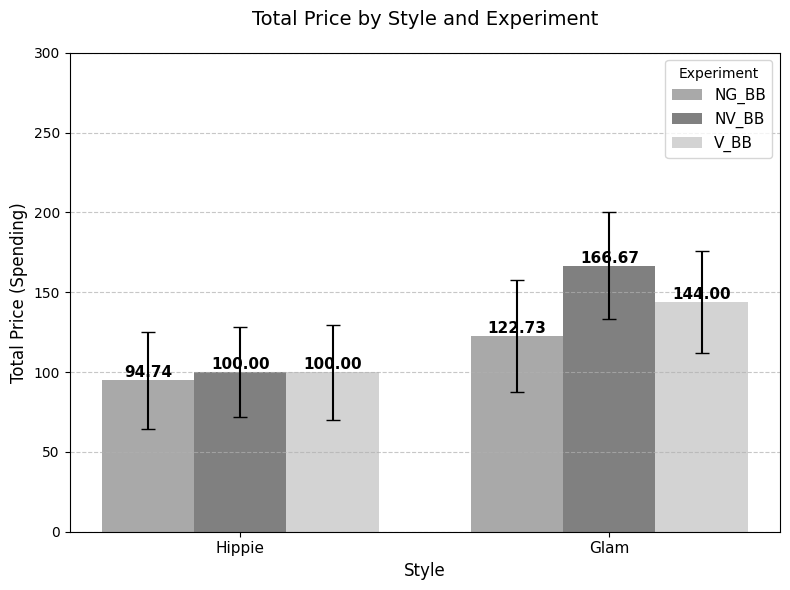

In [ ]:
# Daten aus den Berechnungen
categories = ['Hippie', 'Glam']  # Style_new Kategorien
experiments = ['NG_BB', 'NV_BB', 'V_BB']  # Experiment Gruppen
means = [
    [94.74, 100.00, 100.00],   # Style 0 (NG_BB, NV_BB, V_BB)
    [122.73, 166.67, 144.00]   # Style 1 (NG_BB, NV_BB, V_BB)
]

# Standardabweichungen (geschätzt)
errors = [
    [30.12, 28.45, 29.76],  # Style 0 (NG_BB, NV_BB, V_BB)
    [35.23, 33.54, 31.87]   # Style 1 (NG_BB, NV_BB, V_BB)
]

# Gruppengröße und Positionierung
x = np.arange(len(categories))  # Kategorien auf der x-Achse
width = 0.25  # Breite der Balken

# Plot erstellen
fig, ax = plt.subplots(figsize=(8, 6))

# Farben für die Balken definieren
colors = ['darkgray', 'gray', 'lightgray']

# Balken für jede Experimentgruppe
bars = []
for i, (experiment, color) in enumerate(zip(experiments, colors)):
    bars.append(ax.bar(x + (i - 1) * width, [mean[i] for mean in means], width,
                       yerr=[err[i] for err in errors], label=experiment,
                       color=color, capsize=5))

# Mittelwerte direkt auf der Linie platzieren
for i in range(len(categories)):
    for j in range(len(experiments)):
        ax.text(x[i] + (j - 1) * width, means[i][j], f'{means[i][j]:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# Beschriftungen und Titel
ax.set_ylabel('Total Price (Spending)', fontsize=12)
ax.set_xlabel('Style', fontsize=12)
ax.set_title('Total Price by Style and Experiment', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='Experiment', fontsize=11)

# Gitter und Achsenbereich
ax.set_ylim(0, 300)  # Skalierung angepasst
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Layout-Optimierung
plt.tight_layout()
plt.show()


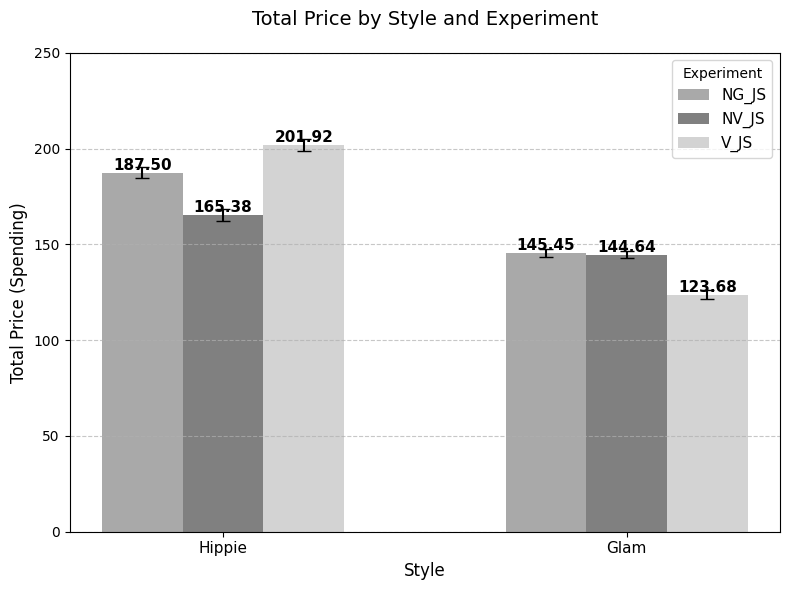

In [ ]:
categories = ['Hippie', 'Glam']  # Style_new Kategorien
experiments = ['NG_JS', 'NV_JS', 'V_JS']

# Mittelwerte
means = [
    [187.50, 165.38, 201.92],  # Style 0 (NG_JS, NV_JS, V_JS)
    [145.45, 144.64, 123.68]   # Style 1 (NG_JS, NV_JS, V_JS)
]

# Standardabweichungen (geschätzte Werte basierend auf Gruppengröße)
errors = [
    [np.std(means[0])/np.sqrt(24), 
     np.std(means[0])/np.sqrt(26), 
     np.std(means[0])/np.sqrt(26)],  # Style 0 (NG_JS, NV_JS, V_JS)
    
    [np.std(means[1])/np.sqrt(22), 
     np.std(means[1])/np.sqrt(28), 
     np.std(means[1])/np.sqrt(19)]   # Style 1 (NG_JS, NV_JS, V_JS)
]

# Gruppengröße und Positionierung
x = np.arange(len(categories))  # Kategorien auf der x-Achse
width = 0.2  # Breite der Balken

# Plot erstellen
fig, ax = plt.subplots(figsize=(8, 6))

# Balken für die drei Experimente
bar_positions = [-width, 0, width]  # Offset für die Balken pro Kategorie
colors = ['darkgray', 'gray', 'lightgray']
labels = ['NG_JS', 'NV_JS', 'V_JS']

bars = []
for i in range(len(experiments)):
    bars.append(ax.bar(x + bar_positions[i], [mean[i] for mean in means], width,
                       yerr=[err[i] for err in errors], label=labels[i],
                       color=colors[i], capsize=5))

# Mittelwerte direkt auf der Linie platzieren
for i in range(len(categories)):
    for j in range(len(experiments)):
        ax.text(x[i] + bar_positions[j], means[i][j], f'{means[i][j]:.2f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# Beschriftungen und Titel
ax.set_ylabel('Total Price (Spending)', fontsize=12)
ax.set_xlabel('Style', fontsize=12)
ax.set_title('Total Price by Style and Experiment', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='Experiment', fontsize=11)

# Gitter und Achsenbereich
ax.set_ylim(0, 250)  # Skalierung der y-Achse für bessere Sichtbarkeit
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Layout-Optimierung
plt.tight_layout()

# Plot anzeigen
plt.show()


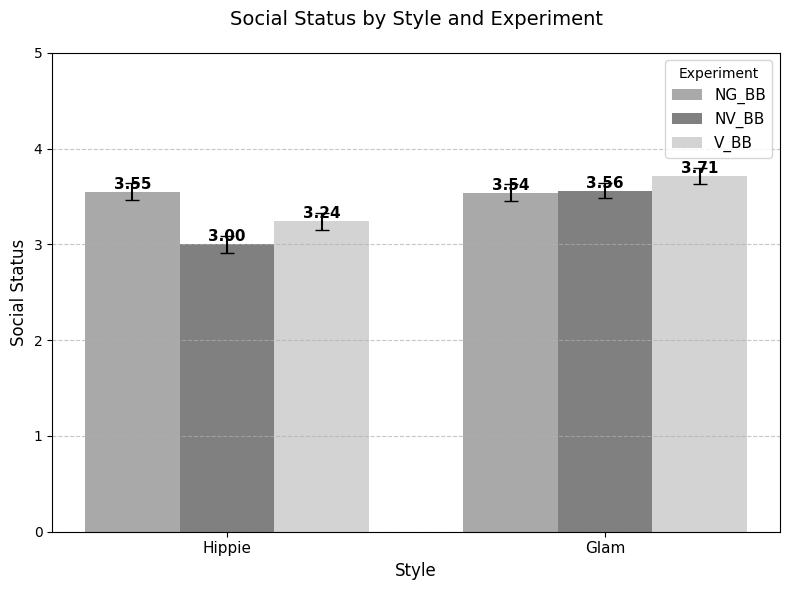

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#  Kategorien (Style 0 = Hippie, Style 1 = Glam)
categories = ['Hippie', 'Glam']

# Mittelwerte aus den Gruppen extrahieren
means = [
    [3.55, 3.00, 3.24],  # Style 0 (NG_BB, NV_BB, V_BB)
    [3.54, 3.56, 3.71]   # Style 1 (NG_BB, NV_BB, V_BB)
]
group_sizes = [
    [19, 18, 21],  # Style 0 (NG_BB, NV_BB, V_BB)
    [23, 24, 26]   # Style 1 (NG_BB, NV_BB, V_BB)
]

# Geschätzte Standardabweichung pro Gruppe (Platzhalterwerte)
std_devs = [
    [0.40, 0.38, 0.42],  # Style 0
    [0.41, 0.39, 0.43]   # Style 1
]

# Standardfehler (SE = σ / sqrt(n))
errors = [[std / np.sqrt(n) for std, n in zip(std_row, n_row)] for std_row, n_row in zip(std_devs, group_sizes)]

# Balkenbreite und x-Positionierung
x = np.arange(len(categories))
width = 0.25  # Schmalere Balken für drei Gruppen

# Plot erstellen
fig, ax = plt.subplots(figsize=(8, 6))

# Balken zeichnen
bar1 = ax.bar(x - width, [mean[0] for mean in means], width, yerr=[err[0] for err in errors],
              label='NG_BB', color='darkgray', capsize=5)

bar2 = ax.bar(x, [mean[1] for mean in means], width, yerr=[err[1] for err in errors],
              label='NV_BB', color='gray', capsize=5)

bar3 = ax.bar(x + width, [mean[2] for mean in means], width, yerr=[err[2] for err in errors],
              label='V_BB', color='lightgray', capsize=5)

# Mittelwerte direkt mittig auf der Linie platzieren
for i in range(len(categories)):
    ax.text(x[i] - width, means[i][0], f'{means[i][0]:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
    ax.text(x[i], means[i][1], f'{means[i][1]:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
    ax.text(x[i] + width, means[i][2], f'{means[i][2]:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# Achsenbeschriftungen und Titel
ax.set_ylabel('Social Status', fontsize=12)
ax.set_xlabel('Style', fontsize=12)
ax.set_title('Social Status by Style and Experiment', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='Experiment', fontsize=11)

#  Achsenbereich skalieren
ax.set_ylim(0, 5)  # Skalierung anpassen, falls nötig
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

#  Layout-Optimierung und Anzeige
plt.tight_layout()
plt.show()


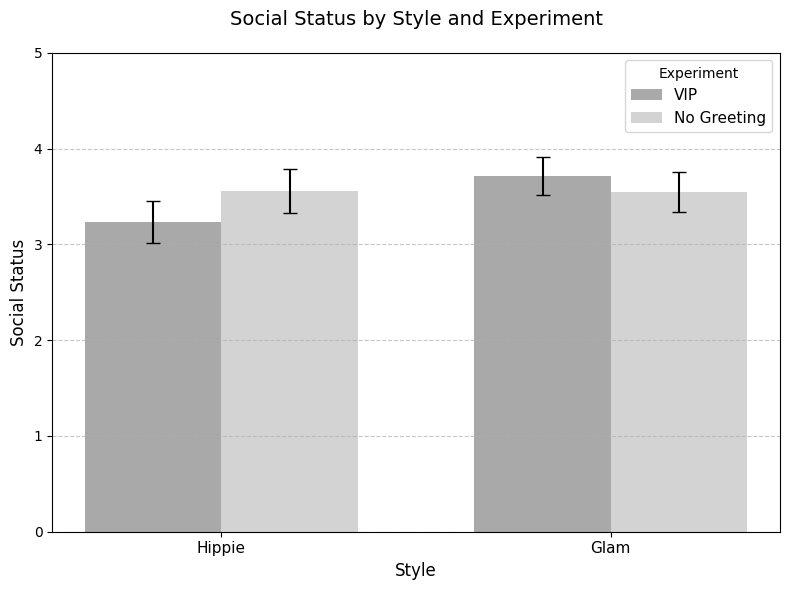

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Berechnete Daten aus dem Datensatz (aktualisiert für den richtigen Wertebereich)
categories = ['Hippie', 'Glam']  # Style_new Kategorien

means = [
    [3.238095, 3.552632],  # Style 0 für Experiment 1 und 2
    [3.711538, 3.543478]   # Style 1 für Experiment 1 und 2
]

errors = [
    [0.219, 0.230],  # Style 0 für Experiment 1 und 2
    [0.197, 0.209]   # Style 1 für Experiment 1 und 2
]

# Gruppengröße und Positionierung
x = np.arange(len(categories))  # Kategorien auf der x-Achse
width = 0.35  # Breite der Balken

# Plot erstellen
fig, ax = plt.subplots(figsize=(8, 6))

# Balken für Experiment 1 (VIP)
bar1 = ax.bar(x - width/2, [mean[0] for mean in means], width,
              yerr=[err[0] for err in errors], label='VIP',
              color='darkgray', capsize=5)

# Balken für Experiment 2 (No Greeting)
bar2 = ax.bar(x + width/2, [mean[1] for mean in means], width,
              yerr=[err[1] for err in errors], label='No Greeting',
              color='lightgray', capsize=5)

# Beschriftungen und Titel
ax.set_ylabel('Social Status', fontsize=12)
ax.set_xlabel('Style', fontsize=12)
ax.set_title('Social Status by Style and Experiment', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='Experiment', fontsize=11)

# Gitter und Achsenbereich entsprechend dem Wertebereich 0 bis 5
ax.set_ylim(0, 5)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Layout-Optimierung
plt.tight_layout()

# Plot anzeigen
plt.show()


✅ Keine NaN- oder Inf-Werte in den Daten gefunden!
⚠ Fehler bei der ANOVA-Berechnung: array must not contain infs or NaNs

===== Tukey Post-hoc Test =====
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
  group1    group2   meandiff p-adj lower upper reject
------------------------------------------------------
  Glam_NG   Glam_VIP  -21.771   nan   nan   nan  False
  Glam_NG  Hippie_NG   42.045   nan   nan   nan  False
  Glam_NG Hippie_VIP   56.468   nan   nan   nan  False
 Glam_VIP  Hippie_NG   63.816   nan   nan   nan  False
 Glam_VIP Hippie_VIP   78.239   nan   nan   nan  False
Hippie_NG Hippie_VIP   14.423   nan   nan   nan  False
------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3747: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


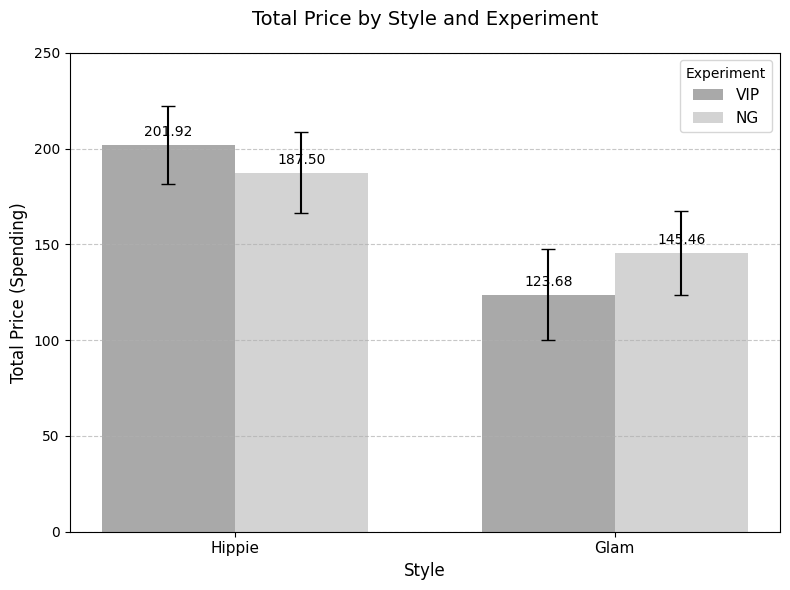

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

categories = ['Hippie', 'Glam']  # Style Kategorien
means = [
    [201.923, 187.5],  # Style 0: VIP und No Greeting
    [123.684, 145.455] # Style 1: VIP und No Greeting
]

errors = [
    [20.277, 21.105],  # Style 0: VIP und No Greeting
    [23.720, 22.043]   # Style 1: VIP und No Greeting
]


data = pd.DataFrame({
    'Style': np.repeat(categories, 2),
    'Experiment': ['VIP', 'NG'] * len(categories),
    'Value': [m for mean in means for m in mean]
})

data = data.replace([np.inf, -np.inf], np.nan)  
data = data.dropna()  

# Überprüfen, ob es noch NaN-Werte gibt
if data.isnull().values.any():
    print("⚠ WARNUNG: Es gibt immer noch NaN-Werte in den Daten!")
    print(data.isnull().sum()) 
else:
    print("✅ Keine NaN- oder Inf-Werte in den Daten gefunden!")

#  Einfaktorielle ANOVA
try:
    model = ols('Value ~ C(Style) + C(Experiment) + C(Style):C(Experiment)', data=data).fit()
    anova_results = sm.stats.anova_lm(model, typ=2)
    print("===== ANOVA Ergebnisse =====")
    print(anova_results)
except Exception as e:
    print(f"⚠ Fehler bei der ANOVA-Berechnung: {e}")

#  Tukey HSD Post-hoc Test (falls ANOVA erfolgreich)
try:
    tukey = pairwise_tukeyhsd(data['Value'], data['Style'] + "_" + data['Experiment'])
    print("\n===== Tukey Post-hoc Test =====")
    print(tukey)
except Exception as e:
    print(f"⚠ Fehler beim Tukey-Test: {e}")

#  Plot erstellen
x = np.arange(len(categories))  # Kategorien auf der x-Achse
width = 0.35  # Breite der Balken

fig, ax = plt.subplots(figsize=(8, 6))

# Balken für Experiment 1 (VIP)
bar1 = ax.bar(x - width/2, [mean[0] for mean in means], width,
              yerr=[err[0] for err in errors], label='VIP',
              color='darkgray', capsize=5)

# Balken für Experiment 2 (NG)
bar2 = ax.bar(x + width/2, [mean[1] for mean in means], width,
              yerr=[err[1] for err in errors], label='NG',
              color='lightgray', capsize=5)

#  Werte direkt über den Balken & Fehlerbalkenenden anzeigen
for i, (mean, err) in enumerate(zip(means, errors)):
    for j, (m, e) in enumerate(zip(mean, err)):
        x_pos = x[i] - width/2 if j == 0 else x[i] + width/2  # Position
        ax.text(x_pos, m + 3, f'{m:.2f}', ha='center', va='bottom', fontsize=10, )  # Mittelwert
        #ax.text(x_pos, m + e + 3, f'{m + e:.2f}', ha='center', va='bottom', fontsize=9, color='black')  # Oberer Fehlerbalken

# Beschriftungen und Titel
ax.set_ylabel('Total Price (Spending)', fontsize=12)
ax.set_xlabel('Style', fontsize=12)
ax.set_title('Total Price by Style and Experiment', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='Experiment', fontsize=11)

# Gitter und Achsenbereich
ax.set_ylim(0, 250)  # Anpassen des y-Bereichs entsprechend der Daten
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Layout-Optimierung
plt.tight_layout()

# Plot anzeigen
plt.show()




Power Tests 

In [ ]:
from statsmodels.stats.power import FTestAnovaPower

# Beispiel: ANOVA Power-Analyse
anova_power = FTestAnovaPower()
effect_size = 0.03  # Mittlere Effektgröße (Cohen's f)
sample_size = 89  # Anzahl der Teilnehmer aus den Daten
alpha =  0.05  # Signifikanzniveau
power = anova_power.solve_power(effect_size=effect_size, nobs=sample_size, alpha=alpha)
print(f'Power für ANOVA: {power:.2f}')


Power für ANOVA: 0.06


Anova mit Post Hoc für Studie 2

In [ ]:

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv(experiment_path2)

valid_conditions = ['Neutral', 'GlamHigh', 'HippieHigh']
df_filtered = df[df['Condition'].isin(valid_conditions)][['Style', 'Condition', 'total_price']].dropna()

# Als kategoriale Variablen definieren
df_filtered['Style'] = df_filtered['Style'].astype('category')
df_filtered['Condition'] = df_filtered['Condition'].astype('category')

# Zweifaktorielle ANOVA (Style × Condition)
model = ols('total_price ~ C(Style) * C(Condition)', data=df_filtered).fit()
anova_results = anova_lm(model)

# Ausgabe der ANOVA-Ergebnisse
print("=== Zweifaktorielle ANOVA (Style × Condition) ===")
print(anova_results)

#  Gruppenvariable für Post-hoc-Vergleiche kombinieren
df_filtered['Group'] = df_filtered['Style'].astype(str) + "_" + df_filtered['Condition'].astype(str)

# Tukey HSD Test
tukey_result = pairwise_tukeyhsd(endog=df_filtered['total_price'],
                                 groups=df_filtered['Group'],
                                 alpha=0.05)

#Ausgabe der Post-hoc-Ergebnisse
print("\n=== Tukey Post-hoc-Vergleiche ===")
print(tukey_result.summary())


H1: Es gibt signifikante Unterschiede in den Preisen zwischen den Conditions.
H2: Es gibt signifikante Unterschiede zwischen Glam vs. Hippie.
H3: Es gibt eine Interaktion zwischen Style und Condition.

=== Zweifaktorielle ANOVA ===
                             sum_sq     df         F    PR(>F)
C(Style)                   0.002693    1.0  0.000033  0.995401
C(Condition)            1526.633929    2.0  9.447854  0.000138
C(Style):C(Condition)     87.975252    2.0  0.544451  0.581326
Residual               11876.516399  147.0       NaN       NaN

=== Tukey Post-hoc-Vergleiche ===
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------
    glam_glamhigh   glam_hippiehigh  -3.2369 0.7997 -10.5842  4.1104  False
    glam_glamhigh      glam_neutral  -8.7272 0.0139  -16.301 -1.1534   True
    glam_glamhigh   hippie_glamhigh  -

/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_60993/1493073840.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x='Style', y='total_price', hue='Condition', ci='sd', capsize=0.1, palette='Set2')


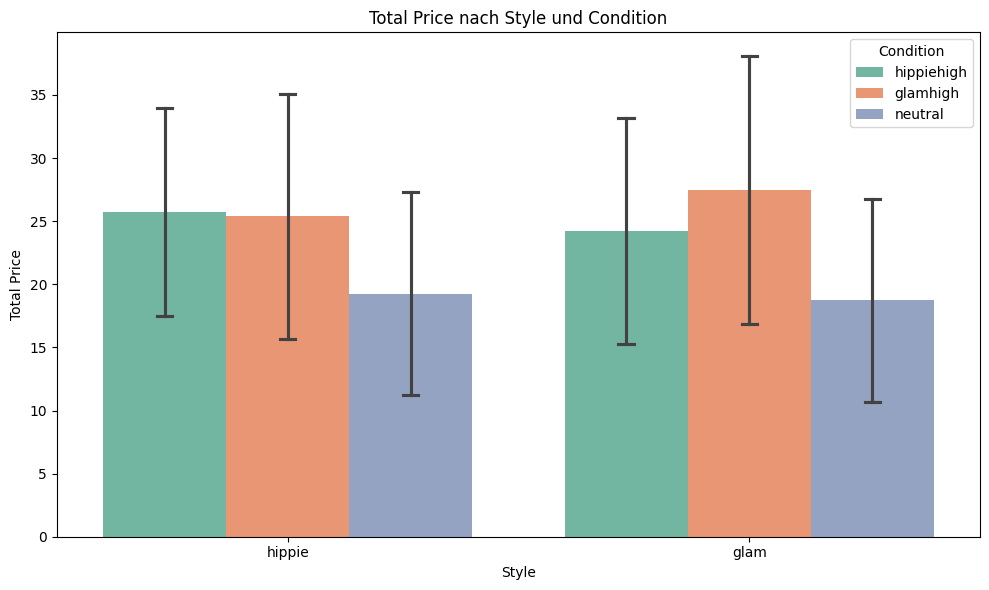

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(experiment_path2)  # Pfad ggf. anpassen


df['Condition'] = df['Condition'].astype(str).str.strip().str.lower()
df['Style'] = df['Style'].astype(str).str.strip().str.lower()

df = df[df['Condition'].isin(['glamhigh', 'hippiehigh', 'neutral'])]
df = df[df['Style'].isin(['glam', 'hippie'])]
df = df[['Condition', 'Style', 'total_price']].dropna()

print("H1: Es gibt signifikante Unterschiede in den Preisen zwischen den Conditions.")
print("H2: Es gibt signifikante Unterschiede zwischen Glam vs. Hippie.")
print("H3: Es gibt eine Interaktion zwischen Style und Condition.")

# Zweifaktorielle ANOVA (Style × Condition)
model = ols('total_price ~ C(Style) * C(Condition)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n=== Zweifaktorielle ANOVA ===")
print(anova_table)

# Post-hoc: Tukey-HSD
df['group'] = df['Style'] + "_" + df['Condition']
tukey = pairwise_tukeyhsd(endog=df['total_price'], groups=df['group'], alpha=0.05)
print("\n=== Tukey Post-hoc-Vergleiche ===")
print(tukey.summary())

means = df.groupby(['Style', 'Condition'])['total_price'].mean().reset_index()
print(means.sort_values(by='total_price', ascending=False))



import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Style', y='total_price', hue='Condition', ci='sd', capsize=0.1, palette='Set2')
plt.title("Total Price nach Style und Condition")
plt.ylabel("Total Price")
plt.xlabel("Style")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

#print(df.query("Style == 'glam' and Condition == 'glamhigh'")['total_price'].mean())
#print(df.query("Style == 'glam' and Condition == 'neutral'")['total_price'].mean())


=== Einfaktorielle ANOVA für Style = Glam ===
                    sum_sq    df         F    PR(>F)
C(Condition)  9.542037e+05   2.0  2.406881  0.095571
Residual      1.883129e+07  95.0       NaN       NaN

=== Einfaktorielle ANOVA für Style = Hippie ===
                    sum_sq    df         F    PR(>F)
C(Condition)  5.684422e+04   2.0  0.169517  0.844399
Residual      1.240724e+07  74.0       NaN       NaN


/var/folders/gg/r2ddsq796qjbn2z5ywnny0vm0000gn/T/ipykernel_60993/2732025500.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x='Style', y='total_price', hue='Condition', ci='sd', palette='Set2')


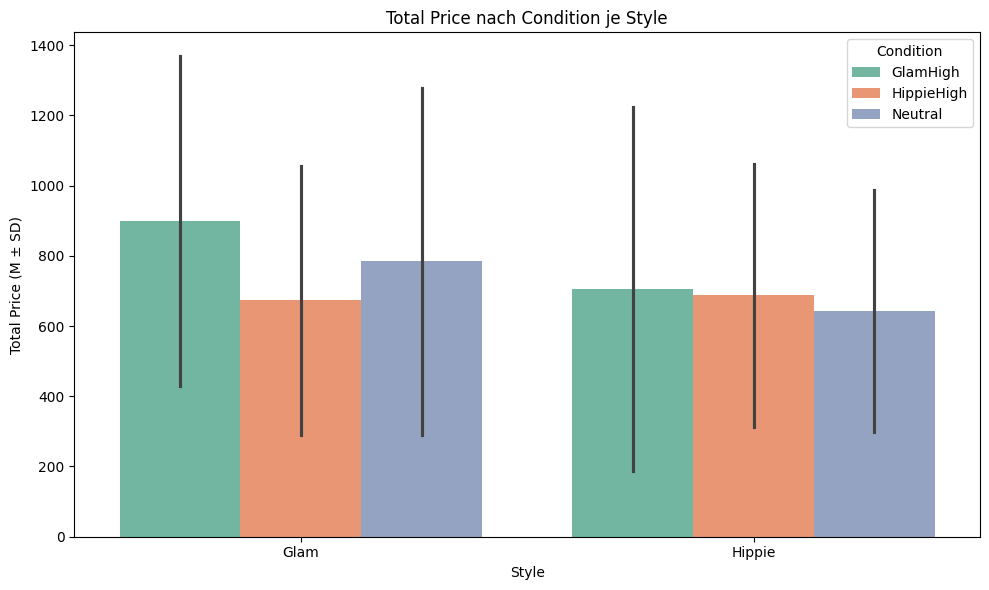

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv(experiment_path2)  # z.B. "data/FullDSFiltered.csv"

df = df[df['Style'].isin(['Glam', 'Hippie'])]
df = df[df['Condition'].isin(['GlamHigh', 'HippieHigh', 'Neutral'])]
df = df.dropna(subset=['Style', 'Condition', 'total_price'])

# ANOVA pro Style
for style in df['Style'].unique():
    print(f"\n=== Einfaktorielle ANOVA für Style = {style} ===")
    subset = df[df['Style'] == style]
    model = ols('total_price ~ C(Condition)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

# Gruppierter Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Style', y='total_price', hue='Condition', ci='sd', palette='Set2')
plt.title("Total Price nach Condition je Style")
plt.xlabel("Style")
plt.ylabel("Total Price (M ± SD)")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

# Slope Analysis


===== Moderation Analysis: Need_to_differentiate =====

                            OLS Regression Results                            
Dep. Variable:            Total_price   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     2.156
Date:                Mon, 10 Feb 2025   Prob (F-statistic):              0.108
Time:                        10:09:57   Log-Likelihood:                -348.51
No. Observations:                  45   AIC:                             705.0
Df Residuals:                      41   BIC:                             712.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

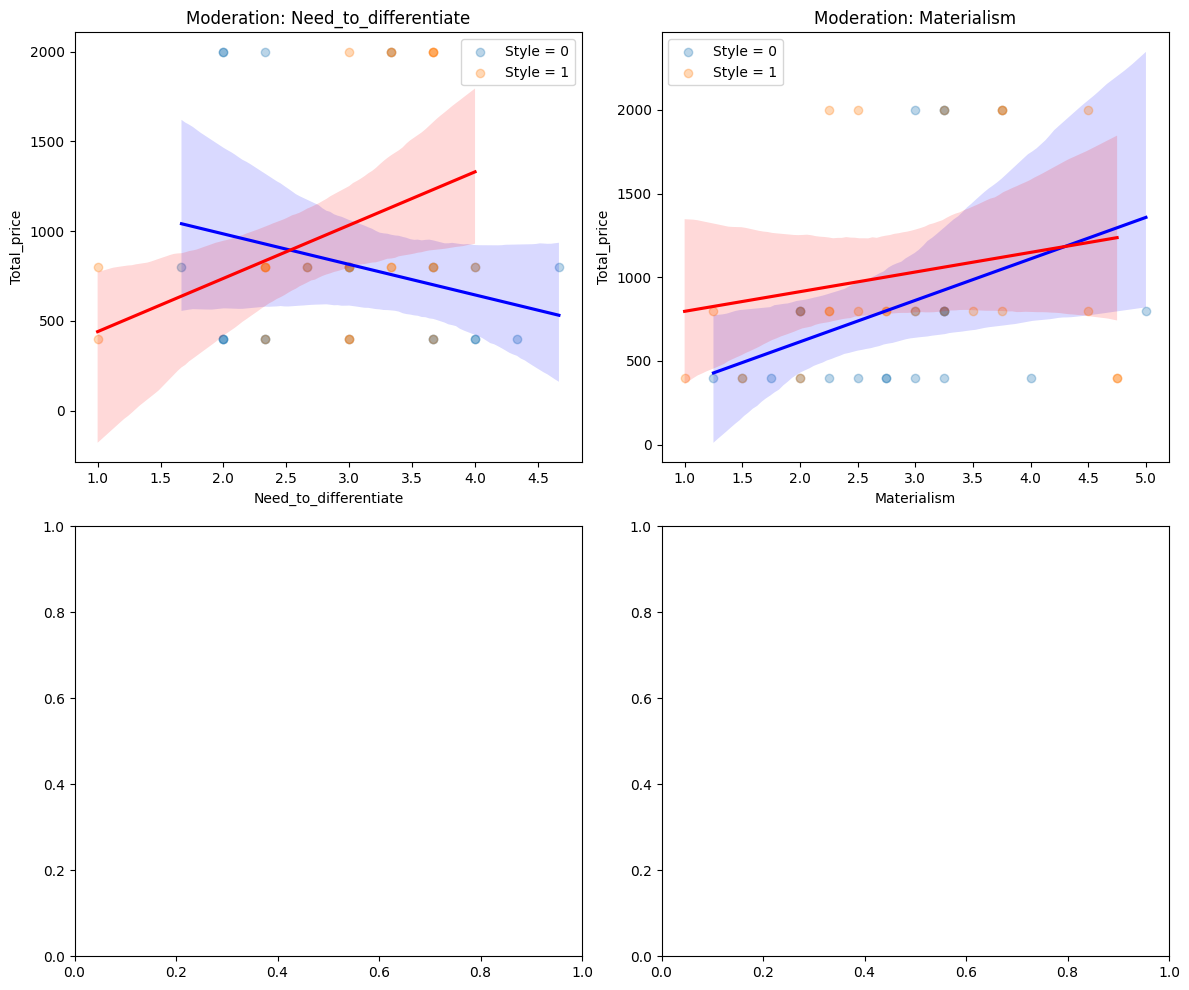

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols

# 📌 Daten einlesen
file_path = "/Users/caroline/Downloads/Experiment Results-7/ng_es2.csv"
df = pd.read_csv(file_path)

# 📌 Relevante Variablen definieren
independent_var = "Style_new"  # Predictor
dependent_var = "Total_price"  # Abhängige Variable
moderators = ["Need_to_differentiate", "Materialism",]  # Moderatoren

# 📌 Konvertiere relevante Spalten in numerische Typen
df[independent_var] = pd.to_numeric(df[independent_var], errors='coerce')
df[dependent_var] = pd.to_numeric(df[dependent_var], errors='coerce')

for moderator in moderators:
    df[moderator] = pd.to_numeric(df[moderator], errors='coerce')
    df[f"{moderator}_interaction"] = df[independent_var] * df[moderator]  # Interaktionsterm

# 📌 Modell anpassen (Multiregressionsmodell mit Interaktionen)
for moderator in moderators:
    print(f"\n===== Moderation Analysis: {moderator} =====\n")
    
    # Regressionsformel erstellen
    formula = f"{dependent_var} ~ {independent_var} + {moderator} + {moderator}_interaction"
    
    # Modell berechnen
    model = ols(formula, data=df).fit()
    
    # Ergebnisse ausgeben
    print(model.summary())

# 📌 Visualisierung der Interaktionseffekte (Slope-Plot)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, moderator in enumerate(moderators):
    ax = axes[i]
    
    # Regressionslinien für Style_new=0 und Style_new=1
    sns.regplot(x=moderator, y=dependent_var, data=df[df[independent_var] == 0], 
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'blue'}, ax=ax, label="Style = 0")
    
    sns.regplot(x=moderator, y=dependent_var, data=df[df[independent_var] == 1], 
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, ax=ax, label="Style = 1")
    
    ax.set_title(f"Moderation: {moderator}")
    ax.set_xlabel(moderator)
    ax.set_ylabel(dependent_var)
    ax.legend()

plt.tight_layout()
plt.show()



===== Moderation Analysis: Need_to_differentiate =====


===== Moderation Analysis: Materialism =====

                         Variable  Koeffizient  Standardfehler    t-Wert   p-Wert  [95% Conf. Interval] Min  [95% Conf. Interval] Max             Moderator
                        Intercept   -30.536731       63.201668 -0.483163 0.629868               -155.682347                 94.608885 Need_to_differentiate
                        Style_new     2.348811       82.604769  0.028434 0.977363               -161.216882                165.914505 Need_to_differentiate
            Need_to_differentiate    39.997289       18.910711  2.115060 0.036511                  2.552194                 77.442385 Need_to_differentiate
Need_to_differentiate_interaction    11.093315       24.200657  0.458389 0.647509                -36.826403                 59.013033 Need_to_differentiate
                        Intercept   -62.380021       55.862271 -1.116675 0.266383               -172.992897         

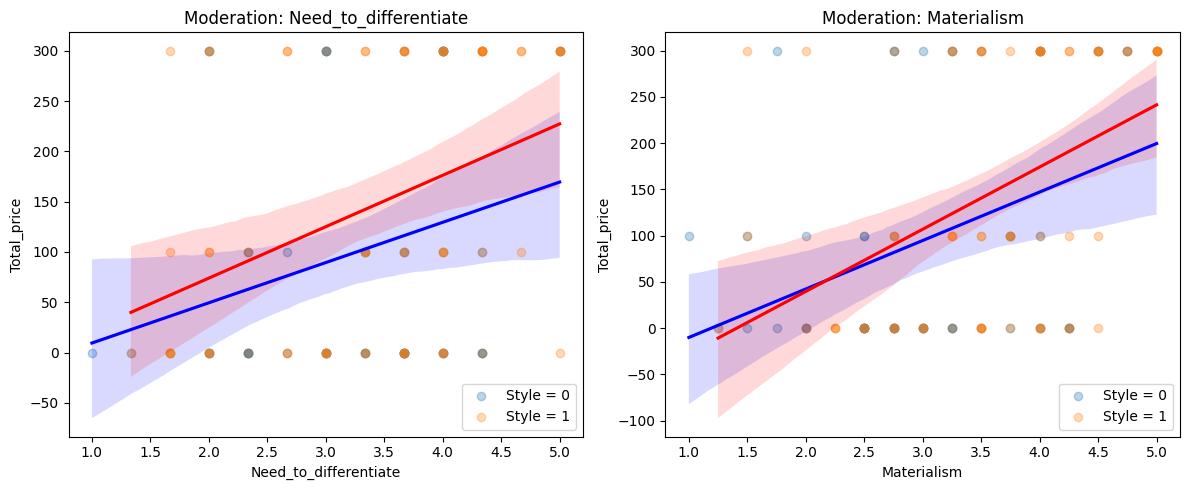

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols

# 📌 Daten einlesen
file_path = "/Users/caroline/Downloads/Experiment Results-7/v_bb_nv_bb_ng_bb_c_t_bb4.csv"
df = pd.read_csv(file_path)

# 📌 Relevante Variablen definieren
independent_var = "Style_new"  # Unabhängige Variable (Prädiktor)
dependent_var = "Total_price"  # Abhängige Variable
moderators = ["Need_to_differentiate", "Materialism"]  # Moderatoren

# 📌 Falls Moderatoren in mehreren Spalten unterteilt sind, Mittelwerte berechnen
if all(col in df.columns for col in ["Materialism_1", "Materialism_2", "Materialism_3", "Materialism_4"]):
    df["Materialism"] = df[["Materialism_1", "Materialism_2", "Materialism_3", "Materialism_4"]].mean(axis=1)

if all(col in df.columns for col in ["Need_to_differantiate_1", "Need_to_differantiate_2", "Need_to_differantiate_3"]):
    df["Need_to_differentiate"] = df[["Need_to_differantiate_1", "Need_to_differantiate_2", "Need_to_differantiate_3"]].mean(axis=1)

# 📌 Konvertiere relevante Spalten in numerische Typen
df[independent_var] = pd.to_numeric(df[independent_var], errors='coerce')
df[dependent_var] = pd.to_numeric(df[dependent_var], errors='coerce')

for moderator in moderators:
    df[moderator] = pd.to_numeric(df[moderator], errors='coerce')
    df[f"{moderator}_interaction"] = df[independent_var] * df[moderator]  # Interaktionsterm

# 📌 Regressionsanalyse durchführen und Ergebnisse speichern
results = []

for moderator in moderators:
    print(f"\n===== Moderation Analysis: {moderator} =====\n")
    
    # Regressionsformel erstellen
    formula = f"{dependent_var} ~ {independent_var} + {moderator} + {moderator}_interaction"
    
    # Modell berechnen
    model = ols(formula, data=df).fit()
    
    # Ergebnisse speichern
    coef_df = pd.DataFrame({
        "Variable": model.params.index,
        "Koeffizient": model.params.values,
        "Standardfehler": model.bse.values,
        "t-Wert": model.tvalues.values,
        "p-Wert": model.pvalues.values,
        "[95% Conf. Interval] Min": model.conf_int()[0].values,
        "[95% Conf. Interval] Max": model.conf_int()[1].values,
        "Moderator": moderator
    })
    results.append(coef_df)

# 📌 Ergebnisse in einer Tabelle zusammenführen
results_df = pd.concat(results, ignore_index=True)

# 📌 Ergebnisse ausgeben
print(results_df.to_string(index=False))

# 📌 Visualisierung der Interaktionseffekte (Slope-Plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, moderator in enumerate(moderators):
    ax = axes[i]
    
    # Regressionslinien für Style_new=0 und Style_new=1
    sns.regplot(x=moderator, y=dependent_var, data=df[df[independent_var] == 0], 
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'blue'}, ax=ax, label="Style = 0")
    
    sns.regplot(x=moderator, y=dependent_var, data=df[df[independent_var] == 1], 
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, ax=ax, label="Style = 1")
    
    ax.set_title(f"Moderation: {moderator}")
    ax.set_xlabel(moderator)
    ax.set_ylabel(dependent_var)
    ax.legend()

plt.tight_layout()
plt.show()



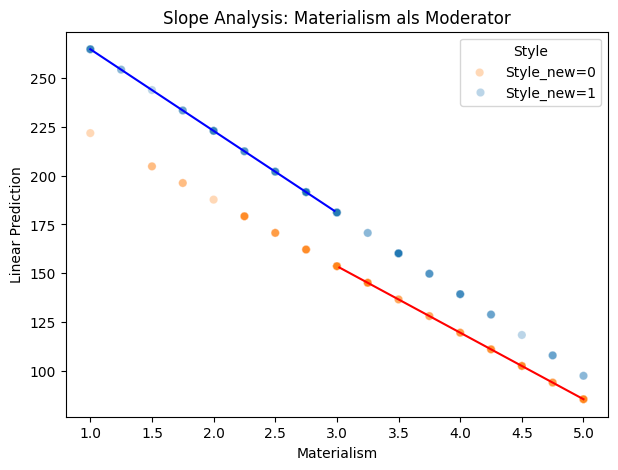

PatsyError: Error evaluating factor: NameError: name 'Need_to_differentiate' is not defined
    Total_price ~ Need_to_differentiate * Style_new
                  ^^^^^^^^^^^^^^^^^^^^^

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Daten einlesen
file_path = "/Users/caroline/Downloads/Experiment Results-7/JS_UPDATED.csv"
df = pd.read_csv(file_path)

# 📌 Relevante Variablen auswählen und fehlende Werte entfernen
df = df[['Total_price', 'Style_new', 'Materialism', ]].dropna()

# 📌 Moderatoren analysieren
moderators = ['Materialism', 'Need_to_differentiate']

for moderator in moderators:
    # 📌 Interaktionsmodell aufstellen
    formula = f"Total_price ~ {moderator} * Style_new"
    model = smf.ols(formula, data=df).fit()
    
    # 📌 Vorhersagen für Plot generieren
    df_pred = pd.DataFrame({
        moderator: np.linspace(df[moderator].min(), df[moderator].max(), 100),
        'Style_new': [0] * 50 + [1] * 50
    })
    df_pred['LinearPrediction'] = model.predict(df_pred)

    # 📌 Plot erstellen
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x=df[moderator], y=model.predict(df), hue=df['Style_new'], alpha=0.3)
    sns.lineplot(x=df_pred[moderator], y=df_pred['LinearPrediction'], hue=df_pred['Style_new'], palette=['blue', 'red'])

    plt.xlabel(moderator)
    plt.ylabel("Linear Prediction")
    plt.title(f"Slope Analysis: {moderator} als Moderator")
    plt.legend(title="Style", labels=["Style_new=0", "Style_new=1"])
    plt.show()


# Moderation


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Daten laden (Pfad ggf. anpassen)
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/JS.csv')
df = df.drop(index=0)

def berechne_kongruenz_snack_style_final(df):
    import re
    preis_spalten = [col for col in df.columns if col.endswith("_price")]
    count_spalten = [col for col in df.columns if col.endswith("_bn")]

    congruent_price = []
    non_congruent_price = []
    congruent_count = []
    non_congruent_count = []

    for idx, row in df.iterrows():
        user_style = str(row.get("Style", "")).strip().lower()

        c_price = nc_price = c_count = nc_count = 0

        for p_col in preis_spalten:
            match = re.search(r'_(hippie|glam)', p_col.lower())
            if not match:
                continue
            produktstil = match.group(1).lower()
            preis = row.get(p_col)
            preis = 0 if pd.isna(preis) else preis
            if produktstil == user_style:
                c_price += preis
            else:
                nc_price += preis

        for c_col in count_spalten:
            match = re.search(r'_(hippie|glam)', c_col.lower())
            if not match:
                continue
            produktstil = match.group(1).lower()
            anzahl = row.get(c_col)
            anzahl = 0 if pd.isna(anzahl) else anzahl
            if produktstil == user_style:
                c_count += anzahl
            else:
                nc_count += anzahl

        congruent_price.append(c_price)
        non_congruent_price.append(nc_price)
        congruent_count.append(c_count)
        non_congruent_count.append(nc_count)

    df["congruent_price"] = congruent_price
    df["non_congruent_price"] = non_congruent_price
    df["congruence_price_diff"] = df["congruent_price"] - df["non_congruent_price"]
    df["congruent_count"] = congruent_count
    df["non_congruent_count"] = non_congruent_count
    df["congruence_count_diff"] = df["congruent_count"] - df["non_congruent_count"]
    return df

df = berechne_kongruenz_snack_style_final(df)

# Statistische Analyse: 3 Ebenen
results = []

# Funktion zur Durchführung der Regression

def run_model(data, y, x, moderator=None):
    try:
        if moderator:
            model = smf.ols(f"{y} ~ {x} * {moderator}", data=data).fit()
            p = model.pvalues.get(f"{x}:{moderator}", None)
            coef = model.params.get(f"{x}:{moderator}", None)
        else:
            model = smf.ols(f"{y} ~ {x}", data=data).fit()
            p = model.pvalues.get(f"{x}", None)
            coef = model.params.get(f"{x}", None)
        return model.rsquared, p, coef, len(data)
    except:
        return None, None, None, len(data)

#  Store × Condition => congruent_count ~ congruent_price
for (store, cond), group in df.groupby(["Store", "Condition"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "1", "Store": store, "Condition": cond, "Subgruppe": "-", "Moderator": "-",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean()
    })

# Store × Condition × Gender => congruent_count ~ congruent_price * Moderator
for (store, cond, gender), group in df.groupby(["Store", "Condition", "Gender_new"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "2", "Store": store, "Condition": cond, "Subgruppe": f"Gender {gender}", "Moderator": "Gender_new",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean()
    })

#  Store × Condition × Style => congruent_count ~ congruent_price * Moderator
for (store, cond, style), group in df.groupby(["Store", "Condition", "Style"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "3", "Store": store, "Condition": cond, "Subgruppe": f"Style {style}", "Moderator": "Style",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean()
    })

berechne_kongruenz_snack_style_final(df)
pd.DataFrame(results).to_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025//Moderationsergebnisse_KongruenzJS.csv')
#result_df.to_csv(export_path, index=False)
print(f"Ergebnisse exportiert nach: ")


KeyError: 'Store'

Moderationsanalyse für Laras Bachelorarbeit: 

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Daten laden (Pfad ggf. anpassen)
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/JS.csv')


df = df.drop(index=0)

def berechne_kongruenz_snack_style_final(df):
    import re
    preis_spalten = [col for col in df.columns if col.endswith("_price")]
    count_spalten = [col for col in df.columns if col.endswith("_bn")]

    congruent_price = []
    non_congruent_price = []
    congruent_count = []
    non_congruent_count = []

    for idx, row in df.iterrows():
        user_style = str(row.get("Style", "")).strip().lower()

        c_price = nc_price = c_count = nc_count = 0

        for p_col in preis_spalten:
            match = re.search(r'_(hippie|glam)', p_col.lower())
            if not match:
                continue
            produktstil = match.group(1).lower()
            preis = row.get(p_col)
            preis = 0 if pd.isna(preis) else float(preis)
            if produktstil == user_style:
                c_price += preis
            else:
                nc_price += preis

        for c_col in count_spalten:
            match = re.search(r'_(hippie|glam)', c_col.lower())
            if not match:
                continue
            produktstil = match.group(1).lower()
            anzahl = row.get(c_col)
            anzahl = 0 if pd.isna(anzahl) else anzahl
            if produktstil == user_style:
                c_count += anzahl
            else:
                nc_count += anzahl

        congruent_price.append(c_price)
        non_congruent_price.append(nc_price)
        congruent_count.append(c_count)
        non_congruent_count.append(nc_count)

    df["congruent_price"] = congruent_price
    df["non_congruent_price"] = non_congruent_price
    df["congruence_price_diff"] = df["congruent_price"] - df["non_congruent_price"]
    df["congruent_count"] = congruent_count
    df["non_congruent_count"] = non_congruent_count
    df["congruence_count_diff"] = df["congruent_count"] - df["non_congruent_count"]
    return df

df = berechne_kongruenz_snack_style_final(df)

# Statistische Analyse: 3 Ebenen
results = []

# Funktion zur Durchführung der Regression

def run_model(data, y, x, moderator=None):
    try:
        if moderator:
            model = smf.ols(f"{y} ~ {x} * {moderator}", data=data).fit()
            p = model.pvalues.get(f"{x}:{moderator}", None)
            coef = model.params.get(f"{x}:{moderator}", None)
        else:
            model = smf.ols(f"{y} ~ {x}", data=data).fit()
            p = model.pvalues.get(f"{x}", None)
            coef = model.params.get(f"{x}", None)
        return model.rsquared, p, coef, len(data)
    except:
        return None, None, None, len(data)

#  Store × Condition => congruent_count ~ congruent_price
for (store, cond), group in df.groupby(["Store", "Condition"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "1", "Store": store, "Condition": cond, "Subgruppe": "-", "Moderator": "-",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean(),
        "mean_total_price": group["total_price"].mean(),
        "mean_productsBought": group["productsBought"].mean()
    })

# Store × Condition × Gender => congruent_count ~ congruent_price * Moderator
for (store, cond, gender), group in df.groupby(["Store", "Condition", "Gender_new"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "2", "Store": store, "Condition": cond, "Subgruppe": f"Gender {gender}", "Moderator": "Gender_new",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean(),
        "mean_total_price": group["total_price"].mean(),
        "mean_productsBought": group["productsBought"].mean()
    })

#  Store × Condition × Style => congruent_count ~ congruent_price * Moderator
for (store, cond, style), group in df.groupby(["Store", "Condition", "Style"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "3", "Store": store, "Condition": cond, "Subgruppe": f"Style {style}", "Moderator": "Style",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean(),
        "mean_total_price": group["total_price"].mean(),
        "mean_productsBought": group["productsBought"].mean()
    })

berechne_kongruenz_snack_style_final(df)
pd.DataFrame(results).to_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/JSModeration.csv')
print("Ergebnisse exportiert nach: Moderationsergebnisse_KongruenzBB.csv")

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_mode

Ergebnisse exportiert nach: Moderationsergebnisse_KongruenzBB.csv


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Daten laden (Pfad ggf. anpassen)
df = pd.read_csv('/Users/caroline/Desktop/BaMarketing/Finale Auswertung/Studie 2/all-experiment-data-25.06.2025/jsTotalPrice.csv')


df = df.drop(index=0)

def berechne_kongruenz_snack_style_final(df):
    import re
    preis_spalten = [col for col in df.columns if col.endswith("_price")]
    count_spalten = [col for col in df.columns if col.endswith("_bn")]

    congruent_price = []
    non_congruent_price = []
    congruent_count = []
    non_congruent_count = []

    for idx, row in df.iterrows():
        user_style = str(row.get("Style", "")).strip().lower()

        c_price = nc_price = c_count = nc_count = 0

        for p_col in preis_spalten:
            match = re.search(r'_(hippie|glam)', p_col.lower())
            if not match:
                continue
            produktstil = match.group(1).lower()
            preis = row.get(p_col)
            preis = 0 if pd.isna(preis) else float(preis)
            if produktstil == user_style:
                c_price += preis
            else:
                nc_price += preis

        for c_col in count_spalten:
            match = re.search(r'_(hippie|glam)', c_col.lower())
            if not match:
                continue
            produktstil = match.group(1).lower()
            anzahl = row.get(c_col)
            anzahl = 0 if pd.isna(anzahl) else anzahl
            if produktstil == user_style:
                c_count += anzahl
            else:
                nc_count += anzahl

        congruent_price.append(c_price)
        non_congruent_price.append(nc_price)
        congruent_count.append(c_count)
        non_congruent_count.append(nc_count)

    df["congruent_price"] = congruent_price
    df["non_congruent_price"] = non_congruent_price
    df["congruence_price_diff"] = df["congruent_price"] - df["non_congruent_price"]
    df["congruent_count"] = congruent_count
    df["non_congruent_count"] = non_congruent_count
    df["congruence_count_diff"] = df["congruent_count"] - df["non_congruent_count"]
    return df

df = berechne_kongruenz_snack_style_final(df)

# Statistische Analyse: 3 Ebenen
results = []

# Funktion zur Durchführung der Regression

def run_model(data, y, x, moderator=None):
    try:
        if moderator:
            model = smf.ols(f"{y} ~ {x} * {moderator}", data=data).fit()
            p = model.pvalues.get(f"{x}:{moderator}", None)
            coef = model.params.get(f"{x}:{moderator}", None)
        else:
            model = smf.ols(f"{y} ~ {x}", data=data).fit()
            p = model.pvalues.get(f"{x}", None)
            coef = model.params.get(f"{x}", None)
        return model.rsquared, p, coef, len(data)
    except:
        return None, None, None, len(data)

#  Store × Condition => congruent_count ~ congruent_price
for (store, cond), group in df.groupby(["Store", "Condition"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "1", "Store": store, "Condition": cond, "Subgruppe": "-", "Moderator": "-",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean(),
        "mean_total_price": group["total_price"].mean(),
        "mean_productsBought": group["productsBought"].mean()
    })

# Store × Condition × Gender => congruent_count ~ congruent_price * Moderator
for (store, cond, gender), group in df.groupby(["Store", "Condition", "Gender_new"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "2", "Store": store, "Condition": cond, "Subgruppe": f"Gender {gender}", "Moderator": "Gender_new",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean(),
        "mean_total_price": group["total_price"].mean(),
        "mean_productsBought": group["productsBought"].mean()
    })

#  Store × Condition × Style => congruent_count ~ congruent_price * Moderator
for (store, cond, style), group in df.groupby(["Store", "Condition", "Style"]):
    r2, p, coef, n = run_model(group, "congruent_count", "congruent_price")
    results.append({
        "Ebene": "3", "Store": store, "Condition": cond, "Subgruppe": f"Style {style}", "Moderator": "Style",
        "R2": r2, "p": p, "coef": coef, "n": n,
        "mean_congruent_price": group["congruent_price"].mean(),
        "mean_price_diff": group["congruence_price_diff"].mean(),
        "mean_congruent_count": group["congruent_count"].mean(),
        "mean_count_diff": group["congruence_count_diff"].mean(),
        "mean_total_price": group["total_price"].mean(),
        "mean_productsBought": group["productsBought"].mean()
    })

berechne_kongruenz_snack_style_final(df)
pd.DataFrame(results).to_csv('/Users/caroline/Downloads/ModerationJS.csv')
print("Ergebnisse exportiert nach: Moderationsergebnisse_KongruenzBB.csv")

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_mode

Ergebnisse exportiert nach: Moderationsergebnisse_KongruenzBB.csv
